<a href="https://colab.research.google.com/github/TiaSinghania/DrakeEquationSim/blob/main/colab/diffusion_computational_lab_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 27-100 Computational MSE Lab: Diffusion!
Welcome to the computational lab! In these exercises, we'll explore diffusion at both the atomistic and continuum lengthscales. As you've seen by now, one of the hallmarks of "MSE thinking" is connecting across lengthscales – for example, understanding dislocation motion and how it leads to plastic deformation. We've talked some in lecture about atomistic mechanisms of diffusion (e.g. via vacancies) as well as how we describe it in a continuum setting (Fick's Laws). Here we'll explore how those ideas are connected to each other through a series of **computational experiments** that you'll be guided through. You will not need to write any code yourself (though if you're curious, you'll be able to see the code that's being run).

You'll also be able to see how such **computational experiments** can be very analogous to lab-based ones...keep this in mind as you work, and think about how computation can be similar to/different from experiments, and how the two approaches might complement each other!

## What is this thing I'm reading?
This is a Jupyter notebook, an environment for **literate programming**, where formatted text (like this) can be interspersed with interactively runnable code cells (like the ones immediately below this). Jupyter comes from Ju (Julia) + Py (Python) + R, and as the name suggests, it can run code in all three of these languages. This particular notebook is running Julia.

To run a cell, simply select it by clicking on it and use `Shift` + `Enter` to execute the code. You'll need to execute each cell for things to work properly – many of them will create an interactive thing for you to work with, for example to paste data into for processing. You should not need to change any of the code itself directly!

Go ahead and run these first two cells below now – they will set up the computational environment so that all the needed packages will be loaded. When they've executed successfully, a number should appear to the left.

In [69]:
import Pkg
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("Plots")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [70]:
using CSV
using DataFrames
using Statistics
using LinearAlgebra
using Plots


# Atomistic-Scale Diffusion: Molecular Dynamics
We'll start by investigating diffusion at the atomistic scale, in a way that only simulations are capable of (at least right now)...by tracking positions of thousands of individual atoms at once! This uses a technique called **molecular dynamics**, where we choose a model interatomic potential (in this case, Lennard-Jones, which you explored a bit on homework 5) and just run Newton's Laws between all pairs of particles to generate atomic trajectories.

><b>A note about units:</b>
>    
> All the quantities we'll work with in this section are in <i>Lennard-Jones units</i>, meaning that we've nondimensionalized according to the LJ parameters $\sigma$ (a distance) and $\epsilon$ (an energy), as well as the mass $m$ of the particles we are modeling. For example, time is in units of $\sqrt{\frac{m\sigma^2}{\epsilon}}$ (you can check for yourself that the dimensions work out here!)


We'll use a nice online two-dimensional MD engine that you can access [HERE](https://physics.weber.edu/schroeder/md/). Start by opening it up and playing around a bit to familiarize yourself with the interface (if you explore any of the Presets, just refresh the page at the end to get to the default setup, which is what we'll be using).

In an atomistic simulation like this, we can extract diffusion coefficients by tracking the **mean squared displacement (MSD)** of atoms across the system trajectory, and the diffusion coefficient is related to the slope of MSD vs. time:

$$\mathrm{MSD} = 2nDt$$

(where $n$ is the number of dimensions, so for the 2D case we'll be playing with here, $\mathrm{MSD}=4Dt$)

But things down at the atomistic level are _noisy_, so to get good estimates, we need LOTS of data! We'll explore a few different ways to collect a LOT of data here...

## Approach 1: tracking individual atoms
One way to collect a LOT of data is to collect the locations of a single particle at many, many time points. Let's try that first.

First, we need to set up our experiment. We want to get our box to contain **2125 atoms and be at a nondimensional temperature of 0.55**. It's not completely trivial to fill up the box that far, and there are a number of different ways to do it. I'll demonstrate one during the lab session, which essentially involves repeatedly "freezing" the box, dragging up the number of atoms slider as far as it will go, and repeating. Then at the end, use the "Faster" (and/or "Slower" and 1% adjustment buttons) to get the temperature to the right level.

Once you get to that density and temperature, we need to set things up to be able to collect data. Pause the simulation (top left button) if it's running, and do the following:
1. Click the `↓Data↓` button on the bottom right of the window to expand the data collection pane.
2. Change "Data type" to "Selected Atom" so we can write full trajectories for one atom at a time.
3. Change the "Mouse/touch" dropdown near the top to "Select" and click on an atom near the middle of the box.
4. Change the "Auto interval" dropdown (near the bottom of the window) to 10.

The image below highlights elements of the interface you'll need to interact with/pay attention to:

<img src="https://github.com/rkurchin/27100_diffusion_computational_lab/blob/main/misc/md_figure.png?raw=true" style="display: block; margin: 0 auto; max-height:600px;">

Once you have everything set up, you're ready to collect data! Click the "Reset stats" button, and then "Resume" – data should begin writing out in the box automatically.

As another note to speed things up, your computer should easily be able to handle running multiple of these at once. Go ahead and feel free to set things up in multiple browser windows (if you use tabs, it will pause or slow the simulation substantially when that tab is not in focus) to collect data simulataneously.

Collect ten trajectories of a duration of at least 3000 time units and enter them in the boxes that appear when you evaluate the cells below. A few notes:
* It's a good idea to select a different atom each time
* Keep an eye on the temperature! It will drift up over time and you should adjust downwards between data collection runs if necessary (don't do it during data collection!)
* It's easiest to keep track of things if you "Reset stats" between each run, but if you forget, just make sure your total duration (final timestamp minus initial) is at least 3000; the data processing code below will handle things just fine.


> <b>🚨 Preserving data 🚨</b>
>     
> I strongly suggest also pasting your data into a local document on your machine. If you accidentally leave or refresh this page, you will lose data you have already entered!

Paste in your first trajectory below – this should be the FULL contents of the box with the data in it, including the headers! Make sure that the quotation marks don't get replaced, so your data should end up between them, replacing ONLY the text itself. After you paste the data, evaluate the cell as you did above.

In [71]:
data01 = CSV.read(IOBuffer("t	x	y	vx	vy
10.010	29.6719	27.0033	0.3366	-1.2762
20.006	29.5076	27.0300	0.5321	-0.9220
30.002	29.2735	26.8458	-0.7780	0.4905
40.012	29.5328	27.2280	-0.3683	-0.9582
50.008	29.5046	27.2679	0.3978	0.8254
60.004	29.1870	27.2382	-0.6791	-0.6583
70.000	29.4619	27.2178	-0.8482	0.1669
80.010	29.5266	26.9273	0.5005	-1.0737
90.006	29.5299	27.1185	0.4654	-0.2482
100.002	29.5112	27.1969	0.0619	1.5346
110.012	29.4505	27.0629	-0.6146	-0.0301
120.008	29.6350	27.0455	-0.2029	1.5557
130.004	29.4231	27.0328	0.5938	0.1096
140.014	29.3310	27.2568	0.0040	0.6554
150.010	29.2505	27.1166	0.1438	-0.2588
160.006	29.5015	26.9692	-0.0949	0.4218
170.002	29.2768	27.2200	-0.5493	1.2444
180.012	29.7287	26.7782	-0.6850	-0.3604
190.008	29.7105	26.9595	-0.5499	0.8792
200.004	29.5887	27.1119	0.5621	-0.2666
210.000	29.2394	26.9387	-0.2096	0.3507
220.010	29.6599	26.9375	0.3261	-0.0629
230.006	29.5354	26.9230	-0.7961	0.7672
240.002	29.1682	27.2689	-0.8794	-0.3907
250.012	29.5513	26.8799	-1.3644	-0.6109
260.008	29.6252	27.1072	-0.7912	0.1911
270.004	29.3293	26.9546	0.5707	0.4619
280.000	29.6921	26.9297	-1.1940	-0.2193
290.010	29.5488	27.0118	0.8324	1.1112
300.006	29.5935	27.0588	0.9825	0.5285
310.002	29.7339	27.2224	-0.1202	-0.5647
320.012	29.5147	27.0450	-0.2528	-0.4086
330.008	29.3645	27.0044	0.0106	1.6712
340.004	29.3534	27.0093	0.1717	0.0426
350.000	29.2682	27.3299	0.0703	0.0097
360.010	29.2307	27.1635	-0.2063	0.2537
370.006	29.6552	26.8200	0.8273	1.0111
380.002	29.4303	27.4058	-1.0247	-1.2035
390.012	29.3757	26.9994	0.1914	1.4979
400.008	29.3396	27.2443	0.1866	1.3204
410.004	29.3381	27.2037	0.1869	-0.6350
420.000	29.4459	26.8520	-0.5782	-0.2076
430.010	29.6685	27.0704	-1.4850	0.7542
440.006	29.2236	27.2918	0.9217	-0.5610
450.002	29.5762	27.2862	-0.7636	1.1300
460.012	29.6069	27.4263	-0.1936	-0.2351
470.008	29.4288	27.4071	-0.3644	-0.2559
480.004	29.5600	27.0113	1.2990	0.8065
490.000	29.5469	26.9913	-0.5545	-0.0263
500.010	29.4116	27.2856	-0.3129	0.1383
510.006	29.4072	27.2703	0.0429	1.1822
520.002	29.5032	27.2665	-0.5158	0.3031
530.012	29.3478	27.1164	0.4802	-0.0495
540.008	29.6751	27.3104	-0.0285	-0.1273
550.004	29.3008	27.2422	0.6322	0.4972
560.000	29.4560	26.9811	1.0268	0.1879
570.010	29.6139	27.1395	-0.6452	-0.8911
580.006	29.4698	27.1608	-0.4417	0.8789
590.002	29.4906	26.9992	-0.8630	-0.3495
600.012	29.6128	27.1769	-0.6793	-0.0311
610.008	29.5121	27.0163	-0.6861	0.0122
620.004	29.6942	27.1720	1.8483	-0.0638
630.000	29.7068	27.2963	0.4772	0.8180
640.010	29.4040	27.0142	-1.2541	0.8563
650.006	29.4549	27.3423	-1.0314	-1.9302
660.002	29.5263	27.1588	-0.5025	-0.0093
670.012	29.4690	27.1630	0.8342	0.2272
680.008	29.4072	27.2155	0.2394	0.3630
690.004	29.3715	27.4264	-0.0410	0.6569
700.000	29.6558	26.9190	-1.0627	0.5051
710.010	29.4846	26.9437	0.3001	-0.3284
720.006	29.6485	27.0847	-0.2087	0.0503
730.002	29.4481	27.1136	-0.3932	0.3009
740.012	29.1560	26.9387	0.3808	-0.9950
750.008	29.6054	27.3115	-0.3196	-0.1242
760.004	29.2823	26.8603	0.9510	0.1870
770.000	29.7056	27.2468	-0.8872	0.8465
780.010	29.4313	27.2368	0.3088	-0.3864
790.006	29.3213	26.8910	0.6214	-0.6685
800.002	29.4488	27.2466	0.1131	-0.4402
810.012	29.5911	26.7530	-0.8777	0.7106
820.008	29.4854	27.2482	-0.0525	-1.0307
830.004	29.9356	27.0153	0.1944	0.6829
840.000	29.5531	27.0238	-0.4452	-1.1691
850.010	29.4654	27.1572	-0.0752	0.0171
860.006	29.4077	26.7997	0.2168	-0.7650
870.002	29.1378	27.0793	0.1384	1.3689
880.012	29.4262	27.1701	2.2019	-0.2537
890.008	29.6448	26.9167	1.4428	-0.3539
900.004	29.3477	27.1315	0.3860	2.1683
910.000	29.4008	26.9957	-0.1174	0.6888
920.010	29.5110	27.0941	-0.4214	0.1209
930.006	29.2704	27.2759	-1.1904	0.2165
940.002	29.5219	26.9930	0.9447	-0.5065
950.012	29.2390	27.2198	-1.2115	0.2627
960.008	29.1177	27.2010	-0.5567	-0.6431
970.004	29.5456	26.9891	0.1910	-0.1436
980.000	29.3922	27.2483	0.2517	1.0017
990.010	29.4076	27.0829	-0.5297	0.0446
1000.006	29.4187	26.8714	0.2150	-0.9212
1010.002	29.4973	27.2328	-0.0796	0.3333
1020.012	29.4824	27.1429	-1.6360	-0.6315
1030.008	29.3669	27.1612	0.9240	0.2373
1040.004	29.3412	27.2901	-0.5211	-0.0338
1050.000	29.3582	27.1052	-0.4251	0.3610
1060.010	29.4657	27.0632	-0.5313	0.1126
1070.006	29.4321	27.0765	-1.7888	0.0371
1080.002	29.5204	27.2486	-0.0833	0.1976
1090.012	29.1623	27.3238	-0.0871	0.1760
1100.008	29.4188	27.0607	-0.6907	0.2138
1110.004	29.6329	27.1680	0.2485	-1.1164
1120.014	29.4496	26.9925	-0.1600	0.3094
1130.010	29.7016	27.0708	0.2007	1.2293
1140.006	29.5069	27.1830	1.3095	-1.1754
1150.002	29.3154	26.9922	0.8799	-1.3462
1160.012	29.5195	27.1624	1.1433	0.4993
1170.008	29.2981	27.0033	-1.3498	0.2489
1180.004	29.5683	26.8464	-0.0133	-0.3787
1190.014	29.4208	27.1877	0.6491	0.4823
1200.010	29.5445	27.3953	0.7505	0.9935
1210.006	29.4516	26.9843	1.0156	0.6273
1220.002	29.4880	27.1473	0.7249	-0.3835
1230.012	29.5609	27.1590	0.7757	-0.4528
1240.008	29.3346	27.1665	1.6464	1.3164
1250.004	29.5611	26.9725	0.2223	-0.3317
1260.014	29.7152	27.0442	1.0902	-0.2502
1270.010	29.2122	27.1314	-1.0720	-0.1192
1280.006	29.3323	26.9185	-1.0212	-0.4160
1290.002	29.4161	27.3432	1.0025	-0.6595
1300.012	29.3801	27.1647	1.8032	-0.3726
1310.008	29.5402	27.0543	-0.3620	-0.0871
1320.004	29.7180	27.1189	-0.5311	-1.4448
1330.014	29.5514	27.1056	-0.4454	1.2090
1340.010	29.6089	27.1796	-0.6732	-0.3948
1350.006	29.5394	27.1440	-0.9822	-0.2549
1360.002	29.5508	26.7842	-0.3520	-1.1479
1370.012	29.3017	27.1882	-1.2568	-0.5038
1380.008	29.5487	27.2290	-0.1579	-0.5721
1390.004	29.5508	26.7684	0.1818	0.1101
1400.014	29.4986	27.2202	-0.1839	-0.2583
1410.010	29.6410	27.1762	0.1593	0.7216
1420.006	29.4723	27.2634	-0.2420	0.0469
1430.002	29.7407	27.0683	0.0924	0.1305
1440.012	29.7863	27.4249	0.4719	0.5459
1450.008	29.6263	27.2583	-0.7184	0.0564
1460.004	29.5477	27.0605	-0.9497	-0.1525
1470.014	29.6227	27.5433	0.9351	-0.6174
1480.010	29.3732	27.1651	0.3123	1.2999
1490.006	29.5807	27.4127	0.3135	-0.2998
1500.002	29.6040	26.8236	-0.4865	0.8433
1510.012	29.5699	27.1252	1.3019	0.0027
1520.008	29.4650	27.3265	-0.0670	-0.6838
1530.004	29.3836	27.2637	1.0873	2.2866
1540.014	29.6799	27.2644	0.4693	-0.2316
1550.010	29.6686	27.3260	0.4311	0.6040
1560.006	29.3763	27.1777	-0.3444	0.9722
1570.002	29.4582	27.1546	0.8832	-0.6359
1580.012	29.5099	27.4458	0.2113	-0.7123
1590.008	29.4469	26.8314	-0.0936	-0.4676
1600.004	29.3920	27.3164	0.8806	-0.7666
1610.014	29.7674	26.9274	-0.9457	0.2664
1620.010	29.3766	27.0206	0.1896	-0.3254
1630.006	29.3998	27.1676	0.7945	0.9386
1640.002	29.5997	26.9938	-0.3572	0.4293
1650.012	29.3686	27.1328	-0.0675	1.1163
1660.008	29.4490	27.0880	0.0919	0.2444
1670.004	29.2770	27.1027	0.4688	0.3644
1680.014	29.4381	27.2512	0.3383	0.3624
1690.010	29.4604	27.0993	-0.9288	-0.6362
1700.006	29.4830	27.4584	0.2521	-1.2425
1710.002	29.3338	27.1025	0.0642	0.2012
1720.012	29.5052	26.9408	-0.0447	0.7706
1730.008	29.5957	27.0601	-0.5326	-0.4369
1740.004	29.5142	27.0811	-1.0173	-0.9257
1750.014	29.4174	27.2891	0.4074	-0.1484
1760.010	29.5911	27.2808	-0.0260	-0.5041
1770.006	29.5181	26.9713	-0.3369	0.3941
1780.002	29.4939	27.3149	0.0370	-0.0203
1790.012	29.5553	27.1640	-0.1024	0.1660
1800.008	29.5238	27.4442	-0.0750	0.1091
1810.004	29.5921	27.2316	-0.3226	1.1283
1820.014	29.3788	27.2309	0.7915	-1.1321
1830.010	29.5058	27.1713	-0.5558	-0.5311
1840.006	29.4394	27.0860	-0.8121	-1.0494
1850.002	29.5265	27.5260	-0.8060	-0.2987
1860.012	29.3503	27.3987	-0.4898	-0.2089
1870.008	29.3482	27.3024	0.4021	-0.0012
1880.004	29.6087	26.9870	-0.8231	0.2452
1890.014	29.4821	27.3293	-0.2241	0.2231
1900.010	29.5965	27.2947	0.1941	-0.9352
1910.006	29.3481	27.1032	-0.4316	-0.6751
1920.002	29.5066	27.1908	-1.7224	-0.2529
1930.012	29.5404	27.2564	-0.2059	0.9614
1940.008	29.3806	27.1457	-0.4271	-0.4588
1950.004	29.3525	27.1276	-1.2638	-0.7797
1960.014	29.6075	27.1932	0.4916	0.3657
1970.010	29.7059	27.0615	-0.3161	0.3218
1980.006	29.5352	27.1204	-0.8161	0.2538
1990.002	29.6472	27.2141	0.7968	0.1005
2000.012	29.4625	27.2706	-0.1906	1.0002
2010.008	29.5219	27.2137	0.2798	0.0659
2020.004	29.3710	27.1666	0.4813	-1.1610
2030.014	29.5020	27.0363	-0.5055	0.4730
2040.010	29.5588	27.0804	-0.1610	-0.7558
2050.006	29.3010	27.3193	-0.2318	-0.8394
2060.002	29.2926	27.3980	0.6629	0.3293
2070.012	29.6645	27.2866	-0.8596	0.1531
2080.008	29.3667	27.4364	0.1731	0.0588
2090.004	29.6508	27.1324	-0.4097	-0.0014
2100.014	29.6396	27.2375	0.6901	-0.0471
2110.010	29.6484	26.9910	0.1376	1.0522
2120.006	29.6841	27.1005	-0.9103	-0.2685
2130.002	29.2289	27.2103	-0.4790	0.9269
2140.012	29.5289	27.2530	0.0035	-0.7943
2150.008	29.8773	27.2729	0.1785	-0.4887
2160.004	29.5680	27.3370	0.8522	1.1101
2170.014	29.3577	27.1655	-0.5481	0.0059
2180.010	29.7488	27.0515	0.6464	-0.7308
2190.006	29.8058	27.1266	-0.0031	0.3419
2200.002	29.2860	27.1858	-0.7521	0.0793
2210.012	29.6694	26.9889	-0.6727	0.4230
2220.008	29.4383	27.0659	0.0437	-0.4542
2230.004	29.4091	27.2166	0.3006	-0.5388
2240.014	29.5469	27.2265	0.8528	0.3188
2250.010	29.5842	27.2417	-0.7751	-0.9618
2260.006	29.3479	27.2129	0.1749	-0.9572
2270.002	29.3733	27.3353	-0.0605	0.0133
2280.012	29.4133	26.9310	-0.5022	0.8624
2290.008	29.5318	27.3176	0.7879	1.0869
2300.004	29.2358	27.1534	0.5398	-0.1993
2310.014	29.4025	26.9773	-0.0273	0.5480
2320.010	29.6916	27.4791	-0.2643	-0.1780
2330.006	29.5493	27.4790	0.4350	-0.1785
2340.002	29.2462	27.3032	1.0059	0.4998
2350.012	29.5481	27.1455	-0.2888	-0.5614
2360.008	29.3813	27.3474	1.0060	-0.4775
2370.004	29.5800	27.4781	0.6539	-1.6704
2380.014	29.6026	27.2622	-0.8652	0.1311
2390.010	29.3667	27.3805	1.3692	-0.7483
2400.006	29.3802	27.3379	0.0612	-0.1605
2410.002	29.3539	27.1451	-1.5187	-0.0901
2420.012	29.3942	27.3886	-1.4774	-1.1475
2430.008	29.6351	27.0662	-0.8801	0.9986
2440.004	29.6087	27.0698	-0.9785	-0.1138
2450.014	29.3612	27.1350	-1.4896	-0.4815
2460.010	29.4093	27.4045	0.8853	0.4996
2470.006	29.4008	27.2331	0.0377	0.4239
2480.002	29.6959	27.3667	0.5988	0.6175
2490.012	29.4709	27.2072	-0.5862	-0.7362
2500.008	29.5513	27.0250	0.5395	0.1847
2510.004	29.5554	26.9058	0.3276	1.3538
2520.014	29.4320	27.2917	0.0222	-0.7526
2530.010	29.5028	26.9098	0.6592	-0.8562
2540.006	29.6670	27.2806	0.1219	-0.1804
2550.002	29.4202	26.8508	-0.6250	0.8156
2560.012	29.2471	27.1486	0.1428	0.8653
2570.008	29.8209	26.7864	-1.1094	-0.2718
2580.004	29.3076	27.1088	0.5619	0.6701
2590.014	29.4237	27.3772	0.8499	0.3093
2600.010	29.5763	27.1698	-0.8937	-0.9806
2610.006	29.3829	27.3326	0.5592	-0.8804
2620.002	29.3895	27.1929	0.8344	0.0472
2630.012	29.5994	27.2590	-0.0506	1.0423
2640.008	29.5607	27.1508	-0.8827	-0.6721
2650.004	29.0701	27.0309	-0.5687	-0.0130
2660.014	29.7750	27.0925	-1.8675	-0.0629
2670.010	29.0572	27.1798	-0.2332	0.6950
2680.006	29.1782	26.9937	0.1042	-0.3386
2690.002	29.3758	27.1660	0.6400	-0.4582
2700.012	29.4098	27.2386	0.7213	0.7043
2710.008	29.5363	27.0864	0.5647	-0.2750
2720.004	29.5029	27.1953	-1.0824	1.5869
2730.014	29.5991	27.1084	0.9278	0.6995
2740.010	29.5524	27.3754	0.7934	0.4440
2750.006	29.7508	27.0708	0.3017	-1.8250
2760.002	29.5364	27.5366	0.0361	-0.2894
2770.012	29.4589	27.3554	-1.6417	-0.3023
2780.008	29.6106	27.2581	0.5805	-0.8553
2790.004	29.4560	27.1718	0.7828	-0.6876
2800.014	29.5893	27.2268	-0.3894	-0.7906
2810.010	29.2295	27.1189	-1.8328	1.4747
2820.006	29.6967	27.3987	0.3253	-0.1179
2830.002	29.5213	27.3122	-0.0043	0.3211
2840.012	29.6740	27.2450	-0.1633	-0.7340
2850.008	29.4197	27.3757	0.1771	-0.3750
2860.004	29.3398	27.5644	-0.3914	-0.4059
2870.000	29.5346	27.2990	0.1339	-0.5615
2880.010	29.4382	26.9463	-1.4015	0.6001
2890.006	29.4610	27.2700	-0.2488	0.6432
2900.002	29.5132	26.9120	-0.7003	0.1846
2910.012	29.4164	27.2503	0.4060	0.2856
2920.008	29.7652	27.0119	0.9275	-0.1330
2930.004	29.4393	27.0728	-0.2864	-0.0880
2940.000	29.6304	26.9918	-0.3150	0.4761
2950.010	29.5275	27.2803	-0.4448	0.8909
2960.006	29.4931	27.3373	0.1455	-0.4666
2970.002	29.4571	27.1580	-0.9755	0.1607
2980.012	29.5356	27.3901	0.3407	1.2511
2990.008	29.6817	27.3270	-0.7833	0.2262
3000.004	29.3039	27.1760	0.4746	-1.0265
3010.000	29.3404	27.2314	0.3224	1.0585
3020.010	29.6592	27.0765	-0.3156	0.2066
3030.006	29.3569	27.3615	-0.7082	-0.3252"), DataFrame);

Second trajectory goes here:

In [72]:
data02 = CSV.read(IOBuffer("t	x	y	vx	vy
10.005	24.6399	21.7078	-0.5955	-1.2038
20.010	24.7142	21.5666	-0.0884	0.1376
30.000	24.9557	21.5723	0.0237	0.7511
40.005	24.5729	21.6594	-0.2497	-0.1289
50.010	24.8444	21.5380	-1.4393	0.2885
60.000	24.5020	21.4224	-0.1592	0.3890
70.005	24.7312	21.5561	-0.7667	1.2054
80.010	24.8081	21.3963	-1.5642	0.7724
90.000	24.8275	21.1842	0.8445	-0.4626
100.005	24.7839	21.7097	-0.3873	0.8415
110.010	24.8107	21.4478	-0.2015	-0.2722
120.000	24.8831	21.6302	-1.0746	0.1573
130.005	24.6791	21.4757	-0.1139	0.6624
140.010	24.9201	21.5064	-0.5981	0.3936
150.015	24.6839	21.5958	1.9629	0.5056
160.005	24.8667	21.4740	0.5444	0.2915
170.010	24.6631	21.2245	-1.2450	-0.7279
180.015	24.8468	21.4418	0.2414	0.9972
190.005	24.6932	21.3489	-1.3055	-0.9928
200.010	25.0672	21.6006	0.7737	0.6200
210.015	24.7574	21.4309	-0.4825	0.0579
220.005	24.4478	21.4988	-0.1075	0.0226
230.010	24.8577	21.4724	-1.4616	-0.1268
240.015	24.5579	21.4972	0.8468	1.7969
250.005	24.4250	21.3423	-0.0294	-1.0202
260.010	24.9699	21.4535	-1.4270	-1.2470
270.015	24.8296	21.3515	-0.1175	-0.6782
280.005	24.7052	21.8347	0.1680	0.5838
290.010	24.5959	21.4902	-0.1224	-0.4509
300.015	24.5820	21.6286	0.1829	-0.4385
310.005	24.7407	21.6062	0.6592	-0.1713
320.010	24.6106	21.4880	1.1679	0.2442
330.015	24.7192	21.5257	-0.2005	-0.1714
340.005	24.5403	21.6034	-0.4914	-1.1020
350.010	24.7042	21.4366	-0.6597	-0.9146
360.015	24.6734	21.7168	-0.5436	-0.4370
370.005	24.4619	21.5694	-1.2298	0.2872
380.010	24.6004	21.3770	-0.4889	-1.0839
390.015	24.6201	21.3401	0.1745	0.9388
400.005	24.3753	21.4565	1.0085	-1.1682
410.010	24.6864	21.3260	0.9656	-0.3159
420.015	24.5264	21.2200	-0.0937	-1.3796
430.005	24.5816	21.3943	0.5538	0.6525
440.010	24.4223	21.5533	0.2229	0.9593
450.015	24.6523	21.6805	2.0426	-0.7934
460.005	24.6626	21.3343	-0.6776	-0.6229
470.010	24.7687	21.4843	-1.0551	-1.4491
480.015	24.5350	21.5248	1.4636	0.7371
490.005	24.8015	21.5014	-0.2626	-0.1769
500.010	24.3271	21.5578	-0.6456	0.5052
510.015	24.6424	21.5618	-0.0839	-0.5170
520.005	24.4303	21.6197	0.6129	0.4234
530.010	24.5949	21.5009	0.3294	0.0332
540.015	24.4431	21.5314	0.6637	0.0971
550.005	24.3804	21.5523	0.5184	1.5914
560.010	24.4307	21.6153	0.2907	0.1896
570.015	24.4514	21.4790	0.1026	-0.9506
580.005	24.3635	21.2508	0.7816	-1.7127
590.010	24.5865	21.4510	0.9449	-0.0866
600.015	24.7154	21.2892	0.2901	1.3662
610.005	24.4518	21.7658	0.6256	-0.2110
620.010	24.6255	21.5661	-0.2455	-0.5126
630.015	24.5568	21.3022	0.0352	-0.9448
640.005	24.5035	21.2935	-0.6282	-1.8091
650.010	24.5833	21.3783	-0.6551	-0.6712
660.015	24.5293	21.4342	-1.0687	-0.2779
670.005	24.3099	21.3519	-0.6969	-0.9075
680.010	24.4621	21.4813	0.6951	-0.4223
690.015	24.6366	21.4183	-0.3026	0.1681
700.005	24.4300	21.5129	0.9452	-0.6507
710.010	24.4781	21.6478	-0.1415	-0.5931
720.015	24.4830	21.4673	0.6226	-0.0190
730.005	24.6488	21.3630	2.0102	0.3530
740.010	24.6223	21.4896	0.5746	-0.8466
750.015	24.7955	21.5117	-0.4623	0.4584
760.005	24.5742	21.2997	0.7787	0.0998
770.010	24.7481	21.5184	1.1506	-0.9354
780.015	24.7179	21.6526	0.8973	0.0784
790.005	24.7755	21.5048	-0.1240	-0.7607
800.010	24.7500	21.4590	-0.5272	0.7826
810.015	24.7061	21.2531	0.5471	0.9526
820.005	24.8570	21.4674	0.0978	-0.7873
830.010	24.6939	21.4724	0.1276	1.1516
840.015	24.7452	21.6088	-1.0182	0.7795
850.005	24.6707	21.7411	-0.0159	-0.4906
860.010	24.6571	21.4428	0.1394	1.1816
870.015	25.0060	21.6666	1.4216	1.4416
880.005	24.5081	21.4790	0.5761	0.3339
890.010	24.8676	21.3265	-0.8571	0.5544
900.015	24.6819	21.5020	-0.0285	0.0287
910.005	24.7218	21.5757	-0.3864	0.7290
920.010	24.6979	21.3886	-0.7724	-0.3417
930.015	24.6648	21.6688	0.1667	1.0449
940.005	24.8763	21.6183	1.0903	1.3356
950.010	24.6240	21.1849	-1.3017	0.7338
960.015	24.7078	21.6121	-1.6850	1.1500
970.005	24.5789	21.4831	0.1337	0.1757
980.010	24.7631	21.4320	-0.9578	-0.5082
990.015	24.6165	21.3653	-0.7158	0.2865
1000.005	24.7201	21.4808	-0.5794	-0.8795
1010.010	24.5135	21.5099	-0.0069	0.4629
1020.015	24.7242	21.4577	-0.8865	-0.0677
1030.005	24.7768	21.4712	-0.0907	-0.0295
1040.010	24.6225	21.7056	0.1361	0.0645
1050.015	24.6805	21.7668	-1.2944	0.1459
1060.005	24.3696	21.2916	-0.4006	1.1995
1070.010	24.7225	21.4654	-0.0262	0.9051
1080.015	24.4429	21.5567	-0.4334	1.0356
1090.005	24.3685	21.4135	0.1202	0.1727
1100.010	24.6936	21.4941	-0.1663	-0.1403
1110.015	24.4951	21.2535	-1.1412	-0.7629
1120.005	24.8713	21.5768	0.8453	-0.6270
1130.010	24.6338	21.5058	-0.2954	-0.3180
1140.015	24.3904	21.3817	0.3807	0.7584
1150.005	24.6690	21.4519	-0.7548	-0.5561
1160.010	24.1494	21.4717	-0.4218	0.5342
1170.000	24.4250	20.9448	0.4112	0.3651
1180.005	24.3769	21.3240	0.1772	-0.4968
1190.010	24.5583	21.5687	-0.9449	0.7410
1200.000	24.6493	21.5792	-1.6854	0.8367
1210.005	24.5031	21.5777	0.6957	-0.5509
1220.010	24.5250	21.2006	0.6808	-1.2899
1230.000	24.5905	21.6816	-0.2942	1.6222
1240.005	24.7479	21.4622	0.6395	1.3989
1250.010	24.2874	21.4938	-0.1832	-0.8833
1260.000	24.4494	21.6868	-0.0975	-0.4801
1270.005	24.4733	21.4749	-0.4505	1.6664
1280.010	24.4896	21.2590	-1.2121	-1.0036
1290.000	24.5473	21.5405	-0.7356	0.8129
1300.005	24.5448	21.4913	0.6328	0.3997
1310.010	24.6110	21.3044	-0.8894	-0.2706
1320.000	24.7124	21.4031	0.9522	0.8995
1330.005	24.4743	21.7904	-0.6538	1.2609
1340.010	24.5784	21.7039	-0.1259	0.3976
1350.000	24.5689	21.3721	-0.1203	-0.5380
1360.005	24.5677	21.4344	-0.5303	-0.0530
1370.010	24.4353	21.4499	0.0708	0.5964
1380.000	24.4185	21.4606	-0.8935	0.2149
1390.005	24.7254	21.1843	0.0987	1.2118
1400.010	24.3807	21.6951	-0.2510	-1.2564
1410.000	24.6514	21.3224	-0.8549	-1.2407
1420.005	24.6898	21.5691	-0.5550	-0.2622
1430.010	24.6146	21.4300	-0.4794	-0.4808
1440.000	24.8358	21.2593	-0.8718	0.8046
1450.005	24.9112	21.5827	-0.2033	0.0779
1460.010	24.5609	21.6166	0.6957	-0.8383
1470.000	24.8159	21.5252	-0.3203	-0.7539
1480.005	24.5861	21.3488	1.2760	-1.3050
1490.010	24.6885	21.5580	0.6777	0.6575
1500.000	24.5946	21.5201	0.1116	-1.0627
1510.005	24.8808	21.4486	0.6636	-0.4706
1520.010	24.5670	21.3757	-1.1012	1.1031
1530.000	24.5921	21.4514	-0.2229	-0.9226
1540.005	24.8549	21.4342	0.0172	-0.0438
1550.010	24.8859	21.5956	-0.1454	-0.2164
1560.000	24.8409	21.6681	-0.6148	0.0691
1570.005	24.9490	21.5144	1.0486	-0.1339
1580.010	24.9717	21.3649	0.7659	1.1558
1590.000	24.7094	21.5169	0.4306	-0.1162
1600.005	24.8181	21.3405	-1.2019	0.3355
1610.010	24.7972	21.1914	0.3240	-0.0803
1620.000	24.9899	21.5766	-0.3678	-0.0881
1630.005	24.7369	21.4478	1.3271	-1.0254
1640.010	24.8494	21.5698	1.0183	-0.7025
1650.000	24.5847	21.5494	-0.5129	-0.6273
1660.005	25.0706	21.2086	0.4051	-0.8142
1670.010	24.6994	21.6726	0.1911	1.2762
1680.000	24.6305	21.5647	0.3022	-0.1624
1690.005	24.9178	21.3180	0.3858	-0.6638
1700.010	24.5180	21.5587	0.6014	-0.6407
1710.000	24.7475	21.5640	0.2246	-0.7105
1720.005	24.5621	21.5931	0.5232	-0.1736
1730.010	24.8717	21.3386	0.0576	-0.6546
1740.000	24.8029	21.5432	-1.3027	0.6065
1750.005	24.7409	21.4241	0.1351	-0.5861
1760.010	24.8744	21.6836	-0.7290	-0.3083
1770.000	24.4454	21.5038	1.6085	1.0611
1780.005	24.8149	21.3712	-0.9072	-0.5111
1790.010	24.9251	21.5262	0.1174	1.4972
1800.000	24.7040	21.5527	-0.6405	0.2813
1810.005	24.7211	21.3194	0.6350	-1.3271
1820.010	24.8551	21.4159	-0.3195	-0.9922
1830.000	24.7421	21.3727	-0.6567	0.2582
1840.005	24.4684	21.1826	-0.8568	-0.2949
1850.010	24.5091	21.5146	-0.2186	1.0063
1860.000	24.5747	21.6418	0.8077	1.1738
1870.005	24.5226	21.3784	0.2240	0.4908
1880.010	24.6929	21.4559	-0.9861	-0.3899
1890.000	24.6596	21.6016	-1.7768	0.4965
1900.005	24.4943	21.2590	0.5317	-0.9984
1910.010	24.8603	21.6477	-0.0053	0.2279
1920.000	24.5791	21.5957	-0.6984	-0.5263
1930.005	24.6707	21.5983	2.2961	-0.9444
1940.010	24.6551	21.5021	0.4684	0.6695
1950.000	24.4355	21.7027	-0.7984	0.1193
1960.005	24.6975	21.5494	-1.0674	-0.2314
1970.010	24.4321	21.8537	-0.3490	1.4490
1980.000	24.4235	21.4438	-1.4908	-0.5709
1990.005	24.4779	21.6052	0.6261	0.4717
2000.010	24.7783	21.1831	-0.4948	0.5291
2010.000	24.7493	21.9452	0.1840	0.8269
2020.005	24.4901	21.2870	-0.1728	-0.1328
2030.010	24.5917	21.5866	0.6626	-1.1416
2040.000	24.9432	21.2995	0.9350	-0.1286
2050.005	24.6022	21.3416	-0.0996	0.1365
2060.010	24.7476	21.5455	-0.2768	1.1840
2070.000	24.5179	21.4558	0.7792	-0.2844
2080.005	24.7426	21.3482	-0.7237	-0.0751
2090.010	24.5950	21.2509	0.8672	-2.2718
2100.000	24.8146	21.7566	0.0450	-0.7908
2110.005	24.9253	21.3510	0.1886	-0.3453
2120.010	24.5959	21.4997	-0.1801	-0.0873
2130.000	24.8018	21.6720	-0.1720	0.2346
2140.005	24.5604	21.3822	0.8093	-1.1603
2150.010	24.7524	21.1824	-0.2637	0.2503
2160.000	24.7266	21.4861	-2.1451	-0.4140
2170.005	24.5787	21.3503	0.8875	-0.0976
2180.010	24.7422	21.4819	-0.5921	0.2523
2190.000	25.3150	22.4364	0.3378	0.7825
2200.005	25.1701	22.3348	-0.3273	-0.0203
2210.010	24.9991	22.4395	-0.6655	0.0304
2220.000	25.4084	22.4633	0.5591	-0.0454
2230.005	25.4285	22.3751	-0.3765	-0.3019
2240.010	25.3161	22.7117	0.4674	-0.3408
2250.000	25.3190	22.3643	0.1922	-0.0126
2260.005	25.4743	22.5266	0.2443	-0.0325
2270.010	25.4250	22.4897	-0.2443	-0.0003
2280.000	25.4010	22.7664	-1.1518	-1.4256
2290.005	25.3214	22.5626	0.4544	-0.9833
2300.010	25.2002	22.4369	0.4431	-0.6319
2310.000	25.0840	22.3286	1.4323	-0.0485
2320.005	25.2412	22.5282	0.6204	0.6060
2330.010	24.9274	22.0749	-0.0246	0.9827
2340.000	25.3266	22.3612	-0.7901	-0.7432
2350.005	25.2107	22.6617	-0.1579	1.8256
2360.010	25.1636	22.7274	-0.8120	0.0595
2370.000	25.2974	22.5228	-0.4848	-0.3383
2380.005	25.1317	22.3499	-0.2201	0.1049
2390.010	25.1144	22.4776	-0.0035	0.2333
2400.000	25.3342	22.5448	0.2361	-0.9225
2410.005	25.0838	22.4550	0.8080	0.4266
2420.010	25.0407	22.3966	-0.8602	0.0813
2430.000	25.4256	22.7407	0.1420	1.4083
2440.005	25.0642	22.6393	0.8559	0.2961
2450.010	25.4096	22.5540	-0.8130	-0.4156
2460.000	25.1699	22.1717	-0.6267	-0.5828
2470.005	24.8401	22.4619	1.0922	0.2749
2480.010	25.2766	22.5354	0.4762	-0.1793
2490.000	24.9962	22.5550	0.6931	-0.5247
2500.005	24.8303	22.5077	-2.2430	-0.8548
2510.010	25.4908	22.5321	0.1424	-0.1297
2520.000	25.1387	22.4155	-0.2047	2.3618
2530.005	25.0469	22.5185	-0.8357	-0.3792
2540.010	25.5287	22.5299	0.6200	0.1701
2550.000	25.4921	22.2987	0.9371	-0.6364
2560.005	25.1262	22.5871	-0.5692	1.3892
2570.010	25.2110	22.4346	-1.2914	0.1203
2580.000	25.3329	22.5026	0.0741	0.3518
2590.005	24.9060	22.3038	0.0630	-0.0563
2600.010	25.2898	22.5520	0.7712	1.3893
2610.000	25.1428	22.4611	-0.8477	-0.8434
2620.005	25.2296	22.4669	0.1926	0.3027
2630.010	25.3146	22.3429	-0.2848	-1.3741
2640.000	25.0206	22.7291	-0.1623	0.4468
2650.005	25.1777	22.5091	2.0837	0.0707
2660.010	25.1697	22.5869	1.0737	0.2576
2670.000	25.1329	22.9111	0.4631	-0.7964
2680.005	25.3996	22.4770	-0.5760	0.1262
2690.010	25.4266	22.7319	0.5727	1.1975
2700.000	25.1864	22.3707	0.7653	0.3624
2710.005	25.2659	22.5809	0.3122	0.4369
2720.010	25.2785	22.5147	0.6132	0.7799
2730.000	24.7474	22.3739	-0.6065	-0.0160
2740.005	25.0260	22.4054	-1.6632	0.3391
2750.010	25.2511	22.5623	0.7342	-0.6549
2760.015	25.2667	22.3849	-0.1261	-0.0878
2770.005	25.2020	22.4151	-0.3588	-0.0781
2780.010	25.1203	22.5499	0.3907	-0.2649
2790.015	25.0388	22.3025	0.6850	1.1919
2800.005	25.0865	22.7281	0.4973	0.4358
2810.010	25.2612	22.3634	0.0062	0.3906
2820.015	25.1472	22.3114	1.1498	-0.7529
2830.005	25.0053	22.4705	0.3573	-0.7295
2840.010	25.2133	22.4978	-0.5640	-0.4747
2850.015	24.9604	22.4858	0.0754	0.7016
2860.005	25.0082	22.3185	0.6101	0.9653
2870.010	25.3200	22.5666	-0.0236	-0.5633
2880.015	25.3235	22.5309	-0.8381	-0.5432
2890.005	24.9945	22.3117	0.7454	0.2228
2900.010	25.1055	22.4946	1.6392	0.1683
2910.015	25.0456	22.3847	-1.2481	-0.0634
2920.005	25.0883	22.5800	-0.0615	0.2278
2930.010	25.2573	22.5027	1.5299	-1.6944
2940.015	25.2634	22.4944	-0.1604	-0.1428
2950.005	24.8218	22.3435	0.4522	-0.6864
2960.010	25.2652	22.5710	0.0472	0.8245
2970.015	25.1779	22.5669	-1.2723	0.4163
2980.005	25.3099	22.5605	0.0616	-0.0395
2990.010	25.0906	22.5070	0.3736	0.8109
3000.015	25.2833	22.5458	0.3235	0.4141
3010.005	25.3651	22.5922	-0.5066	0.7636"), DataFrame);

And the third one:

In [73]:
data03 = CSV.read(IOBuffer("t	x	y	vx	vy
10.013	27.5068	26.4685	0.0044	0.8827
20.007	28.0146	26.2359	0.0334	-0.2619
30.001	27.6474	26.5109	0.4779	1.1688
40.014	27.9999	26.5696	-0.1401	-0.0603
50.008	27.8436	26.4282	0.5206	0.2295
60.002	27.7887	26.5446	0.9323	-1.6323
70.015	27.7237	26.7685	0.2756	-0.4575
80.009	27.9664	26.6890	1.1748	1.0558
90.003	27.7881	26.5337	0.5336	0.6428
100.016	27.9790	26.5379	-0.6684	-0.4598
110.010	27.8375	26.5956	1.5094	-0.9002
120.004	27.6890	26.4496	-1.2074	-0.0612
130.017	27.7369	26.2377	0.3204	-1.3860
140.011	27.6354	26.7125	0.2250	-0.0970
150.005	27.8556	26.3929	0.3326	0.3778
160.018	27.5295	26.3780	-0.5293	-0.3191
170.012	27.7264	26.7078	1.8034	-1.0543
180.006	27.8644	26.7029	-0.1076	-0.0196
190.000	27.5268	26.4524	0.7783	0.3416
200.013	27.8975	26.6210	-0.7622	-0.2004
210.007	27.6847	26.6576	-0.1376	-0.3517
220.001	27.7603	26.6907	0.0846	-0.5468
230.014	27.8116	26.4331	0.5941	0.0420
240.008	27.7651	26.6091	-0.9605	-0.4866
250.002	28.0915	26.6082	-0.1890	1.6170
260.015	27.7475	26.4632	-0.2171	1.7454
270.009	28.1437	26.5673	1.8010	-0.9216
280.003	27.8558	26.3893	1.6023	0.3239
290.016	27.9362	26.3449	0.0089	-0.6196
300.010	27.9877	26.8263	-0.5230	0.1738
310.004	28.3356	26.4272	1.0384	1.1022
320.017	27.9325	26.4666	-0.4683	-1.2725
330.011	27.7849	26.5101	0.2168	0.2021
340.005	28.0088	26.2922	-1.0387	0.6578
350.018	27.8962	26.4266	0.6017	0.0909
360.012	27.9395	26.2854	-0.1089	-0.3771
370.006	28.0669	26.1906	-0.4455	1.2327
380.000	27.9709	26.5599	0.9624	-0.7887
390.013	27.9957	26.3464	0.2310	1.6426
400.007	27.8684	26.4176	-0.9064	0.3083
410.001	27.6886	26.5023	0.2330	-0.0393
420.014	28.0842	26.3475	0.5973	0.8951
430.008	27.7031	26.5979	1.0974	0.4075
440.002	27.6122	26.8402	-0.1601	0.0125
450.015	27.9203	26.4458	-0.0872	-0.3962
460.009	27.9237	26.1792	-0.4408	0.0722
470.003	27.8752	26.7096	0.6277	0.0237
480.016	27.6825	26.3645	-0.2519	-0.3817
490.010	27.8523	26.3164	0.3363	-0.1201
500.004	27.6751	26.2139	0.0137	-0.4988
510.017	27.9816	26.3393	0.8907	0.1264
520.011	27.9538	26.5657	-0.1762	0.0663
530.005	27.9556	26.5382	-0.5857	0.5594
540.018	28.0901	26.4654	-0.1860	-0.0673
550.012	27.7711	26.3950	-0.1189	0.6380
560.006	27.9677	26.6028	-0.5730	0.1689
570.000	27.8733	26.6305	-1.1371	-0.1065
580.013	27.0380	26.6489	0.1788	0.0521
590.007	26.9344	26.7145	-0.0128	-1.0838
600.001	26.7553	26.4122	-0.5606	0.6982
610.014	26.7123	26.7328	-0.9407	-0.0639
620.008	26.7168	26.2421	0.4832	-0.6815
630.002	26.7540	26.4913	-0.5652	-0.4242
640.015	26.5492	26.4900	0.1885	-0.1684
650.009	26.4809	26.2298	-0.0680	0.6505
660.003	26.4455	26.6905	-0.3287	-0.4017
670.016	26.6073	26.7803	1.1326	-0.7296
680.010	26.4833	26.3881	0.4899	-0.8846
690.004	27.0697	26.3979	-0.4519	1.0098
700.017	26.3161	26.4342	-0.7469	0.5510
710.011	26.7169	26.4385	-2.0135	0.9012
720.005	26.7401	26.2391	0.2960	0.1079
730.018	26.7297	26.2828	0.1165	-0.7987
740.012	26.7579	26.2115	-0.6541	0.1350
750.006	26.7627	26.1865	-0.2381	-0.7369
760.000	26.5821	26.4942	0.3443	0.3386
770.013	26.5507	26.4940	-0.5007	0.5574
780.007	26.6500	26.2631	-0.5385	-1.2901
790.001	26.8682	26.4863	0.7482	-1.1238
800.014	26.6701	26.4135	-0.9024	-0.3212
810.008	26.6722	26.5531	-0.0940	-0.0892
820.002	26.8074	26.3030	-1.0435	-1.6719
830.015	26.8452	26.3798	0.6269	-1.8400
840.009	26.7429	26.3723	1.0013	0.0655
850.003	26.8680	26.2735	0.1312	1.1910
860.016	26.7420	26.3338	-0.6426	-0.4007
870.010	26.9167	26.2749	1.4482	1.2937
880.004	27.2357	26.5237	-1.0043	0.2943
890.017	26.7441	26.3695	0.6036	0.7579
900.011	26.8676	26.6348	-0.1554	-0.3468
910.005	26.8246	26.3632	-0.0765	-0.8024
920.018	26.8398	26.4192	-0.1805	-0.5129
930.012	26.8984	26.5640	0.0342	-0.4381
940.006	26.7865	26.4964	0.2866	0.8725
950.000	26.9251	26.3471	0.6227	-0.6801
960.013	26.6129	26.2763	0.9192	0.3952
970.007	26.7773	26.6669	0.9839	-0.5880
980.001	26.6544	26.4271	-0.8230	0.6810
990.014	26.7106	26.4611	-0.3096	0.3282
1000.008	26.6218	26.5070	1.5684	0.9310
1010.002	26.6395	26.5298	1.7345	0.5718
1020.015	26.2628	26.6246	-0.9522	0.2470
1030.009	26.5781	26.3127	0.1808	0.3648
1040.003	26.8432	26.6108	0.9996	0.6085
1050.016	26.4848	26.4777	-0.3576	-0.2413
1060.010	26.9303	26.3119	-0.6841	-0.1657
1070.004	26.7784	26.6727	-0.6089	0.1408
1080.017	26.7171	26.4267	-0.4715	-0.4215
1090.011	26.8134	26.3292	-0.5139	-0.0708
1100.005	26.4121	26.8338	1.0445	1.3985
1110.018	26.7312	26.4025	3.0139	0.8316
1120.012	26.6442	26.3163	0.3001	0.9377
1130.006	26.7942	26.6549	0.6630	-0.0665
1140.000	27.0851	26.4577	-0.0746	-0.8439
1150.013	26.5856	26.3685	-0.0863	0.6211
1160.007	26.5921	26.3842	0.4359	-0.0066
1170.001	27.2291	26.4391	0.0298	-0.3683
1180.014	26.8730	26.3085	0.5250	-0.0315
1190.008	26.8286	26.6921	0.1495	0.5306
1200.002	26.7767	26.2121	-0.6344	0.2997
1210.015	26.7503	26.5250	0.2117	1.0008
1220.009	26.3279	26.7149	0.4476	0.5788
1230.003	26.5842	26.4650	0.1556	-0.4954
1240.016	26.7635	26.3180	0.2121	1.5907
1250.010	26.5181	26.2476	1.0236	0.0707
1260.004	28.9778	27.4633	0.1574	0.7435
1270.017	28.3403	27.6630	-0.8688	0.6218
1280.011	28.1693	27.4712	0.4505	-0.0342
1290.005	28.5036	27.4156	-0.3416	-0.5176
1300.018	28.6332	27.6986	-0.3338	-1.0519
1310.012	28.4347	27.2628	0.0882	0.2919
1320.006	28.4133	27.6097	0.2444	-0.2234
1330.000	28.5566	27.4237	-0.5405	-0.0064
1340.013	28.2204	27.4541	0.1967	0.5283
1350.007	28.3495	27.3099	-0.1807	-1.4945
1360.001	28.1503	27.4189	1.1645	0.1794
1370.014	28.3442	27.5188	-0.6265	-0.8767
1380.008	28.3551	27.5711	1.8131	-1.0990
1390.002	28.1822	27.4879	0.7263	-0.0509
1400.015	28.2023	27.8392	0.0553	0.1362
1410.009	28.2839	27.5826	-0.0103	-1.4637
1420.003	28.0938	27.5515	0.0581	-0.3368
1430.016	28.3874	27.3881	1.2413	-0.5263
1440.010	28.4275	27.5355	0.4860	1.1015
1450.004	28.4542	27.7685	0.2767	-0.1513
1460.017	28.5666	27.4630	1.1288	-0.1063
1470.011	28.4689	27.5928	0.4841	-0.5196
1480.005	28.2418	27.3006	0.1630	-0.4776
1490.018	28.7492	27.5931	-1.0123	0.0965
1500.012	28.4082	27.2117	1.2250	-0.0403
1510.006	28.6285	27.3039	-0.3074	-0.9753
1520.000	28.4427	27.5430	0.2117	-0.2359
1530.013	28.2546	27.6536	0.2768	-0.4563
1540.007	28.5312	27.5420	1.2329	0.1016
1550.001	28.4913	27.4334	-0.1900	-0.0001
1560.014	28.2321	27.3621	0.4235	-0.0055
1570.008	28.3635	27.4598	-0.5695	0.8509
1580.002	28.3382	27.7328	0.5906	-0.3620
1590.015	28.5464	27.2504	-0.0525	0.3604
1600.009	28.3258	27.4790	0.2177	0.1670
1610.003	28.2589	27.6085	0.0121	-0.7114
1620.016	28.2541	27.4160	0.2610	0.9056
1630.010	28.4539	27.4918	-0.3040	0.0078
1640.004	28.3768	27.6994	0.4658	1.2278
1650.017	28.7153	27.4777	-0.9309	0.2448
1660.011	28.5472	27.3283	0.5003	-0.4966
1670.005	28.6129	27.3238	-1.7949	-1.3333
1680.018	28.7108	27.6587	1.2457	-0.8163
1690.012	28.1735	27.4668	-1.0956	-0.1396
1700.006	28.4657	27.4970	-0.4853	0.2314
1710.000	28.3895	27.4407	-0.2925	-0.4245
1720.013	28.5997	27.5383	-0.7785	-0.6094
1730.007	28.6230	27.3384	0.1047	-0.4045
1740.001	28.5081	27.0019	-1.2042	0.6966
1750.014	28.4914	27.4638	-0.2368	0.3870
1760.008	28.6019	27.4297	0.3769	-0.1220
1770.002	28.8130	27.5870	-0.0636	0.4753
1780.015	28.5358	27.5169	1.0780	0.0014
1790.009	28.5999	27.3268	-1.0904	-0.0638
1800.003	28.5449	27.5623	0.7964	-0.3653
1810.016	28.7443	27.6442	-0.1027	0.2604
1820.010	28.4814	27.6954	0.2853	-1.2135
1830.004	28.6352	27.4104	-0.5915	0.6346
1840.017	28.7983	27.3577	0.6277	0.3629
1850.011	28.2626	27.6071	-1.3457	-0.5314
1860.005	28.5792	27.4068	0.3725	-0.5536
1870.018	28.2975	27.5771	0.5978	-0.1552
1880.012	28.4389	27.7135	-0.5251	-0.5659
1890.006	28.3907	27.6043	-0.6675	2.2590
1900.000	28.3713	27.4446	0.6106	0.8282
1910.013	28.4278	27.5890	1.0774	1.1296
1920.007	28.3691	27.4395	-0.9332	0.5498
1930.001	28.6154	27.5506	-0.1373	1.2935
1940.014	28.6125	27.2273	0.9886	-0.9218
1950.008	28.1043	27.4819	0.9632	1.1692
1960.002	28.6963	27.3764	0.2597	-1.4320
1970.015	28.2653	27.5480	-0.6771	-0.1100
1980.009	28.4907	27.5825	0.3418	0.3450
1990.003	28.2824	27.3539	0.7847	0.1607
2000.016	28.1953	27.3741	-0.1592	-0.3968
2010.010	28.7453	27.2659	0.5197	-0.4255
2020.004	28.2721	27.3378	0.5288	-0.1957
2030.017	28.6693	27.4683	0.5142	-0.1359
2040.011	28.7360	27.6346	-0.5017	-0.6406
2050.005	28.3082	27.3578	0.0250	-0.3560
2060.018	28.6869	27.5394	0.1451	-0.3804
2070.012	28.5405	27.5646	-0.5954	1.7787
2080.006	28.6248	27.5034	1.2532	0.4941
2090.000	28.4795	27.4002	-0.9166	-1.5032
2100.013	28.5356	27.5861	-0.4482	-0.0033
2110.007	28.7222	27.4752	0.3548	0.0303
2120.001	28.4593	27.5290	0.7972	0.3538
2130.014	28.6242	27.5774	-0.4147	0.2760
2140.008	28.4200	27.3073	1.1296	-0.3585
2150.002	28.8151	27.5567	-1.1486	0.5123
2160.015	28.3091	27.7550	-1.5450	0.1138
2170.009	28.4775	27.5383	0.8321	-0.1880
2180.003	28.6597	27.4723	1.8742	0.8001
2190.016	28.3568	27.6173	-0.3781	0.0605
2200.010	28.6749	27.4939	1.2529	-0.0293
2210.004	28.5014	27.5493	0.7696	-0.6697
2220.017	28.4019	27.6696	-0.6898	1.5931
2230.011	28.4354	27.1878	-0.0237	-0.2653
2240.005	28.3321	27.4648	0.3231	-0.2738
2250.018	28.5645	27.4503	-0.0488	0.3514
2260.012	28.4923	27.4516	-0.6432	-1.3164
2270.006	28.3568	27.6766	0.7540	-0.9623
2280.019	28.6320	27.5298	0.4208	0.4496
2290.013	28.3829	27.2159	-0.8907	-0.0925
2300.007	28.5298	27.1948	-0.3800	1.0483
2310.001	28.4591	27.7336	-1.1523	-0.4799
2320.014	28.4238	27.5538	-1.2268	0.9235
2330.008	28.3104	27.4039	-0.3740	-0.8344
2340.002	28.2320	27.5942	-0.6086	-1.0081
2350.015	28.4941	27.7908	0.5891	-0.4648
2360.009	27.9526	27.5968	0.2933	0.8855
2370.003	28.1956	27.7472	0.2314	0.4763
2380.016	28.4003	27.2864	0.1962	0.5478
2390.010	28.2977	27.4786	0.5279	-0.4689
2400.004	28.3434	27.2914	0.1443	-0.9239
2410.017	28.4101	27.5074	-0.5856	0.0921
2420.011	28.3636	27.6491	1.1627	-0.1685
2430.005	28.5665	27.5465	-0.5500	1.6824
2440.018	28.2960	27.3816	-0.6643	0.4254
2450.012	28.4673	27.4302	0.1709	-0.0779
2460.006	28.3069	27.6915	-0.0689	-0.1938
2470.019	28.4662	27.4041	-0.0871	0.6024
2480.013	28.4736	27.3812	0.3769	-1.2778
2490.007	28.4361	27.5822	-0.3494	-0.1336
2500.001	28.5291	27.4961	0.0486	0.5009
2510.014	28.3585	27.6571	0.1137	0.6444
2520.008	28.5048	27.5876	1.0603	-0.4561
2530.002	28.3676	27.3786	-0.1682	-0.3965
2540.015	28.2967	27.2497	0.4098	-0.4321
2550.009	28.5011	27.6139	-1.7075	0.1162
2560.003	28.4997	27.4537	-0.9267	-0.0659
2570.016	28.3864	27.1990	-0.6437	0.6737
2580.010	28.2249	27.6696	0.2193	-0.7808
2590.004	28.3191	27.6098	0.1727	-0.2916
2600.017	28.3584	27.5666	-0.6586	-1.2309
2610.011	28.2983	27.7291	0.0360	0.2754
2620.005	27.9789	27.4614	-0.2095	1.0531
2630.018	28.6951	27.6726	0.6805	-0.0716
2640.012	28.1938	27.6356	1.5930	1.7919
2650.006	28.3451	27.0939	1.0524	-0.1170
2660.019	28.1941	27.4506	0.9675	-1.0558
2670.013	28.5179	27.5454	-0.1279	-0.3113
2680.007	28.2464	27.5471	-0.2139	-0.0466
2690.001	28.4918	27.3055	0.2131	0.0643
2700.014	28.2850	27.6687	-1.0898	0.0070
2710.008	28.5378	27.5235	0.8171	-0.1704
2720.002	28.6264	27.4880	-0.6317	-0.3810
2730.015	28.5103	27.5061	0.7990	0.5562
2740.009	28.3371	27.2967	-0.1645	-1.0156
2750.003	28.4790	27.3258	-0.9990	-0.6044
2760.016	28.3270	27.5901	-0.1603	-0.8539
2770.010	28.5300	27.5014	-0.2555	0.4474
2780.004	28.5095	27.4379	0.2704	-0.3997
2790.017	28.5846	27.3919	0.2536	0.3391
2800.011	28.3445	27.5069	-0.0923	0.4396
2810.005	28.5608	27.3076	-0.4256	0.8797
2820.018	28.2992	27.3918	-0.9412	-0.5045
2830.012	28.3774	27.5173	0.8914	-0.7648
2840.006	28.5570	27.3555	0.8474	-0.0884
2850.019	28.0953	27.2661	-0.3708	0.1147
2860.013	28.4415	27.3271	0.5900	-0.8200
2870.007	28.3447	27.5614	0.8565	-0.9252
2880.001	28.2632	27.3293	0.6689	0.2325
2890.014	28.0251	27.5892	0.0517	0.4047
2900.008	28.4377	27.4382	-0.3871	0.5857
2910.002	28.2675	27.3503	-1.4976	-0.6723
2920.015	28.2982	27.3913	-0.4134	0.0297
2930.009	28.3777	27.3903	0.6109	-1.5326
2940.003	28.1854	27.3020	-0.0446	-0.2111
2950.016	28.2258	27.4496	0.3220	0.6814
2960.010	28.4529	27.2570	-0.4437	-0.0056
2970.004	28.2596	27.6038	0.6447	-0.7125
2980.017	28.1337	27.2925	-0.0671	0.8197
2990.011	28.4295	27.5696	-0.0864	-0.3658
3000.005	28.6289	27.5197	-1.0290	-1.2615
3010.018	28.3879	27.6521	-2.1882	-0.8080
3020.012	28.5398	27.5371	1.0117	-0.1593"), DataFrame);

You get the idea...

In [74]:
data04 = CSV.read(IOBuffer("t	x	y	vx	vy
0.000	21.1795	26.3502	-0.0027	-0.1082
10.010	21.6591	26.0792	-0.3883	0.8889
20.006	21.4783	26.1108	1.0006	0.5832
30.002	21.1887	26.3272	0.2675	0.9008
40.012	21.5146	26.5598	-1.3212	0.7906
50.008	21.5775	26.3345	-0.3678	0.4676
60.004	21.5377	26.1968	-0.6242	-1.1300
70.000	21.5301	26.1119	-1.0477	0.2771
80.010	21.5546	26.0991	0.0659	-0.6209
90.006	21.3793	26.1813	0.4726	-1.4511
100.002	21.2916	26.3054	-0.3706	-0.2868
110.012	21.5285	26.3132	-1.3235	0.3178
120.008	21.4602	26.4287	0.1227	-0.1911
130.004	21.3451	26.2610	0.0794	0.9287
140.014	21.4328	26.0987	-0.0243	-0.6646
150.010	21.2129	26.2079	0.4443	-0.6155
160.006	21.6945	26.0599	0.4374	-0.0627
170.002	21.3875	25.8641	0.7628	-1.2282
180.012	21.5928	26.2603	0.0345	-0.1649
190.008	21.3697	26.0232	-0.9814	-0.6192
200.004	21.1513	26.4867	1.0308	-1.9746
210.000	21.2906	26.1321	-0.1051	0.7546
220.010	21.1903	26.0877	0.7697	1.2094
230.006	21.1768	26.1404	-0.2951	0.0366
240.002	21.0714	26.2458	0.4939	-0.3737
250.012	21.3985	26.5186	1.1418	-0.5082
260.008	21.0396	26.3763	0.1558	0.0196
270.004	21.2626	26.6376	0.7993	1.3607
280.000	21.3005	26.2751	-0.1146	0.1841
290.010	21.2154	26.0427	-0.9949	-0.6839
300.006	21.4514	26.0864	0.5726	0.2941
310.002	21.2945	26.3730	-0.0033	0.8080
320.012	21.4898	26.2595	0.3182	-1.0282
330.008	21.4234	25.7407	-0.4801	-1.2967
340.004	21.2367	26.3445	0.3828	0.0182
350.000	21.4691	26.2655	-1.1936	-0.8446
360.010	21.4912	26.0527	-0.0245	-0.6373
370.006	21.5011	26.0714	-1.2272	0.9035
380.002	21.5687	25.9170	-0.0390	-1.4350
390.012	21.3441	25.7611	0.0633	0.6834
400.008	21.5951	25.9599	0.7043	-1.3027
410.004	21.5311	25.9590	0.9765	-1.1029
420.000	21.4487	26.2442	-0.5693	-0.3815
430.010	21.2849	25.8786	-0.0149	0.2501
440.006	21.2610	25.8508	0.0071	1.1619
450.002	21.3959	26.3056	-0.6187	-1.5364
460.012	21.4958	25.6148	0.8201	0.2076
470.008	21.5758	26.3060	0.7704	-0.9860
480.004	21.3485	25.9120	0.0857	0.9787
490.000	21.3312	26.1163	-0.8819	-0.3786
500.010	21.2413	26.1055	0.5134	-0.0701
510.006	21.3179	26.0022	-0.7635	0.1349
520.002	21.6423	26.1335	2.5109	-0.0234
530.012	21.7178	26.2244	-0.0112	-0.7333
540.008	21.5643	25.9726	0.1860	-0.7318
550.004	21.7207	26.1363	1.0976	-0.8587
560.000	21.5825	25.9048	0.9358	0.7092
570.010	21.4249	26.1304	-0.5365	-0.3062
580.006	21.5247	26.0191	-0.9367	0.8945
590.002	21.3921	25.6822	0.0792	-0.4677
600.012	21.6209	25.7526	0.8708	0.1020
610.008	21.4206	25.7749	-0.6222	-0.1710
620.004	21.5469	25.7994	-0.1454	-0.6142
630.000	21.1388	25.8428	0.3389	-0.0692
640.010	21.6810	26.1153	-0.4059	-0.4624
650.006	21.7030	26.0183	-0.5302	0.3519
660.002	21.2530	25.8716	-0.4975	0.3999
670.012	21.5428	25.9494	-0.5173	-1.1259
680.008	21.5666	25.9777	0.2816	0.3033
690.004	21.3948	25.7788	-0.0520	-1.0399
700.000	21.4774	25.8302	1.0524	0.1713
710.010	21.7439	25.8835	-0.1860	0.9464
720.006	21.4075	25.9656	-0.4136	0.4770
730.002	21.6256	26.1201	0.3663	0.1774
740.012	21.5993	25.8046	1.2525	-0.5015
750.008	21.2093	26.0496	0.1844	-0.5494
760.004	21.5362	26.0200	-0.5176	-0.1657
770.000	21.3574	25.9927	0.9882	0.3282
780.010	21.6561	25.7740	-1.4537	-0.4210
790.006	21.3845	25.7292	-0.8760	1.0022
800.002	21.1898	26.0989	-2.5424	-0.5174
810.012	21.2517	26.0074	1.0167	0.0839
820.008	21.6127	26.1195	1.3220	-0.4052
830.004	21.4615	25.8874	0.6798	0.1159
840.000	21.4021	25.7946	0.3348	-0.2803
850.010	21.8106	25.8934	-0.6467	-0.2198
860.006	21.4816	25.9099	0.6891	0.1137
870.002	21.6400	25.9423	0.3162	0.2480
880.012	21.4321	26.0447	0.8064	0.2254
890.008	21.4783	26.0203	-0.1260	-0.5666
900.004	21.8421	25.8657	0.9063	-1.1350
910.000	21.2818	25.9154	0.1590	-0.5720
920.010	21.5402	26.0697	-0.5321	-1.1099
930.006	21.6092	25.9675	-0.3397	0.9469
940.002	21.7343	26.0279	0.0279	-0.2548
950.012	21.3215	25.7887	0.5232	0.2732
960.008	21.8730	26.2118	0.1114	0.4891
970.004	21.4318	26.0941	-0.6943	1.2965
980.000	21.5233	26.0430	-0.1922	-0.8664
990.010	21.2623	25.9021	-0.6044	1.2970
1000.006	21.5052	26.2327	0.4240	0.3592
1010.002	21.6861	25.6780	0.3226	0.5305
1020.012	21.4590	26.2954	-0.6099	-0.7124
1030.008	21.3428	26.1040	0.2347	-0.3585
1040.004	21.5224	26.2250	1.7334	0.1396
1050.000	21.4369	26.4502	-0.9482	0.7085
1060.010	21.6394	25.8909	0.4370	1.2761
1070.006	21.4837	26.3255	0.4489	0.7800
1080.002	21.5733	26.0438	-0.1215	0.6172
1090.012	21.7101	26.0309	-1.2442	1.3815
1100.008	21.6369	26.1667	0.4778	-0.5133
1110.004	21.5401	25.9751	-0.0241	-0.2200
1120.014	21.1273	25.8857	-0.0645	-0.9106
1130.010	21.7716	25.9966	1.2399	0.5641
1140.006	21.4957	26.1517	0.0544	-0.1642
1150.002	21.6045	25.9075	-0.1741	-0.2098
1160.012	21.5420	25.9156	0.4715	-1.0085
1170.008	21.6694	26.1888	-1.2704	1.1067
1180.004	21.7746	26.2789	0.5301	0.9932
1190.014	21.5971	26.1882	-0.2104	1.6876
1200.010	21.4903	25.7938	0.4344	-0.2516
1210.006	21.6332	26.2183	-0.5174	-0.8059
1220.002	21.3324	25.9016	0.7777	0.1039
1230.012	21.5690	26.2769	0.0045	-1.5100
1240.008	21.4337	26.0109	-0.0106	1.3533
1250.004	21.6175	26.0165	-0.3082	-0.5525
1260.014	21.6323	26.2010	-0.7685	-0.6098
1270.010	21.5369	25.9665	0.3726	-0.2394
1280.006	21.5907	26.1591	-0.2809	-1.3227
1290.002	21.4432	25.9951	0.8149	0.5801
1300.012	21.5230	26.2627	-0.4496	0.7375
1310.008	21.5556	25.7872	0.1609	0.3938
1320.004	21.4310	25.7564	-0.1466	0.4474
1330.014	21.8097	26.0383	-0.8364	-0.0277
1340.010	21.6600	26.0511	-0.8350	-0.4581
1350.006	21.5015	25.9963	0.3808	-0.2080
1360.002	21.5232	26.2156	0.0031	-0.6772
1370.012	21.5109	25.8708	1.1672	0.4910
1380.008	21.4888	25.9965	0.4191	1.2144
1390.004	21.7117	26.2214	0.8499	0.1862
1400.014	21.1832	26.1460	0.8315	-0.7265
1410.010	21.3951	26.0794	-0.8962	0.3069
1420.006	21.3778	25.7854	-1.0480	1.4257
1430.002	21.1659	26.0668	1.1247	-0.4831
1440.012	21.4610	25.8729	0.1869	-0.0744
1450.008	21.2931	25.7088	0.5386	1.2160
1460.004	21.4872	26.0054	0.6257	0.6802
1470.014	21.6947	26.1516	-0.2756	-0.2957
1480.010	21.5815	26.3141	1.0393	0.6310
1490.006	21.1154	25.9807	-0.0631	-0.0611
1500.002	21.4248	25.8518	-0.3505	0.4275
1510.012	21.3818	25.7536	-0.5563	-0.0881
1520.008	21.6511	26.2545	0.1431	0.5342
1530.004	21.3052	25.7152	-0.8712	0.1932
1540.014	21.3502	27.2680	0.1523	0.1307
1550.010	21.3231	26.9291	0.7483	0.5188
1560.006	22.6217	26.4192	0.2907	-0.0722
1570.002	23.0260	26.1322	-0.1826	0.3866
1580.012	23.3914	25.8960	0.1050	1.0705
1590.008	23.3647	26.4805	0.3849	0.2491
1600.004	23.4157	27.3088	-1.1680	0.9947
1610.014	23.5011	27.2185	-0.1200	-0.7510
1620.010	23.4298	27.3782	0.3343	1.2502
1630.006	23.5563	26.9984	-0.2350	-0.0532
1640.002	23.3708	27.1885	0.6965	-0.1006
1650.012	23.4915	27.0507	0.8568	1.2898
1660.008	23.4101	27.0436	1.2842	0.0079
1670.004	23.5095	27.3429	-0.5471	0.9305
1680.014	23.3760	26.9439	1.6823	0.2654
1690.010	23.5308	27.0289	-1.1454	0.9429
1700.006	23.5892	26.9156	0.6076	-0.6159
1710.002	23.3576	27.1693	-0.1792	0.6864
1720.012	23.3076	26.9543	0.8834	-0.8424
1730.008	23.3524	27.0521	-0.1076	-0.4849
1740.004	23.3422	27.0580	-0.2434	-0.0500
1750.014	23.2083	27.1622	-1.0759	0.1912
1760.010	23.7009	27.1189	-0.2273	-0.4850
1770.006	23.3456	26.8909	1.1005	-0.8972
1780.002	23.3466	27.1341	-1.3358	0.9443
1790.012	23.5776	27.2341	-0.2333	0.8242
1800.008	23.4156	26.9644	0.8052	-0.5714
1810.004	23.3954	27.1766	1.2641	0.7882
1820.014	23.6380	27.0832	0.1103	-0.5641
1830.010	23.3746	27.2837	0.4522	0.8074
1840.006	23.5107	27.2694	-0.4046	0.5963
1850.002	23.5482	27.0909	1.1403	-0.9525
1860.012	23.3170	27.3751	-0.2255	-0.6255
1870.008	23.5865	27.0559	0.1321	-0.5572
1880.004	23.3649	27.3389	-0.9610	-0.1155
1890.014	23.4616	26.8768	-0.7248	0.3449
1900.010	23.5870	26.7730	2.1457	-0.5206
1910.006	23.4212	27.1208	-0.8925	-0.6616
1920.002	23.6707	26.9415	-1.0673	0.2796
1930.012	23.4783	27.1356	0.2089	-0.6866
1940.008	23.6465	27.1782	-0.4080	0.1030
1950.004	23.5776	27.2105	-1.6951	0.1636
1960.014	23.3715	26.9587	0.1891	-0.3159
1970.010	23.3484	26.8586	-0.1263	0.5057
1980.006	23.4815	27.0734	0.6490	-0.3796
1990.002	23.5876	26.9248	-1.5293	-1.2546
2000.012	23.2898	26.9278	-0.2598	0.4272
2010.008	23.2702	27.2784	-0.1517	0.1341
2020.004	23.5748	27.0367	1.6148	0.1490
2030.014	23.3940	27.1719	0.6772	-0.4307
2040.010	23.3280	27.1986	-0.2481	0.2506
2050.006	23.6271	26.9757	0.7022	-0.9688
2060.002	23.4024	26.8537	0.6297	1.2673
2070.012	23.6084	27.2296	0.1078	-1.0782
2080.008	23.3597	27.0347	0.2091	-0.1426
2090.004	23.5374	27.2083	0.9752	-0.1796
2100.014	23.4709	27.0518	1.2852	1.3494
2110.010	23.4450	26.9835	-0.6971	-0.7667
2120.006	23.6591	27.0582	0.3528	-0.6528
2130.002	23.5440	26.8544	0.3922	0.7978
2140.012	23.4517	26.8712	0.9682	-1.6322
2150.008	23.3224	27.0898	0.2512	0.3428
2160.004	23.5717	27.0374	0.2122	-0.3123
2170.014	23.4137	27.4586	0.0538	-0.9535
2180.010	23.5701	27.1080	-0.4239	0.1650
2190.006	23.6076	27.0656	0.5316	0.4638
2200.002	23.2988	26.8840	-0.0752	0.0911
2210.012	23.4347	26.8328	-0.3359	0.3442
2220.008	23.5689	27.4581	1.1727	-0.9966
2230.004	23.4047	27.0162	1.2183	1.1044
2240.014	23.4849	26.9388	0.0047	0.4743
2250.010	23.5569	27.4077	-0.5693	0.5108
2260.006	23.4475	26.9727	-0.7753	-0.4776
2270.002	23.4907	27.1350	1.4128	0.4239
2280.012	23.2903	27.1594	0.5362	0.6281
2290.008	23.4675	27.2485	0.5084	0.2321
2300.004	23.4785	27.0412	-0.7587	0.5860
2310.014	23.6606	27.2252	-0.6481	0.3315
2320.010	23.5903	27.0054	0.4276	0.1467
2330.006	23.3899	27.3325	-0.5284	-0.3100
2340.002	23.8596	27.1839	0.7053	-0.7629
2350.012	23.6023	27.1443	0.6388	0.3405
2360.008	23.2925	27.1174	-0.6015	0.6288
2370.004	23.6266	26.9009	1.3688	0.7068
2380.014	23.5559	27.4741	0.1516	0.2389
2390.010	23.6032	27.0107	0.3118	-0.1674
2400.006	23.7467	27.2067	0.0307	-0.1634
2410.002	23.5884	27.2475	1.8334	0.8910
2420.012	23.4663	27.3829	0.3786	0.7557
2430.008	23.3520	27.2917	-1.0900	0.3723
2440.004	23.2308	27.2866	0.9157	-0.3124
2450.014	23.4547	27.2264	1.1309	-0.9223
2460.010	23.5631	27.0062	-0.1129	0.3765
2470.006	23.3625	27.2350	1.3553	-0.2010
2480.002	23.6583	26.7816	-0.7160	-0.8464
2490.012	23.7597	27.2384	0.8289	-0.0934
2500.008	23.4992	27.3970	-0.5069	0.8532
2510.004	23.4181	27.1629	0.0847	0.4531
2520.014	23.4372	27.0158	-0.8757	0.3563
2530.010	23.5603	27.0579	-0.6512	0.1895
2540.006	23.6142	27.0647	-0.4174	-0.6164
2550.002	23.5033	27.2057	-0.5846	-0.4364
2560.012	23.5183	27.0777	0.4712	0.9844
2570.008	23.7805	27.2268	0.0880	-1.0004
2580.004	23.6660	27.0576	0.0305	0.5952
2590.014	23.5345	27.2960	0.0235	-0.4509
2600.010	23.3918	27.1372	-0.0658	-1.0488
2610.006	23.5510	27.1486	0.0567	0.9240
2620.002	23.0492	26.9041	-0.5983	-1.3660
2630.012	23.6882	27.2796	0.0961	0.3645
2640.008	23.6315	26.9763	0.1946	0.3313
2650.004	23.2753	27.3152	-1.0855	-1.1933
2660.014	23.5761	27.1707	0.5241	-0.6366
2670.010	23.2251	26.9657	0.4632	0.0888
2680.006	23.1798	27.1744	0.1913	0.6148
2690.002	23.4598	27.4819	0.1474	-0.2708
2700.012	23.5630	27.1722	0.6188	-0.3951
2710.008	23.3489	26.9596	0.1488	-0.4032
2720.004	23.5158	27.4439	-0.5130	1.0386
2730.014	23.3676	27.0501	-0.5911	0.4994
2740.010	23.4929	27.2450	-0.9759	-0.0053
2750.006	23.5700	27.3882	-1.0407	0.8616
2760.002	23.2036	27.2164	-0.1817	-0.7130
2770.012	23.2184	27.5007	-0.3586	-0.3542
2780.008	23.6402	27.1562	0.5972	0.3961
2790.004	23.4413	27.2609	-0.6528	0.0547
2800.014	23.4222	27.2782	0.0092	-0.4600
2810.010	23.4504	27.0114	0.2955	1.4322
2820.006	23.2320	27.4051	0.3042	-1.7526
2830.002	23.2338	26.9227	-0.1192	-0.3231
2840.012	23.4459	27.0719	-0.4043	-0.5008
2850.008	23.2740	27.0147	0.5727	-0.4354
2860.004	23.3753	27.1186	-0.2817	-0.4627
2870.000	23.6666	27.2928	0.4163	-0.0332
2880.010	23.5736	27.0299	0.2229	-0.3858
2890.006	23.1587	26.9887	-0.5952	-0.6329
2900.002	23.3943	27.0311	-0.1110	-0.8930
2910.012	23.5558	27.0876	0.5373	-0.6045
2920.008	23.4404	27.0525	-0.4355	-0.7081
2930.004	23.2669	26.9320	0.9015	0.6518
2940.000	23.6253	27.0957	1.1877	1.1736
2950.010	23.3982	26.9590	0.6345	1.5269
2960.006	23.6774	26.8916	-0.3448	0.3341
2970.002	23.3963	27.3010	-0.5619	-0.5005
2980.012	23.3521	26.9753	0.5397	1.0047
2990.008	23.6662	27.2424	-0.3022	-0.0724
3000.004	23.2886	27.0872	0.2398	0.4297
3010.000	23.3120	27.1451	-0.9317	0.1168
3020.010	23.4841	27.0149	-0.3638	-0.0122
3030.006	23.5133	27.1492	0.6314	-0.3327
3040.002	23.4756	26.9070	-0.5733	-0.1821
3050.012	23.6724	27.0613	2.5033	-0.1926
3060.008	23.2901	26.9042	0.0377	1.6792"), DataFrame);

In [75]:
data05 = CSV.read(IOBuffer("t	x	y	vx	vy
10.013	20.9959	20.4311	-0.2540	-0.1133
20.007	21.0229	20.1856	-0.0305	-0.1628
30.001	20.9921	20.5326	0.5502	-1.0466
40.014	20.9758	20.3735	-0.7981	0.9092
50.008	20.7852	20.5075	0.5549	-0.8329
60.002	20.8787	20.5653	0.8283	0.6301
70.015	21.1688	20.4522	1.2452	1.0886
80.009	20.9649	20.2797	0.5505	-0.7460
90.003	20.9296	20.5287	1.7812	0.4707
100.016	20.9672	20.2949	0.7307	-0.8352
110.010	21.1293	20.3489	-1.1616	-0.6263
120.004	20.9545	20.3848	-0.3313	-0.5948
130.017	20.8891	20.6493	0.3768	-0.6664
140.011	21.0293	20.3534	0.5881	0.7182
150.005	20.7701	20.5308	0.5151	0.2933
160.018	21.0440	20.3781	0.6856	-0.3720
170.012	20.9557	20.5900	-0.0243	-0.1089
180.006	21.1027	20.4796	-1.6081	0.3826
190.000	20.8845	20.7066	0.0417	0.2800
200.013	20.8258	20.4692	0.2292	0.1947
210.007	20.8437	20.5890	1.0270	0.4566
220.001	21.0747	20.7176	-0.0392	0.8359
230.014	20.8512	20.2638	1.1398	0.3623
240.008	21.3080	20.5430	-0.0516	-1.1409
250.002	20.7329	20.7319	0.8289	-0.5157
260.015	20.9717	20.6431	-0.3239	-0.0726
270.009	21.1084	20.4973	0.7543	0.0052
280.003	20.9607	20.4902	-0.8346	-0.4274
290.016	20.8037	20.5657	-0.9783	-0.6530
300.010	20.5727	20.6245	-0.8532	0.2612
310.004	21.1993	20.5171	-1.3533	-0.8872
320.017	20.7603	20.4852	-0.2500	0.9253
330.011	20.7691	20.5432	-0.1599	1.1979
340.005	21.0410	20.7104	-1.2865	-1.5724
350.018	20.6894	20.4399	0.5417	-0.1350
360.012	20.7217	20.3829	-0.3456	0.9384
370.006	20.4413	20.7406	-0.0300	-0.5359
380.000	20.9935	20.6881	1.6607	-1.6830
390.013	20.8751	20.3323	-1.0292	0.9683
400.007	20.6826	20.3645	-1.4130	-0.2965
410.001	20.8271	20.6510	0.4559	-0.0164
420.014	20.9393	20.3479	0.7317	1.2171
430.008	20.6974	20.5434	0.2842	-0.4707
440.002	20.9378	20.6565	0.0370	0.8655
450.015	20.7121	20.5300	0.3124	-0.1270
460.009	20.5415	20.3018	0.7407	1.4952
470.003	20.7459	20.2878	0.1892	0.7416
480.016	20.8583	20.3238	0.2744	-0.7968
490.010	20.6146	20.4783	-0.6957	-0.9286
500.004	20.7687	20.4779	1.0624	-1.0561
510.017	20.6620	20.4220	-1.3012	-0.6815
520.011	21.0734	20.3693	1.2691	-0.4159
530.005	21.1559	20.6652	0.8317	-1.0898
540.018	20.8205	20.3859	0.1492	-0.7114
550.012	20.9704	20.4850	-0.4269	-0.4192
560.006	20.4987	20.5409	0.3078	-1.1806
570.000	20.9630	20.6507	-0.8993	0.1924
580.013	21.0555	20.4531	0.7946	0.3130
590.007	20.9410	20.6835	0.2124	-1.1870
600.001	20.9117	20.5493	-0.4301	-0.1785
610.014	20.9716	20.7032	-0.1905	-1.2688
620.008	21.0565	20.5458	-0.1772	-0.2716
630.002	20.9858	20.4165	0.4717	-0.7500
640.015	20.9448	20.5228	0.3104	-2.0425
650.009	20.9694	20.6178	-0.3085	-0.2967
660.003	21.0870	20.4596	1.3724	1.3078
670.016	20.7993	20.2726	0.6090	-1.0593
680.010	20.9400	20.4983	0.3329	0.5095
690.004	20.9158	20.7000	0.0682	0.5068
700.017	20.8928	20.2626	0.1250	0.9865
710.011	21.0830	20.6260	-1.6498	-1.1175
720.005	21.1790	20.4822	0.2123	0.3907
730.018	20.8877	20.5906	0.3627	-0.2215
740.012	20.9761	20.3324	0.5614	-0.1580
750.006	20.7330	20.4745	0.0491	-1.0653
760.000	20.9547	20.6617	0.4615	-1.2015
770.013	20.6869	20.3642	-0.5028	-1.0995
780.007	21.0639	20.6974	1.4470	-0.6009
790.001	20.6809	20.3328	-0.8821	-0.2247
800.014	20.9219	20.2369	0.2316	0.9689
810.008	20.9112	20.5597	0.7400	-0.5346
820.002	20.5531	20.3912	-0.4238	0.6368
830.015	21.1225	20.5962	0.3214	1.5426
840.009	20.6656	20.3689	-1.9655	0.0416
850.003	20.9274	20.3196	-1.3115	0.0829
860.016	20.9303	20.3555	-0.6495	0.3365
870.010	20.9583	20.3502	0.6437	0.0334
880.004	20.8354	20.2468	0.1275	-0.2940
890.017	21.0365	20.4618	-0.2150	0.1743
900.011	21.1658	20.6457	1.2425	-1.6396
910.005	20.9346	20.3295	-0.2738	-0.1046
920.018	21.2073	20.5208	0.3412	-0.0751
930.012	20.7915	20.5604	0.5040	0.4128
940.006	21.0458	20.3686	-0.2103	-0.3067
950.000	20.9459	20.6281	0.3745	0.8645
960.013	20.8081	20.6722	0.4028	0.6449
970.007	21.0158	20.2497	0.2210	0.7042
980.001	20.8436	20.5447	-1.1669	-0.3726
990.014	20.9505	20.6505	-1.0585	-0.1531
1000.008	20.9276	20.5312	-0.7497	0.1850
1010.002	21.1711	20.6206	-0.8759	0.4571
1020.015	20.8057	20.4837	0.7021	0.4327
1030.009	21.1220	20.8102	0.1256	-0.9618
1040.003	21.0686	20.2360	0.7198	-0.8954
1050.016	20.9541	20.5133	0.8995	0.9807
1060.010	20.8787	20.6993	-0.8020	0.3345
1070.004	21.0830	20.3430	-0.6218	-1.9677
1080.017	20.7274	20.2175	-0.2201	-2.2734
1090.011	21.1383	20.5247	-0.0782	-0.1861
1100.005	21.1323	20.4873	-2.0955	-1.1088
1110.018	21.1792	20.6454	-0.8943	1.1989
1120.012	21.1053	20.6398	0.9370	0.1127
1130.006	21.3231	20.8605	-0.5563	-0.8133
1140.000	20.9174	20.6742	0.6184	0.6989
1150.013	21.1021	20.6205	1.0027	-0.7127
1160.007	21.0049	20.5454	0.2269	-0.1151
1170.001	21.2438	20.4605	1.2828	-0.5894
1180.014	20.9724	20.5922	0.2341	-0.1152
1190.008	21.3016	20.5515	-0.5604	0.3541
1200.002	21.0537	20.4357	-0.5088	0.7071
1210.015	20.9813	20.5718	-0.4917	-0.2167
1220.009	21.0212	20.6524	-0.4388	-0.1766
1230.003	21.0734	20.3892	-0.3683	0.7070
1240.016	20.8031	20.4824	1.4470	-0.2518
1250.010	21.2183	20.4092	-1.1338	0.4142
1260.004	21.0585	20.4414	-0.8773	-0.1271
1270.017	20.9696	20.4900	-0.9276	-0.4090
1280.011	20.9322	20.3732	0.7457	-0.0095
1290.005	20.8683	20.8635	-0.4383	0.0848
1300.018	20.6188	20.3961	1.6915	0.4272
1310.012	20.7631	20.4456	0.7829	-0.3379
1320.006	20.8809	20.4576	-0.3367	0.1838
1330.000	20.8531	20.6468	0.2934	-0.8228
1340.013	20.6217	20.7735	0.6821	0.4441
1350.007	20.8411	20.5710	-0.2771	-1.9463
1360.001	20.8172	20.5576	0.5743	1.2720
1370.014	21.2441	20.7480	-0.5139	-1.0368
1380.008	20.9975	20.4427	0.2243	0.7432
1390.002	21.0293	20.1720	-0.0264	0.3847
1400.015	20.8496	20.5408	-0.7125	-0.3631
1410.009	20.6375	20.5496	0.2546	-0.7985
1420.003	20.6038	20.2944	-0.0677	0.0794
1430.016	20.6237	20.4399	0.0436	0.9394
1440.010	20.9749	20.5133	-0.0207	0.4439
1450.004	20.9513	20.4547	-1.0401	-0.3683
1460.017	20.6681	20.6951	-0.9723	-0.8676
1470.011	20.7815	20.3463	0.2212	-0.5266
1480.005	20.9386	20.4317	0.1521	0.8581
1490.018	21.0650	20.2113	1.4952	-0.6628
1500.012	20.6871	20.8017	1.6022	0.6987
1510.006	20.9978	20.5387	0.0804	-0.6778
1520.000	20.6442	20.3347	-1.1019	0.7800
1530.013	21.1654	20.5292	1.0097	-0.1534
1540.007	21.0417	20.4503	-0.6216	0.9785
1550.001	20.8410	20.5372	0.3663	-1.0901
1560.014	20.6734	20.3132	-1.4074	-0.7838
1570.008	20.8684	20.4828	-0.2843	0.7319
1580.002	21.0083	20.6777	-0.6044	-1.0480
1590.015	21.0284	20.5113	-0.0046	-0.9235
1600.009	20.8925	20.2765	-0.3505	-0.1569
1610.003	20.8133	20.6142	0.0196	-0.6841
1620.016	20.6555	20.4227	-1.1318	-0.3732
1630.010	20.9197	20.5282	-0.9409	0.0951
1640.004	20.8003	20.6190	1.0377	1.4851
1650.017	20.9348	20.5862	-0.5680	-1.6317
1660.011	20.8395	20.7802	-1.3716	0.4242
1670.005	21.3824	20.3980	0.3258	-1.2109
1680.018	20.9500	20.4920	0.0336	-0.0018
1690.012	21.0559	20.7205	-0.4760	-1.2247
1700.006	21.1118	20.4084	0.6202	-0.3077
1710.000	20.8108	20.2591	-0.2413	1.0538
1720.013	21.0368	20.5219	0.6832	0.1900
1730.007	20.8325	20.4044	1.0129	-0.4566
1740.001	20.9715	20.3973	-0.3661	0.8061
1750.014	21.0908	20.5293	1.2122	0.6621
1760.008	21.0609	20.3492	-0.9058	-1.5687
1770.002	21.2140	20.3914	1.0645	-0.5830
1780.015	20.9299	20.3749	0.6064	0.7164
1790.009	21.3580	20.3028	0.1582	-1.0936
1800.003	20.7076	20.5365	-0.5808	-0.2407
1810.016	21.2866	20.4115	0.0993	-1.4830
1820.010	21.3097	20.3564	-0.0491	-0.3840
1830.004	21.0737	20.7756	-0.2680	-0.6707
1840.017	21.0574	20.4870	-0.7036	-0.3142
1850.011	21.0390	20.4639	0.3470	-0.1174
1860.005	21.0035	20.4689	0.6262	0.7266
1870.018	21.0747	20.4895	-0.4828	1.0315
1880.012	21.1168	20.5276	-0.9721	-0.0514
1890.006	21.1990	20.5657	-0.4956	0.5708
1900.000	20.9515	20.5228	1.4710	-0.1670
1910.013	20.9893	20.5133	0.6571	0.4968
1920.007	21.1789	20.7588	1.1359	0.5210
1930.001	20.9859	20.4607	-0.3201	0.2710
1940.014	21.2278	20.3911	-0.4420	0.2926
1950.008	20.8602	20.4676	0.3648	-0.3346
1960.002	20.9558	20.2903	-1.4313	0.5383
1970.015	20.7573	20.5284	0.9420	-0.6326
1980.009	20.8232	20.3881	-0.1863	0.0542
1990.003	21.0597	20.3983	0.1858	0.7250
2000.016	20.9929	20.4083	-0.5915	-0.0657
2010.010	21.0771	20.6111	0.4276	0.0170
2020.004	20.7737	20.3783	-0.2090	0.5913
2030.017	20.9728	20.4310	-0.0231	0.8394
2040.011	20.7582	20.4138	0.4576	-1.0357
2050.005	20.8926	20.3273	-0.5458	-0.4087
2060.018	20.8965	20.5753	-0.0869	-0.2189
2070.012	20.7238	20.6260	0.5068	0.0740
2080.006	20.7331	20.5024	1.2067	-0.5453
2090.000	20.8962	20.4118	-0.3838	-0.2271
2100.013	20.9316	20.4018	-0.6499	-1.0692
2110.007	21.0811	20.5148	1.1758	-0.3965
2120.001	20.9336	20.3741	-0.3398	0.4777
2130.014	20.6251	20.5356	-0.3890	-0.6641
2140.008	20.9146	20.3798	-0.5835	0.8312
2150.002	20.9954	20.1081	0.5104	0.0379
2160.015	20.8828	20.4325	-0.0104	-0.5835
2170.009	21.2461	20.6213	0.2244	1.3640
2180.003	20.4981	20.4234	-1.0849	1.0811
2190.016	20.7321	20.3729	-0.5507	-0.5581
2200.010	20.6806	20.5819	1.6354	-0.1538
2210.004	20.3771	20.4515	-0.0358	-0.4724
2220.017	20.6976	20.8459	1.1093	-0.3861
2230.011	20.6455	20.6140	0.5656	0.5930
2240.005	20.7782	20.2337	0.3089	-0.4866
2250.018	20.5260	20.6154	0.1595	0.5690
2260.012	20.7245	20.5441	1.6492	-0.3877
2270.006	20.7825	20.5070	0.5302	0.4951
2280.019	20.8623	20.4886	0.1734	0.2133
2290.013	20.8500	20.4281	0.3401	1.0639
2300.007	20.7048	20.5148	-0.6806	-1.0860
2310.001	20.9542	20.3993	0.6746	0.0324
2320.014	20.7422	20.6017	-0.2594	-1.5412
2330.008	20.8011	20.4608	0.0960	-0.3653
2340.002	20.5888	20.4711	0.2145	-0.1852
2350.015	20.8391	20.5277	0.4115	1.0280
2360.009	20.7634	20.3575	0.1474	0.4008
2370.003	21.1717	20.5636	0.7753	0.8443
2380.016	20.8096	20.6202	1.5999	-0.4679
2390.010	20.7516	20.4380	-1.3636	-0.6036
2400.004	21.0185	20.4585	-0.6199	0.0826
2410.017	20.8052	20.4613	-0.3406	0.6290
2420.011	20.9439	20.4340	0.0924	-0.1412
2430.005	20.7306	20.5586	-0.2240	-1.1837
2440.018	20.7476	20.7562	0.0110	0.8640
2450.012	20.9416	20.5712	0.5032	0.3861
2460.006	20.7510	20.6571	0.9381	-0.1285
2470.019	20.8597	20.4744	0.4054	-0.7885
2480.013	21.0894	20.3822	-0.9098	1.4293
2490.007	20.7328	20.4851	-2.0748	-0.2442
2500.001	20.9128	20.6389	0.7568	-0.3698
2510.014	20.8902	20.6229	0.5998	-0.3053
2520.008	20.7437	20.5827	-0.6068	0.8252
2530.002	20.9305	20.5987	1.2573	-0.9177
2540.015	20.6855	20.6525	0.0350	-0.4113
2550.009	20.7997	20.5839	0.0132	-0.9125
2560.003	21.0670	20.6532	-0.8995	0.0165
2570.016	20.7563	20.6186	0.4500	-0.8090
2580.010	20.9875	20.9220	-0.8546	0.6027
2590.004	20.6236	20.6946	0.7729	0.5846
2600.017	21.0044	20.5433	-0.3280	2.6342
2610.011	20.7570	20.6246	0.0577	0.0571
2620.005	20.8509	20.7298	-0.1276	1.9125
2630.018	21.0407	20.7043	-0.6983	-0.2179
2640.012	20.7439	20.5456	-1.0210	-0.4235
2650.006	21.0876	20.4203	-0.3059	-1.5173
2660.019	20.9322	20.3270	0.4694	0.6477
2670.013	21.1660	20.2651	0.6190	0.5717
2680.007	21.0243	20.4894	-0.3559	-0.8672
2690.001	20.5164	20.8007	-0.3167	0.4195
2700.014	21.0696	20.1836	-1.6039	0.6739
2710.008	21.1209	20.7562	0.0449	-0.9592
2720.002	21.1115	20.6527	-0.2400	-0.0239
2730.015	20.9564	20.4701	-0.5264	0.4229
2740.009	21.0494	20.4347	-0.1330	0.3940
2750.003	21.1157	20.6580	-0.6894	-0.4757
2760.016	20.9095	20.4755	0.2006	0.6378
2770.010	20.9569	20.4469	0.3916	-1.4036
2780.004	20.8222	20.4727	0.7169	-1.7451
2790.017	20.8537	20.6727	0.3131	-0.0332
2800.011	20.6923	20.6210	-1.2867	0.1633
2810.005	20.8682	20.4701	1.0059	0.3094
2820.018	20.7222	20.7152	0.2050	0.3730
2830.012	20.9740	20.4897	0.8639	-1.3500
2840.006	20.6123	20.4489	0.8756	-0.3267
2850.019	20.8035	20.6128	-0.7183	-0.6015
2860.013	20.8152	20.4732	-0.2228	0.0367
2870.007	20.8255	20.4990	-1.1224	0.4746
2880.001	20.8676	20.3231	-0.6765	-0.4253
2890.014	20.6877	20.5263	-0.1287	-0.9004
2900.008	20.7122	20.2028	1.3559	-0.2730
2910.002	20.5853	20.4390	-1.2525	-0.2569
2920.015	20.8169	20.3852	0.2950	0.2834
2930.009	20.6664	20.3422	0.9978	-0.4032
2940.003	20.9303	20.0335	-1.0290	-0.7590
2950.016	20.7580	20.4440	0.9061	-1.0369
2960.010	20.7116	20.3718	-1.1479	-0.1661
2970.004	20.9725	20.3313	0.4116	1.0514
2980.017	20.8380	20.4184	-0.0476	-1.1523
2990.011	20.9711	20.3928	1.8059	0.8877
3000.005	21.1887	20.6132	-0.4231	0.4470
3010.018	20.9671	20.7490	0.6914	0.2121
3020.012	20.6641	20.5236	0.6994	-0.3838
3030.006	20.9136	20.5768	1.0686	1.0669
3040.019	21.0019	20.4944	-0.9425	2.0534
3050.013	20.9611	20.4739	-0.6768	-0.1868
3060.007	21.1472	20.5668	0.5867	0.2187
3070.001	20.8150	20.4027	-0.4712	-1.2091
3080.014	20.9024	20.7128	0.0857	0.0213
3090.008	20.6000	20.5618	0.9829	0.1187
3100.002	20.8067	20.2503	0.1579	-0.2765
3110.015	20.9071	20.7509	-0.1912	-0.2980"), DataFrame);

In [76]:
data06 = CSV.read(IOBuffer("t	x	y	vx	vy
0.000	25.4030	24.2943	1.0375	2.1304
10.002	25.2917	23.7954	0.3351	0.1115
20.004	25.5611	24.2670	-1.4464	-0.0545
30.000	25.4292	24.2405	0.3906	-0.3910
40.002	25.3772	24.1255	-0.5334	0.6323
50.004	25.2851	24.1726	-0.0166	0.5921
60.000	25.1318	24.1485	-1.0212	0.7853
70.002	25.4709	24.2753	-1.1413	0.3734
80.004	25.3629	24.1453	0.3882	1.2713
90.000	25.4208	24.2612	0.9308	-0.6288
100.002	25.2139	23.7879	0.3119	-0.2747
110.004	25.2595	24.2194	0.3934	1.1222
120.000	25.2541	24.0697	0.5916	-0.8708
130.002	25.2777	24.4640	0.1351	1.4022
140.004	25.6056	24.0925	-0.7807	0.4229
150.000	25.4949	24.5265	0.2361	1.0148
160.002	25.5527	23.8610	-0.5744	0.4519
170.004	25.8292	23.6970	0.8965	-0.9865
180.000	25.8175	24.0681	1.3016	-0.4133
190.002	25.6120	23.7912	0.0898	-0.5446
200.004	25.6027	23.8985	0.4649	-0.2427
210.000	25.3358	24.4158	-0.4080	0.8643
220.002	25.8441	23.7929	-0.4266	-0.4784
230.004	25.6459	24.0861	-0.6999	-0.1329
240.000	25.3710	23.9245	0.5010	-0.5911
250.002	25.8213	23.8820	0.2487	2.2042
260.004	25.4966	23.9163	-0.8056	-0.4776
270.006	25.8451	23.7379	0.1880	-0.5630
280.002	25.7650	24.2504	-0.3291	-0.3900
290.004	25.8633	24.1135	-1.2450	0.2569
300.006	25.8940	24.2449	-0.1522	-1.1736
310.002	25.8523	24.1252	0.2070	1.4607
320.004	26.6986	24.5516	1.2289	0.3589
330.006	26.5653	25.1171	0.0066	-1.4586
340.002	26.6137	25.0837	0.0323	0.5885
350.004	26.6111	25.2423	-0.5999	-0.2204
360.006	26.5284	24.8564	1.6057	1.7827
370.002	26.6702	25.0984	0.5077	-0.3603
380.004	26.5062	24.9911	0.4829	-0.5711
390.006	26.5983	25.0973	0.0302	-0.0893
400.002	26.5098	25.0046	-0.5052	-0.6562
410.004	26.6140	24.9735	0.8187	-0.6089
420.006	26.7647	24.9783	0.2967	-0.2119
430.002	26.8178	24.7728	0.5243	0.3687
440.004	26.8792	24.8450	-0.8471	-1.0678
450.006	26.8771	24.9640	0.0806	0.2752
460.002	26.8712	24.4226	-1.3504	-1.1691
470.004	26.5977	25.0367	-0.9451	0.8897
480.006	27.1744	24.9474	-0.1711	-0.4260
490.002	26.9088	24.6975	-0.4565	0.9452
500.004	26.8663	24.8239	-0.0604	0.0754
510.006	26.8642	24.6958	0.4515	-0.6718
520.002	26.8628	24.7064	-0.8229	0.8318
530.004	27.3948	24.7876	-0.2574	-0.0672
540.006	26.8038	24.9230	-1.1552	1.1140
550.002	27.1637	25.1055	-0.0556	-0.9647
560.004	27.0638	25.1096	-1.9361	-0.9090
570.006	26.6502	24.9965	-0.0684	-1.3373
580.002	27.1937	25.3074	1.1842	-0.8124
590.004	26.7580	25.0602	1.0778	1.4531
600.006	27.0140	24.9216	0.3549	0.7684
610.002	27.1367	24.8781	-0.3760	0.3730
620.004	27.0555	24.8312	-0.3359	0.5449
630.006	27.2177	25.0404	-0.2761	0.5263
640.002	27.4060	25.1254	0.1418	0.1925
650.004	27.2110	25.0151	-0.1107	0.5337
660.006	27.1170	25.1739	0.1103	-0.8353
670.002	26.6423	25.1077	0.0993	0.0214
680.004	27.0862	25.2532	0.7888	-0.0441
690.006	27.0542	25.3842	0.5947	0.7565
700.002	27.3294	25.0470	-0.5961	0.4686
710.004	27.3593	25.2537	-0.0573	-1.0944
720.006	27.0958	25.1794	0.9710	0.1150
730.002	27.1086	25.1692	-0.8938	-0.0548
740.004	27.2269	25.3153	-1.2217	-0.3206
750.006	27.1011	24.9035	-0.0293	1.2816
760.002	26.7916	25.3882	-0.7490	0.7647
770.004	26.9957	25.1870	0.0064	0.4645
780.006	26.9445	25.0921	0.2664	-0.2334
790.002	26.9618	25.0614	-0.7053	-0.0455
800.004	27.1220	25.2027	-0.2539	-0.0268
810.006	26.8390	25.1190	-0.6046	0.9759
820.002	26.6845	24.9133	-0.1740	0.3888
830.004	26.6954	24.5526	-0.2297	-0.3873
840.006	26.6016	24.9658	-0.0606	-0.1982
850.002	26.9760	25.0523	-0.7287	0.1949
860.004	26.8982	25.2251	0.5510	-0.1482
870.006	26.5479	24.9175	0.4905	-0.1013
880.002	27.1443	24.7051	-0.3547	-0.7721
890.004	26.7394	24.8350	-0.3540	0.3260
900.006	26.8529	24.9436	2.0325	0.0083
910.002	26.8704	24.9839	-0.0720	-0.3964
920.004	26.9018	24.6691	0.4731	0.5948
930.006	26.7317	25.0587	-0.1244	-0.6023
940.002	26.8021	25.2197	0.2664	-0.2303
950.004	26.6955	25.1691	-0.7329	-1.1944
960.006	26.8555	24.7357	0.7188	0.0946
970.002	26.6922	24.5345	0.3029	0.3843
980.004	26.8427	24.8878	0.1481	0.9219
990.006	26.6309	24.5736	0.2426	0.1049
1000.002	26.6745	24.6478	0.4338	1.3202
1010.004	26.4982	24.5685	-0.9969	0.1083
1020.006	26.7698	24.6602	-0.2645	0.2541
1030.002	26.3977	24.4233	1.1983	-0.3601
1040.004	26.5319	24.6055	0.6403	0.9306
1050.006	26.2405	24.8564	0.1317	-0.8083
1060.002	26.8613	24.6442	-0.9068	-0.2963
1070.004	26.7016	24.3969	-1.0515	-0.9620
1080.006	26.7118	24.7438	1.8376	-0.2821
1090.002	26.4707	24.5475	0.1979	-0.5562
1100.004	26.7074	24.3167	0.3606	-0.8840
1110.006	26.4118	24.6277	-0.5437	0.6075
1120.002	26.5859	24.6073	0.2362	0.5893
1130.004	26.6404	24.4638	0.1388	0.4626
1140.006	26.4422	24.4735	0.5305	-1.6668
1150.002	26.4370	24.4850	0.4157	-0.6062
1160.004	26.4091	24.4292	-0.1951	-0.1595
1170.006	26.3470	24.4386	1.2775	-0.0292
1180.002	26.6357	24.3511	0.1967	0.7694
1190.004	26.6687	24.5415	0.0385	0.1902
1200.006	26.3940	24.3701	0.3065	0.1415
1210.002	26.8532	24.4180	0.4201	-0.3798
1220.004	26.4703	24.7749	-0.1877	-0.5121
1230.006	26.5644	24.1823	-0.3663	0.6192
1240.002	26.4223	24.2653	-0.8143	0.5522
1250.004	26.2965	24.4826	-0.3277	0.3533
1260.006	26.6067	24.4311	-1.0494	-0.4195
1270.002	26.3105	24.5439	0.6822	0.4372
1280.004	26.3458	24.4883	-0.1891	0.1819
1290.000	26.3276	24.6344	-1.0711	-0.7328
1300.002	26.2424	24.5710	1.3873	0.3342
1310.004	26.6325	24.3790	0.7342	0.0379
1320.000	26.3199	24.5975	1.6504	0.6189
1330.002	26.8504	24.5833	0.0943	0.9180
1340.004	26.2057	24.3429	0.2638	-0.5696
1350.000	26.4201	24.5651	0.3498	-0.9874
1360.002	26.4609	24.6905	-0.8629	0.9776
1370.004	25.9844	24.1621	-0.7910	-1.5567
1380.000	26.4854	24.7723	-1.2392	-0.4438
1390.002	26.4120	24.7736	0.1857	0.5207
1400.004	26.4783	24.3448	0.7191	0.9916
1410.000	26.4060	24.4663	0.1468	0.7125
1420.002	26.5334	24.6644	-1.0527	-0.2927
1430.004	26.3960	24.3792	-0.7317	1.0233
1440.000	26.2863	24.7972	-0.6532	0.5933
1450.002	26.7012	24.5294	1.2246	0.0740
1460.004	27.4538	24.6079	-0.7226	0.5811
1470.000	27.6182	24.4798	0.3833	-0.0579
1480.002	27.7852	24.6232	-0.1324	-0.3516
1490.004	27.7014	24.1958	0.1903	1.1618
1500.000	27.6809	24.3424	-0.1188	-0.1065
1510.002	26.9658	23.8648	0.6275	-0.9583
1520.004	26.9985	23.4715	-0.1201	0.1124
1530.000	28.2214	23.9130	-0.1188	-1.9607
1540.002	28.2233	23.8305	-0.1052	0.7294
1550.004	28.3182	23.3769	-0.0031	-0.8507
1560.000	27.8718	23.5675	0.7472	-0.1775
1570.002	28.4685	23.3453	-1.5327	-0.0523
1580.004	28.0227	23.6401	0.3613	0.4475
1590.000	28.0961	23.4404	0.4271	0.4993
1600.002	28.1667	23.4717	-0.3353	-0.2798
1610.004	28.3230	23.2370	0.7995	-0.4690
1620.000	28.2520	23.3578	0.0635	0.7685
1630.002	28.3525	23.8119	-1.0388	-0.9255
1640.004	28.4279	23.7028	0.6676	-0.1568
1650.000	28.5945	23.4277	0.1006	-0.5377
1660.002	28.3093	23.5244	-0.7847	-0.4471
1670.004	28.3940	23.6404	-0.7145	-1.0685
1680.000	28.3778	23.5653	-1.3097	0.1766
1690.002	28.2622	23.3074	0.5013	0.2203
1700.004	28.2432	23.3966	-1.4219	0.0649
1710.000	28.1980	23.4780	-0.7010	-1.0346
1720.002	28.2616	23.7389	-1.1277	0.7698
1730.004	28.0812	23.3647	-0.7009	1.2076
1740.000	28.1385	23.4808	0.1619	-1.1988
1750.002	28.3742	23.6778	-0.5565	-0.5744
1760.004	28.1338	23.2698	-0.4515	0.4602
1770.000	28.3798	23.3699	0.7288	-1.1140
1780.002	28.2616	23.4920	1.0323	0.9441
1790.004	28.4546	23.3925	-1.0126	-0.8521
1800.000	28.2153	23.5108	1.1468	0.5532
1810.002	28.3885	23.2408	1.2348	-0.6223
1820.004	28.5608	23.3569	0.0470	-1.2561
1830.000	28.4025	23.3288	0.6107	-0.0013
1840.002	28.1754	23.2651	1.9330	0.0666
1850.004	28.0672	23.4831	-0.9471	0.6597
1860.000	28.1434	23.5517	0.7733	-0.9530
1870.002	28.1960	23.1675	0.8664	0.4114
1880.004	28.3788	23.7497	-0.3358	0.7166
1890.000	27.9977	23.4433	-1.4241	-0.0727
1900.002	28.1056	23.2005	1.6961	0.9736
1910.004	28.0255	23.3753	-0.8033	-0.3694
1920.000	28.1830	23.6065	0.4829	1.0097
1930.002	28.3903	23.4694	-0.2535	1.2976
1940.004	28.4226	23.4450	0.0469	0.2502
1950.000	28.2491	23.5098	0.6089	0.9070
1960.002	28.4583	23.7853	-0.0445	0.6516
1970.004	28.2447	23.8288	0.6933	0.4215
1980.000	28.0791	23.5323	0.0420	0.1799
1990.002	28.4021	23.7219	0.4610	0.0444
2000.004	28.2446	23.3514	0.8205	-0.2646
2010.000	28.3118	23.5783	-0.5988	-0.2105
2020.002	28.3190	23.4957	0.1526	-0.5525
2030.004	28.0597	23.4548	0.9365	-0.4462
2040.000	28.1881	23.3144	-0.2544	0.6125
2050.002	28.0887	23.1734	0.3470	-0.0190
2060.004	28.2465	23.6356	1.1775	-0.0899
2070.000	28.3313	23.6092	-1.5590	1.4166
2080.002	28.3075	23.1873	0.1441	-0.0499
2090.004	28.4325	23.3572	-0.5151	0.2597
2100.000	28.3468	23.5097	-0.8906	-0.3332
2110.002	28.4108	23.4239	-0.4983	-0.2779
2120.004	28.4146	23.2955	-1.2756	0.1101
2130.000	28.4976	23.4163	-0.3855	-0.2771
2140.002	28.4549	23.4834	0.6086	-0.8233
2150.004	28.2980	23.5383	0.3657	0.3707
2160.000	28.4642	23.7490	0.1738	-0.4018
2170.002	28.2965	23.3752	0.6775	-0.0277
2180.004	28.2270	23.4581	-0.7159	0.8505
2190.000	28.3271	23.4197	0.6701	0.5115
2200.002	28.7044	23.1150	-0.8252	0.8977
2210.004	28.0571	23.5064	-0.1196	0.2597
2220.000	28.2315	23.5037	-0.1199	-0.0375
2230.002	28.1157	23.5410	0.9651	0.1068
2240.004	28.2187	23.4120	0.0777	0.7144
2250.000	28.0466	23.4537	-1.0076	0.1064
2260.002	28.4589	23.6065	-0.8358	0.6805
2270.004	28.3197	23.4145	1.2276	-1.0652
2280.000	28.2462	23.3302	0.5394	0.5481
2290.002	28.1859	23.6828	1.1663	1.2436
2300.004	28.0978	23.6704	-0.8124	-0.5275
2310.000	28.1466	23.6418	-0.1408	-0.8481
2320.002	28.3801	23.3810	0.3438	0.5763
2330.004	28.2790	23.5926	0.3393	0.1936
2340.000	28.2663	23.7731	-0.3764	0.5168
2350.002	27.7985	23.4868	0.5383	0.7069
2360.004	28.0901	23.3519	0.1033	0.3433
2370.000	28.1467	23.5859	-0.1641	0.4151
2380.002	28.0479	23.5297	-0.3179	-1.4521
2390.004	28.3269	23.2343	-0.3486	-0.6557
2400.000	28.1433	23.6697	0.3917	-0.0964
2410.002	28.3529	23.2221	0.0991	0.5341
2420.004	27.7855	23.4487	0.2709	0.6059
2430.000	28.3530	23.8578	-0.2375	0.2888
2440.002	28.4013	23.6906	1.0211	-0.1773
2450.004	28.1438	23.4745	-0.1167	-0.8167
2460.000	28.3373	23.6668	-0.6341	0.3316
2470.002	28.4020	23.4627	0.3991	0.6138
2480.004	28.4641	23.4212	0.5999	0.1003
2490.000	28.5709	23.6471	-0.6884	-1.0233
2500.002	28.2188	23.4107	-0.3353	-0.8614
2510.004	28.1956	23.2658	1.1396	0.6185
2520.006	28.1917	23.2926	0.1494	0.7446
2530.002	28.3465	23.4593	-0.4447	0.5600
2540.004	27.9683	23.4278	0.4102	-0.1510
2550.006	28.3290	23.7898	-0.5752	-0.0252
2560.002	28.1826	23.3091	-0.5116	-0.4784
2570.004	28.3462	23.5881	-1.3085	-0.6887
2580.006	28.3395	23.4269	-0.7368	0.5800
2590.002	28.4970	23.0013	0.1450	0.9319
2600.004	28.4171	23.5186	-0.2530	-0.0949
2610.006	28.3081	23.3468	1.0527	1.2370
2620.002	28.2338	23.1789	0.2984	-0.3792
2630.004	28.5776	23.1882	-0.0145	-1.0992
2640.006	28.2644	23.6670	0.4357	-0.3464
2650.002	28.3704	23.3999	-0.1635	0.9202
2660.004	28.2862	23.2877	-0.0923	0.3631
2670.006	27.9160	23.5469	-0.5838	-0.2510
2680.002	28.2837	23.4104	0.7133	0.6900
2690.004	27.8664	23.5550	-0.9162	1.4394
2700.006	28.1548	23.5140	-0.1676	0.4001
2710.002	27.9128	23.5138	-0.9703	1.1379
2720.004	28.1654	23.2394	0.5893	-0.0069
2730.006	28.1133	23.4038	-1.2948	0.8281
2740.002	27.9978	23.3064	0.8133	-0.0571
2750.004	28.1199	23.4836	0.0286	0.3425
2760.006	28.2809	23.3243	-0.1568	0.0717
2770.002	28.5283	23.5046	-0.5615	-0.8557
2780.004	27.9372	23.6734	1.1512	-0.8806
2790.006	28.2507	23.6652	0.6491	-0.6014
2800.002	28.3927	23.5650	-1.5581	-0.8404
2810.004	28.1414	23.4114	-0.6278	-0.6950
2820.006	28.2990	23.5160	0.3086	-0.1673
2830.002	28.1682	23.8206	-0.2784	0.5720
2840.004	28.3044	23.4287	-0.5483	0.0966
2850.006	28.1409	23.3524	0.3863	1.2555
2860.002	28.2584	23.4531	-0.2720	0.8235
2870.004	28.2458	23.4371	0.5330	1.7367
2880.006	27.8932	23.6482	0.4415	-2.0687
2890.002	28.3035	23.7644	0.1733	0.3952
2900.004	28.2701	23.7389	-0.3800	0.9931
2910.006	28.2166	23.5212	-0.8326	-1.7637
2920.002	28.4502	23.6271	-0.0103	-0.5795
2930.004	28.3335	23.5438	0.9901	1.0105
2940.006	28.0962	23.4732	1.0080	0.9061
2950.002	28.2905	23.6469	0.7373	0.0448
2960.004	28.4818	23.6172	1.0020	-0.2646
2970.006	28.2258	23.4408	1.4220	-0.3995
2980.002	28.0655	23.2914	0.6197	-0.2784
2990.004	28.0742	23.3409	0.2667	-1.3969
3000.006	28.2549	23.3613	0.0023	-1.1655"), DataFrame);

In [77]:
data07 = CSV.read(IOBuffer("t	x	y	vx	vy
10.005	25.1887	22.4807	0.3506	-0.5472
20.010	25.2192	22.5885	0.4207	0.3901
30.000	25.1697	22.4451	0.0322	0.7187
40.005	25.2848	22.3693	1.6373	-0.5589
50.010	25.4152	22.7210	0.7623	1.0728
60.000	25.2531	22.5281	-0.6688	0.0694
70.005	25.4227	22.3744	0.5223	0.6050
80.010	25.1265	22.3152	-0.7744	1.2608
90.000	25.3931	22.5698	-0.1069	0.0218
100.005	25.4216	22.4848	0.2580	0.8136
110.010	25.3222	22.5198	-0.5884	0.2640
120.000	25.2907	22.9228	0.0326	-1.0459
130.005	24.9657	22.3721	0.3614	-0.9909
140.010	25.1248	22.5482	0.2992	0.6054
150.015	25.2184	22.4702	-0.6588	-1.1718
160.005	25.0706	22.5449	-0.5607	1.2336
170.010	25.0306	22.5077	0.1309	0.0811
180.015	25.0360	22.5082	-1.5347	-0.0429
190.005	24.9705	22.5910	-0.3559	-0.0881
200.010	25.0785	22.8070	-1.2839	-1.4119
210.015	24.8241	22.3973	1.0144	-0.6630
220.005	25.1138	22.5278	0.1107	0.1780
230.010	25.0074	22.7534	-0.7875	-2.0213
240.015	25.0698	22.3513	0.5407	0.5348
250.005	24.9172	22.6675	0.8280	0.0214
260.010	25.3484	22.6096	-1.0660	-0.8571
270.015	25.2654	22.5226	-0.5463	1.2979
280.005	25.2070	22.5350	-0.5705	0.2593
290.010	25.2029	22.6573	0.5492	-0.3188
300.015	25.2396	22.6046	0.2692	-0.1921
310.005	25.4068	22.4453	0.0278	1.3490
320.010	24.9844	22.5040	-0.2810	0.7602
330.015	25.1826	22.3851	-0.9583	1.0039
340.005	25.1647	22.4728	0.7434	-0.7366
350.010	25.1096	22.9263	0.6572	0.1133
360.015	25.4226	22.5362	0.6366	-0.8640
370.005	24.9864	22.6008	0.9422	-0.4793
380.010	25.4381	22.6478	1.0438	-0.3715
390.015	25.1074	22.3697	0.6874	-0.0597
400.005	25.3262	22.4161	1.3458	-0.5439
410.010	25.1786	22.7819	0.1960	-0.0729
420.015	25.2538	22.3522	0.8498	-1.7360
430.005	24.9011	22.4151	-1.0566	-0.1167
440.010	25.2751	22.5367	0.8215	-0.6452
450.015	25.1524	22.5930	0.1651	0.0596
460.005	25.2009	22.5077	0.7525	-0.4165
470.010	25.0669	22.5044	-0.4412	0.5700
480.015	25.2522	22.5819	0.7168	0.7250
490.005	25.0929	22.5093	0.3170	0.0405
500.010	25.1114	22.4171	0.0191	0.3893
510.015	25.5343	22.4558	-1.0968	0.0525
520.005	25.1303	22.5006	0.2196	0.9431
530.010	25.1616	22.6179	0.6397	-0.2929
540.015	25.3628	22.4638	1.0643	-0.2943
550.005	25.2238	22.4970	1.3475	-0.4682
560.010	25.1460	22.3761	0.2954	-0.1580
570.015	25.2045	22.7196	0.4911	-0.0189
580.005	25.0958	22.3602	0.6847	-0.0505
590.010	25.0770	22.3312	-0.7438	-0.6310
600.015	25.1362	22.6616	-0.0686	0.2794
610.005	25.1588	22.5304	0.8648	1.0570
620.010	25.0928	22.8016	0.6626	-0.3937
630.015	25.1453	22.5010	-0.6435	-0.0538
640.005	25.1827	22.6704	0.5990	-1.6614
650.010	25.1007	22.6207	0.4662	0.5437
660.015	24.8474	22.4246	0.4952	0.3617
670.005	25.0019	22.5012	0.3001	0.7345
680.010	25.1076	22.3204	1.0749	-0.0730
690.015	25.0262	22.2804	0.3636	0.6375
700.005	24.9960	22.4361	0.1368	0.7915
710.010	25.2564	22.4458	0.7860	1.2957
720.015	25.1053	22.5342	1.2170	0.6758
730.005	25.2045	22.5739	0.5976	-0.7979
740.010	25.2776	22.3214	-0.7883	-1.0473
750.015	24.9402	22.4543	0.7350	0.5845
760.005	24.9386	22.5738	1.2192	-1.1298
770.010	25.0866	22.4675	0.1932	-0.0902
780.015	25.3836	22.6623	1.4226	0.6417
790.005	25.4936	22.2642	-0.1892	-0.3312
800.010	25.2393	22.5370	0.5778	-0.1713
810.015	25.4269	22.6415	-0.4311	1.1035
820.005	25.1527	22.5306	-0.5736	-0.1279
830.010	25.0164	22.3025	-0.3700	1.0969
840.015	25.1605	22.6421	0.4657	-0.0018
850.005	25.0017	22.5119	1.5135	0.1865
860.010	25.2408	22.6314	-0.8994	-0.1179
870.015	25.1556	22.5846	-1.5608	-0.5421
880.005	24.9787	22.2955	1.5130	0.0273
890.010	24.9119	22.5121	-0.1707	1.0126
900.015	24.9414	22.5293	0.4314	0.8604
910.005	25.3468	22.3647	-0.1279	1.2514
920.010	25.1496	22.1644	0.8492	0.6392
930.015	25.1810	22.7363	1.1212	-0.1054
940.005	25.2686	22.6602	2.1053	-0.3701
950.010	25.0589	22.4863	0.0328	-1.5588
960.015	25.2936	22.6388	-0.4898	-0.4740
970.005	25.3380	22.3497	1.6939	-0.8569
980.010	24.9020	22.4346	-1.4102	-0.9548
990.015	25.4441	22.6388	-0.4123	-0.2030
1000.005	25.2905	22.5572	-1.4228	1.5662
1010.010	25.5758	22.2298	-0.2490	-1.1851
1020.015	24.9689	22.7233	0.6153	-1.8342
1030.005	25.4076	22.5824	0.4921	-1.7155
1040.010	24.8315	22.5732	0.1036	0.1690
1050.015	25.4180	22.4039	0.2751	0.7839
1060.005	25.1050	22.4420	-0.7712	-0.2386
1070.010	25.0089	22.7293	-1.0014	0.2676
1080.015	24.9553	22.5779	0.2638	-0.3015
1090.005	25.1518	22.6333	0.1594	0.0622
1100.010	25.0459	22.5881	0.7643	0.7931
1110.015	25.0053	22.6556	-0.3016	-1.1154
1120.005	25.1036	22.3176	-0.2478	-0.0047
1130.010	25.2106	22.4850	-0.9179	0.9703
1140.015	25.0564	22.5486	-0.3130	0.1223
1150.005	24.9968	22.3479	0.7839	-0.5863
1160.010	25.3537	22.4757	-1.7343	0.8638
1170.000	24.8832	22.6412	-0.0632	1.4713
1180.005	25.0643	22.6185	-0.9776	0.2320
1190.010	25.0133	22.5919	-0.1408	-1.3875
1200.000	24.8516	22.5597	0.1662	0.0855
1210.005	25.0904	22.6381	-0.2766	0.3353
1220.010	24.9959	22.0885	0.5340	-1.4838
1230.000	25.0552	22.2134	-0.3851	-0.0436
1240.005	25.0065	22.3527	-0.5179	0.5663
1250.010	24.9552	22.6739	0.4725	1.1406
1260.000	25.0950	22.6010	-0.8391	-0.5758
1270.005	24.9776	22.5986	0.2123	1.8128
1280.010	25.3829	22.5029	0.1280	-0.7293
1290.000	25.0011	22.4363	0.0227	0.0505
1300.005	25.4206	22.4091	0.2008	0.9455
1310.010	25.1012	22.4881	0.5026	-0.2299
1320.000	25.0260	22.6094	0.2542	0.2359
1330.005	25.1257	22.5064	-0.3213	-0.8583
1340.010	24.9438	22.6018	0.6698	-0.8794
1350.000	25.1809	22.4891	-0.8005	-0.1362
1360.005	25.0319	22.4993	0.9118	0.2644
1370.010	25.2936	22.2355	0.1100	1.3210
1380.000	25.4469	22.3166	-0.2737	0.5940
1390.005	25.2839	22.3254	-0.0453	-0.3101
1400.010	25.3701	22.5703	-0.9467	0.1137
1410.000	25.1031	22.4056	1.1666	0.0745
1420.005	25.0476	22.2093	-0.2761	0.8537
1430.010	24.9947	22.5727	-1.2377	-1.1339
1440.000	25.2716	22.6085	-0.1353	-0.3453
1450.005	25.1529	22.4048	-1.3634	-0.0356
1460.010	25.1361	22.5372	-0.1857	0.9148
1470.000	24.8276	22.5408	0.8052	-1.0000
1480.005	25.1616	22.2405	0.3282	1.4925
1490.010	25.1514	22.4358	0.5220	0.4880
1500.000	25.0803	22.4473	-0.6082	-0.6140
1510.005	24.6736	22.6052	0.4364	0.5167
1520.010	24.9704	22.4676	0.1450	0.4813
1530.000	24.8658	22.5818	-0.4721	-0.2188
1540.005	24.9817	22.3278	0.3818	1.2706
1550.010	25.1064	22.6553	-0.2333	-0.3669
1560.000	25.0438	22.7479	0.0201	-0.6403
1570.005	25.2717	22.4245	0.7071	0.6653
1580.010	25.1502	22.4729	0.3127	0.3195
1590.000	25.3782	22.5114	0.0693	-0.9102
1600.005	25.0835	22.5346	-0.6471	1.4533
1610.010	25.4035	22.3301	-0.5089	-0.6250
1620.000	25.2462	22.5205	-0.4351	0.7879
1630.005	25.2663	22.5918	-0.4006	0.4518
1640.010	25.1571	22.5310	-0.2903	0.4737
1650.000	25.2481	22.5097	0.1658	-0.7211
1660.005	25.3659	22.5336	1.1582	1.2265
1670.010	25.2893	22.5109	-0.6919	0.5065
1680.000	25.1230	22.4842	1.2862	-1.3287
1690.005	25.3589	22.5423	1.0159	1.6242
1700.010	25.3220	22.3818	-1.6322	-0.7297
1710.000	25.1842	22.3247	-0.1144	0.4837
1720.005	25.1408	22.4467	-0.9887	-1.5503
1730.010	25.0986	22.5609	-0.0327	-0.3988
1740.000	25.2921	22.1743	-0.3647	0.2414
1750.005	25.4297	22.5707	0.3675	-1.2805
1760.010	25.3251	22.3053	0.2852	-1.0280
1770.000	25.0722	22.2172	-0.4908	-0.2356
1780.005	25.2001	22.4872	-0.3434	-1.5923
1790.010	25.1853	22.3462	-0.3470	0.5097
1800.000	24.8259	22.2558	1.0348	0.1874
1810.005	25.1419	22.4274	0.8722	0.2551
1820.010	25.2574	22.4795	-0.2351	-1.5328
1830.000	25.1610	22.5315	1.4713	-0.1206
1840.005	25.1756	22.5234	0.2073	0.8000
1850.010	25.1133	22.3072	-0.5714	1.4058
1860.000	25.4193	22.5710	-0.6730	-0.7123
1870.005	25.2863	22.4906	0.4603	0.0009
1880.010	25.0697	22.5033	-0.0066	0.8144
1890.000	25.1979	22.3016	-1.0183	1.9908
1900.005	25.0398	22.8610	1.4639	0.1932
1910.010	25.2392	22.4959	0.2038	-0.1058
1920.000	25.0192	22.6415	-0.1876	0.0387
1930.005	25.2314	22.5620	-1.2079	-0.8526
1940.010	25.1049	22.6122	-0.9070	0.0495
1950.000	25.5107	22.3382	-0.7793	-0.0457
1960.005	25.0920	22.5902	0.2985	-0.0146
1970.010	25.4217	22.6453	0.1459	0.6689
1980.000	25.1156	22.5844	0.5275	1.1353
1990.005	25.2807	22.3378	-0.7785	-0.3028
2000.010	25.2030	22.6105	-1.8264	0.3707
2010.000	25.2038	22.6150	-1.8179	-0.9995
2020.005	25.2840	22.7242	-0.3144	0.7012
2030.010	25.1939	22.4416	-0.1369	0.3047
2040.000	25.1624	22.4528	1.2558	-0.6776
2050.005	25.0108	22.8077	1.2605	0.1508
2060.010	25.3804	22.4361	0.3452	-0.4696
2070.000	25.0942	22.6826	0.5739	2.5134
2080.005	25.1401	22.6035	-1.3274	-0.6990
2090.010	25.2757	22.4062	0.1293	0.0537
2100.000	25.2856	22.4200	0.6144	-0.2978
2110.005	25.0513	22.5935	-0.7552	0.0676
2120.010	25.1744	22.6865	-0.6144	-0.3301
2130.000	25.1094	22.5302	-0.3453	-0.6383
2140.005	25.4729	22.4535	-0.5639	-1.4697
2150.010	25.1526	22.7217	-0.0641	0.1227
2160.000	25.1724	22.6402	0.1678	0.0139
2170.005	25.3982	22.5187	-1.0952	1.5667
2180.010	25.2968	22.7672	-0.3342	1.5912
2190.000	25.2743	22.4007	0.6330	1.7705
2200.005	25.0971	22.5891	-0.3007	0.9190
2210.010	24.8547	22.3704	-0.3492	0.5397
2220.000	25.4148	22.2772	-0.5387	-0.2104
2230.005	25.1205	22.5246	-0.2017	-0.6560
2240.010	25.4761	22.7522	-0.4502	1.3091
2250.000	25.4512	22.3096	-0.9983	0.7337
2260.005	25.1559	22.3811	0.0042	-0.0251
2270.010	25.3828	22.7249	-0.1327	0.7824
2280.000	25.2338	22.5187	0.1317	-1.3350
2290.005	25.2034	22.5197	0.5744	-0.4869
2300.010	25.1623	22.7468	0.3973	-0.0419
2310.000	25.0632	22.4206	0.4802	0.4835
2320.005	25.2802	22.4714	-0.4096	0.6536
2330.010	25.0566	22.4036	0.8566	0.2179
2340.000	24.9905	22.6032	0.3820	0.3631
2350.005	25.1364	22.5540	-0.6147	-0.0739
2360.010	25.1834	22.3637	0.3022	1.4241
2370.000	25.0286	22.3481	-0.1702	-0.1369
2380.005	25.3808	22.4054	-0.9182	0.4800
2390.010	25.2195	22.3204	0.2757	-0.2282
2400.000	25.3733	22.5162	-0.0415	0.5165
2410.005	25.2716	22.1780	1.0736	-1.1991
2420.010	25.1291	22.5275	0.8269	-0.2033
2430.000	25.5476	22.7769	-0.3983	0.8635
2440.005	25.3657	22.6850	-0.0241	-0.8539
2450.010	25.5139	22.3707	-0.1936	-0.1875
2460.000	25.2414	22.4106	-0.1341	1.5749
2470.005	25.0688	22.5965	-0.0035	0.7664
2480.010	25.1290	22.6612	-1.5622	0.8401
2490.000	25.2162	22.4532	0.4917	-0.7013
2500.005	25.5497	22.3557	-0.3640	0.0885
2510.010	25.4668	22.4715	-0.0660	-0.0078
2520.000	25.0630	22.4999	-0.5097	-0.5253
2530.005	25.6222	22.4808	-0.3141	1.2122
2540.010	25.2649	22.7523	-0.8406	2.0574
2550.000	25.3824	22.4692	-0.8301	0.0627
2560.005	25.3601	22.3458	-1.7776	0.4715
2570.010	25.2129	22.7691	0.0921	-0.2409
2580.000	25.3686	22.6973	0.0592	-0.0343
2590.005	24.9953	22.3636	0.7065	-0.2140
2600.010	25.3516	22.4519	0.1434	0.1842
2610.000	25.0948	22.5774	0.7660	-0.6324
2620.005	25.0707	22.5470	-0.2177	-0.7472
2630.010	25.1636	22.3703	0.4028	0.5917
2640.000	25.1146	22.1503	-0.1651	0.0016
2650.005	25.3872	22.7251	0.2534	0.7939
2660.010	25.3700	22.2858	-0.1798	-0.3517
2670.000	25.2263	22.5653	1.5697	-1.6861
2680.005	25.4297	22.6590	-0.5035	0.8259
2690.010	25.2258	22.4108	0.2232	1.5769
2700.000	25.2533	22.4762	0.4868	-2.2457
2710.005	25.4348	22.6663	0.0219	-0.7465
2720.010	25.2417	22.7028	0.5856	-0.6904
2730.000	25.1227	22.4788	0.2223	-0.6750
2740.005	25.1526	22.6090	-0.2142	-1.0041
2750.010	25.1254	22.4470	0.3835	0.2865
2760.015	25.3390	22.4576	-0.5521	0.4211
2770.005	25.1107	22.9752	0.9474	-1.1464
2780.010	25.1769	22.5967	-0.3095	-1.3319
2790.015	25.0490	22.5777	0.9844	-0.6454
2800.005	25.0240	22.5150	-0.0475	-0.5778
2810.010	25.4883	22.3681	-0.0580	-0.8051
2820.015	25.1509	22.5540	1.0255	-0.1032
2830.005	25.5180	22.7913	1.4400	-0.3673
2840.010	25.4431	22.4220	-0.1544	0.0626
2850.015	24.9624	22.5642	-0.4937	-1.4236
2860.005	25.0495	22.5156	1.0146	0.3376
2870.010	25.2216	22.8605	-0.1547	0.1899
2880.015	25.3638	22.4915	-0.6427	-0.7475
2890.005	24.9856	22.6323	-0.6193	-0.5331
2900.010	25.4008	22.4633	-1.0154	0.2631
2910.015	25.1682	22.5779	0.8009	-0.0536
2920.005	25.5279	22.5220	1.4466	0.1309
2930.010	25.2286	22.6672	-1.0280	0.3773
2940.015	25.2559	22.4792	-0.6918	-0.4773
2950.005	25.1990	22.6665	-1.6778	-0.2317
2960.010	25.3780	22.6137	-0.1998	0.0086
2970.015	25.1466	22.4129	-0.8343	-0.5431
2980.005	25.3569	22.6328	0.3547	-0.5316
2990.010	25.1789	22.4218	0.8314	1.0434
3000.015	25.2956	21.9918	1.3548	0.0899"), DataFrame);

In [78]:
data08 = CSV.read(IOBuffer("t	x	y	vx	vy
10.013	25.2477	22.6010	1.2844	-0.1328
20.007	25.4389	22.1118	-0.5585	0.3726
30.001	25.4273	22.3519	0.5428	-1.3282
40.014	25.2571	22.4983	0.2128	-0.3937
50.008	25.3224	22.5471	-0.5016	0.1724
60.002	25.2393	22.2999	-0.2639	0.7618
70.015	25.5098	22.5174	0.1851	-1.0455
80.009	25.4822	22.5740	0.5136	0.7098
90.003	25.3418	22.6193	1.4300	-0.1211
100.016	25.6278	22.5579	1.0511	1.0106
110.010	25.1122	22.2783	0.1055	0.3237
120.004	25.4002	22.5789	-0.7325	-0.3656
130.017	25.3350	22.2870	-0.2694	-0.4474
140.011	25.4460	22.4300	-1.1517	-0.9149
150.005	25.4963	22.6064	-1.1518	0.2176
160.018	25.3744	22.6662	0.6661	0.7088
170.012	25.4988	22.6417	-0.9693	0.7060
180.006	25.8653	22.6280	0.4357	-0.4591
190.000	25.6406	22.3597	0.6800	-0.8592
200.013	25.5787	22.1905	-0.3072	0.4438
210.007	25.2737	22.5723	-0.4873	-0.5919
220.001	25.3589	22.4550	-1.4922	1.0429
230.014	25.7253	22.4423	0.8504	-0.3086
240.008	25.6433	22.3697	-0.1075	0.2292
250.002	25.2684	22.2696	0.1626	0.6967
260.015	25.4101	22.4654	-0.5198	-0.4144
270.009	25.4385	22.6020	1.2643	0.6338
280.003	25.4070	22.6710	-0.2793	0.5564
290.016	25.6374	22.4151	-1.2833	1.0891
300.010	25.3952	22.4940	-0.1025	-0.1676
310.004	25.4140	22.1074	-0.0900	-0.0320
320.017	25.6219	22.5878	0.6565	-0.5754
330.011	25.2196	22.7257	0.7628	0.1063
340.005	25.2788	22.2869	-0.3991	-0.5781
350.018	25.4020	22.7257	0.5089	-0.1892
360.012	25.4137	22.6467	0.5869	-0.6478
370.006	25.5811	22.3663	-0.6379	-0.4005
380.000	25.4469	22.3520	-0.7630	-0.8035
390.013	25.2247	22.4665	-0.4745	0.2325
400.007	25.4113	22.5018	1.1972	-0.9656
410.001	25.5200	22.2796	-0.3130	-0.9529
420.014	25.4919	22.9007	0.2156	-1.6337
430.008	25.5878	22.6519	0.5522	0.9583
440.002	25.6907	22.3054	1.4083	-0.5975
450.015	25.5606	22.4455	-0.3151	-0.3019
460.009	25.1640	22.5374	0.8799	-0.1207
470.003	25.6071	22.5894	-0.0731	0.1336
480.016	25.2704	22.3398	1.1360	-0.4186
490.010	25.6164	22.4645	0.7197	1.6523
500.004	25.5153	22.4091	0.9715	0.0460
510.017	25.5675	22.5723	-0.0314	0.0331
520.011	25.6979	22.7280	-0.2332	-0.7924
530.005	25.3268	22.4498	-0.0887	-0.3899
540.018	25.4469	22.5377	1.0648	0.9374
550.012	25.6383	22.4811	0.4121	0.2790
560.006	25.6094	22.7529	0.7075	0.4173
570.000	25.5313	22.5348	0.1744	-0.2203
580.013	24.9679	22.3099	-0.3381	0.6448
590.007	25.4281	22.7046	0.3672	-0.6788
600.001	25.5531	22.6562	0.1555	0.0909
610.014	25.1392	22.7587	-0.8224	0.0238
620.008	25.4421	22.4767	-1.1816	-0.6135
630.002	25.4358	22.3064	0.6139	-0.2790
640.015	25.3992	22.4236	0.9443	0.3586
650.009	25.3435	22.4702	0.0072	0.3002
660.003	25.4269	22.4560	-0.1837	1.7968
670.016	25.3450	22.6752	-0.4521	0.3989
680.010	25.2968	22.3472	0.1658	-0.1824
690.004	25.5774	22.5161	0.8394	0.6389
700.017	25.2853	22.3652	0.8262	-0.3162
710.011	25.3736	22.4851	-0.1872	0.4276
720.005	25.5202	22.7211	0.7230	0.5300
730.018	25.4050	22.1043	0.6088	-1.0254
740.012	25.3842	22.5596	0.0572	-0.5620
750.006	25.4124	22.5212	-1.3883	0.5077
760.000	25.5123	22.5723	-0.0241	-0.5231
770.013	25.1709	22.4833	-0.5030	-1.2832
780.007	24.2996	22.4598	-0.2448	1.1613
790.001	25.3039	22.2965	-0.4181	0.0472
800.014	25.4935	22.7325	-0.7089	0.0796
810.008	24.2231	22.7283	-2.3126	0.6635
820.002	25.3383	22.6007	-0.6824	-0.8753
830.015	25.5604	22.8111	1.0652	-0.3433
840.009	24.9666	22.4128	0.7406	-0.4720
850.003	25.5032	22.3571	-0.7622	0.1489
860.016	25.4014	22.4365	0.3277	0.0935
870.010	25.2959	22.5414	0.9301	0.6826
880.004	25.4898	22.4301	-0.9144	0.0280
890.017	25.3135	22.3700	-0.5862	-0.9926
900.011	25.5515	22.6430	0.4090	-1.3035
910.005	25.4635	22.3597	-0.2679	0.5760
920.018	25.5642	22.6134	0.7868	-0.3566
930.012	25.4584	22.6343	0.5537	0.2386
940.006	25.3075	22.4932	0.0473	-0.2052
950.000	25.3677	22.6357	0.4347	1.0164
960.013	25.2323	22.4651	0.8293	0.3970
970.007	25.1963	22.2867	0.3016	0.7666
980.001	25.6554	22.3897	-0.7620	-0.4047
990.014	25.6300	22.5261	1.9621	-0.3459
1000.008	25.3945	22.6432	-0.3767	0.4477
1010.002	25.3385	22.5473	1.0248	0.3794
1020.015	25.2273	22.3596	-0.0362	0.5829
1030.009	24.9880	22.6328	0.0168	1.1683
1040.003	25.6157	22.6026	0.3930	-0.9502
1050.016	25.4064	22.4489	-1.1966	-1.4023
1060.010	25.3945	22.4174	0.0139	0.1655
1070.004	25.5242	22.6454	-0.5117	0.7384
1080.017	25.3555	22.4495	-0.3952	-0.0576
1090.011	25.5845	22.4818	-0.8291	0.8345
1100.005	25.4398	22.6243	-0.1561	0.0087
1110.018	25.3301	22.4410	0.1331	-1.0694
1120.012	25.6340	22.6563	0.6569	0.6131
1130.006	25.2681	22.4446	-0.4706	-0.4800
1140.000	25.5423	22.6410	-0.5832	-0.9054
1150.013	25.1155	22.5010	0.9182	0.0399
1160.007	25.4578	22.4506	0.5802	-0.0742
1170.001	25.3447	22.6003	1.0833	-0.0923
1180.014	25.3952	22.5295	0.3385	-0.8543
1190.008	25.1033	22.3294	-0.0886	1.0530
1200.002	25.4934	22.9722	-0.2330	-0.4645
1210.015	25.4232	22.3423	-0.5291	0.4970
1220.009	25.3569	22.6276	0.8955	-0.2893
1230.003	25.5837	22.7781	-0.4006	-0.1984
1240.016	25.1512	22.5155	0.4431	0.5397
1250.010	25.6348	22.2705	1.4531	0.1228
1260.004	25.3964	22.4758	-0.4825	-0.3810
1270.017	25.2537	22.3790	0.3155	0.1984
1280.011	25.0794	22.2967	0.0131	-1.1755
1290.005	25.2714	22.4661	-0.7061	0.7655
1300.018	25.2641	22.6295	-0.9861	-0.4603
1310.012	25.5975	22.3090	0.7895	-0.3710
1320.006	25.2201	22.5851	-0.1118	-0.7429
1330.000	25.3893	22.5075	0.5235	-0.7445
1340.013	24.9759	22.4524	0.5307	-1.0436
1350.007	25.3366	22.4268	1.5314	0.8560
1360.001	25.5808	22.5596	-0.3055	-0.4065
1370.014	25.3640	22.7396	-1.0670	-1.0924
1380.008	25.2180	22.8327	-0.9494	-0.5035
1390.002	25.4679	22.7466	-0.7712	1.2142
1400.015	25.6857	22.6720	0.4555	0.7316
1410.009	25.4127	22.4630	-0.4170	-0.2191
1420.003	25.3177	22.6363	-0.4629	-0.4868
1430.016	25.5832	22.3278	0.0195	0.7577
1440.010	24.9283	22.5342	-0.6671	-0.0171
1450.004	25.1275	22.6031	-0.1856	-0.2349
1460.017	25.6406	22.7370	0.7148	0.6930
1470.011	25.6097	22.3400	0.2014	-1.2401
1480.005	25.3554	22.7166	0.1859	-0.8596
1490.018	25.4628	22.1721	0.9039	0.6812
1500.012	25.5048	22.7324	-0.7914	-0.7131
1510.006	25.4784	22.4650	-1.0541	-1.3321
1520.000	25.4904	22.6033	0.7943	1.9785
1530.013	25.4530	22.5914	-0.3023	0.5054
1540.007	25.4042	22.5258	-0.0906	1.0844
1550.001	25.6068	22.5918	0.9577	-0.7208
1560.014	25.2645	22.3948	-0.1037	0.9367
1570.008	25.2085	22.6635	-0.2956	0.6184
1580.002	25.3402	22.3517	-1.2023	-1.2103
1590.015	25.0538	22.5216	-0.5424	0.6363
1600.009	25.5109	22.4963	-0.2891	0.3480
1610.003	25.2943	22.6550	-0.4251	0.5782
1620.016	25.2075	22.3876	0.7541	0.8371
1630.010	25.3197	22.5195	0.2867	-0.5832
1640.004	25.4457	22.7922	0.5883	-0.1923
1650.017	25.4123	22.4154	-0.5209	0.2582
1660.011	25.2124	22.5376	0.1019	-0.2709
1670.005	25.4562	22.4095	-0.3153	-0.5053
1680.018	25.2955	22.4877	0.7638	-0.6589
1690.012	25.2285	22.3996	-0.4550	-0.5351
1700.006	25.2953	22.5728	-0.7612	-1.0647
1710.000	25.4960	22.5819	-0.3663	-0.1989
1720.013	25.1863	22.5436	0.0654	0.7562
1730.007	25.3592	22.7475	-0.7001	-0.3531
1740.001	25.2139	22.4510	-0.7034	-0.4133
1750.014	25.4779	22.6422	0.3828	-0.4856
1760.008	25.5019	22.5381	-0.4534	-0.3742
1770.002	25.1634	22.4990	-1.6572	0.1500
1780.015	25.1759	22.6440	-0.4994	-0.5095
1790.009	25.5054	22.2782	0.1918	0.4170
1800.003	25.2762	22.3425	1.0167	-0.5001
1810.016	25.5599	22.4969	0.6984	0.3579
1820.010	25.2872	22.3522	0.0992	-0.4580
1830.004	25.3857	22.6364	-0.8545	-0.9555
1840.017	25.4132	22.4601	-0.1859	0.4132
1850.011	25.4407	22.4230	0.4714	0.9750
1860.005	25.8109	22.7215	-0.2962	0.0560
1870.018	25.2983	22.4906	-0.8432	0.2308
1880.012	25.4020	22.4453	-0.4101	0.6686
1890.006	25.1719	22.6976	0.7710	-0.1525
1900.000	25.1122	22.2082	-0.5993	-0.2420
1910.013	25.5287	22.5993	0.1395	-0.0151
1920.007	25.1692	22.5950	-0.8772	0.0658
1930.001	25.3921	22.4731	-0.6271	-0.6891
1940.014	25.3288	22.6559	0.5057	0.9621
1950.008	25.3146	22.4112	-0.3581	-0.7349
1960.002	25.3747	22.4890	-0.8114	0.4496
1970.015	25.2483	22.6036	0.9633	0.9516
1980.009	25.2626	22.5002	1.2238	0.0089
1990.003	25.2594	22.3589	-0.5590	0.2634
2000.016	25.4270	22.5783	1.1418	-0.2377
2010.010	25.2012	22.4066	-0.3914	-1.0865
2020.004	25.3927	22.2817	0.9142	1.0832
2030.017	25.3886	22.6369	-2.0959	0.7325
2040.011	25.3836	22.4837	0.4647	0.7541
2050.005	25.3808	22.4535	0.5679	-0.1209
2060.018	25.6133	22.6117	1.3530	1.2053
2070.012	25.4727	22.4289	-0.4060	-0.2127
2080.006	25.3646	22.4357	-1.8988	-0.0031
2090.000	25.2976	22.5228	1.6587	0.5177
2100.013	25.5750	22.5154	0.0080	-0.6895
2110.007	25.1722	22.4903	-0.2602	-0.3217
2120.001	25.1652	22.6913	0.4260	-0.8741
2130.014	25.4398	22.7339	1.0016	-0.8191
2140.008	25.2874	22.3288	0.6100	-0.4753
2150.002	25.2177	22.6858	0.6144	-1.2124
2160.015	25.5239	22.7671	1.2952	0.4648
2170.009	25.7543	22.5497	-0.1198	0.4554
2180.003	25.2628	22.4538	-0.2381	0.2269
2190.016	25.5802	22.7344	-0.4653	0.3394
2200.010	25.3950	22.5668	-0.2551	1.7376
2210.004	25.2854	22.6764	-1.0656	-0.4346
2220.017	25.3659	22.5331	0.1888	-0.1310
2230.011	25.6238	22.4448	-1.5163	-0.1927
2240.005	25.6587	22.3353	0.4198	-1.3614
2250.018	25.1047	22.5073	0.7817	0.8974
2260.012	25.3830	22.5929	-0.8453	-0.1179
2270.006	25.4059	22.4324	-0.2633	-1.3521
2280.019	25.0959	22.4534	0.0499	1.3682
2290.013	25.4918	22.4324	-0.5087	0.9735
2300.007	25.4366	22.3101	-1.7103	-0.1910
2310.001	25.3752	22.3497	-0.3956	1.1769
2320.014	25.5412	22.4840	-0.0268	-0.0259
2330.008	25.3900	22.4532	1.1489	-0.0093
2340.002	25.5982	22.5749	-1.2955	0.1845
2350.015	25.3204	22.4417	0.5691	-0.4539
2360.009	25.6403	22.2586	0.1034	-0.0254
2370.003	25.4745	22.5546	1.3968	1.0361
2380.016	25.2492	22.2630	-0.2993	0.4317
2390.010	25.5047	22.4795	-0.8990	0.9374
2400.004	25.2677	22.4283	0.0906	-0.6841
2410.017	25.4801	22.9404	0.0045	-1.1268
2420.011	25.5527	22.5644	-1.0123	-0.2373
2430.005	25.5602	22.5922	-0.5174	-1.1084
2440.018	25.2086	22.3666	-1.2167	-0.2347
2450.012	25.4779	22.3638	-0.2632	-1.3983
2460.006	25.2942	22.7349	0.1692	-0.0638
2470.019	25.4549	22.4762	-0.0745	-0.5355
2480.013	25.4934	22.3054	-1.0097	0.3486
2490.007	25.1177	22.5857	1.2760	-0.6686
2500.001	25.7444	22.7710	-1.6139	-0.0686
2510.014	25.6123	22.6961	-0.1782	1.0040
2520.008	25.2835	22.2859	1.3767	0.2913
2530.002	25.6118	22.5376	1.3212	-0.6728
2540.015	25.2757	22.5064	0.6869	0.0724
2550.009	25.4815	22.3853	-0.5146	0.8840
2560.003	25.4683	22.4413	0.3290	0.7431
2570.016	25.6116	22.3781	-1.5592	-0.8192
2580.010	25.7219	22.4145	1.2556	-0.7122
2590.004	25.4624	22.5185	-0.2040	1.7466
2600.017	25.5856	22.5956	-0.1187	0.0034
2610.011	25.6657	22.6165	0.5971	0.4757
2620.005	25.4197	22.5281	0.4732	0.3613
2630.018	25.7203	22.6937	-0.7653	0.3516
2640.012	25.5735	22.3634	-0.7035	-1.0073
2650.006	25.3530	22.3350	0.8488	0.6298
2660.019	25.3460	22.5629	-0.5497	1.0590
2670.013	25.5528	22.5020	-0.2702	0.5107
2680.007	25.6818	22.4584	-1.6920	0.2954
2690.001	25.3485	22.8359	-1.7648	0.9728
2700.014	25.4166	22.4202	0.0082	0.3341
2710.008	25.6662	22.3420	-0.9279	0.2016
2720.002	25.3462	22.5060	0.6244	-1.2987
2730.015	25.4382	22.3678	0.1730	-0.5693
2740.009	25.5895	22.4300	1.8893	1.0291
2750.003	25.6358	22.7918	0.5280	0.4498
2760.016	25.3598	22.6267	-2.1355	0.3200
2770.010	25.3782	22.5282	1.3621	0.7564
2780.004	25.3904	22.3527	-0.2411	-0.5806
2790.017	25.6320	22.6654	-0.4909	-0.6808
2800.011	25.0444	22.5066	1.3156	0.2063
2810.005	25.7227	22.3816	0.3215	-0.5780
2820.018	25.6405	22.5989	-0.4691	-1.2224
2830.012	25.3503	22.5089	-0.1255	0.7399
2840.006	25.8366	22.5679	0.0547	-0.3117
2850.019	25.3510	22.4469	-0.8354	-1.2289
2860.013	25.5123	22.4162	0.9596	-0.2216
2870.007	25.5824	22.3978	1.1103	1.1292
2880.001	25.4459	22.7001	0.1720	1.1121
2890.014	25.8751	22.4340	-0.2257	-0.4508
2900.008	25.3307	22.5881	-0.2919	0.1509
2910.002	25.4460	22.6006	0.1356	1.4939
2920.015	25.4383	22.4665	-0.7414	-0.7821
2930.009	25.5511	22.5665	-0.0994	-0.0004
2940.003	25.5322	22.3314	0.0853	-0.5232
2950.016	25.5183	22.4868	-0.4896	-0.4307
2960.010	25.5581	22.5783	-0.7928	0.0665
2970.004	25.3944	22.4524	0.1800	-0.6757
2980.017	25.4345	22.3246	-0.6656	-0.5404
2990.011	25.4116	22.7044	-0.8959	-0.5503
3000.005	25.4136	22.8106	0.6680	0.5779
"), DataFrame);

In [79]:
data09 = CSV.read(IOBuffer("t	x	y	vx	vy
10.013	24.4817	17.6513	-0.8123	0.1861
20.009	24.4666	17.2697	1.3142	1.3653
30.005	24.5412	17.1634	0.3367	0.4673
40.001	24.4010	17.5824	0.2845	-1.3124
50.014	24.4973	17.3938	0.4336	-0.4825
60.010	24.7796	17.5755	-0.2945	-1.6561
70.006	24.5441	17.2870	-0.0607	0.3567
80.002	24.4678	17.2953	0.0028	0.2720
90.015	24.5696	17.5786	-1.1591	0.4278
100.011	24.6767	17.6835	-0.2688	0.2761
110.007	24.2925	17.5445	-1.1711	0.5181
120.003	24.5152	17.6505	-1.2356	0.9973
130.016	24.6308	17.6142	-1.6303	0.4159
140.012	24.6147	17.5690	0.2704	1.0734
150.008	24.5773	17.2496	-0.0322	-1.2164
160.004	24.5590	17.6351	-1.0912	-0.5972
170.017	24.3070	17.2483	0.4083	-0.0143
180.013	24.6652	17.2596	-1.1577	1.1881
190.009	24.7551	17.4126	-0.8625	0.7206
200.005	24.3425	17.5589	0.7128	-0.1484
210.001	24.5558	17.3442	0.0859	0.2998
220.014	24.3354	17.0339	-0.1002	-0.6390
230.010	24.3217	17.4000	-0.3630	1.0635
240.006	24.4600	17.4656	-0.3365	0.8184
250.002	24.3121	17.3503	-1.1462	-0.8738
260.015	24.4132	17.4278	1.0115	0.6403
270.011	24.3789	17.2694	0.3771	-0.8328
280.007	24.6405	17.4947	0.1353	1.1289
290.003	24.3465	17.3732	-0.7570	-0.7558
300.016	24.3360	17.3491	0.3240	-1.3500
310.012	24.4564	17.4921	0.2628	2.6232
320.008	24.3848	17.2639	0.2426	-0.6067
330.004	24.4041	17.3639	-0.0769	1.3994
340.017	24.6597	17.5181	-0.7747	-0.7165
350.013	24.5244	17.4768	1.1002	-0.2560
360.009	24.7178	17.4036	0.3423	0.7210
370.005	24.3956	17.3634	-1.2751	-0.1439
380.001	24.5380	17.5469	-0.3039	0.2331
390.014	24.2250	17.5738	-0.9777	-1.4761
400.010	24.4292	17.7019	-1.7012	-1.4437
410.006	24.4703	17.2956	0.7143	0.1504
420.002	24.6623	17.3264	0.3440	-0.3519
430.015	24.6266	17.3778	0.4662	0.4509
440.011	24.2520	17.4100	0.4663	0.3109
450.007	24.5000	17.5223	-0.3162	-1.2090
460.003	24.5393	17.5695	-0.4050	-0.0294
470.016	24.2994	17.5771	0.4774	-0.2715
480.012	24.3541	17.0736	0.1986	0.1358
490.008	24.3814	17.3774	-0.2445	-0.1296
500.004	24.4328	17.4692	1.0336	0.4543
510.017	24.7528	17.1839	-0.3642	0.7983
520.013	24.6241	17.5534	0.1699	-0.2274
530.009	24.3721	17.8673	0.0880	1.0901
540.005	24.7003	17.3913	0.2359	-0.0473
550.001	24.5077	17.2627	0.2184	0.0895
560.014	24.2109	17.4491	-0.0620	0.5631
570.010	24.5158	17.6019	0.5765	-0.6496
580.006	24.5428	17.3137	-0.7966	-0.3600
590.002	24.4112	17.4822	-1.4138	0.7159
600.015	24.4389	17.4231	-0.5280	0.2226
610.011	24.4110	17.1332	0.7365	0.2642
620.007	24.5703	17.5357	0.3220	0.6540
630.003	24.5864	17.2674	1.4006	-0.1669
640.016	24.4721	17.5980	0.8051	0.9979
650.012	24.2366	17.2910	-0.1138	1.4100
660.008	24.5756	17.2078	0.0821	0.2818
670.004	24.3912	17.3291	-0.7078	-0.5084
680.000	24.5081	17.5373	1.6228	-0.3748
690.013	24.5550	17.4494	0.4346	-0.2299
700.009	24.1912	17.2320	-0.4025	0.7014
710.005	24.5416	17.3913	-0.1136	0.2960
720.001	24.4107	17.1563	-0.7083	0.3433
730.014	24.3631	17.3450	1.8387	-0.4101
740.010	24.3867	17.5082	-0.0255	-0.9021
750.006	24.2469	17.2338	0.0397	-1.1333
760.002	23.9797	17.4614	-0.1582	-0.7046
770.015	24.6670	17.4076	0.5661	0.7286
780.011	24.0703	17.2322	2.2988	-1.0268
790.007	24.4857	16.8347	0.1778	-0.9057
800.003	24.4671	17.3516	-0.5894	-1.2085
810.016	24.3571	17.0602	1.3913	-0.2961
820.012	24.6065	17.1885	-0.4874	1.7015
830.008	24.2596	17.0628	-1.3870	-0.1762
840.004	24.2980	17.4685	0.2270	0.9175
850.000	24.4238	17.3271	-0.8503	0.0621
860.013	24.4563	17.1929	0.7471	0.5991
870.009	24.7338	17.4224	-0.2030	0.2190
880.005	24.6731	17.4153	0.6945	0.4404
890.001	24.7126	17.1840	0.2020	1.6940
900.014	24.2328	17.1853	0.4957	0.2368
910.010	24.5014	17.3427	-1.4736	0.8087
920.006	24.4195	17.0219	-0.9147	-0.8197
930.002	24.3227	17.1963	0.4292	-0.9389
940.015	24.5799	17.3302	0.7799	-0.5102
950.011	24.5166	17.4233	-0.2761	0.8263
960.007	24.2828	17.6285	-0.5063	-0.5221
970.003	24.3371	17.1884	-0.4446	-0.6914
980.016	24.2958	17.5892	1.1721	-0.7062
990.012	24.2110	17.4073	-0.6006	1.2687
1000.008	24.5285	17.2020	-1.1096	0.0337
1010.004	24.6071	17.6552	0.1840	-0.3569
1020.000	24.4806	17.2265	0.3486	-1.3678
1030.013	24.5372	17.0874	0.2683	0.4291
1040.009	24.4016	17.2611	-0.4601	-0.3571
1050.005	24.4814	17.5546	-0.0853	0.0267
1060.001	24.6750	17.6848	0.7174	0.6986
1070.014	24.6382	17.4209	0.4357	1.2977
1080.010	24.4930	17.3541	-0.6313	1.1340
1090.006	24.5644	17.5229	1.3987	-0.2942
1100.002	24.7002	17.5317	-0.0145	0.5211
1110.015	24.2073	17.3832	-1.0587	0.0552
1120.011	24.3404	17.2854	0.2143	0.5000
1130.007	24.8707	17.6046	-0.1457	0.0310
1140.003	24.0759	17.5039	-0.2985	-1.3818
1150.016	24.7258	17.1167	-0.9778	1.3226
1160.012	24.4894	17.5125	-0.9110	0.6532
1170.008	24.6363	17.0837	-1.0207	0.0669
1180.004	24.4295	17.5209	-2.2839	-0.3201
1190.000	24.5521	17.6142	2.5404	0.9615
1200.013	24.5528	17.2223	-0.0312	-1.7866
1210.009	24.8006	17.4613	-0.3118	-0.9703
1220.005	24.9938	17.4315	0.6429	-0.9686
1230.001	24.6891	17.4854	-0.9386	0.1036
1240.014	24.6062	17.2140	-0.0381	-1.0584
1250.010	24.7153	17.6436	-0.2276	-1.2360
1260.006	24.5202	17.4979	-0.2195	2.0069
1270.002	24.7567	17.3603	0.0826	-1.2048
1280.015	24.7942	17.8434	0.6549	-0.3355
1290.011	24.2003	17.5156	0.1004	0.0957
1300.007	24.7195	17.4075	0.2039	0.1233
1310.003	24.6352	17.2044	1.2121	-0.0266
1320.016	24.5669	17.1048	0.2058	-0.3585
1330.012	24.5148	17.8178	-0.2805	-0.3473
1340.008	24.5609	17.4697	-0.1736	0.8098
1350.004	24.5824	17.3354	-0.9075	0.3415
1360.000	24.5198	17.6673	0.4916	0.6675
1370.013	24.5097	17.5783	-0.1310	-0.3503
1380.009	24.5786	17.3530	-0.5283	-0.2764
1390.005	24.4015	17.2722	-2.5322	0.7251
1400.001	24.7866	17.5932	0.6381	-0.7301
1410.014	24.6012	17.2882	-0.5853	0.4604
1420.010	24.2916	17.6553	-0.7508	-0.9030
1430.006	24.4726	17.7582	0.7031	-0.0265
1440.002	24.5376	17.6887	-0.4637	-0.4598
1450.015	24.5942	17.4059	-1.3705	0.0369
1460.011	24.4759	17.1554	-0.6803	0.4017
1470.007	24.6928	17.4561	-1.1038	-1.3301
1480.003	24.3246	17.3602	0.5939	-0.2428
1490.016	24.3544	17.3286	-0.7273	-0.4550
1500.012	24.4301	17.4567	-0.5538	0.0082
1510.008	24.2849	17.4280	0.3438	1.1399
1520.004	24.4778	17.3002	0.7569	0.5832
1530.000	24.4774	17.4381	-1.0800	-0.9322
1540.013	24.3456	17.5482	0.3772	-0.1991
1550.009	24.7144	17.2819	-0.3457	0.1611
1560.005	24.3792	17.4327	0.1073	-0.4383
1570.001	24.5684	17.5205	-0.9707	-0.1562
1580.014	24.5084	17.1496	1.0357	-0.4916
1590.010	24.6068	17.2743	-0.5642	-0.1810
1600.006	24.4587	17.7134	0.0811	1.1030
1610.002	24.3669	17.3839	0.3425	-0.4738
1620.015	24.4535	17.2395	0.0514	0.4836
1630.011	24.5635	17.2852	-1.4845	0.6736
1640.007	24.7047	17.4148	0.4368	0.3957
1650.003	24.3554	17.2711	1.3756	-0.4595
1660.016	24.4194	17.3792	-0.7729	-0.8503
1670.012	24.6811	17.3021	0.7186	0.8215
1680.008	24.6872	17.1358	0.9369	-0.3643
1690.004	24.5490	17.4977	0.7758	1.1842
1700.000	24.3864	17.3984	-0.6886	-0.1732
1710.013	24.5928	17.3609	0.0987	-1.1850
1720.009	24.3570	17.6305	1.2408	-0.0935
1730.005	24.7629	17.4414	-1.1203	-0.2947
1740.001	24.4562	17.1934	0.4048	-0.2508
1750.014	24.6308	17.3495	0.1959	-0.1803
1760.010	24.5678	17.5440	0.2040	-1.5412
1770.006	24.6427	17.6419	0.4568	-0.8975
1780.002	24.7347	17.2940	-0.5905	0.5497
1790.015	24.6694	17.2735	-0.0535	0.0176
1800.011	24.5887	17.3501	-0.3869	-1.0825
1810.007	24.4298	17.1799	0.2149	0.2832
1820.003	24.4604	17.1179	-1.4256	0.0263
1830.016	24.4287	17.2937	0.3075	0.7434
1840.012	24.4405	17.3233	-0.7043	0.6412
1850.008	24.4334	17.2936	-0.3280	1.3102
1860.004	24.5633	17.0513	-0.8767	-0.1922
1870.000	24.5537	17.0802	-0.5424	-1.1669
1880.013	24.2847	17.5230	0.3759	-0.3759
1890.009	24.2665	17.4759	-0.7592	-0.2910
1900.005	24.6325	17.4243	-0.2668	-0.7447
1910.001	24.4174	17.4614	0.4620	0.5302
1920.014	24.5315	17.2022	0.6030	-0.3006
1930.010	24.3545	17.4148	-0.3903	0.5258
1940.006	24.4053	17.3078	-0.9910	0.0925
1950.002	24.3803	17.5468	1.0451	0.8227
1960.015	24.3662	17.2012	-0.3258	0.7038
1970.011	24.6441	17.4087	0.3146	-0.4694
1980.007	24.2743	17.2524	0.1373	-0.1820
1990.003	24.5228	17.2198	-0.4577	-1.5692
2000.016	24.6403	17.4298	-0.9367	1.3790
2010.012	24.5599	17.2539	0.8301	-0.0708
2020.008	24.3029	17.5237	0.3991	0.1063
2030.004	24.5328	17.2721	0.4279	0.4834
2040.000	24.7010	17.2592	-0.7058	-0.1997
2050.013	24.1606	17.1937	0.8351	0.5047
2060.009	24.3455	17.3490	0.8434	-0.2476
2070.005	24.4301	17.3672	-0.1136	-0.4604
2080.001	24.4762	17.0359	-0.0907	-0.9747
2090.014	24.6573	17.3727	0.5422	-0.2111
2100.010	24.7227	17.3044	-0.8933	-0.5564
2110.006	24.4253	17.1983	0.9760	-0.8527
2120.002	24.5662	17.5844	-0.3507	0.1260
2130.015	24.9021	17.3564	0.5355	0.0564
2140.011	24.7454	17.4673	-0.5189	1.1096
2150.007	24.7021	17.1089	0.7118	-0.8082
2160.003	24.7172	17.3490	0.2046	0.7261
2170.016	24.6296	17.5246	0.2547	-0.1147
2180.012	24.3181	17.2034	-0.9947	0.6003
2190.008	24.5146	17.3444	-0.3465	0.1776
2200.004	24.5930	17.2481	-0.0932	-0.6237
2210.000	24.4781	17.6165	0.2571	0.9676
2220.013	24.4854	17.3198	0.3941	-0.6660
2230.009	24.5655	17.2442	0.7520	0.9673
2240.005	24.7004	17.2989	-0.2090	0.0399
2250.001	24.4257	17.1997	-0.1477	0.1517
2260.014	24.6716	17.0848	-0.6031	1.4822
2270.010	24.4911	17.4598	0.3840	0.3868
2280.006	24.2661	17.6013	0.3982	1.0014
2290.002	24.3876	17.4897	-0.1895	1.2969
2300.015	24.3961	16.9132	0.7062	-0.2605
2310.011	24.4597	17.3984	-1.2259	-0.2242
2320.007	24.4966	17.3857	0.0966	0.3943
2330.003	24.4354	17.4793	-0.1671	0.9296
2340.016	24.5447	17.4801	1.2667	-1.1261
2350.012	24.5833	17.2910	-0.2263	0.6377
2360.008	24.5241	17.3509	-0.1148	-2.4451
2370.004	24.5518	17.4143	-0.9084	0.8545
2380.000	24.7220	17.4344	0.4811	0.8025
2390.013	24.4985	17.2882	0.5258	-0.3067
2400.009	24.6242	17.3332	-0.4251	-0.7054
2410.005	24.2576	17.3441	1.0658	-0.9529
2420.001	24.4275	17.1695	-1.1116	-0.7517
2430.014	24.3727	17.2174	1.1021	0.2083
2440.010	24.5260	17.2645	0.9612	0.6219
2450.006	24.4241	17.1503	0.9495	0.5964
2460.002	24.5114	17.3003	1.5276	0.6471
2470.015	24.5739	17.3523	0.9965	-0.4976
2480.011	24.5103	17.4042	0.4774	-0.0402
2490.007	24.6318	17.5230	-1.9567	-0.1179
2500.003	24.4920	17.3777	-0.1902	0.3301
2510.016	24.4607	17.2370	0.2430	0.0671
2520.012	24.5574	17.1711	-0.5000	0.7652
2530.008	24.2940	17.3285	0.8169	-0.0520
2540.004	24.4918	17.3737	0.8390	-0.4668
2550.017	24.5140	17.6471	-1.0388	-0.3709
2560.013	24.4129	17.4062	-0.3554	0.1192
2570.009	24.5404	17.2696	-0.7829	-0.1966
2580.005	24.1245	17.6331	0.0739	-0.9319
2590.001	24.2934	17.4433	-1.6513	0.4739
2600.014	24.7232	17.3498	0.6143	2.1070
2610.010	24.6250	17.3325	-0.2705	-0.3619
2620.006	24.2766	17.3334	0.5073	-0.5108
2630.002	24.3862	17.1346	0.3372	-0.8905
2640.015	24.7089	17.1893	-0.6057	-0.8547
2650.011	24.3147	17.3848	1.2211	-0.0736
2660.007	24.6715	17.4000	1.6173	1.2551
2670.003	24.4488	17.4739	-0.0203	0.4810
2680.016	24.2296	17.5502	0.4464	-1.1614
2690.012	24.4878	17.2982	1.0427	0.3097
2700.008	24.5932	17.1021	1.0060	-1.2262
2710.004	24.5873	17.2049	0.9867	-1.5993
2720.017	24.5859	17.5518	-0.9929	-0.5192
2730.013	24.4336	17.0496	0.5185	-0.1907
2740.009	24.4947	16.9461	0.2018	0.6078
2750.005	24.5969	17.1731	-1.7246	-0.2927
2760.001	24.5340	17.4088	-0.7864	-0.1671
2770.014	24.6682	17.0262	0.0313	0.6543
2780.010	24.7634	17.2365	-0.5466	-0.9956
2790.006	24.1945	17.3059	0.0034	-1.2294
2800.002	24.5393	17.0858	-0.1587	0.6601
2810.015	24.3148	17.2610	1.0989	-0.1333
2820.011	24.3000	17.2843	-0.6941	0.0970
2830.007	24.4383	17.3178	-0.2725	0.6033
2840.003	24.6775	17.2553	0.4435	0.3732
2850.016	24.4008	17.0439	0.6727	0.6711
2860.012	24.3335	17.3592	0.0075	-0.8171
2870.008	24.5148	17.3479	-0.1852	0.7026
2880.004	24.4177	17.0286	-0.7310	-0.0523
2890.017	24.4891	16.9285	0.3035	-0.2831
2900.013	24.5759	17.4719	-0.7290	-0.0333
2910.009	24.7978	16.9557	-0.4008	0.0281
2920.005	24.4529	17.3096	-0.5899	-0.0274
2930.001	24.6586	17.3576	-0.1352	0.7357
2940.014	24.6661	17.1399	-1.6786	-1.8428
2950.010	24.3520	17.2514	-0.3466	0.8118
2960.006	24.1926	17.2609	-0.8986	-0.8527
2970.002	24.4224	17.1562	0.3855	-0.1189
2980.015	24.5238	17.1529	-0.8436	1.4210
2990.011	24.6527	17.0719	-0.8808	-0.3750
3000.007	24.5993	17.3535	-0.4950	0.1596
3010.003	24.6079	16.9887	-0.5877	0.3902
3020.016	24.5997	17.2063	2.3105	0.8149
3030.012	24.6448	17.1897	0.2875	1.6860
"), DataFrame);

In [80]:
data10 = CSV.read(IOBuffer("t	x	y	vx	vy
10.009	24.3613	16.3839	0.8702	-1.3574
20.009	24.0834	16.5115	0.4969	-1.0841
30.009	24.1512	16.2318	1.4778	0.4005
40.009	24.3962	16.5602	0.7082	1.5629
50.009	24.1692	16.5476	-1.6848	0.0612
60.009	24.4285	16.5003	-0.4679	1.4245
70.009	24.3134	16.5949	1.5235	-0.8088
80.009	24.3670	16.6736	-1.1231	-0.5266
90.009	24.4806	16.4758	-0.9599	-0.3059
100.009	24.1815	16.0853	1.2274	-0.8072
110.009	24.3630	16.8208	-1.1299	-0.5781
120.009	24.1678	16.5356	1.4514	-0.9454
130.009	24.4579	16.5257	-0.5916	0.3926
140.009	24.5321	16.5575	-1.7941	1.2261
150.009	24.0736	16.6528	0.2664	-0.7583
160.009	24.4156	16.5846	0.0208	-1.3925
170.009	24.0687	16.3158	0.5403	0.9000
180.009	24.1596	16.1760	0.9380	0.8434
190.009	24.2607	16.7118	-0.7882	-0.0700
200.009	23.9980	16.5470	-0.7215	-0.4661
210.009	24.4014	16.8302	0.6602	1.2783
220.009	24.0254	16.6918	-0.6959	0.2909
230.009	24.3980	16.5071	-0.2882	0.4903
240.009	24.3056	16.4841	-0.2498	0.3789
250.009	24.3982	16.4794	0.9588	0.4970
260.009	24.2763	16.5633	0.3658	0.6115
270.009	24.2906	16.4230	0.6480	-2.2165
280.009	24.1814	16.8670	0.8330	-0.7685
290.009	24.5709	16.5043	1.7042	0.0318
300.009	24.3992	16.1468	1.0885	-0.0589
310.009	24.6562	16.3418	0.0535	0.6517
320.009	24.6274	16.5564	0.4216	-1.2158
330.009	24.2949	16.5176	-0.2168	1.1298
340.009	24.4591	16.5440	-0.1479	-0.8240
350.009	24.6481	16.6393	0.2214	-0.0222
360.009	24.1973	16.5911	0.3492	0.4541
370.009	24.1031	16.1047	-1.4250	-0.8658
380.009	24.1902	16.7216	0.4665	0.4691
390.009	24.3255	16.4779	0.6353	0.1484
400.009	24.3025	16.4046	-0.2975	0.6673
410.009	24.0586	16.4949	0.6306	-0.8144
420.009	24.3529	16.4970	0.5083	-0.5465
430.009	24.1926	16.4696	-0.5930	1.2567
440.009	24.0513	16.5276	0.1883	0.0480
450.009	24.2728	16.6075	-0.6765	0.1416
460.009	24.0022	16.4164	0.1505	0.0910
470.009	24.1536	16.5616	-0.0421	0.0602
480.009	24.0248	16.7105	-0.2303	0.1983
490.009	24.1666	16.6540	0.2496	-0.5570
500.009	24.1073	16.3222	1.6714	0.4041
510.009	24.3447	16.5569	-0.3974	-1.1492
520.009	24.6596	16.7796	-0.0056	-0.6552
530.009	24.3958	16.5817	-0.3654	0.3180
540.009	24.1737	16.3707	0.6043	-1.0763
550.009	24.1115	16.4562	-0.5928	-0.1202
560.009	24.1742	16.5464	1.1240	-1.3040
570.009	24.2704	16.4861	1.3950	0.6014
580.009	24.4286	16.6711	1.0650	0.2463
590.009	24.2238	16.3233	-0.1199	0.5409
600.009	24.3220	16.5111	-0.9670	-0.5675
610.009	24.2691	16.3504	0.3838	0.1457
620.009	24.5046	16.4889	-1.2684	0.5964
630.009	24.0483	16.5303	0.4070	-0.6145
640.009	24.4134	16.5403	0.2227	0.4245
650.009	24.1199	16.6073	0.8318	0.8152
660.009	24.1958	16.5007	-1.3115	-0.1067
670.009	24.3251	16.6921	0.0116	1.1767
680.009	23.9945	16.5147	-0.9991	-0.4908
690.009	24.1762	16.5728	-0.6174	1.5193
700.009	24.2691	16.5171	0.4348	0.1871
710.009	24.3455	16.3573	-0.1264	-0.0007
720.009	24.2296	16.4749	0.4832	0.0196
730.009	24.0377	16.5389	-0.8400	-0.6311
740.009	24.2530	16.4855	0.2359	-0.9374
750.009	24.3258	16.5031	0.5744	-0.3392
760.009	24.1975	16.4878	0.5420	0.3285
770.009	24.0548	16.5016	-0.2510	-0.1263
780.009	23.9628	16.6426	-0.2415	-0.6708
790.009	23.7283	16.7411	0.3008	-1.0105
800.009	24.3498	16.5188	-0.4688	0.5473
810.009	24.3551	16.5053	-0.4978	1.1627
820.009	24.0581	16.6554	-0.3339	-0.1947
830.009	24.2480	16.5871	-0.0549	0.7604
840.009	24.5778	16.3852	0.8631	-0.3734
850.009	24.2025	16.3945	0.4353	0.1237
860.009	24.1808	16.6286	-0.0616	-0.8262
870.009	24.2835	16.4766	-0.5813	-0.8996
880.009	24.3184	16.4662	0.1878	-0.7018
890.009	24.0714	16.5685	0.7729	0.4280
900.009	24.2932	16.6082	-0.6974	-0.4314
910.009	24.3058	16.4164	0.7345	-0.7176
920.009	24.0772	16.4609	-1.1186	0.0093
930.009	24.1393	16.6044	0.7991	-0.5488
940.009	23.9728	16.3721	0.6255	-0.0629
950.009	24.3239	16.4312	-0.1821	0.7147
960.009	24.1056	16.6601	-0.2928	-0.3608
970.009	24.0284	16.3708	-0.2251	-0.4430
980.009	24.2168	16.5448	1.0641	-0.7293
990.009	23.9292	16.6357	-0.7230	0.6360
1000.009	24.2711	16.7405	1.1035	0.1486
1010.009	24.5106	16.4378	0.4238	0.5533
1020.009	24.1974	16.5847	0.6906	-1.0689
1030.009	24.2251	16.3288	0.6849	-0.0235
1040.009	24.5307	16.6123	0.3707	0.0686
1050.009	24.4712	16.8905	-2.0252	0.5345
1060.009	24.1656	16.8753	0.5238	0.6707
1070.009	24.2158	16.6281	0.4384	0.6593
1080.009	24.3193	16.8950	-0.3080	-0.4675
1090.009	24.5642	16.5149	-0.2595	0.1557
1100.009	24.2640	16.4849	-0.1746	-0.1702
1110.009	24.5495	16.3332	0.6811	-0.1536
1120.009	24.2914	16.5539	-1.0399	1.0777
1130.009	24.4010	16.6137	-0.0514	1.1100
1140.009	24.2913	16.4139	-0.3988	0.2915
1150.009	24.5074	16.5533	1.5535	0.3401
1160.009	24.3139	16.4712	0.7500	0.8753
1170.009	24.2183	16.5921	-1.6560	-0.9432
1180.009	24.6413	16.6113	-0.2351	0.2240
1190.009	24.2337	16.3515	0.0793	-0.2572
1200.009	24.2860	16.4303	-0.8178	-0.1431
1210.009	24.3242	16.4328	0.7825	-0.1553
1220.009	24.3370	16.1915	0.0924	-0.0601
1230.009	24.4428	16.8495	1.1099	-0.2963
1240.009	24.2451	16.6390	-0.4752	1.2504
1250.009	24.0795	16.3407	-1.1841	-0.1525
1260.009	24.1471	16.5447	0.8770	0.5781
1270.009	24.3296	16.3365	-1.3767	-1.0951
1280.009	24.1927	16.6322	1.1673	0.0984
1290.009	24.2163	16.4148	-1.0828	1.0322
1300.009	24.2941	16.4367	-1.0129	-0.4709
1310.009	24.2898	16.2258	0.1483	-0.3187
1320.009	24.3397	16.4328	-0.3507	0.1419
1330.009	24.3447	16.6063	1.1815	0.2301
1340.009	24.0979	16.4364	-0.4579	-0.3295
1350.009	24.0885	16.3196	0.3929	-0.0889
1360.009	24.5922	16.6467	-0.1267	0.0489
1370.009	24.0335	16.4978	-0.4968	-1.1563
1380.009	24.1967	16.5575	0.5259	-0.4974
1390.009	24.1485	16.5908	-0.8352	1.0493
1400.009	24.1845	16.3981	-1.8018	0.3155
1410.009	24.2259	16.3386	-0.3862	0.8138
1420.009	24.1580	16.4679	-1.3447	-1.0007
1430.009	24.3650	16.5848	0.6381	-0.3229
1440.009	24.2690	16.7187	0.5413	-0.4539
1450.009	24.3406	16.6000	1.4233	-0.3715
1460.009	24.5153	16.2743	-0.7752	1.3779
1470.009	24.4592	16.4258	0.4736	0.4726
1480.009	24.7462	16.4223	0.7448	-0.2389
1490.009	24.1526	16.2656	-0.1727	-0.1408
1500.009	24.1970	16.3208	-1.1917	-0.6252
1510.009	24.0508	16.4281	-0.3243	1.1719
1520.009	24.0384	16.5141	-0.5846	-0.3601
1530.009	24.1992	16.6085	-1.2776	-1.2579
1540.009	24.1538	16.6917	0.1679	0.0227
1550.009	23.8757	16.2311	0.9627	0.8860
1560.009	24.5493	16.5674	-0.1961	-0.9479
1570.009	24.1621	16.6032	-0.0373	-0.3619
1580.009	24.0932	16.4383	-0.5739	-0.7454
1590.009	24.2695	16.6148	0.5631	0.0201
1600.009	24.0219	16.5621	0.0318	-0.8745
1610.009	24.3172	16.3008	-1.2321	-0.6505
1620.009	24.1859	16.4637	-0.2507	1.1921
1630.009	24.2376	16.8324	-0.1745	0.3608
1640.009	24.2593	16.4064	-0.0696	0.6636
1650.009	24.3056	16.4080	0.3368	-0.2736
1660.009	24.2799	16.5548	-1.3209	0.2146
1670.009	24.1501	16.4653	-1.6297	-0.4382
1680.009	24.1800	16.4418	-0.2391	-0.9555
1690.009	24.0982	16.3590	0.0939	-0.8535
1700.009	24.1135	16.4999	0.3439	0.7628
1710.009	24.2975	16.4045	-1.5543	0.6700
1720.009	24.1487	16.4202	-0.7818	0.3750
1730.009	24.3248	16.7023	0.5684	0.3452
1740.009	24.2235	16.4764	0.4455	0.5438
1750.009	24.3806	16.4203	1.6207	0.3244
1760.009	24.2188	16.6385	-1.1941	-0.3060
1770.009	24.3683	16.6950	0.6662	-0.8338
1780.009	24.3563	16.3330	0.5524	0.4656
1790.009	24.1614	16.7209	-0.0096	1.0802
1800.009	24.2144	16.3874	-0.0415	0.7936
1810.009	24.0928	16.2153	1.1754	0.1082
1820.009	24.3245	16.4735	-0.1338	0.0730
1830.009	24.2461	16.4881	1.1863	0.5944
1840.009	24.0700	16.6201	-0.1930	0.2955
1850.009	24.4234	16.4698	-0.8482	-0.2843
1860.009	24.3371	16.3127	-0.4720	-0.4169
1870.009	24.0880	16.5106	0.8381	1.0222
1880.009	24.4429	16.5310	0.9246	-0.9979
1890.009	23.9879	16.4300	-1.8867	-0.7254
1900.009	24.4102	16.5797	-0.0443	-1.3410
1910.009	24.2117	16.2638	0.0287	0.7242
1920.009	24.4345	16.2746	0.2398	1.3085
1930.009	24.3397	16.7728	-0.0029	-0.1183
1940.009	24.3340	16.5382	-0.7743	-0.1855
1950.009	24.3346	16.4544	-0.8866	0.2534
1960.009	24.1070	16.3564	0.0941	-1.4362
1970.009	24.2996	16.5085	0.5796	0.5866
1980.009	24.4638	16.5516	-0.7598	0.4722
1990.009	24.0743	16.1640	-0.1781	-0.7697
2000.009	24.2562	16.5332	1.4273	-0.6268
2010.009	24.2176	16.3589	-0.6740	0.6154
2020.009	24.1283	16.3706	-0.2626	0.9266
2030.009	24.2710	16.4377	-1.7035	-0.5973
2040.009	24.1314	16.5224	-0.2591	-0.1440
2050.009	24.1105	16.5485	0.0856	-0.9301
2060.009	24.1421	16.5144	-0.3846	-0.9890
2070.009	23.9835	16.5284	0.2988	0.2441
2080.009	24.2984	16.3756	-0.0616	0.2664
2090.009	24.3247	16.5680	-0.2580	0.2955
2100.009	24.3064	16.5914	-0.4749	0.1501
2110.009	24.3029	16.3810	-1.0333	-1.1436
2120.009	24.2434	16.5730	1.6591	0.6105
2130.009	24.2826	16.4857	0.2279	0.0774
2140.009	24.5628	16.7140	0.2386	-1.2505
2150.009	23.9546	16.5946	0.9802	-1.4873
2160.009	24.2833	16.4883	1.1824	-0.9770
2170.009	24.0415	16.4646	0.1682	-0.9847
2180.009	24.0627	16.6622	-1.0253	0.0284
2190.009	24.5833	16.7108	-0.3835	-0.7883
2200.009	23.9775	16.5638	0.0496	-0.4683
2210.009	24.3310	16.9295	0.3689	0.3132
2220.009	24.4499	16.6620	0.0606	0.4313
2230.009	24.1693	16.4914	1.2524	0.0494
2240.009	24.2320	16.4377	0.4259	-0.3977
2250.009	24.0268	16.4419	1.0455	-0.7352
2260.009	24.0715	16.5434	-0.2355	-0.8181
2270.009	24.1255	16.6451	-0.9872	-0.0006
2280.009	24.1312	16.4415	0.4431	-0.3217
2290.009	23.8523	16.4051	0.8342	-0.1834
2300.009	23.9447	16.6757	-0.3326	-0.0083
2310.009	24.2758	16.4376	0.8248	-0.3235
2320.009	24.0039	16.5859	-0.4291	-0.0592
2330.009	24.1989	16.4542	0.6764	0.2966
2340.009	24.0733	16.5570	-0.0177	-0.0441
2350.009	24.0950	16.3915	0.1252	-1.1588
2360.009	24.0364	16.7590	-0.5369	0.5602
2370.009	24.2821	16.7667	-0.2055	1.0739
2380.009	24.1282	16.4109	-0.5028	0.3391
2390.009	24.0444	16.5050	0.2201	-0.6520
2400.009	24.1611	16.2944	0.1562	1.0105
2410.009	24.3159	16.7072	-0.1208	0.7690
2420.009	24.1608	16.4131	-0.5901	0.7541
2430.009	24.3131	16.5692	-0.0456	-0.2159
2440.009	23.9231	16.4213	-0.3060	-0.5373
2450.009	24.2078	16.7433	0.7520	-0.6692
2460.009	24.3639	16.3018	0.8022	-0.9305
2470.009	24.0318	16.6359	0.1976	1.0350
2480.009	23.9794	16.6440	-0.1198	0.3147
2490.009	24.1953	16.6111	1.3134	0.9800
2500.009	23.9536	16.5926	-0.1542	-0.8496
2510.009	24.3435	16.6581	-0.5680	-0.2370
2520.009	24.3318	16.6637	1.2510	-0.9974
2530.009	24.3152	16.2202	-0.6291	0.6817
2540.009	24.0418	16.6928	-0.2160	-1.1998
2550.009	24.1020	16.6400	0.5803	-0.0546
2560.009	24.4570	16.4738	-0.8936	0.3761
2570.009	24.3144	16.3942	1.0888	0.0814
2580.009	24.1212	16.3640	0.7627	0.8643
2590.009	24.1604	16.5354	0.0037	0.6030
2600.009	24.4362	16.4793	0.5193	-1.3067
2610.009	24.1683	16.3664	-0.7254	-0.3086
2620.009	24.4634	16.4079	-0.0054	-0.3165
2630.009	24.1271	16.6740	-0.1486	0.3773
2640.009	24.3722	16.1329	0.2796	-0.1341
2650.009	24.2075	16.7470	0.2106	0.8816
2660.009	23.9497	16.4900	0.8935	0.2304
2670.009	24.1954	16.6829	-1.9241	-0.8744
2680.009	24.2764	16.3287	0.4345	-0.1139
2690.009	24.3020	16.5314	-1.2543	-0.9737
2700.009	24.3048	16.4588	-0.6764	0.8172
2710.009	24.0515	16.2937	-0.1244	-0.9820
2720.009	24.3796	16.4672	-1.2669	1.0627
2730.009	24.3836	16.6025	0.1856	0.2380
2740.009	24.3175	16.3863	-0.8881	1.1714
2750.009	24.4333	16.5538	-1.1342	-1.2168
2760.009	23.9439	16.3454	-1.0819	0.7145
2770.009	24.2694	16.3822	0.8373	-0.1208
2780.009	24.3157	16.4919	-0.2944	-0.5408
2790.009	24.2531	16.6941	0.8808	0.4083
2800.009	24.2353	16.3233	0.4554	-0.5209
2810.009	24.4081	16.6385	-0.3361	0.4112
2820.009	24.2353	16.4345	-0.4041	-0.1575
2830.009	24.5144	16.4757	-1.3363	1.0119
2840.009	23.9459	16.5708	0.1090	-0.8139
2850.009	24.3528	16.6631	-0.7951	1.0483
2860.009	24.2695	16.6756	-0.1233	-0.0192
2870.009	24.4181	16.4407	0.2559	-0.1022
2880.009	24.3620	16.4062	1.1296	0.3398
2890.009	24.3359	16.5163	1.6789	0.9776
2900.009	24.3126	16.6264	0.1455	0.4183
2910.009	24.2355	16.5232	-0.4075	-1.1438
2920.009	24.7566	16.5691	0.9258	-0.4349
2930.009	24.1224	16.4047	-0.2701	-0.3994
2940.009	23.9154	16.5864	0.7447	1.0317
2950.009	24.1968	16.7622	0.5473	0.6206
2960.009	24.1110	16.4263	0.6743	-0.3183
2970.009	24.1291	16.4952	1.3744	-0.1718
2980.009	24.2665	16.7731	-0.2667	0.3023
2990.009	24.2349	16.3405	0.6777	-0.7230
3000.009	24.0155	16.2555	1.4041	-0.4225
3010.009	24.1262	16.4829	-0.1653	0.0231
"), DataFrame);

Run the cell below to define the function that will process the text you pasted in into a format we can work with.

In [81]:
function process_raw_data(df)
    # calculate squared displacement
    df[:, :dsq] .= (df[:, :x].-df[1, :x]).^2 .+ (df[:, :y].-df[1,:y]).^2;

    # round time values and uniformize start to be 0 to make later handling easier
    df[:, :t] .= df[:, :t] .- df[1,:t];
    df[:, :t] .= round.(df[:, :t], digits=0)

    return df
end

process_raw_data (generic function with 1 method)

Now we can read in each of the datasets using that function...

In [82]:
dfs = process_raw_data.([data01, data02, data03, data04, data05, data06, data07, data08, data09, data10]);
# drop columns we don't need
select!.(dfs, Ref([:t, :dsq]));

...and visualize the squared displacement of each atom over time in a plot:

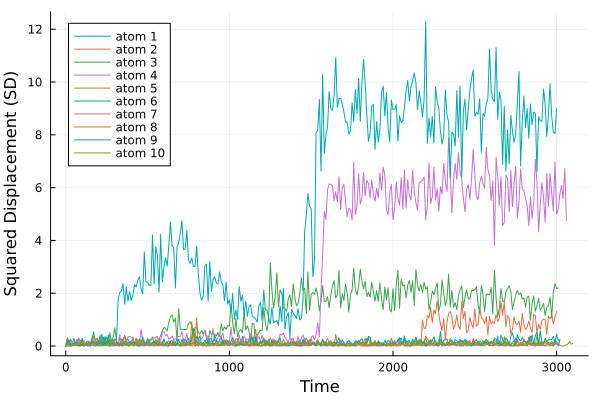

In [83]:
plot(dfs[1][:, :t], dfs[1][:, :dsq], label="atom 1")

for (i, df) in enumerate(dfs[2:end])
    plot!(df[:, :t], df[:, :dsq], label="atom "*string(i+1))
end

xlabel!("Time")
ylabel!("Squared Displacement (SD)")

> <b>💡 Lab memo prompt:</b> Inspect this plot and make some qualitative observations. Can you identify features in the plot that might correspond with aspects you observed while watching the simulation run? How does your plot compare to others'?

To estimate $D$, we'll take the average over all the trajectories and fit a line to that data...

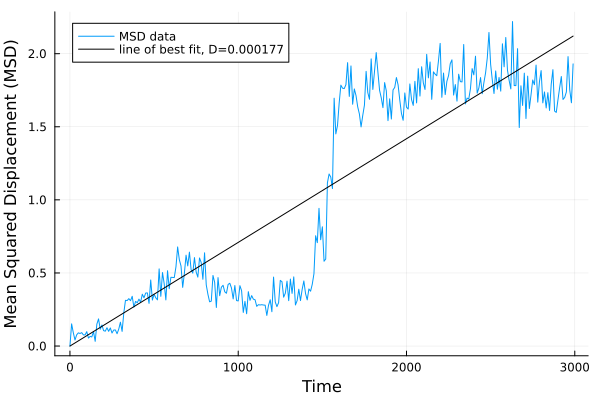

In [84]:
# trim to length and combine in one array
min_steps = min([size(df,1) for df in dfs]...)
tvals_singleatoms = dfs[1].t[1:min_steps]
dsq_mat = zeros(min_steps, length(dfs))
for (i,df) in enumerate(dfs)
    num_steps = size(df, 1)
    if num_steps > min_steps
        delete!(df, min_steps+1:num_steps)
    end
    dsq_mat[:, i] = df.dsq
end

# find line of best fit (we will force it to go through origin because we know MSD should be 0 at t=0)
msd_singleatoms = mean(dsq_mat, dims=2)[:,1]
D_singleatoms = (tvals_singleatoms'*msd_singleatoms)[1,1]/(4*(tvals_singleatoms'*tvals_singleatoms))

# and plot
plot(tvals_singleatoms, msd_singleatoms, label="MSD data")
plot!(tvals_singleatoms, tvals_singleatoms .* 4D_singleatoms, lc=:black, label="line of best fit, D="*string(round(D_singleatoms, digits=6)))
xlabel!("Time")
ylabel!("Mean Squared Displacement (MSD)")

Okay, so we have our first estimate of a nondimensional diffusivity!

> <b>💡 Lab memo prompt:</b> Take note of your number and compare with some of the other people in the lab session. How much variation is there? What causes this variation?

## Approach 2: Few snapshots of ALL the particles
The MD engine also allows us to collect data in the form of snapshots of the locations of ALL particles. Let's try that now. We'll do just one simulation, again for about 3000 timesteps, and collect just four snapshots: One at the start, and one every 1000 timesteps. To set this up, you'll just need to:
* Change "Data type" to "All atoms"
* Reset stats, and then manually click "Write data" to get your first snapshot. Paste that into the first box below. Again, include ALL the contents of the box!
* Run the simulation for about 1000 timesteps, pause, write the data, copy and paste into next box, and continue twice more. Make sure you note the $t$ value each time you pause and modify the numbers in the intervening cells!
* Be sure to evaluate all the cells!

In [85]:
t0 = 0.0 # you can change this if your first snapshot wasn't at the zero timestamp

0.0

In [86]:
snapshot0 = CSV.read(IOBuffer("MD state data
N = 2125
Size = 50
Gravity = 0.000
dt = 0.015
Steps per frame = 25
x       	y       	vx       	vy
1.499661	21.087435	-0.666452	-0.205237
2.482032	23.775309	0.063031	1.403022
4.554364	11.719999	-0.295708	-0.345182
5.556254	10.984793	0.132694	-0.773816
16.638634	3.263193	-0.421573	-0.052617
31.950024	3.546221	-0.919056	0.429431
32.004262	0.341170	-0.697161	0.671458
15.780138	6.098873	0.038402	0.015845
7.469147	12.010253	0.565023	0.120031
20.866386	7.870725	-1.209990	0.361233
28.717117	4.023252	0.768609	-0.298829
23.676424	2.602916	-0.179140	-0.494366
21.398465	3.722284	-0.125981	-0.610410
26.624920	10.306823	0.009294	0.472097
25.736260	9.468956	0.617902	0.794037
27.813461	11.425838	0.763718	-0.319346
24.547433	11.136670	-0.791493	-0.301090
19.848423	8.421998	0.435826	0.628310
34.897161	7.569908	0.402477	0.899407
33.054135	4.176821	0.698413	-0.487392
35.976455	8.003936	-0.669107	-0.995287
36.814799	5.297839	-0.616847	0.209067
42.011326	5.326319	1.068394	-0.449156
47.754825	24.419253	-0.195770	0.192829
42.750725	10.866759	0.812611	-0.718802
39.799704	9.333968	0.506937	-0.145521
48.443680	15.002570	-1.365517	-0.324794
47.554937	8.850151	1.340088	0.400441
45.637360	10.309707	-0.816840	-0.448921
48.521738	20.140170	0.685377	-0.721314
28.759703	10.908089	0.457499	-0.082278
39.697518	11.760289	-0.907799	-0.779892
41.760259	11.543684	0.035682	0.162215
35.831459	6.972032	0.282653	0.132807
30.635608	12.038457	-0.031788	-1.342019
46.609151	18.124983	-0.965667	0.013057
31.912892	7.103988	-0.252323	-0.079439
40.754396	12.311097	0.319242	0.462745
7.665462	13.125350	-0.734842	-0.260457
0.472327	13.843919	-0.106088	1.782407
14.694836	7.731381	1.913507	-0.164088
6.444736	20.586168	0.225225	1.562713
16.730997	5.433456	-0.337948	0.128888
2.665300	9.159296	-0.179965	-0.397459
16.479580	8.965738	0.805576	-1.071169
17.836528	6.182979	0.535594	0.370920
16.491644	15.939486	-0.775616	1.950104
21.580540	4.829366	0.222774	0.952857
21.323690	1.607947	-1.121255	-0.506550
23.846048	8.337771	2.251606	-1.336788
21.734478	5.910067	0.521752	1.290934
22.504376	3.289440	0.334374	-1.199987
20.740858	9.941404	0.793812	-1.279736
29.879666	7.103123	0.957582	0.472832
28.811023	12.073849	-0.190475	0.639773
25.617815	14.253857	-0.138265	1.121293
34.005703	9.411651	0.335567	-0.102858
36.032713	10.452441	-0.800699	1.383492
29.951192	10.466744	0.468420	0.268094
42.695795	13.248724	1.343231	-1.149305
30.630794	15.505929	0.723220	-0.414079
43.744681	12.573492	0.524298	0.461497
32.837380	13.514167	0.810959	-0.249312
34.946374	8.674967	-0.324768	0.945650
33.850901	8.237246	-0.253756	1.103002
36.917885	7.561191	-0.505421	-1.162976
48.747746	12.906430	2.309007	0.413147
35.924204	11.838922	0.754725	-0.215548
35.791226	5.925225	0.479273	-1.190965
33.820033	11.540188	0.134690	-0.618797
43.756443	13.805445	-0.550913	-1.266959
37.978986	10.578433	-1.464203	-1.411964
45.630348	18.472495	-0.845677	0.247799
44.752542	17.880697	0.961731	0.661681
41.648864	19.883320	-0.497445	-0.261210
46.695419	14.312434	-1.129082	-0.109188
4.464154	17.227217	-0.204635	-0.700354
1.449263	18.845365	0.935406	0.480938
11.667450	9.639887	-0.228618	-0.348060
15.716981	4.998143	0.708754	0.223281
9.744421	24.498851	0.463662	-0.059272
26.951172	6.603319	1.719618	-1.973592
14.553259	13.618375	0.548982	0.314879
15.903342	0.425492	-0.100223	0.497510
20.935078	8.874628	1.278600	-0.043411
23.808381	7.206933	-0.491284	0.136965
27.739341	16.370540	-0.094028	0.663736
22.763484	7.694490	0.064562	0.735020
25.826345	13.197929	-0.689060	0.454185
27.683303	3.613583	0.054024	0.005414
21.819410	12.927100	1.336066	0.951701
35.863441	2.510838	-0.295416	-0.311125
31.865227	10.381656	1.690323	-0.724354
16.499597	11.318003	-0.530654	0.825733
25.676898	10.725846	-0.673459	-0.362193
33.882254	18.537317	0.968352	-1.154318
25.865990	6.106273	0.759016	0.917664
29.742832	11.585934	-0.452516	-0.130756
31.036452	11.062896	-0.087766	-0.139229
32.769794	15.566920	-0.593876	-1.787315
38.861269	11.107217	0.020601	0.319459
39.795726	10.629460	0.478035	-0.985501
39.004220	7.509145	0.065506	-0.008436
41.774044	8.005733	0.216835	0.091158
46.663812	16.890964	0.924218	-0.485094
31.876267	4.552095	-0.906569	-1.732376
44.704446	13.248187	-0.162628	0.384714
46.576702	12.051165	1.072667	-0.723319
47.711440	12.714193	-0.457581	0.272276
43.737725	10.329528	0.497723	-0.756063
42.835990	15.876307	-0.645928	-0.334873
43.796671	20.892319	0.056591	-0.143817
40.550676	20.434280	-1.040291	0.450720
36.913719	13.632212	-0.864144	0.823664
7.669221	5.073226	-0.390969	-0.164511
8.376668	11.399991	0.177029	0.420419
5.337023	14.333108	0.976591	-0.764787
6.550858	12.607546	1.508853	-0.581953
12.548579	2.061925	1.694633	-0.054204
18.475285	3.009779	0.136626	0.264048
16.873163	6.733437	0.086392	0.204752
13.748213	7.154363	-0.211650	1.104669
20.849183	6.711565	-0.262293	0.451564
15.701282	1.482982	-0.154401	0.004237
11.560005	12.903310	0.242371	-1.402215
17.725626	7.282307	-0.724896	-0.286591
19.859902	7.294089	-0.746833	0.059814
26.809757	5.239346	-0.279707	0.182368
31.864991	8.191923	-1.338279	1.586577
28.852871	7.568911	-0.478710	-0.233106
29.651791	4.571354	0.140008	0.563445
18.858391	0.806893	-0.280858	-0.558607
29.709365	13.941281	1.533559	-0.825473
26.787947	4.244844	-0.964804	0.385749
34.903660	9.888056	-0.489672	-0.670642
28.845181	6.395847	-0.876536	-0.059559
22.737055	21.738468	-0.845926	-0.613965
36.791724	8.765575	-0.055721	-0.920524
31.947945	9.202759	1.636601	-0.877178
36.503210	17.969538	-0.260833	0.057196
33.926952	5.787325	-1.112619	-1.098615
33.670352	15.028567	1.417372	-0.032707
32.054172	11.633828	-0.060810	-0.581413
38.847467	5.297871	0.006794	0.674504
42.718717	12.074097	0.291419	0.147265
42.234518	6.450056	0.217121	0.139327
47.655336	18.637332	-0.202963	0.958988
41.745819	12.756058	-0.528399	-1.641476
44.773337	14.455531	0.735761	0.370003
49.668027	20.616348	-0.114959	0.340243
49.489563	24.738964	1.697258	-0.416515
49.491781	15.050186	0.095858	0.130306
15.464274	30.226382	0.153130	0.625538
5.757206	17.631403	-0.442067	-0.134039
14.839870	4.445467	-0.175209	0.171057
16.670416	4.414943	-0.383202	2.256443
19.738640	6.161621	-0.640408	0.568940
8.713018	6.772353	-0.276542	-0.752574
11.761674	8.542212	-0.765230	0.044790
8.595669	14.732996	0.817660	0.150357
6.498961	9.229914	-0.808111	0.344667
7.497936	8.431572	0.161728	-0.608312
15.543831	10.802446	-0.588137	-0.200504
12.857067	7.833110	0.577178	0.732854
25.910958	7.200902	0.186767	-0.425017
28.650490	13.212313	1.054669	0.295817
15.600673	13.051825	-0.521448	-0.731463
27.778101	5.939238	0.084348	1.278063
23.743859	5.944587	-0.245248	0.371034
24.571881	1.986573	0.006594	-0.435230
22.756002	11.261116	-0.478883	-1.673259
31.816565	5.720167	-0.149864	-0.401106
24.864612	7.727581	-0.905050	0.564721
26.639565	12.380873	0.301723	0.642377
15.685269	23.272544	-1.053224	-1.599981
30.769670	14.351773	-0.723307	-0.749015
36.830690	16.838212	-0.304970	-0.674589
37.709117	5.844483	-1.807937	-0.059377
43.769308	11.488089	0.033587	-0.932962
39.945333	3.626859	-1.012283	-0.366701
24.739633	10.034629	0.523529	-0.809775
32.862577	8.655935	0.688922	1.142327
37.968910	9.317803	1.455528	-0.127397
37.819132	13.042870	-0.025512	0.442218
40.005820	8.196281	0.021188	0.546970
44.659968	21.602830	0.946459	-2.150107
48.785399	17.974455	-0.267319	-0.661328
40.803803	9.836568	0.667222	0.414067
38.731654	18.191790	-0.464692	-0.244426
42.408571	32.798857	-0.247922	0.621799
8.562947	13.619972	0.072657	0.607925
1.725395	8.766029	0.244704	-0.397387
6.398144	13.815661	0.231118	0.358892
8.749177	15.908063	-0.064026	-1.227140
8.544458	7.901672	0.144514	0.752598
8.621340	5.597833	0.639943	0.274405
6.653621	6.679711	-0.222238	0.317688
13.555867	13.132076	0.613400	0.191593
14.725075	8.981452	-0.125081	-0.387083
24.950708	5.479770	-0.436039	-0.212681
14.758415	3.401034	1.244872	0.352786
17.603481	14.286541	-0.284654	-0.531714
11.775491	19.973343	-1.034354	0.522131
17.728654	8.494533	0.403924	0.347462
20.701051	13.458070	-0.559298	0.542888
21.794522	18.750033	-0.481423	-0.403141
30.989950	8.721777	-0.991002	-0.161835
30.942455	9.882064	0.176911	-0.430386
24.830432	6.566525	-0.391994	-0.908202
26.738645	15.802581	2.305139	-1.721971
17.468730	15.463002	0.567491	0.717431
18.461183	13.636433	0.666040	-1.122174
25.710871	15.310225	-0.612054	-0.796575
28.750423	14.491663	0.246349	0.213338
34.924813	3.136514	-0.334949	-1.872011
31.629875	12.750243	-0.908310	-0.001025
35.818805	9.389617	-0.557664	0.369022
31.695331	20.921999	0.901274	-0.025869
37.765678	19.917618	0.026280	-0.168858
38.951296	14.741163	-1.581965	-0.177356
32.916293	5.378569	0.135213	0.698602
47.667223	20.867821	-0.740533	0.083271
44.675747	10.984196	-0.019950	-0.447440
37.779397	17.294360	0.125307	0.525733
32.906019	11.002071	-0.039685	0.904183
49.622685	21.908760	-0.041428	0.174857
30.029928	8.276150	0.193458	-0.588344
40.877066	15.725152	0.476621	-1.095605
13.806816	18.746071	-1.459975	-0.564133
6.640510	11.440990	-1.098128	-0.709370
7.501504	15.392754	-0.010568	0.358671
9.375705	11.830802	-1.384847	0.623808
11.526145	3.840094	-0.700646	-1.179304
3.617109	8.631300	0.914546	-0.644023
5.585351	18.679124	-0.243506	1.431876
7.608855	7.350022	0.608091	1.060066
19.512610	3.549040	0.907210	-1.253586
9.555863	7.623519	1.284500	1.076039
15.631599	11.888460	0.981103	-0.268328
16.514482	12.571602	-0.540035	0.990571
18.080542	1.708315	-1.634433	0.373736
20.706341	25.147192	-0.707403	-0.054795
20.769336	11.159988	-0.391876	0.710607
14.543967	11.399936	-0.168679	-0.549197
10.680582	9.056884	0.747397	0.119448
18.684181	7.827617	0.500833	1.326571
15.583585	15.298951	-0.691116	-0.923609
21.718362	10.797527	0.744559	0.678651
28.926660	1.917385	0.808271	0.586915
34.716624	16.764140	-0.405771	-0.241326
31.631730	18.536485	0.977789	-0.615481
22.758980	13.576793	0.162309	-0.053560
22.724261	19.278971	0.216690	0.742623
35.765786	17.159838	-0.303699	0.939425
38.551339	23.745941	0.108321	-1.170105
24.732987	8.855693	0.374656	-1.484791
38.700913	12.343954	-0.953632	-0.719985
29.573854	20.999840	0.356622	-2.077863
24.793579	14.836071	1.716775	-0.687074
29.665745	12.724534	-0.019610	0.177243
31.771085	13.793009	-1.165251	-0.370689
34.905480	13.480233	-0.709453	-0.593397
41.750360	16.211997	0.488934	0.185017
38.829428	9.894170	-0.813303	-1.512750
36.966499	12.384625	-0.170684	-0.262593
35.679628	16.202996	1.320966	0.142000
6.567728	21.617611	-0.491994	0.629617
11.510643	11.839803	-0.871066	-0.467561
5.651348	6.178648	1.210199	-1.108521
17.759192	5.141050	0.232860	-0.826068
8.411813	10.239627	0.347386	-0.383485
6.577867	14.878205	0.676280	-0.085338
1.483105	16.610613	1.093638	0.899887
5.674614	5.133626	-0.152577	-0.739669
13.353231	29.228717	1.105013	-0.207472
9.627759	15.120640	-0.048622	-0.813716
5.635930	16.451796	1.213881	-0.491962
23.681660	4.815137	-0.548900	-1.587318
10.512136	11.167942	0.277727	1.113002
18.806800	4.297242	-0.357471	0.667076
20.454794	4.376821	-0.174966	-0.107196
19.714444	25.601239	-0.148522	-0.469319
18.801326	8.969589	-0.624634	1.463923
19.699359	13.964924	-0.475238	0.842701
21.606582	11.841278	-0.393882	0.385575
22.767329	8.864804	2.052960	1.109951
25.869737	8.289457	0.008883	0.580722
26.688998	14.696526	0.340474	-0.319327
25.682206	11.836684	-0.449518	0.587576
29.706715	19.900253	-0.098447	0.697353
19.582518	17.743204	0.921664	-0.306947
30.857369	5.207084	0.108791	-0.437530
28.587601	15.792163	0.040345	-0.458490
25.698672	18.925161	0.794134	-0.430429
31.649822	15.114256	-0.326607	-0.146339
32.675339	18.111385	-1.019804	-0.072505
34.939328	5.328651	0.303241	-0.015429
34.044428	12.798951	-0.202200	0.931145
33.581181	17.420453	0.667975	-0.663458
41.769226	15.163749	0.069430	-0.609487
30.970182	7.640069	-0.661252	0.239835
36.648758	22.623525	0.585023	1.539499
44.831795	22.644708	1.343057	-0.951797
44.425153	32.969319	-0.994377	0.639524
4.435056	21.716792	-1.519235	-0.618965
5.658665	7.279398	-0.660766	-0.472175
8.513198	12.589763	1.036162	-0.823586
5.297500	15.481037	-1.866521	-1.826427
10.333317	12.284427	0.439471	0.030631
0.367901	16.008195	0.917912	-0.173310
12.721658	15.921650	-0.242109	-0.826431
2.432749	21.684795	-0.311498	1.325793
15.685787	19.944223	0.692407	0.311231
7.532124	20.127417	0.537359	1.549166
15.340940	27.933831	-0.946534	-0.084582
16.686106	13.706595	-2.230778	-0.334381
9.843940	16.363260	-0.958134	0.656539
17.664344	9.592925	-0.772273	0.181187
10.523168	10.115514	0.518406	0.589268
7.660643	24.608556	0.508192	-0.218240
20.595992	15.898799	-0.207609	-0.945362
28.045428	8.177691	-0.511034	-1.550939
20.654059	17.245727	-0.250892	-0.999263
18.690389	14.730599	-1.063436	1.598857
17.527771	11.986419	0.878443	0.884919
26.604934	11.317180	-0.315998	0.305484
20.763185	18.411440	-0.028704	0.592479
13.617052	9.676772	-0.559127	-0.300784
31.674243	16.221527	-0.057818	-1.696640
22.672891	10.095796	0.025845	-0.518031
38.232745	1.522814	-0.202294	0.034588
29.731073	14.952471	-0.280854	-0.356255
32.568410	14.503539	-0.033789	-0.354704
34.774617	17.876639	0.055889	1.610578
27.647128	15.260768	1.109746	2.409419
33.752708	10.526686	-1.366503	1.575592
35.778128	20.991467	0.885414	0.694625
24.563906	12.306815	0.125791	-0.237163
40.685306	11.167272	0.051618	-0.847571
37.807415	16.235572	-0.721171	-0.104998
36.815864	14.638338	0.545815	1.715108
37.564030	18.477005	-0.189026	-0.375146
2.481829	20.544124	-0.477772	-0.501224
7.963963	16.663269	1.391114	-0.177820
3.714081	27.776299	-0.760189	0.952989
11.649676	24.513363	-0.044507	-1.061965
16.669812	7.907485	0.278779	0.520968
5.698855	12.029840	-0.121906	-0.389824
12.610964	10.160591	0.966979	-0.660658
7.705283	26.617201	-0.243010	0.623794
9.442364	10.809265	-0.021191	0.706128
11.709875	10.830894	0.226635	1.344262
9.650943	8.604270	-1.322614	-0.458305
3.365184	17.664821	-0.826647	0.294192
18.481971	11.446519	1.881601	-0.505992
7.512833	21.216285	-0.669886	-0.182146
14.585026	12.489175	-0.181662	0.523586
18.872961	23.021971	0.183602	-0.448528
15.844610	7.147133	0.240685	1.229607
17.546844	13.058298	0.162873	0.536725
24.715735	18.124472	0.626884	0.079189
19.797412	15.165149	-1.063684	-0.011280
22.821381	18.065007	0.527048	-0.076378
18.678307	17.105968	0.513898	-1.043553
29.569672	16.174579	-0.276100	-0.138219
26.998713	7.870176	0.128651	0.824329
21.017064	21.773622	0.388576	0.914212
27.437043	24.286361	0.936555	0.548772
19.684114	5.033464	0.436025	-1.114836
35.818125	15.123472	0.089322	-2.257935
33.611196	19.672036	0.081643	0.356235
27.509719	20.955317	-0.361716	-0.661936
32.721711	16.627469	1.548318	-0.801412
28.764975	16.876711	-0.162176	-0.180316
38.804321	17.006754	0.568892	0.208782
43.731576	17.481481	0.601418	-0.278571
44.698498	24.915330	-0.915204	-0.956969
40.817912	16.936390	-0.995254	0.199586
42.322764	30.554043	-0.182512	-0.484527
42.779339	21.486326	-0.461141	1.427143
12.668523	39.950670	0.548214	0.258772
10.667726	14.538209	0.341649	0.149617
12.694702	8.895810	0.225507	0.780040
3.421007	19.973369	0.000375	0.543456
3.332515	26.757254	-0.633723	-1.008496
0.473180	24.909006	0.835519	0.193439
12.786519	6.690628	0.183653	-1.100457
11.644714	18.870663	0.758345	-0.897055
9.553822	26.759581	-0.763450	-0.016271
8.798550	18.542190	-0.983323	-0.897438
17.783264	22.374629	0.330660	-1.559024
8.682849	23.917159	1.179049	0.027592
13.618869	14.238152	0.136450	-1.105242
8.711061	25.039872	0.444059	0.030207
8.476147	20.622972	0.674037	0.726672
19.672363	9.590699	-1.459043	-0.399366
14.565559	10.255853	-0.081721	0.539780
18.545654	12.530561	-0.461336	-0.134813
21.626413	14.057567	0.330726	-0.909265
20.645896	12.367282	-0.325390	-0.575524
13.745430	8.501760	0.141437	-0.755066
14.725055	19.247366	-0.392645	-0.957311
17.640676	17.748210	-0.728838	0.508438
24.862533	21.561278	0.032870	0.339481
27.575913	26.531545	-0.615399	0.251032
24.979623	17.106514	0.580982	-0.483592
40.745794	25.008037	-0.772837	0.109008
37.792844	11.653435	-1.379396	0.971920
23.681791	12.912296	-1.251592	0.923557
38.679344	21.575041	0.085653	-0.517512
31.888026	17.348388	0.013642	-0.830792
36.823154	19.251823	0.457907	-0.808829
34.731972	22.456989	0.112408	-2.128984
25.561120	22.365874	0.230127	-0.062879
45.830219	23.097810	0.346655	-0.081324
43.510233	29.022222	-0.042253	0.250062
42.782230	16.893741	-0.610991	-0.542710
40.589276	28.264877	0.670121	2.043155
4.705028	27.409930	0.614317	-0.587651
6.871223	17.330527	-0.273909	-0.088476
2.647524	27.571713	-1.774113	0.343867
10.747480	19.402068	-0.445168	-1.052848
8.760909	19.606495	0.853649	0.121702
5.628731	25.610064	-0.979762	-0.562016
11.542245	15.158542	-1.418302	0.162588
11.499945	26.901057	-0.101581	0.122366
16.776892	18.347195	1.215484	0.632725
11.406869	33.800479	0.159020	0.343911
12.382733	31.971280	1.000503	1.042843
7.420460	1.691651	-0.509182	0.249851
4.549400	24.017311	-0.772842	-0.128717
8.569865	27.196379	-0.023781	-0.018502
4.419986	14.929703	-0.426994	0.654709
17.826671	20.016160	0.734994	-0.523405
10.559742	13.341702	0.859621	-0.123168
27.799265	9.239135	-0.016902	-0.292522
17.528607	10.806606	-1.397303	-0.499935
13.527890	15.255228	0.280180	-0.128690
26.759302	19.283318	-0.068687	-0.228545
18.600921	10.284549	-0.444795	-0.444935
24.649151	19.230029	0.150549	-0.484164
21.734545	22.441034	-0.350962	-0.785014
34.829341	14.537972	0.954741	-0.211821
37.583599	23.107776	-0.666989	0.905476
21.321592	30.412648	0.010887	-0.760759
21.481032	15.320168	-0.744687	1.022397
30.884638	17.851176	-1.449369	-0.171584
37.687243	22.137657	-0.604389	-1.122287
33.816454	13.878055	-0.322549	-0.271376
39.817244	14.039611	0.803771	0.961517
38.563595	22.661390	1.732031	0.658949
40.643502	21.573346	-0.344409	-0.585774
41.753151	18.841030	-0.586025	0.459352
32.673041	19.173264	-0.472016	0.602600
40.650710	23.861674	1.437388	0.057636
43.422362	27.861147	-0.708784	0.259281
2.511634	18.300028	0.506804	0.272902
6.570401	19.444181	-0.551352	0.161796
4.514371	18.311850	-0.385513	0.194522
2.524590	29.780286	0.553661	0.530658
8.422040	30.745440	0.066244	0.414100
17.406669	30.182766	-0.082233	0.451415
2.410805	17.160415	-0.222936	0.143815
11.867455	17.699923	0.571931	1.060315
13.741648	17.639391	0.741935	-0.586495
10.455721	28.563971	0.856215	0.867630
6.695946	18.309041	-0.075097	-0.208128
9.772474	17.492578	0.091574	0.235439
11.736738	14.064134	-0.218155	0.426131
14.709368	15.856088	0.153894	-0.365927
13.634236	12.052103	-0.575216	0.687104
18.302226	28.398636	-0.079875	0.042207
27.624456	2.469682	-0.316643	-0.458882
16.633917	17.117158	0.589049	-0.095925
21.783673	17.664510	-1.353738	-0.391563
18.540093	15.828530	0.530480	-0.025293
19.720542	11.815676	-0.455487	-0.812408
16.904257	21.696085	-0.619864	0.287981
23.933270	14.233309	1.204664	-0.364631
23.596915	16.316074	-1.578727	0.265923
25.757713	16.439476	-0.341057	-0.472203
30.545314	23.777507	-1.335120	0.131084
40.523824	27.152787	-0.647854	0.621575
34.627018	21.412057	-0.056704	-0.244639
30.549812	20.491959	-0.269579	0.703785
48.538804	26.262399	0.480881	1.296152
45.591626	26.606973	-0.574016	0.634746
39.749268	19.549101	0.957995	-0.242704
34.757578	15.559129	-0.275024	-0.120909
49.259590	29.099142	0.881287	-0.450925
47.541591	25.479178	0.171598	0.193680
44.405046	31.885195	0.243404	0.208661
47.480466	26.675892	0.190538	-0.061089
36.830582	11.178390	-0.529630	0.041536
7.874490	17.898889	0.881506	0.355057
6.640198	16.232637	1.324406	-0.211007
9.781978	25.621954	-0.711148	0.131670
3.487456	24.594917	-0.237725	-0.273962
9.567976	29.091462	-1.266091	-0.812278
13.291485	30.329888	0.106678	-0.610483
6.555472	28.493265	-1.217911	0.519526
12.887366	18.156903	0.782017	0.045164
7.537940	23.554509	-0.114143	-0.813471
11.516583	28.083135	0.781747	-1.245005
20.648144	26.157359	0.140034	-0.054365
14.723947	20.501503	0.245083	0.838402
11.760799	16.520263	-1.966939	1.021610
15.615545	8.264948	1.026781	-0.131795
15.875308	17.773979	0.042605	-0.975507
9.784263	18.896579	-0.119994	-0.214234
16.639071	10.082022	0.852865	0.230416
21.863125	8.302075	1.341980	0.858969
21.688720	24.608061	1.022701	-0.098175
22.343082	30.946416	0.740181	0.075589
17.568116	16.603014	-0.455258	-0.190074
19.720203	20.101123	-0.865764	-0.770433
28.692285	20.318215	-0.361614	-0.329209
26.774307	18.131239	-0.115626	0.041848
31.608818	24.391400	0.941880	0.743029
21.599853	23.529754	-1.032988	0.625321
21.843181	21.156852	-0.640167	-0.195826
39.554461	23.270828	-0.213599	0.921936
34.965690	11.058862	0.995902	1.187674
32.551823	20.308246	0.910929	1.743410
36.694760	23.807163	-0.321338	-0.545619
38.884264	20.409809	0.851706	-0.651338
27.676787	17.418973	0.610303	0.820712
39.688319	18.512154	1.383565	-1.077050
36.868259	20.444514	0.981494	-0.886652
38.900476	15.848992	-0.337699	0.750401
36.612513	29.378099	-1.354417	0.210967
40.540483	34.018553	0.112320	-0.727903
3.601594	28.994992	0.210855	1.325238
6.455154	36.663362	1.408388	0.593640
8.648078	29.529177	-1.837479	0.001000
5.422882	26.688201	0.611824	-1.248956
9.390245	21.219207	-0.153273	-0.322066
12.311713	30.827128	0.888450	-0.147974
11.381938	31.471446	-0.144585	-0.824907
14.382272	29.798684	1.139383	1.341124
10.637742	26.204383	-0.332885	0.171157
17.657105	18.930269	0.747249	-0.115804
16.361867	30.856682	-0.569202	0.533551
12.815936	22.742558	-1.276212	0.506515
12.684750	20.580405	-2.006962	-0.983897
10.709914	18.256881	-1.074945	-0.188480
14.684949	17.047720	0.079835	-0.190591
16.834939	20.582415	-0.770013	-0.478882
13.754130	19.876512	-0.876650	-0.950170
28.971114	8.635228	1.253714	0.937656
16.696238	23.996986	0.520610	0.347473
28.521559	24.881892	0.340153	1.902368
18.817195	21.905373	0.192681	2.381007
23.594171	29.113786	-0.510180	-0.926248
29.600130	25.628012	-0.103154	0.170505
14.655157	25.057010	-0.434398	-0.933748
24.792292	13.478865	0.482939	-0.360248
21.553400	16.534664	-0.565367	0.052696
34.834033	20.326544	-1.087571	-0.138109
23.618667	25.675191	-0.167408	-0.219396
26.637834	20.341113	0.190780	0.953483
42.467347	28.359716	0.130094	-0.483834
45.441669	32.366676	0.014129	-1.207348
24.617580	20.436929	-0.894993	0.505930
40.716918	19.271008	0.085132	-0.284340
46.633894	24.799761	-0.614435	-0.772547
39.857481	16.288088	0.277455	-0.027801
43.498215	23.336118	0.198406	0.790888
39.549254	24.340130	-0.891628	1.097460
41.498057	33.384187	-0.542464	-0.084179
4.582428	28.448284	0.370463	-0.739704
11.756647	23.442673	0.102892	0.766364
3.333822	40.589551	-0.687203	-0.937680
4.314294	20.586730	1.428325	0.347666
8.597544	26.132508	0.066467	0.619019
15.809701	18.878032	-0.722000	-1.708571
9.540948	27.910276	0.288363	-0.108710
12.659097	26.322700	0.992923	-0.066395
19.603289	24.568081	0.226903	-0.168482
13.801292	22.325730	-0.462533	0.653345
13.422927	31.507144	-0.267126	-0.534210
10.785409	16.862423	1.058833	1.347562
12.600390	27.416515	0.627059	1.206167
13.681511	16.589008	-1.111455	0.303925
14.540584	14.740494	0.349815	0.661992
3.713521	31.333029	0.538902	0.583002
7.526041	22.415720	0.392273	1.126106
17.940402	21.212462	0.901381	0.352101
21.637858	19.955060	0.443979	0.686317
27.549662	23.102914	0.181849	0.308200
23.711600	17.508127	0.252635	-0.805950
22.589453	16.955563	-0.016534	0.089024
22.559813	28.682991	0.536146	0.542064
20.709920	14.491206	-0.033028	0.015090
35.899204	14.004977	-0.547765	0.004068
27.728140	18.657531	0.628015	0.943087
23.676734	21.084075	0.952493	1.117195
24.606079	22.822119	-0.209225	0.231057
29.863539	17.517993	0.564880	-0.272399
28.510918	23.685560	1.047180	0.956240
35.750099	22.114447	-0.016558	0.652007
41.846872	17.401850	0.885927	-1.003555
30.712982	13.283135	0.209242	-0.121329
34.947749	12.155170	1.225702	0.258778
48.710097	24.057299	0.125924	0.205073
48.367469	30.774355	-0.207649	0.537495
46.687009	20.339569	2.189238	0.472722
47.676145	21.902306	0.500828	-0.764715
7.729717	19.040052	-0.205657	1.339442
13.592957	33.744426	-0.357805	0.626857
13.701900	24.587728	-0.074991	0.863483
10.785204	15.899960	-1.210541	1.350998
7.575288	25.618485	0.068670	0.680239
12.328082	29.723432	0.417528	-0.476182
12.775201	23.974123	0.892186	-0.692456
12.502242	14.768114	-0.739534	-0.887429
9.830402	20.123058	0.671706	-0.532353
19.673654	27.785445	0.641567	-0.184281
16.272774	27.323753	-0.543243	0.948278
14.456320	31.912268	0.408048	-0.280845
14.394347	36.570972	-1.856758	0.771025
12.663224	12.558309	-0.933246	1.040611
23.830691	22.181744	0.130761	-1.229412
15.872501	22.220923	-0.269582	0.406627
18.864979	20.798865	1.026220	-0.778161
16.715882	19.542408	-0.887831	0.508387
18.560206	18.300615	-1.053325	0.143652
19.630860	16.493840	-1.121543	-0.050547
19.835557	21.366487	-0.975520	0.276284
17.532497	26.961419	0.357776	-1.368003
26.460048	25.138890	-1.737436	-0.935732
23.900668	15.325608	1.028310	1.080017
30.643554	28.389286	-1.399337	1.330761
13.655372	23.447342	0.379610	0.182270
28.617081	21.445530	2.036045	-1.502735
32.613399	22.552483	-0.538528	0.093973
30.711063	16.699486	0.096591	-0.886957
31.548752	22.072414	0.173297	-1.212547
30.667546	19.336533	-0.910581	-0.899260
27.651653	21.967829	-0.072599	-0.543547
29.571275	22.133064	0.318827	-0.284543
42.713136	20.381650	0.261888	-0.153642
46.810287	22.504659	0.584073	0.316666
40.514478	22.734644	0.257127	-0.528071
43.316103	33.440065	0.071600	-1.783446
42.475146	31.750144	0.677343	-1.006022
10.493061	29.797413	-0.292413	0.412506
7.418089	30.293347	1.119427	1.155921
1.366417	23.299339	-0.467977	0.420091
19.606216	26.626851	1.515446	0.609761
10.731288	25.099882	-0.170181	-0.025657
14.240405	30.912980	-0.230622	-0.424870
18.518867	37.608887	-0.911556	-0.595319
23.657016	31.420559	0.417740	1.269498
17.522126	35.924408	-1.916271	-0.147611
19.589873	12.877765	-0.687740	-0.284268
12.706871	11.465789	0.739989	-0.784175
10.820915	22.758279	-0.948870	-1.003505
12.798378	21.675301	-0.457715	0.177962
16.532542	14.825316	-0.136334	-0.928472
12.806179	19.376669	0.532540	0.823206
25.611416	20.035382	0.449169	0.449646
19.800637	23.536327	-1.228913	0.400944
22.516529	15.937997	0.404755	-1.657548
25.797188	33.533020	0.012659	-0.171982
20.592752	19.554476	-0.951500	-0.867086
28.710912	19.278785	0.223350	-0.309174
24.708568	27.388520	1.553442	-1.046023
24.549086	26.306749	0.099687	0.129500
23.644313	10.556919	-0.122904	0.276009
28.588252	17.990041	0.516614	0.422950
26.497588	22.847084	-0.945640	0.020535
26.375391	24.016193	0.035329	0.814647
29.573239	18.591351	0.074395	1.173626
32.776678	21.429277	-0.553604	0.315242
33.795286	26.653645	-0.659186	1.220727
32.896693	9.807218	-0.354863	-0.744232
32.804980	25.972108	0.699331	-0.397762
41.548204	27.821812	-0.165190	-0.235830
44.822177	20.539620	0.004567	-0.215714
44.851774	19.326125	1.500463	0.485732
34.744023	23.712700	0.244847	0.646210
35.769890	27.794372	-1.026836	0.651984
41.693917	20.841089	-0.572418	-0.344250
10.251141	34.522503	-0.008376	-0.264687
14.547846	33.151228	-0.088887	1.213305
16.399252	32.049143	1.126527	0.833371
13.530358	28.063778	0.873149	-0.114607
5.457613	23.413598	0.220496	-0.605997
9.463951	35.108315	-0.867340	0.314083
22.572868	27.512604	0.132593	-0.415554
15.587023	34.863223	-0.139316	-0.070597
20.652312	33.086718	0.898297	0.321821
11.714374	21.097480	1.237337	0.349147
10.738036	20.549771	-0.730803	-0.061009
14.353028	28.719363	-0.467856	-0.230980
22.808997	22.745003	-0.288025	-0.456513
14.986986	21.628938	0.157049	0.295832
22.752605	14.786065	-0.530263	0.867656
15.572009	14.082289	1.603303	-0.089051
19.790891	18.882947	-0.555862	-0.676334
17.707895	25.575268	-0.567164	-0.992112
18.624079	27.272801	-0.522401	0.892027
23.586687	23.290269	0.493817	-1.263240
14.650562	23.982168	-0.294476	-0.028588
25.571173	30.209978	-0.136202	-0.017019
23.584536	24.509130	0.172650	-0.509520
25.872288	17.569623	0.281654	-1.633099
20.626060	20.695706	-0.166885	-0.536074
31.744306	23.166380	-0.381200	1.606922
26.759257	16.981137	-0.618831	0.559907
22.605303	25.203258	-0.110518	-0.322377
33.684043	28.000968	-0.342256	0.448365
31.666993	25.521656	1.038740	-0.121744
14.801836	22.698050	1.055387	-0.834973
27.784275	12.553922	-0.249314	-0.244739
32.774793	23.619547	-1.544623	0.061209
35.712722	23.250429	0.328289	0.153995
40.529449	26.016337	1.423599	-0.445571
42.750864	18.259210	0.405252	0.848704
48.575694	25.132024	1.318522	-0.209778
43.675199	24.451842	-0.309839	-1.494793
8.456924	21.716458	-0.536574	-0.111681
2.615799	35.218239	-0.414079	0.548327
13.502615	36.085375	-0.282127	0.359440
18.662370	39.954851	-1.348263	0.325109
15.599944	38.207002	0.743984	-0.053676
10.447032	30.917759	0.086901	1.196484
16.691100	33.150371	0.040704	0.475505
22.567040	29.724929	-0.104105	-0.235458
11.228280	32.687801	0.108365	-0.096638
18.317537	29.527564	0.596612	0.099402
10.745168	21.638998	0.470574	-0.834044
27.763785	14.101407	0.588164	-0.702042
8.720296	22.714513	0.763007	0.604768
16.650031	25.055520	0.800463	0.761010
23.667337	19.841690	1.057573	0.877469
27.510712	25.367257	-0.609856	-0.767904
18.706576	19.348877	-0.029980	0.318817
21.536644	26.894760	-0.393887	2.311530
15.720795	24.510216	-0.457384	0.698452
22.684213	20.428767	0.617600	0.209291
27.655399	27.824383	0.357617	0.170633
32.911542	27.243647	-1.139223	1.142757
30.593415	22.717246	-0.856845	0.942505
27.747230	30.139811	0.301368	-1.055192
29.529704	26.596192	0.085134	0.266500
30.532793	21.601872	0.322190	-1.524787
28.685077	28.338381	-0.474889	-0.612553
33.755771	24.163431	-1.200572	-0.187351
35.778641	26.606269	-0.634939	0.155595
34.824830	26.150453	-1.072104	0.972586
37.586922	27.712172	0.169366	0.225386
41.518960	23.209641	-0.216852	-0.130200
19.746590	22.413555	0.195852	-0.588650
39.560432	26.539649	-0.030394	-0.957149
31.793290	19.590185	0.236941	-1.090960
49.541557	25.798901	0.217423	-2.402227
41.655663	21.974715	0.864098	-0.100653
39.946465	17.442307	-1.420662	-1.381958
9.375758	41.696034	0.371030	0.566390
6.622885	39.999953	0.579172	-0.385497
5.616917	27.743486	-0.945838	-0.644325
15.486848	32.564358	-0.300136	-0.041948
12.642379	41.190814	-0.822951	0.650946
13.587302	26.825005	-1.093389	-0.294899
13.550666	34.911031	-0.194695	-0.990284
16.464796	36.464319	-0.481732	0.045502
18.676877	26.121685	-0.012907	-0.363089
15.374571	31.248321	0.360300	1.132348
16.729328	26.159797	-0.417891	0.334315
15.867448	20.986862	-0.965649	0.954467
23.536562	26.771085	0.002743	0.186364
23.748658	18.709334	0.095101	1.017604
17.226593	28.984665	0.594011	0.296212
14.850264	18.193951	0.107709	-1.366774
27.604051	32.499565	-0.507253	0.180015
22.562202	26.383717	-0.724963	0.113822
34.583494	29.563293	0.214212	0.479493
26.497210	26.161477	-0.998048	-1.428742
18.631349	25.082423	0.025277	0.325610
25.688805	21.083027	-0.847091	0.856031
34.681653	25.009641	-0.753592	0.477497
44.567370	28.350952	-0.238169	-1.168689
45.601896	37.179862	-0.108167	0.316121
38.707773	38.597575	0.150908	0.243799
41.414946	36.945871	0.446638	0.046453
38.539512	30.674721	-0.908741	1.008635
25.519484	24.570094	-1.326929	0.218523
41.495679	26.604280	0.590964	1.076690
24.471654	24.000045	-0.168129	0.069311
36.749469	21.481285	-0.153117	0.392272
28.504678	22.546858	0.329766	0.110643
42.601377	26.076434	0.706616	-0.132056
36.421740	31.527319	0.048527	-0.001653
43.277909	30.034155	-0.064526	0.361412
45.633859	24.233606	0.013165	-0.191032
37.718778	21.108955	1.264465	-0.524921
6.518100	31.883114	0.292681	0.428901
2.592079	33.062660	2.101601	0.164790
13.475350	38.263126	0.122243	-0.486826
12.247117	38.958160	0.121068	0.408934
12.320170	33.150817	0.159947	0.627758
11.417872	30.336946	1.632722	0.284531
17.252001	27.913935	1.441375	-0.342296
12.689352	17.016161	-0.500487	-0.306580
14.628987	34.230381	-0.948776	-1.562833
19.406256	31.348552	1.909103	1.015258
18.668312	34.081123	0.068734	-0.125740
15.697889	16.590510	-0.062914	0.425583
21.670116	27.975323	-0.844535	-0.994441
27.601800	29.009881	-0.845737	0.797572
20.723787	24.053988	0.418919	1.199757
30.561961	26.081320	0.170090	1.041207
25.512944	34.673185	-0.005158	-0.164546
18.706463	24.072513	-0.597456	1.414772
27.659683	39.494648	-0.151309	-1.356135
21.611359	29.117344	0.100601	-0.723351
30.541968	29.542937	-0.498653	-0.337789
23.415824	30.354063	-0.085810	-0.884792
29.613006	24.449688	-0.425310	0.304969
22.641689	32.051213	0.249409	-0.011699
37.532867	33.394973	1.203346	-0.430156
37.680309	26.655816	0.164017	0.695594
26.528055	21.735575	0.442317	1.510660
42.607057	44.366420	-1.125441	-0.879274
42.730110	24.950565	-1.007430	0.520451
44.554961	26.165260	-0.149889	-0.993012
49.569695	26.890409	-1.139388	0.948428
39.494426	27.781286	0.434587	-0.209843
39.631766	22.101582	-0.673638	0.275614
42.720446	38.641150	-1.418555	-0.440298
38.543486	24.891169	1.598456	-0.073258
43.374666	32.317250	-0.481347	0.683400
41.466338	28.907696	-0.738606	0.717594
34.622768	32.078024	0.180015	-1.536967
15.413959	35.967006	-0.507198	1.420614
11.627039	40.564280	-0.924292	-0.236499
9.476516	30.227205	-0.359765	-0.182382
14.439958	37.906502	1.051915	0.029972
18.514187	30.626601	-0.565757	-0.532339
8.958328	46.798403	-1.009793	0.506683
17.715408	40.540615	0.299555	-0.120018
12.602395	43.417643	-0.095435	0.290370
13.609672	25.657586	-0.499760	1.089754
13.781788	21.246458	0.044740	-0.625945
20.483335	28.542763	0.030420	0.465487
11.635135	25.659368	-0.074669	0.145816
12.490071	34.303067	-0.451622	0.233338
16.662948	22.825717	-1.028179	0.573011
25.666358	26.868888	1.096249	0.633101
18.474266	35.293331	-0.151947	-1.153914
30.764656	38.841659	-1.356619	0.063654
10.695203	23.998311	-0.211130	0.623269
27.507652	34.813157	0.418175	0.423541
36.809536	38.669993	-0.280000	1.066584
45.727462	39.406122	0.490269	-0.376090
25.447336	23.449424	-0.939238	0.091767
33.667768	25.376252	-0.298813	-0.917437
21.445266	35.800081	0.468789	-0.071736
24.609098	28.574683	0.275948	1.135719
37.587097	34.483142	-1.370050	1.290450
42.645633	35.274437	0.945334	0.579743
25.577332	28.949360	0.652141	-0.138394
42.429346	46.816797	0.015561	-0.367205
49.270117	30.115731	-0.168191	-0.479328
41.666886	24.438094	-1.317435	-0.390949
38.565336	29.456692	0.011037	0.887957
43.800084	22.190294	-0.157851	-0.604039
41.462053	29.961273	0.579087	0.542315
31.558980	28.911416	0.298039	0.045787
39.495742	39.408202	-0.133638	-0.000936
43.766736	38.184843	-0.338966	0.815311
37.624772	28.971821	-0.012508	-1.046844
16.722961	37.631190	0.845990	-0.540113
3.623225	33.564258	1.196502	-0.856927
21.795407	40.614155	-0.419133	-0.517237
8.388522	38.835116	0.838548	1.697026
11.510879	36.036595	-0.390844	-0.346079
16.653756	43.521256	-0.131729	0.271213
18.466182	31.817798	0.664828	-0.129277
21.348657	31.494231	-0.678351	0.226287
21.663977	25.842418	0.260029	1.194031
18.626673	33.011767	-0.463104	0.763462
26.760724	27.242566	0.522906	0.000497
19.521353	36.963829	1.218450	1.680573
17.852845	23.368364	-0.580653	-2.100073
15.659316	25.610167	0.671022	0.498283
20.636024	27.407636	-0.602327	-0.511253
20.776260	40.811591	0.310266	-0.713797
21.639127	33.653586	-0.244871	-0.223796
25.552441	25.735987	0.292101	-1.384337
17.580678	24.534439	-0.106155	-0.210369
23.656127	27.930701	0.792173	-0.151579
22.603881	23.966911	-0.910334	0.459915
28.604472	25.976234	-0.564989	-0.029537
35.725650	41.360042	-0.224408	-0.749374
32.630814	32.010856	0.155117	1.438090
12.709628	25.152195	0.525771	-0.974413
35.337883	36.032428	-0.042146	1.327997
35.865380	18.771274	0.319363	0.409618
39.516286	35.634565	0.253195	0.079741
41.645546	38.009940	-0.167877	-1.372880
38.634239	26.079733	-0.764085	0.259095
37.661766	30.060676	-0.640397	-0.107163
44.778567	38.691643	-0.954076	-0.320384
47.580504	38.410316	-1.084462	-0.891912
34.858653	19.018545	-0.780147	-0.457271
41.505349	31.177056	0.231166	1.107178
33.699474	23.128985	-0.615371	0.025285
46.430739	29.340603	0.228057	-0.637984
33.554116	30.117940	0.027569	0.057199
7.504483	27.832539	0.281008	0.178156
10.491738	42.169292	0.766798	-0.180760
11.403002	37.332315	0.578343	0.217256
14.390132	27.567015	0.052582	0.775223
15.293934	48.626483	1.234940	-0.102173
16.631056	41.395443	0.707721	0.998758
26.594391	44.795081	0.779288	1.484624
7.471966	40.665052	-0.988341	0.561620
26.787476	43.400917	0.513586	-0.483983
20.400913	31.866039	-0.433669	-0.361217
17.597166	32.545793	0.990726	0.475327
22.532739	37.615584	0.352288	1.206308
23.646721	33.460735	-0.504685	0.506762
22.533003	33.094174	-0.219017	0.255147
15.334868	29.005785	0.859569	0.057947
11.640011	22.111983	0.580610	0.180735
15.204733	26.955431	0.769905	0.257640
10.621566	27.510683	0.547742	0.302134
35.814333	32.478810	-0.896227	-0.139922
20.658332	22.906977	0.427156	-0.360515
24.721783	16.021428	-0.668731	-0.771356
25.729738	31.224917	-0.671274	0.498679
26.777391	28.353428	0.103856	0.180106
33.515988	32.530861	-1.040708	0.600012
32.561427	30.801649	-0.340586	0.159023
41.729861	42.724104	-1.481202	0.647459
26.847241	13.432773	-0.162019	-0.567541
37.823293	15.228357	0.209818	-0.229072
35.595009	28.831107	-0.414745	-0.332356
39.614607	30.058184	0.522154	0.274677
38.639846	43.253245	-0.879462	-0.271138
39.507539	34.536915	1.042223	0.212832
48.634062	34.140997	-0.389301	-1.321265
43.597388	34.551775	-0.164618	0.500685
37.772864	25.529608	-0.480597	-0.341626
31.817398	26.595517	0.109085	-1.023739
40.551577	31.757367	1.471269	0.323328
44.324365	30.584644	-0.279156	-0.863518
5.475163	33.705311	-0.206698	1.176342
1.578413	43.164046	0.832645	-0.130645
8.480029	40.160808	-1.072968	-0.941650
20.587173	46.009356	-0.848539	-0.520909
5.548551	43.976976	0.562746	-0.332559
10.400046	39.925807	-0.177286	-0.861579
25.315274	38.062287	0.819609	0.968016
22.444366	43.491005	-0.210319	0.658436
8.503651	34.386666	0.599690	1.252845
24.569689	39.851653	0.051398	0.860430
20.614733	34.201935	1.250853	-0.421138
20.482620	36.356007	0.313043	0.668301
19.455645	42.711174	-0.691565	1.508164
17.579163	34.706195	-0.513800	1.020659
28.656961	29.450052	0.221412	-1.098186
22.701744	42.240974	1.117305	-0.898296
29.758503	27.792148	-0.882633	-0.764434
19.426187	30.055772	0.284717	0.804530
26.698109	34.213065	-0.096797	0.504475
17.619992	33.585058	0.507693	-0.969487
33.763913	31.450823	0.225450	-0.554374
32.420787	35.352527	0.743052	0.126091
31.656634	27.854459	1.121384	-0.162330
32.613884	28.361112	-0.839556	0.422750
37.621205	36.800547	-0.722210	-0.602666
33.759251	22.001398	0.346445	0.170523
24.546846	25.032229	-0.540262	-0.000691
40.427779	29.452004	0.371950	-0.148084
37.361269	32.149376	0.162446	-0.546500
39.651486	42.628725	-1.221778	-0.042544
34.867038	27.243019	-1.611394	0.304818
38.779793	37.354042	0.205687	0.268613
41.879768	41.711417	-0.246637	-0.461535
42.354072	29.442270	-0.047494	0.413406
44.668625	36.566101	0.803112	0.264328
45.617625	27.706297	-0.754622	-1.450930
45.302725	31.343370	0.077106	-1.128701
42.655044	36.409875	0.373896	-0.467347
26.566441	41.033030	-0.280511	-0.589736
22.691522	41.160675	1.052366	-0.577430
17.550215	31.275683	0.066737	0.136247
16.677298	34.205305	-0.581078	0.295165
3.454236	38.315032	-0.357634	0.728905
15.653568	44.121405	-0.806200	-0.008561
17.719055	44.154214	0.470741	0.722222
24.606881	43.551847	-0.201381	0.427997
10.289512	37.800820	0.847250	-0.416448
25.601339	41.974518	1.036004	0.077072
19.553489	32.459396	-0.469750	0.039388
20.381111	29.629534	-1.315130	0.096569
22.648553	34.144598	0.862903	-0.096711
27.583366	44.162280	-0.881979	-0.089697
9.534364	40.552463	-0.686477	0.396544
25.780053	32.458437	0.662822	-0.681698
16.422656	29.671552	-1.328093	0.369736
25.541854	27.921744	-1.036699	-1.281614
26.737259	30.539308	0.358943	-0.294899
35.542226	30.978052	0.870812	0.583888
35.777875	25.568756	0.265880	-1.050169
25.398291	35.941394	0.589078	-0.506799
29.586104	23.213035	-0.342119	0.209764
36.502077	46.531997	0.523205	-0.533718
23.677002	32.406987	0.249355	0.288329
37.398613	31.065942	-0.014555	0.029530
39.519132	43.704193	0.277648	0.640579
35.540257	33.842234	-0.263004	0.499341
45.700765	25.522399	-0.320621	-0.218439
36.477273	30.508172	-0.109320	-2.107977
46.677262	33.044119	-0.588847	0.064356
45.707384	45.047587	-0.408912	-0.977337
36.656155	24.971538	-0.159663	0.498347
37.647979	46.064195	-0.948698	0.770365
44.664581	37.574314	-1.687327	-0.283421
48.568327	27.365488	1.281237	-0.053015
47.619746	33.661733	-0.461382	-0.004059
43.521443	26.689784	-0.407235	-0.094259
10.438094	38.875095	0.762507	-0.020005
21.687064	39.352292	0.751464	-0.061138
19.495775	38.136796	-0.199280	0.657630
5.535287	39.630190	1.116912	0.749712
21.403453	45.332899	0.088400	0.408208
8.678575	43.490963	0.822346	-0.949862
16.627179	38.916890	-2.708036	0.156534
18.185563	49.304786	-0.650231	-0.326827
26.515678	38.875410	0.589823	-0.219661
11.662860	43.880100	0.662457	0.542062
18.742401	41.259827	0.140249	-2.059781
26.729016	42.303710	0.448406	1.290983
20.558781	39.689266	0.393000	0.699386
16.650073	44.611533	-1.631286	0.380530
21.621705	36.874566	-1.147678	-0.567941
26.754298	31.760165	1.003437	2.828354
33.624261	29.067691	0.691661	-0.075431
14.605224	26.109832	1.155547	-0.094226
36.474616	35.468920	-0.001062	-0.340691
29.564744	31.328988	0.790548	-0.284820
24.753759	31.912989	-0.604275	0.616231
38.664165	42.191569	1.108204	0.744172
24.468082	29.615911	-0.866760	-0.282300
45.682577	41.849242	-0.723308	-1.221783
33.601690	33.670327	-0.690777	-0.703694
33.770633	20.748571	-0.128618	1.472700
38.272538	44.357302	0.440036	0.366268
44.692431	35.313498	-0.729653	0.112611
40.497786	41.148906	-0.327107	0.429068
35.612701	24.482368	0.482557	0.704773
38.531960	36.227095	1.673161	-0.372553
36.709448	27.161547	0.007594	0.074049
46.379365	31.940807	-0.417370	0.369913
45.505355	34.631238	-0.240975	-0.682288
40.307516	37.409953	-2.597698	-0.891128
43.297404	31.114217	-0.381878	-0.357567
38.436468	32.826796	1.226563	0.185501
40.426231	32.867271	0.365132	0.273341
2.556123	30.855948	-0.742790	0.880947
6.566290	38.916491	-0.613673	0.157022
5.493885	31.255409	0.495990	0.458434
17.629895	39.397693	0.259399	-0.962705
6.420025	34.388774	1.417284	-0.195739
17.579598	38.416264	1.112763	0.642373
18.537980	36.405358	-1.461698	0.279164
18.671786	38.727584	0.267269	0.421577
13.484795	39.320304	0.951403	-0.325809
24.627007	42.408251	0.124909	0.443090
23.679259	41.629192	0.370347	-0.045120
23.632759	40.452835	-1.696094	0.866803
42.681136	37.500629	0.068467	1.498541
26.340094	36.451964	0.150622	-1.062721
20.310019	30.696253	-0.427065	0.062195
24.578370	34.151650	-0.430456	0.163022
25.363842	36.994903	-1.653254	0.624247
36.415735	34.454453	0.923295	-0.319181
37.628702	40.438231	-0.046998	-0.161453
40.548689	39.724107	0.327261	0.465210
27.622088	19.917414	-0.943018	0.040659
31.576282	31.455817	-1.624222	1.296936
39.640772	38.208955	0.883522	0.720299
26.454064	35.405058	-0.727400	0.687663
34.579911	28.516953	1.181772	0.657875
47.435612	31.613291	-0.189262	0.609875
30.620228	27.121098	0.044319	0.518947
38.447284	45.511036	-0.313765	0.586278
38.518940	33.914963	-0.579383	1.201288
43.688244	35.792625	-0.388613	-1.089379
34.551184	35.365196	-0.502975	0.826831
42.676008	45.524203	0.391029	-0.748267
39.506096	31.223483	-0.284535	-0.559143
34.598673	33.261901	0.332077	-0.550071
48.341390	29.730287	0.465133	-0.739103
45.771977	42.919984	-0.295959	-0.087170
38.477731	28.310144	1.216470	0.569758
40.642486	36.159530	-0.777017	-0.020675
22.688611	39.859454	-0.149088	1.549418
14.499148	40.083842	0.326817	-0.935895
5.380282	42.887132	1.029262	0.950207
5.212925	45.696906	-0.163355	0.739416
21.451094	44.162815	-0.219097	-0.152194
15.101419	49.635248	-0.596818	0.269994
0.467527	47.039659	1.126159	-1.200738
19.306937	28.897487	0.382714	-0.053980
20.710429	42.185898	-0.132813	-1.175229
23.573584	34.583468	-1.152836	-0.585469
19.505461	39.318424	-1.111534	-1.155722
13.600725	44.069560	0.592096	0.486777
42.831838	42.228164	0.303841	-0.890356
34.692938	38.796124	-0.487272	0.568522
24.573622	35.265289	1.427945	-1.534627
17.553843	43.021444	-0.025242	-0.284156
31.555421	33.835699	1.295090	0.037867
37.431270	43.766371	-0.377095	0.593014
29.824219	39.409077	-1.130051	0.842183
39.637132	36.684597	-0.065714	-0.424300
37.825927	39.116825	0.540505	-0.256781
32.638432	24.674901	0.722026	0.678726
28.664492	30.831410	-0.289055	0.724972
29.527989	32.495825	-0.466770	0.411830
44.682929	44.463750	0.218160	-0.125522
32.536252	33.209884	1.137026	-0.538142
24.652678	30.810822	-0.181082	0.486627
41.631472	43.829396	-1.210797	0.687151
39.390079	47.403498	0.210804	-0.434338
26.740963	33.058568	0.213546	-0.300671
38.601859	27.193870	-0.300203	-0.099054
28.601007	27.151351	0.664168	-0.661866
38.345280	31.654676	0.523363	-0.040726
44.462904	29.420356	0.523144	1.544173
44.601859	39.783065	0.539704	0.198753
45.643297	40.747150	0.485985	1.101965
40.552399	46.543754	0.365149	0.641163
48.599288	40.005699	1.075848	0.240509
11.391426	38.404055	0.614246	-0.954099
6.424220	42.387549	-0.744236	-0.363160
18.440909	42.429653	0.112640	-0.139438
8.310548	45.516403	0.608864	-0.322103
17.514625	47.378404	0.357244	0.179439
13.687247	42.949974	-0.828351	0.489438
22.486951	35.285162	-1.082275	0.388119
21.438926	46.761996	-0.065954	0.568705
23.479171	38.068954	-0.592371	1.287507
13.636480	47.318984	-0.355930	0.043763
14.312049	48.173364	-0.054953	-0.405560
19.506536	34.776163	-0.903040	-0.079412
25.391430	45.279126	-0.707880	-0.232150
21.518320	34.700003	0.890855	-0.556794
21.695196	32.539738	1.191057	0.540844
34.601815	45.333517	-0.284395	0.479488
17.565049	36.937778	0.003525	0.019418
37.739057	42.692473	-2.354592	0.276826
23.659068	39.342564	-0.760956	0.494935
35.509271	40.366081	-0.817088	0.581459
32.130162	45.585233	-0.177615	0.975894
27.704639	31.339595	0.223500	0.081257
39.524411	41.534168	1.910734	-0.168734
24.807235	33.046084	-1.975227	-0.189999
42.484677	27.210904	1.895638	-0.013599
31.354555	30.189325	-0.001824	0.782443
37.574569	41.623426	0.365981	-1.311535
37.757447	37.984461	-0.972906	0.624327
36.758311	28.285119	-0.099158	-0.525245
34.585797	41.013440	0.841925	-0.952444
37.327790	45.009410	0.866861	-0.103207
40.556586	49.449758	-0.968918	0.074696
32.748087	42.272683	-0.820912	1.277366
46.770227	39.014545	0.101483	-0.680425
46.580278	27.207415	0.161399	-0.357689
43.566590	45.132972	0.753207	1.117011
46.595074	25.932349	0.077709	0.262483
46.584205	34.113604	-0.648070	0.311344
9.359142	39.382272	-0.103835	-1.045941
15.621030	41.779093	0.776149	-0.684237
9.406949	37.277517	-0.465979	0.752123
7.378880	43.079499	-1.198629	-1.761513
4.344312	40.004394	-0.144578	0.597120
15.590998	42.934398	0.295569	0.400832
23.507836	43.088809	0.290587	0.424608
24.338266	49.346136	0.019568	0.921880
17.597371	46.276471	0.154134	0.025619
16.527524	45.697942	-0.771254	0.710163
21.491022	38.098117	0.227418	1.092751
34.552411	34.345740	0.828616	-0.102136
29.607678	34.849851	-1.290380	0.815791
28.540041	43.562356	0.258199	-0.765623
36.854470	39.729042	-0.624811	-0.248402
27.600632	40.528555	-0.809029	1.156614
26.592759	29.519279	-0.975519	0.035119
28.576576	33.023423	-0.126345	-0.050265
30.509477	34.282656	1.174646	-0.780249
32.325012	29.676993	0.158256	-0.101858
35.916062	39.423958	-0.779498	1.118580
34.423272	30.680249	-0.004974	-1.279763
37.617145	35.618748	-0.802889	-0.567190
39.516095	44.905559	-0.871459	0.444410
29.102417	44.709760	-0.108455	0.155159
35.173621	44.501991	-1.002301	0.045279
30.586934	24.940533	-0.183954	0.471220
36.601079	43.075220	-0.244460	-0.128487
36.621468	41.857466	0.399487	-0.708513
33.545891	34.702960	-1.038694	0.272768
36.445187	33.296781	-0.433101	-0.631410
28.563134	37.607785	0.816456	-0.625306
48.413714	37.731828	0.620355	-0.243103
40.743986	43.291557	-0.501443	-1.314108
39.348132	49.597194	-0.721398	1.673541
42.612494	40.961015	-0.572668	0.222969
47.579490	36.991622	-0.927829	-0.052701
36.793156	25.977232	0.574675	0.754902
15.523211	37.009197	0.532569	-0.419506
5.409545	40.682841	-0.030979	0.686628
6.584102	37.746668	0.463509	-0.656234
11.345136	39.493812	0.787956	0.808736
8.378494	42.378368	-0.917277	0.685129
10.547212	43.291608	0.256484	1.360502
14.734955	39.038068	0.108616	-0.081132
23.485157	36.938224	1.097440	-0.756013
21.592034	42.811589	0.175939	0.570475
14.656586	43.578259	0.238762	0.034765
17.702368	41.622488	-0.321069	0.122904
27.319547	36.088285	0.048913	-0.724356
23.418335	46.343888	0.850213	-1.335974
35.443520	37.082915	-0.259899	0.565048
29.737962	40.438861	0.908743	0.436500
20.514982	35.267068	0.923666	0.640664
36.485783	40.629970	0.315650	-0.525347
25.383521	46.356586	-0.141784	-0.037771
30.626067	32.091885	1.027610	-0.983701
34.614184	37.792008	0.379509	-0.579977
35.573360	43.497943	-1.028412	-0.029630
40.680136	38.618484	-1.413415	0.600376
40.705532	42.179135	-1.415970	-0.193315
40.668967	44.392898	-1.209190	-0.003963
37.495639	47.184562	0.760987	-1.320361
33.636460	40.536190	0.018876	-0.962109
35.716188	38.335803	-0.935314	-0.230797
33.610871	38.225998	1.121535	-0.428226
29.625136	49.410109	-0.382536	-0.330604
37.346673	48.435840	0.423557	0.917646
35.675228	42.506064	-0.980193	0.080226
38.594374	41.021537	-0.910645	0.375952
37.636261	49.581933	1.282220	0.747323
43.702241	40.401570	0.372737	-0.990527
45.506034	28.868177	-0.428882	-0.421773
29.615396	28.935027	-1.818560	-0.293584
43.624195	41.634722	-0.204266	-0.187554
44.763189	43.397591	0.200598	-0.444746
6.649808	44.223126	-0.917247	0.954260
9.457933	36.154395	-0.713363	0.663966
4.424834	44.490535	-0.417054	0.091522
10.453340	40.965024	0.371330	-0.869789
7.513592	37.068477	-0.395128	-0.784583
5.671836	32.479173	0.994491	-1.266823
10.526526	36.675066	-2.031748	-0.362237
3.334440	41.661528	0.753149	0.210580
16.342665	48.202164	-0.236580	-0.369747
2.504070	38.805683	-0.770271	-0.890667
15.731899	40.680459	-1.415720	-0.194187
25.680788	44.223345	0.990073	1.236833
25.559101	40.501784	0.903908	-0.680720
20.541677	38.635818	-0.768716	-0.207251
25.670748	43.108268	1.110441	-1.168817
19.460422	35.821092	0.039468	-0.751304
22.570947	38.698696	-0.671372	-1.643185
28.651414	31.873858	0.924505	0.607206
31.587372	32.714460	1.192138	-0.628792
20.534399	37.452619	-0.143475	0.108394
39.553504	40.371308	0.117341	0.565039
42.716980	43.245397	-0.951211	-0.377670
36.335845	44.216506	-0.503447	-0.137540
45.563145	46.142325	0.260383	0.900030
33.469844	37.162058	0.532225	0.495017
33.332110	45.558542	0.929902	0.543542
29.665011	30.107715	-0.536509	-0.590919
40.386512	47.572540	-0.207261	-0.183229
29.852079	38.287098	0.680804	0.508573
34.628401	39.843276	0.589516	0.243100
46.594587	43.541739	0.587117	0.822389
39.706845	48.561293	0.625775	-0.011851
47.677665	44.032734	1.145305	0.206163
46.620215	36.500851	0.526662	-0.537916
45.771052	38.365606	-0.296417	-0.971710
31.491657	46.656243	0.767224	-0.015773
45.638670	43.993525	-0.297166	0.121771
46.541584	40.055439	0.394239	0.314986
13.552755	41.786118	1.062961	-1.462633
14.656749	45.670419	-0.277710	0.606872
22.018734	48.460039	-0.864962	-0.948623
3.514576	37.051469	-0.003286	-1.055847
12.639072	44.718823	-0.391998	-0.057937
7.746371	44.048796	1.172670	-0.557039
14.511327	42.396832	-1.395895	-0.971648
12.631791	45.828399	-0.399244	0.461995
13.636991	45.116891	-1.108658	0.085632
25.442949	39.102033	0.074260	-0.241922
16.490560	46.810602	-0.707946	-0.392346
17.542417	45.201818	0.238748	-0.339952
19.771748	41.763157	0.495836	2.452889
23.298133	49.470800	1.260722	0.027705
15.588946	45.105719	-0.078072	-0.361420
30.564026	42.585723	0.641875	0.145071
28.453920	35.324445	0.561392	-1.119726
19.483568	47.590882	-0.668368	-0.011637
31.612388	37.097245	-0.200824	0.150975
24.591099	44.623795	1.349045	0.320895
33.568439	35.880591	0.059008	1.123748
24.438811	36.356005	1.601355	0.088579
36.468856	37.567830	-0.622029	0.545021
31.724124	39.416749	0.272994	0.685792
32.656737	48.385915	-0.806785	0.298805
39.394040	45.964609	-0.233619	0.420753
30.547980	30.854402	0.063399	1.018820
29.728648	47.617113	-0.100483	0.783380
34.689624	42.109680	0.889023	-0.881661
36.592831	49.216659	-0.742274	-0.228205
33.775661	48.327752	1.889098	-0.389354
46.753410	42.505724	0.276994	-0.380899
35.476593	47.353063	0.294950	-0.605042
48.609674	43.456305	1.125540	-0.668358
38.573011	39.746418	1.802329	-0.266730
44.756675	42.375251	-0.118411	0.325260
49.637096	27.972183	0.107480	-0.264051
48.705284	45.612694	0.537626	1.390715
17.435822	48.576800	-0.117519	-0.863047
13.645529	49.080246	0.968171	-0.626207
11.547616	41.670111	-0.669974	-0.405083
6.578776	41.215232	0.249255	0.165696
4.429831	42.267335	0.248199	-1.060475
14.575538	44.556929	0.258562	0.240808
12.827123	48.148933	-0.669541	0.874866
18.730756	43.563101	-0.215450	-0.266015
26.355519	47.234551	0.519163	-0.142430
20.746453	48.255848	-0.517800	0.558747
12.499256	46.939331	-1.217909	0.619235
23.489649	44.120715	-0.568317	0.477970
22.071185	49.567651	-0.254883	-0.677179
29.756571	43.314523	-0.076509	0.281270
30.744340	47.516787	0.165654	1.673852
24.407277	38.611003	1.180645	-0.174638
23.513987	35.631586	-0.430806	-0.855697
31.824192	41.791442	0.239401	-0.440704
26.374504	45.921290	-1.416262	-0.208283
22.504839	45.850425	1.627859	-0.316386
27.462838	48.876655	0.210016	0.118635
26.273626	37.646067	-0.218928	-0.864194
33.578375	39.383058	-3.190969	0.523779
41.709976	49.301106	0.136835	0.061281
31.661465	40.602225	1.687235	0.588459
33.900630	42.783490	-1.026266	0.118475
32.533916	34.290329	-1.166259	-0.835554
33.837142	44.497694	-1.455408	-0.932779
36.104941	45.481854	-0.164828	-0.452282
49.522391	41.768672	-1.254550	0.656557
38.508230	46.661796	0.211571	-0.282970
28.538332	34.283949	0.849507	-0.321361
40.420849	45.471379	-0.292472	-0.920981
44.799055	41.198049	0.106941	-0.692620
46.677473	37.905524	-0.026035	0.014924
49.481415	39.393469	-0.231514	0.320538
45.658061	35.880041	-0.645049	-0.496726
49.668137	34.771175	1.125762	-0.142889
12.473659	42.388465	0.366523	0.054586
4.449964	43.402193	-0.301802	0.188711
2.371976	42.292720	0.608604	0.538993
5.586682	41.775393	-0.554909	-0.927227
10.560742	46.896970	0.094768	0.217633
11.367622	42.709198	0.116680	-1.058448
12.390946	49.425749	0.126233	-0.123719
17.209018	49.614820	-0.083012	-0.698458
8.713847	49.670665	0.658187	0.727672
13.603004	46.110649	-0.240388	0.663920
11.661669	45.138053	-0.221502	-0.302311
21.696553	41.734169	0.216170	-0.722848
33.290673	47.295828	0.646182	0.241200
19.698865	44.058160	-1.186807	-1.091147
19.727104	33.657242	-0.735085	-0.567683
30.288687	48.505899	0.474338	0.840041
30.509354	36.642265	-0.546462	-1.242381
30.277995	44.540203	0.925525	-0.668981
27.428526	38.302306	0.785837	-0.512840
23.116380	48.449194	-0.090832	-0.384348
35.333201	46.214591	-0.237871	0.152453
32.073296	43.659580	-0.804331	0.085941
35.502027	34.946287	0.270087	0.260164
30.823938	45.637953	-0.434782	0.425856
29.448832	35.992073	-0.193695	-0.136811
30.735204	41.487912	0.287278	-0.187985
34.512173	43.713904	0.254824	-0.125603
29.539480	37.106343	-0.952999	-0.195466
28.381113	45.808821	0.711764	1.239473
33.936329	49.350912	-1.175709	-0.789577
31.418447	44.619593	-1.110153	-0.116455
31.905293	49.606594	0.776699	-0.416424
28.507519	49.449557	-1.094784	0.056729
31.553551	42.816823	-0.497024	-0.683935
47.642274	39.528060	-0.496479	0.483758
29.016259	46.710336	0.785840	0.427588
46.525727	35.325164	-0.712175	-0.426059
43.751929	42.751850	-0.333293	1.374735
7.692129	48.459879	1.029837	0.804482
16.544667	42.375319	-1.264424	0.080402
7.251142	49.362400	-0.158433	0.476203
9.796746	47.613987	0.173819	-0.030886
6.398483	45.627474	0.666422	-2.214435
26.300194	48.443047	-0.945932	-0.507464
10.685327	44.437695	1.448502	-0.304299
8.798049	47.830968	-0.434605	0.192449
9.865844	45.129840	0.214231	-0.225263
9.521057	42.805999	-0.782224	-0.838613
24.600492	46.999150	-0.618859	-1.122858
22.469546	47.116490	-0.012364	0.671251
18.665092	44.635249	-1.211579	0.860325
29.579123	41.753798	-0.901344	-1.075715
28.745847	40.058649	0.667565	0.406865
9.954066	49.523463	-0.512454	0.642037
30.489518	33.175354	-1.039773	0.404031
27.727494	42.760394	0.440030	-0.789416
22.474179	44.684079	-0.142816	0.755708
24.668452	41.147555	-0.000742	0.482309
23.482566	45.288560	-0.018602	0.900042
29.582140	45.713417	0.056485	0.088680
43.576157	43.886718	-0.269777	0.222343
32.481385	37.629816	-0.554659	1.470320
27.545430	37.224860	1.225874	-0.736718
31.579516	36.012045	-0.423878	-0.333889
32.609237	36.530073	-0.271685	1.021025
36.523229	47.516738	-0.393830	0.697162
31.498070	48.510368	0.018493	0.573437
36.513820	36.487662	-1.280418	-0.289013
34.460980	36.745355	0.650353	-0.053346
32.649007	44.674309	0.424823	-0.593003
41.484911	46.040355	0.469678	1.008146
28.484883	36.517981	0.053579	-0.594926
29.556156	33.699783	-1.558443	0.209222
47.595511	41.777270	-1.505570	-0.197821
48.498678	38.911471	-0.552076	1.243740
34.795056	48.249094	0.608113	0.638842
7.481610	10.816550	0.333807	-0.874642
14.830654	5.613893	0.668747	1.054069
9.544821	9.699927	0.215416	0.086058
3.573286	12.057888	-0.189515	-0.471653
5.338309	22.233931	0.769543	0.560691
3.477879	21.141201	1.573584	-0.114425
22.868548	5.420316	0.148314	-0.230642
20.356254	1.416840	-0.118796	1.223237
21.833852	7.165558	-0.316466	0.259371
33.075091	0.567828	1.006024	-0.912270
19.713938	10.666156	0.005765	-0.078923
20.117005	2.565065	0.356772	0.131438
23.728490	9.461993	-0.065459	-1.170709
23.445903	0.426338	-0.299314	0.046448
31.012439	6.483894	0.865871	0.425692
37.857441	3.581632	-0.013351	0.539425
38.811276	13.601314	-0.799434	0.200758
30.772002	4.104358	0.072861	-0.693721
28.829613	9.751497	-0.649786	0.575719
22.743527	12.413806	-0.609014	0.457285
33.865093	3.474984	0.727055	0.000291
39.776150	4.807408	0.854660	0.647989
47.389301	15.079138	-0.384903	-2.388751
36.777769	15.659825	-0.468436	-0.310568
42.627281	7.570390	-1.072658	1.596928
49.212470	16.068845	-0.580207	0.888456
39.725717	12.825127	0.436404	-1.157391
42.816226	14.512258	-0.328732	-0.680341
43.928749	18.648207	-0.125843	0.518504
35.842484	4.799000	0.117036	-0.234739
13.539508	10.808954	-0.365932	0.470673
0.496116	8.201098	-0.260258	0.020591
4.633728	6.983279	-0.006541	0.763178
15.602167	2.720211	0.601826	-0.676252
29.893245	9.447414	0.152585	-0.219403
37.049989	10.062339	0.690514	-0.846751
41.335187	7.041121	0.018049	-0.135002
44.814102	16.762891	0.230938	-0.288690
45.696756	12.683537	0.139356	1.497137
47.883201	16.345253	-1.053127	-0.982527
46.718493	10.929426	0.948573	-0.371221
45.737156	19.781639	-0.600802	0.102569
46.510780	28.333016	1.003822	0.688206
5.205363	21.031788	0.437091	0.677316
46.769711	15.880565	1.043892	1.110318
33.053166	12.423424	-1.084802	1.164909
45.728314	16.304253	0.640288	1.110107
37.899118	8.131359	0.049999	-1.296192
49.471739	32.339687	-1.241202	0.781896
2.592884	5.520428	2.700742	-0.335095
35.978729	12.950004	0.419873	0.699849
9.633835	14.014147	-0.867792	-0.210884
40.826157	14.529038	0.306708	0.309100
2.361628	13.737666	-0.385754	0.385256
44.576664	27.243033	-1.391038	0.584699
2.600501	12.480255	-0.461045	0.024884
7.546027	9.527930	0.647034	-0.598274
35.942903	19.970245	0.116836	0.095274
1.411440	17.723921	0.000072	-0.714567
9.495624	12.977410	0.086450	-0.379414
38.597583	19.176817	1.332778	-0.033083
12.701791	13.596839	0.335872	0.897982
2.524538	31.854271	0.042365	-0.378640
40.955857	18.083743	-1.330158	-0.569134
39.858727	15.273925	-0.130947	-0.811642
13.705779	6.056094	-0.531823	-0.692358
49.391988	31.185389	-1.470245	-1.460047
44.655996	34.037284	-0.545679	0.130720
42.528292	22.593875	0.038578	-1.406865
33.789556	16.053530	-0.582393	-0.896602
9.769624	23.457837	1.095452	1.381358
10.298295	33.305653	0.431409	0.955862
16.294033	28.470112	-0.198247	0.530896
12.480246	35.371478	0.897739	0.195223
9.402872	31.348407	-0.059048	-0.241307
47.440303	28.969616	-0.440797	-0.731281
6.500981	30.761387	-0.850428	0.117801
9.430848	32.635158	-0.972280	0.489802
46.724098	23.706865	0.019601	0.038029
4.402263	37.708588	-1.267650	0.082316
5.582171	28.953087	0.153642	-0.993780
43.807468	19.837296	0.588492	-0.460318
41.426999	32.395056	0.036123	0.503033
8.540382	32.121797	0.114346	0.888544
1.482010	33.573902	-0.136459	0.277476
6.573944	27.327701	0.451424	-0.224586
39.480999	28.931327	-0.232687	0.609993
37.633210	24.389544	0.113336	0.085798
6.568890	29.583559	1.134274	-1.162388
0.568392	29.539551	-0.154318	0.224907
13.562797	37.128155	0.448811	-1.458427
39.742725	25.384158	-0.990252	1.105732
40.543190	30.566959	-0.973618	0.627832
42.474502	23.723528	0.742316	-0.064950
5.538210	35.999965	1.505582	-0.179108
8.576916	28.381709	-0.832615	0.703828
41.649009	25.572843	-0.718348	-0.819238
9.345679	38.348532	0.297480	-0.009574
7.626703	31.393796	0.184907	0.007354
42.539648	39.781566	-0.616490	-0.874960
8.493403	35.416210	-0.280686	-0.567354
38.627562	35.119219	1.351538	1.291857
10.293537	32.003428	1.458355	-0.948862
44.572247	45.647023	-0.514441	-0.725222
4.616444	36.608064	-1.841659	-0.061691
41.646432	34.618539	-0.500733	-1.155496
47.587261	35.829262	-0.715612	-1.274938
7.543162	32.515351	-1.311893	-1.743700
49.379004	38.124245	0.244137	0.606082
4.498157	25.293225	-0.610466	-0.160215
41.706785	35.792411	-0.367987	-0.767791
4.616800	33.055558	-0.446093	0.286169
43.603036	39.251991	0.265566	0.426944
0.503543	45.953070	0.207314	0.342353
45.678849	33.428440	-0.266444	0.714922
7.539621	29.173405	-0.489492	-0.368595
12.605191	36.691101	1.759835	1.123677
39.545766	33.462589	0.731742	0.752263
47.810566	46.250325	-0.025833	0.668357
6.621488	33.224737	-0.402421	0.942635
12.606309	37.709068	0.009503	-0.454212
48.436630	31.843899	-1.422986	0.654070
1.415005	47.601727	0.361017	-0.554835
46.213058	30.663480	0.006696	0.860977
10.659501	48.217047	-0.146446	0.379461
49.851041	45.099931	-0.303118	-0.037178
47.709722	47.440556	1.565915	0.297064
5.634926	47.592086	1.135997	-0.218904
42.186192	48.116276	-0.639290	0.464447
3.403302	42.848581	0.859291	1.198921
4.155412	45.944439	-0.925990	0.159808
46.807885	46.823492	0.350148	1.018739
8.669609	44.522197	0.615221	-0.407478
11.541570	47.531257	0.592937	1.124497
2.326745	41.116420	0.502699	1.363898
20.531528	44.650968	0.688803	-0.505586
20.532768	43.392591	-0.368101	-1.056048
24.339750	37.566123	0.960267	0.919182
28.796043	42.513160	-0.811330	-0.649786
33.594251	41.579137	-0.203923	-0.358674
28.684848	38.895129	0.477321	0.007656
11.101618	49.340210	1.510232	0.635222
30.736216	49.540098	-0.161086	0.451574
33.113310	43.587909	0.183589	-0.811304
30.480886	35.630723	0.954469	-0.721669
48.558921	41.181937	-0.990709	0.721604
44.577186	48.995481	0.907307	0.279670
9.732960	46.173164	0.836572	-1.521287
7.929467	47.212717	0.510669	-0.184931
14.709760	41.319304	-0.891250	0.285375
2.405482	45.739271	0.246773	0.581971
5.437724	38.475906	-0.644457	-0.289191
5.878139	46.585019	0.203686	-0.773038
15.724760	39.459804	0.801397	-0.876985
18.489217	46.961667	-0.146802	-0.826183
26.538996	49.502765	0.985922	0.569840
30.846967	43.552672	-0.910325	0.572739
19.563765	45.189547	-0.842724	0.349826
27.221974	47.870266	-0.165403	-0.197134
27.356645	46.678124	-1.031926	0.010767
24.419319	45.765682	1.035823	-0.475232
32.648639	38.827274	-0.393352	0.813051
22.588705	36.340105	1.809900	-0.690346
25.485409	49.105235	-0.956053	1.281614
26.494817	40.046941	0.304476	-1.737364
27.362354	45.558228	1.598051	1.005158
32.522536	40.096767	0.693175	1.644615
30.225374	46.648103	0.128335	0.624335
32.652081	41.115105	-0.567470	-0.599078
38.517042	48.996415	-0.077036	-0.699414
43.739896	36.924001	-0.417126	-0.097185
47.662731	42.976505	-0.322833	-0.029748
45.531358	49.574566	-0.555352	-0.647911
48.571384	44.609356	0.441583	0.637201
2.524102	7.039000	0.138239	1.714410
28.735667	5.198563	-0.145684	-1.023575
48.467010	9.558387	-0.400283	-0.203737
44.853859	15.652277	-0.287827	0.453391
47.652842	11.597318	-1.145004	0.165934
7.508816	14.282195	0.708932	-0.407425
7.559099	39.516321	0.297342	-1.617703
40.616383	35.087798	0.003079	-0.373339
46.651019	41.198673	-0.457814	0.554442
44.725029	46.790185	0.153196	1.517933
38.299581	47.939169	0.249818	-0.839942
46.698014	45.703017	-0.408146	-0.439042
49.469976	33.409019	-0.974770	-0.096994
41.512922	40.288297	-0.246791	-0.039724
49.511810	11.258947	1.673873	0.055265
43.687159	25.491396	-0.615851	0.197982
16.569833	35.265508	0.247504	-0.552569
8.399445	37.666067	-0.356044	1.485399
5.419234	34.886663	-0.499399	-0.027302
8.458465	41.222954	0.549659	-0.172168
46.552244	47.918953	-0.603153	-0.131686
26.698028	8.977914	0.260770	-1.209729
45.634858	8.921619	1.535835	-0.704812
4.239579	16.163584	0.348125	-0.029318
39.356308	32.372420	0.156402	2.235293
27.718879	10.333547	0.147597	-0.424372
28.771834	2.995270	0.958176	-0.442702
41.828164	9.206184	-0.752765	-0.868470
45.567026	13.823089	-0.803589	-0.393322
6.366219	10.302291	-0.386697	0.130434
4.541861	34.271892	-0.263280	-1.015408
15.760158	3.879743	0.104890	-0.586254
22.342793	0.655868	-0.974148	0.107020
30.927644	3.069500	-0.911734	0.311338
40.265991	6.955965	-0.386038	-0.203079
44.594652	23.632263	2.045378	-0.307271
13.491511	32.643019	1.003787	-0.061523
30.840234	40.009261	-0.558606	-0.736930
31.613646	38.257610	0.889359	-0.397323
5.461250	9.800857	0.087314	0.915306
10.621561	3.386165	0.451187	-0.329677
21.833664	9.540400	0.100941	0.371119
27.917360	7.046533	0.523107	-0.265452
31.210142	1.796983	0.419696	-0.548590
0.487253	30.620825	0.032810	0.305669
33.904824	6.899475	0.826384	0.857031
37.896242	14.176115	0.275047	0.446489
43.800901	9.175552	0.418077	0.327431
5.541707	19.812673	0.227994	-1.283213
12.466625	28.600005	-0.743836	0.361598
8.708001	17.343900	1.489408	0.379316
4.622931	31.991369	-0.579978	0.405717
2.479644	22.768989	0.884298	0.462648
3.579796	18.828127	0.055389	0.697975
35.679924	29.852331	-1.682964	0.346091
8.476322	36.580080	-0.631687	1.580875
19.723843	40.375541	-0.474707	0.304924
47.591428	40.614267	-0.114065	0.545667
18.889965	6.773346	0.164582	0.878451
41.669137	10.414871	-0.585921	0.193767
38.923745	8.683225	1.177483	0.968148
43.039634	4.715043	0.412637	0.118571
45.710579	11.475415	-1.019166	0.250962
45.360741	30.013012	0.639552	-0.410625
15.500049	47.510742	-0.055632	0.223164
41.475097	45.006428	-0.845144	0.332147
8.739400	3.311755	-0.360859	-0.006888
20.703762	5.661330	-0.155881	-0.343322
22.726741	6.535289	0.741346	0.727317
47.801886	17.597304	-0.868673	-0.043575
11.580555	5.023790	1.514211	0.268939
9.616317	22.240542	-0.243942	0.102174
9.448545	33.872484	-0.394072	-0.058973
8.378771	33.340396	0.938528	-0.119276
3.480385	23.522975	-0.932759	0.236641
31.407966	34.967833	-0.710525	-0.053712
15.486548	9.683387	-0.058966	-0.404637
47.849234	13.759733	-1.294550	1.317699
46.542737	19.202495	0.129724	-0.485373
40.729070	13.473496	1.521481	1.495409
44.493026	6.284930	0.505885	-0.265276
4.479907	12.797394	1.782895	0.731144
14.581918	46.820481	-0.494853	1.059061
11.901556	7.390575	0.530826	0.380389
41.151130	3.226882	-0.029721	0.160508
40.020517	5.896731	-0.061261	0.291011
40.901743	8.783400	-0.303497	1.310854
2.575737	34.132300	1.102209	-0.086687
11.428697	29.160793	0.806199	0.703030
34.921484	4.262055	0.358105	1.423013
13.580011	40.761476	-0.231037	1.346424
4.305820	41.179353	-0.435442	0.819929
2.755972	8.050687	-1.243313	-0.845364
42.791733	8.698380	0.452831	0.317562
6.721094	47.361492	0.548414	0.638821
49.513079	19.638033	0.016322	0.928628
14.438106	35.570991	1.136399	0.685868
4.607245	30.579180	-0.589953	-0.316495
12.561803	5.538152	-0.139102	0.494373
37.778895	6.987583	-0.790972	-0.547366
45.851049	14.926833	-0.680228	-0.302048
43.887426	15.263922	0.832979	-0.371902
7.530250	34.911430	-0.826932	-1.086737
5.577629	13.161815	0.139824	-0.490424
5.577217	8.626687	0.663733	0.625478
6.618624	26.178341	-0.326903	0.450069
11.507732	34.955403	0.152054	0.752333
48.394687	32.907560	0.506694	-0.452843
34.822938	6.387002	-0.176847	1.004920
32.976278	6.497939	0.123240	-0.355257
42.629733	9.857991	-1.624630	0.216311
41.725323	39.077180	-0.397740	1.010284
10.740353	45.739540	-0.412317	0.483321
11.669802	46.291482	-0.589009	0.097389
16.185843	49.276344	-1.033988	-0.022499
4.402891	26.313300	0.689639	-0.456912
9.621503	43.933256	-0.547047	-0.039330
15.594105	46.246817	0.251647	0.589545
5.549563	30.083523	0.084257	-0.331587
11.803599	48.478932	-0.095900	-0.431229
13.609099	3.787460	-0.024387	1.284898
15.749957	33.555939	1.147334	-0.575788
48.460185	36.360404	-1.126961	-1.025892
27.625041	33.702244	-0.085511	0.251906
44.657759	12.102992	-0.067043	0.492494
38.580838	6.400609	-0.259990	0.018240
10.628987	7.867784	-0.699536	0.257673
4.277919	38.899645	0.262560	-0.652019
48.564018	42.305305	-2.184118	-1.269098
8.544323	8.998446	-0.509715	-0.341418
18.695804	5.542541	0.036014	0.122313
36.859247	6.467443	-0.269096	-0.633830
48.496870	10.803330	-1.339871	-0.202393
7.409210	45.048861	0.886605	-0.307893
32.886389	7.554865	-0.023100	-0.008281
6.680484	5.633652	-1.104484	0.194484
4.501113	8.165457	1.586175	0.043022
3.591512	7.435153	0.034280	-0.083544
34.127490	2.337882	0.059371	0.173003
19.286476	48.733121	-1.382672	0.402522
23.618833	11.810214	0.477928	0.591274
2.621374	36.437052	-1.673215	-1.051591
16.668938	39.978472	-0.260197	-0.509144
27.906344	41.609822	2.059201	0.362815
3.714347	10.895004	-0.040786	0.628083
3.401882	45.297477	0.023847	-0.173481
41.730804	13.915268	0.677742	0.488172
7.386272	42.012136	0.340424	0.772594
48.593795	8.343190	1.695713	0.870696
29.772129	5.680317	-0.780503	0.325500
44.249383	5.124498	-0.895458	-0.716865
42.492427	34.104601	0.826968	-0.718880
14.853808	6.705485	0.750892	0.737235
44.707125	8.594735	0.630600	0.722773
3.424495	22.302317	0.206560	0.987119
23.582234	3.801680	0.148081	1.024245
7.472473	33.787716	0.481165	-1.327341
46.651103	13.219825	-0.446570	0.046070
1.383160	39.302982	1.710167	-0.404638
7.787242	2.774994	0.995770	0.185840
10.825985	6.782460	0.007295	-1.077852
6.461130	23.894302	0.927462	-1.841275
3.654405	5.251536	0.173037	0.422053
4.518449	9.278833	-0.283810	-0.774054
45.702337	2.570540	0.456695	-0.905853
1.371464	41.815629	-1.388650	-0.976993
9.632551	6.238375	-0.160515	-1.180257
47.546591	19.677807	0.428255	0.858756
10.716760	5.765960	-0.093493	0.832276
11.674793	6.123987	-0.452501	0.794294
10.579201	4.429292	-0.533321	0.420824
12.704957	3.308367	0.453405	-0.048314
29.735638	3.432315	-0.178833	-0.634590
32.925824	3.025032	1.454292	0.650582
39.074068	2.982181	-0.217674	-1.133913
43.692400	8.081050	0.253609	-0.859810
46.625306	8.452874	1.382275	-1.617966
13.703328	2.642153	-0.823692	0.341447
3.610609	9.816138	1.200381	-0.237481
1.542347	12.048258	-0.114254	-0.306411
4.320005	13.809169	0.313461	0.568977
2.431285	19.429763	0.747882	-0.320847
3.366679	16.645523	0.814235	-0.666853
43.817545	16.316010	0.302424	-1.226985
2.426926	24.948083	0.172803	-0.200196
6.422204	22.825709	-0.490406	1.429931
48.753580	21.276830	-0.397641	-0.903865
1.572308	27.929574	-0.682377	-0.672825
3.585848	30.070176	0.371003	0.899165
1.423268	46.555666	-0.492480	1.071334
7.396333	46.115800	0.507696	0.059788
3.278850	47.943675	1.121223	0.710422
19.592841	46.384167	1.327983	0.393478
28.237014	47.521276	0.507605	0.707259
25.377037	47.642347	-0.504396	-0.370925
32.237838	47.409722	0.330371	0.025829
44.700566	47.894564	0.358701	0.666700
49.638986	43.924535	-0.756105	-0.801382
46.704323	44.519471	-0.941657	0.448820
45.654244	47.238320	0.150776	-0.950366
49.681313	46.155823	0.737577	1.082982
6.435618	8.003349	0.125243	-0.535714
7.723413	3.932304	-0.962256	-0.504095
47.480329	10.127135	-0.375993	-0.462816
45.644793	7.853541	-0.245465	-1.780084
45.838979	22.008723	0.002172	-0.285078
47.505504	27.842474	1.382490	0.006432
48.669036	35.303529	-0.425704	-1.070951
49.473120	42.800045	0.266266	0.458564
47.349610	48.651676	0.376198	0.117469
18.579332	45.770634	-0.626283	-0.304221
1.433371	14.190571	-0.010315	-0.505963
43.052484	5.825397	-0.167948	0.173392
42.315054	0.389065	-0.135067	0.467612
4.331532	22.775820	0.567109	-0.129340
47.774015	23.113628	-0.395659	1.729608
6.189306	49.555399	-0.368398	-0.924187
45.620612	6.596532	1.429290	0.483162
45.680479	17.398572	-0.645927	0.653779
5.424763	24.586923	-0.346779	0.028799
23.602485	47.469164	-0.322118	1.219040
45.810261	20.866954	-0.643022	0.355774
6.537876	25.023615	-1.149055	-0.279418
47.600364	45.111042	0.757485	0.296693
44.787317	9.644607	-1.078664	-1.098620
42.755562	19.311122	-0.358561	-1.547515
4.539547	19.382186	1.144345	0.261760
46.709969	21.431778	-0.600678	-0.137557
40.852641	48.419790	-0.461384	0.339409
9.679610	5.075509	0.527207	0.395761
35.852755	3.678118	-1.239406	-0.373929
43.654155	48.345573	-1.125933	0.354777
42.834998	49.209579	-0.802682	-0.553691
1.638658	7.722666	-0.721401	-0.908223
47.605464	7.599521	-0.266527	0.388288
2.373346	14.856095	0.973599	0.059892
1.453168	15.431438	-0.406039	0.663840
3.666026	32.382577	-0.745666	-0.512615
2.292988	39.803748	1.379698	0.005964
43.630751	46.177769	-0.249726	0.710735
6.606826	3.386370	0.060685	-0.395982
9.562578	2.598429	-0.329498	0.834773
16.537771	2.246241	-0.337488	0.916608
36.850651	4.195242	0.189415	1.493796
41.160851	5.921573	0.394634	-0.352453
24.799148	4.477510	0.967791	0.133660
48.641863	7.230098	-1.398680	0.031844
44.737426	3.182140	-0.098192	-0.444115
7.392197	36.046702	2.343497	0.747025
41.385555	47.204483	0.811094	-0.475966
6.672762	4.500102	1.178293	-0.500645
41.167483	2.124354	-0.149709	1.106875
42.740409	3.592350	0.488694	0.572873
34.191726	46.478963	0.026425	0.435232
48.657291	49.194622	-0.524675	1.684102
6.351442	2.063237	0.335939	0.170644
20.076091	0.275188	-0.598238	0.699219
35.248612	0.648280	-0.819194	0.689212
3.475895	13.152004	-0.577910	0.049846
7.495623	38.278184	0.475688	-0.434574
36.845559	3.014284	1.105666	0.238396
27.823898	4.600589	-1.380839	-0.003968
4.694034	3.409599	-0.071453	0.422299
10.529303	0.784589	-0.886668	0.071710
13.656354	4.916690	-0.399604	0.478664
46.576058	9.569855	-0.886723	-0.334843
6.451919	35.550750	-1.159905	0.165340
0.632752	7.168122	0.832481	-0.364727
8.545236	1.993282	-0.116831	-0.406429
25.741827	2.267869	-0.925151	-0.038800
26.732161	3.058032	0.486193	1.570742
49.625243	10.133840	0.744776	0.810026
45.387043	5.451115	-0.469853	0.366189
49.572645	1.938591	-0.719985	1.330126
32.732049	46.407417	-0.188216	0.732990
47.543481	0.538732	-0.079115	-0.344959
2.535177	28.713028	-0.798978	-0.669819
3.379805	46.689729	0.254947	0.090277
2.597628	10.351909	0.383815	-0.364721
43.634064	6.880128	-0.773348	-0.113910
43.642779	47.220932	-0.059572	-0.365298
4.718142	4.796819	-0.007491	-0.523776
4.344855	48.180293	0.619881	-0.276965
3.431611	6.228410	-0.363046	1.266136
22.613299	4.348090	0.507214	0.584783
1.482140	22.173544	-0.037482	-0.553822
7.660056	6.241587	0.382581	-0.610161
28.930583	48.384359	-0.440610	-0.203955
0.413899	22.760259	-0.759095	-0.336268
3.551720	25.639052	-0.618787	-0.504349
3.250442	14.261095	-0.039958	0.143458
38.889015	4.143694	-0.700585	0.868228
44.518360	0.522197	0.341731	0.284104
2.536196	43.541840	-1.154262	0.470180
25.660571	3.707425	0.499760	-0.205788
4.519867	29.569893	-0.377896	0.806998
1.567164	29.175784	0.643374	0.358192
4.520395	35.563052	0.406635	0.784621
33.979720	4.690933	-0.244265	0.236126
30.023800	2.354207	0.704399	-0.273397
40.874954	4.871182	0.342338	0.818239
1.633027	13.051040	0.091022	0.219690
4.627737	10.413261	2.036370	1.269883
5.496607	37.340319	-0.081856	1.266111
46.078017	3.515964	0.175332	0.065425
1.374567	48.704737	-0.582827	0.478750
2.617729	37.598929	1.249456	0.444793
3.299461	39.532094	0.010324	0.712788
9.691007	3.823395	0.605482	-0.569903
12.535873	4.497609	-0.278553	-0.048972
17.666896	3.840281	0.653737	-0.520977
24.702735	3.213268	-0.800261	-0.310478
36.142165	1.299109	0.304761	-1.230793
2.604143	11.348681	0.443126	0.954828
2.422348	15.928687	-0.891632	0.274927
49.029703	23.020709	0.090156	0.289183
1.473054	31.420564	-1.346713	-0.294603
5.382977	48.754094	0.572224	1.039863
35.483886	49.449352	0.746228	0.460497
32.885171	49.367815	0.177513	-0.235697
35.916579	48.346181	-0.622266	-0.144096
9.763606	1.548547	0.504780	0.418326
2.750748	4.491156	0.025684	0.859006
4.525266	5.916755	0.622899	-0.264324
19.244209	1.975613	0.794133	1.129291
37.368562	0.771898	0.028816	0.562272
45.112466	4.287489	0.218648	-1.121250
49.604713	7.798198	-1.159312	0.915164
49.458065	9.118476	-0.472541	-2.010469
49.553996	6.662566	0.722135	0.324357
5.658208	3.998093	0.157985	0.380359
0.518679	26.299098	-0.753767	-0.271758
1.542140	24.311102	0.639522	0.708214
0.542654	28.463440	0.354833	-0.705340
5.280781	1.600677	-0.564019	0.486979
46.566907	7.211714	0.507034	0.404108
1.422992	30.262187	-0.114845	0.008146
26.684624	1.548327	-0.004310	0.762442
1.450093	25.683775	0.768648	0.190022
1.491730	35.670008	-0.344554	0.404136
49.539551	40.591034	-0.420556	0.735255
9.425118	48.603940	-0.247250	0.664408
26.057777	0.373882	0.084274	-1.025372
41.731039	4.196583	-0.837883	0.708611
1.486437	9.964321	0.919381	0.460380
2.499389	25.918039	0.804016	-0.110158
46.250037	4.729028	0.315228	-0.880442
47.301233	30.136359	-0.187600	-0.386944
4.577502	47.077279	0.988908	0.489649
12.655486	1.054959	0.881612	-0.267528
21.422676	2.711671	-0.580488	-0.788970
0.363170	39.827042	-0.198569	0.340571
5.643318	2.833419	0.663775	-0.350387
13.612131	0.368182	-1.007129	1.015471
17.730359	0.294928	1.532785	0.459093
0.417260	23.900343	0.464324	0.180828
1.674332	2.914254	-0.142204	0.299406
43.264355	2.679529	1.130579	0.140268
46.207125	1.656345	-0.163923	0.304523
43.887411	3.843633	-0.513246	-1.112977
47.628663	34.760527	0.442629	-0.346113
46.876588	2.646989	0.713778	1.079810
3.382938	15.360134	-0.022108	-0.292532
24.402274	0.872389	-0.509069	0.171629
49.694552	12.303434	0.839517	0.169985
44.545375	7.466027	-2.354578	0.781335
1.657163	6.378477	1.193245	0.601819
37.820622	4.653604	-0.067126	-0.611639
7.225195	0.382810	0.609677	0.193913
31.022668	0.589109	0.522834	-1.146188
43.354898	0.637267	-0.061261	-0.116662
0.484069	44.747104	-0.630327	0.721287
45.233710	1.453967	0.258969	0.303145
8.707564	4.537806	-1.132449	1.869293
0.563312	42.451439	-2.205443	0.796427
1.413078	40.436992	1.145575	-0.330600
3.427494	44.057568	-0.160146	0.804346
25.857435	4.801918	-1.365978	-0.361762
0.367507	41.010897	0.869912	0.279755
13.605017	1.527959	-1.066965	0.727921
32.144832	1.354267	0.162114	1.301483
47.267530	1.521840	-0.298538	2.532940
1.430019	5.172311	-0.759485	0.802193
48.681742	1.112121	1.197992	0.290725
1.524250	11.009947	0.378323	-0.167785
47.527358	6.538309	0.290400	0.406914
2.395348	44.612458	-0.529690	-1.114831
1.481838	45.210545	-0.283960	-0.629219
0.576929	27.377448	-0.063467	-0.436359
35.093749	1.831725	-0.349745	-0.349078
45.548200	0.438555	0.780205	0.775691
1.554868	26.863773	-0.237500	0.364250
20.474147	49.374749	-0.067522	-1.605560
10.703806	1.950146	-0.090286	0.370466
27.549608	0.471592	-0.420600	-0.613785
0.398038	20.394693	0.467459	-0.416054
1.428566	19.998803	-0.167689	0.357234
0.473041	21.660952	-0.284626	-0.868856
48.547336	48.223677	-0.439441	1.742761
0.547611	14.960391	0.609131	0.870857
4.428989	2.209603	0.394072	0.845780
37.095718	1.882920	0.239225	-0.175859
0.496790	10.386302	0.246055	0.087645
0.634836	12.676873	-1.727014	-0.584763
6.433359	48.469424	-1.124851	-0.350643
8.319723	0.898455	1.629697	-1.710373
2.415765	48.609038	0.186247	-0.524007
48.441733	6.097789	-0.362756	0.412837
23.550040	1.415079	0.316582	0.632909
20.514385	47.127441	-0.286181	-0.928678
1.617784	37.035552	-0.682980	1.343508
2.567200	3.453265	-0.945339	0.372544
3.635876	3.101659	0.743901	0.361135
39.206091	1.201196	-0.268469	-0.177995
1.719167	1.780090	-1.164002	-0.132525
3.580884	34.778904	0.163987	0.802323
45.554463	48.510016	-1.423634	0.458813
46.886285	49.629792	0.324863	0.064500
0.533954	4.618830	-0.969668	0.362387
2.809417	2.322433	0.484300	0.012714
3.756428	4.179567	0.177496	0.143019
14.691783	2.012553	0.281849	0.372606
22.628278	2.144071	-0.603423	-0.361336
47.913267	3.235003	-0.996269	-0.778950
1.877321	49.566264	0.635680	-0.678512
1.330826	44.166034	0.049873	-0.548595
18.392785	48.095916	-0.753813	0.908556
32.109783	2.349419	-0.824715	-0.417570
4.441322	49.521737	0.303060	-0.549474
48.142629	4.364310	-0.304758	0.005818
49.440594	4.204485	-0.214668	-0.106890
11.672137	1.466964	1.081362	0.573492
6.194329	0.900065	-0.258521	-0.684485
27.921706	1.417385	-0.750252	-0.584021
0.558262	6.003368	0.269242	0.616044
0.554656	11.535190	0.380719	0.275898
49.653489	48.874781	0.159002	0.283542
28.859078	0.627464	0.169442	-0.437449
42.078114	2.600399	1.517904	-0.421007
49.556261	47.858597	-0.940424	-0.274201
42.754202	1.616627	1.304094	-0.588183
48.551057	2.408879	1.322475	-0.782263
38.108879	2.626282	0.095989	-1.046701
25.366741	1.326552	0.365561	-0.962650
11.512519	2.633449	0.282308	-0.573743
1.456929	38.200454	-0.493719	0.552024
0.672903	2.279334	-0.928104	0.139792
16.832987	1.067291	0.781185	0.018212
39.915213	2.395855	-0.085055	1.119537
48.425416	28.495945	-0.672147	0.669274
48.647270	19.024827	1.433703	1.004841
0.454499	17.182832	0.996940	-0.187620
17.513700	2.653917	-0.792062	-0.289674
40.333295	1.225971	-0.012637	0.486570
47.343316	5.327244	0.221961	-0.823341
11.802827	0.404869	1.129561	-1.802674
46.442304	6.008613	0.127504	-0.048717
0.382558	18.318042	-0.307265	-0.615611
0.389116	48.170185	1.383356	-1.751284
1.598722	4.065132	0.140413	0.023866
21.063854	0.562215	0.608293	0.417207
24.450268	48.274131	-0.513985	0.954295
0.606477	3.341492	-0.130656	-0.307975
0.727596	9.310851	-0.354690	0.513256
3.501076	35.981235	0.713898	-1.820346
46.536526	0.518039	-1.090707	0.668471
48.826366	46.835340	0.602946	1.931194
2.430395	47.326278	0.127967	-0.297271
0.515275	35.187703	1.027050	0.300940
0.706601	36.370612	-1.686002	1.119486
0.487445	37.552230	-1.189667	0.421999
47.141755	3.975256	0.506919	-0.830664
0.483824	38.708894	0.534987	0.501139
1.586756	32.450882	-0.104547	-0.885072
0.343067	19.298014	-1.858788	0.568500
1.410462	34.629219	1.314234	-0.997032
3.673673	1.391436	0.269665	0.069578
3.766025	0.391715	-0.265421	-0.446493
9.547454	0.360846	0.256275	-0.005038
36.360192	0.265104	0.107591	0.480699
41.617253	1.248375	0.802578	-0.731156
0.523530	32.929878	0.000137	-0.225560
2.549607	0.916332	-0.676295	0.075634
3.300501	49.064569	-0.290027	0.556283
34.185839	1.173944	-0.098605	0.223464
0.392665	34.056139	-2.368024	0.451526
1.488455	0.466904	0.551440	1.691978
0.779310	1.161160	0.244606	0.576483
0.363605	43.704614	-0.664491	0.169343
49.247183	5.337907	0.004389	0.356735
14.635137	0.866970	-0.163095	-0.379217
49.600158	17.216164	-0.413678	-0.903366
4.885747	0.608566	-0.233765	-0.467451
0.386405	31.749321	0.055633	0.261749
49.589611	0.448360	0.920705	-0.534537
41.016360	0.376619	-0.642884	-0.032304
38.383956	0.475723	-0.630774	-0.431374
29.927554	1.235741	-1.090856	-1.531376
33.138497	1.846456	-0.164420	-0.326889
49.439330	3.027165	-1.285529	0.502947
43.992715	1.548382	1.196906	-0.151078
0.490846	49.546999	-0.260358	-0.111711
49.691202	18.650028	0.480600	-0.638108
49.591542	36.014539	-0.182186	-0.360372
49.209341	13.972336	1.889450	0.611545
49.371832	37.085371	-0.581138	0.005787
48.623567	11.858647	0.751097	0.250132
"), DataFrame, header=7)[!, ["x       ","y       "]];
rename!(snapshot0, [:x, :y]);
snapshot0.num = 1:size(snapshot0,1);

In [87]:
t1 = 1110.0 # change this number to your actual second timestamp

1110.0

In [88]:
snapshot1 = CSV.read(IOBuffer("MD state data
N = 2125
Size = 50
Gravity = 0.000
dt = 0.015
Steps per frame = 25
x       	y       	vx       	vy
1.588345	20.622272	-1.055440	-1.070530
3.455388	23.014172	1.729611	0.982562
4.426899	11.665738	-1.011251	0.336924
5.347388	10.027419	-0.364014	0.455798
15.308080	1.281931	-0.037549	-0.620586
30.799742	0.490646	-0.934521	0.920707
27.323220	1.857972	-1.263173	0.388844
13.421563	1.150552	-0.064855	-0.984259
6.472652	11.811395	-0.617967	0.086302
20.356308	7.499415	1.074851	1.179276
32.700689	3.878651	-1.005538	1.286176
28.374667	0.617238	-0.198922	-0.665779
21.114240	2.472263	-0.834776	0.598972
26.547780	9.394072	0.893727	0.190473
25.356752	8.952735	-1.112588	-0.023060
27.598253	11.115302	1.204691	0.372495
24.532595	10.782918	0.256081	1.068502
19.290532	8.131841	-2.313872	0.697910
35.458551	6.856908	-0.150841	0.191985
35.869173	4.597610	0.552180	-0.353604
34.560488	8.400433	0.248466	0.508919
32.564761	4.981095	-1.173438	-0.520891
43.586307	5.756838	-0.904475	0.156380
47.714005	25.672212	-0.155961	-0.025514
41.659743	10.358578	-0.850188	0.053713
40.600912	9.637240	0.515308	0.889619
47.537114	17.145475	-0.524769	1.270920
45.435507	5.851205	-0.108838	-0.993720
46.433541	12.013936	1.296931	-0.407910
48.395223	22.401485	0.833806	0.125318
28.549843	10.585495	-0.808895	-1.360409
39.658908	11.576307	0.233431	-0.099893
42.464986	12.065913	0.325574	-0.823156
38.868213	3.687226	0.320463	1.656321
29.561118	12.452998	-1.008275	1.234691
45.622352	18.179232	1.657636	-0.594401
29.417537	7.522682	-0.710146	-0.328991
40.551400	12.180086	-0.374195	-0.785910
7.297637	12.562275	-0.766080	-0.388677
2.511052	15.330602	-0.324808	0.148900
14.321547	6.294241	-0.381118	0.117205
6.331880	21.278924	-0.386356	-0.748818
17.372101	7.070637	-0.331667	-0.474432
2.385969	8.452528	-0.655258	1.036396
16.323875	8.665371	-0.231466	-1.352324
23.276071	2.252959	0.129396	-0.061373
16.620550	15.596333	-0.039093	-0.156528
22.372529	2.871058	-0.142885	-2.059795
19.045358	2.469855	0.713254	0.150883
23.318864	7.798386	-0.623851	0.151819
21.326204	5.675038	0.333867	1.501121
20.295805	3.990074	0.438019	-0.008772
20.542527	9.873833	1.763084	-0.551951
29.317019	6.517570	0.268347	0.735497
28.493939	11.704514	-1.585066	-0.291449
25.550445	13.390005	-0.356850	-0.614692
32.471799	9.560009	0.729208	-0.874023
34.490263	9.420081	-0.304981	-0.530216
30.542743	10.533382	0.380257	1.710165
42.603118	13.154645	-0.001793	0.397536
31.648299	15.882404	0.358903	0.601668
43.535884	11.624699	-0.451670	-0.638682
32.774777	12.791147	-0.168469	-0.980271
34.365567	7.253684	0.005564	0.299839
36.544331	7.428523	-0.111464	0.163542
37.601297	6.851810	0.320182	-0.457433
47.518613	16.120201	-0.509079	0.896091
35.707040	11.446808	-0.427355	-1.554361
36.885305	5.028347	1.395852	0.520119
33.659689	11.277253	-0.438414	-0.230587
43.586032	13.825468	-1.089300	1.323120
36.576620	10.894635	-1.047369	1.288464
45.571250	19.421306	-0.232231	0.441714
44.675253	17.601175	0.253162	1.115829
40.540631	18.951296	0.363476	0.174303
45.576947	14.871419	1.140821	1.118456
4.580021	16.492655	0.514721	1.315424
0.522076	17.584179	-0.235783	0.576321
11.266548	9.217413	0.457007	0.666955
16.462982	5.507326	0.859728	-1.269462
9.609639	23.047311	-0.751857	0.019649
26.443387	5.927072	1.246347	-0.354927
14.592893	13.123797	1.250735	1.195928
17.249657	4.848168	0.604334	-0.713576
20.264900	8.667970	0.431687	0.544421
23.332912	6.811088	0.300124	-0.713384
27.575421	15.772511	0.136825	-0.403365
22.310487	7.337974	-1.138053	-0.055857
25.715258	12.322213	0.685879	-0.182323
28.546846	2.723960	0.265055	-0.140503
21.503084	12.616648	0.176877	0.947562
31.621116	5.547736	-1.785382	-0.872395
31.456715	9.990540	0.160864	0.339732
14.158269	8.459180	-0.995189	-0.218438
25.590456	10.003553	-0.438165	-0.014506
32.493507	18.695241	1.272519	0.272302
23.438234	4.306744	-0.446154	-0.491797
30.678231	13.064062	-0.019662	0.067350
30.315936	11.737290	-0.237884	0.159935
33.619814	16.022940	-0.987155	0.107051
38.575240	10.919344	0.654226	0.429412
39.552268	10.276307	0.349357	-0.647833
37.528091	7.965811	0.130292	-0.595167
41.583602	7.920388	2.035182	0.678475
46.567765	16.460779	1.076919	-0.133647
33.529617	6.690137	0.207441	0.073010
43.614517	12.791502	-0.778976	1.253639
46.488499	13.212758	0.007937	-0.591111
47.426702	14.896386	-0.814252	-0.114971
44.435301	9.734147	0.250021	-0.421786
42.570571	15.622884	-0.887047	-0.759435
44.512157	19.773826	-0.245463	-0.810189
39.468580	19.463397	0.672060	-0.488232
35.701650	13.649680	0.284979	-0.825935
12.730519	0.334707	0.087113	-0.146292
8.541087	11.853273	-1.639430	0.243913
5.421679	13.617480	0.786344	0.156046
5.309386	12.279776	0.684547	0.445705
11.385907	4.612680	-0.646684	-0.383772
17.441978	5.976683	-0.219274	-0.994386
18.405064	6.442537	-1.332511	1.025180
11.471585	6.843252	-0.200101	1.595912
21.272067	4.649653	-0.361505	0.586646
17.281545	2.186025	0.660672	-0.806347
11.590036	12.461300	0.023747	-0.199589
19.286951	7.022178	-1.345570	-1.710691
20.384351	6.440526	-0.649045	1.019750
27.372332	5.378403	0.073212	-0.061656
32.477811	8.326059	-0.607685	-0.685947
28.388213	7.207668	-1.560880	0.173964
31.654432	4.429289	-1.138658	0.015396
16.374999	2.892623	1.047790	-0.090050
29.833019	14.524997	0.915966	0.156046
30.413148	3.892693	0.789756	0.771879
33.448639	8.945865	0.948960	0.397534
28.400153	5.948994	0.328598	0.140605
22.685101	21.236691	0.422328	2.015741
36.473010	8.515092	-0.782252	0.060419
31.387038	7.787444	-0.860809	-0.313418
36.357449	16.534227	1.843749	-0.688171
36.052968	0.563568	-0.472672	0.575406
33.371898	14.672828	0.484133	0.210852
31.590715	11.130573	0.900990	-0.096043
38.749732	8.596871	-0.938947	0.311317
42.619432	10.996904	0.107962	0.483544
46.424328	3.946426	-0.704543	-0.831361
49.590805	19.709485	0.392096	0.121536
41.567825	12.640158	-0.535798	0.365049
44.556041	13.328719	-1.049467	0.099116
48.415111	21.227099	-0.494892	0.500739
47.610860	24.524167	0.970851	-0.917493
48.494862	17.695866	0.362285	0.337620
15.589172	30.190604	-0.880697	0.096838
5.470190	17.014420	-0.169245	-1.211137
19.238312	5.782469	0.062928	0.732565
15.348172	3.441200	-1.075127	0.869658
20.139856	5.076971	0.390652	-0.507516
10.530987	7.455336	-0.425621	-0.441924
12.341904	8.769986	-1.154157	0.781648
8.409690	14.064793	0.037678	0.366277
6.394275	8.641422	-0.115219	-0.319917
8.429410	8.575711	0.700883	1.494388
17.387005	10.401953	1.588855	-0.694259
12.416327	5.253430	1.085541	0.133872
25.457399	6.593570	1.368257	0.291054
28.641757	12.955958	-0.911708	-1.153407
15.669182	12.579640	-0.137500	0.652566
27.389676	3.118937	-0.487869	0.291298
23.299647	5.664658	0.582240	1.335047
18.122799	1.531198	-1.068287	-0.255807
22.534212	10.940984	-0.152828	0.598066
32.483685	0.330634	-0.994673	-0.719456
24.499491	7.234795	1.103574	1.458985
26.631228	11.809414	0.030660	-1.054186
15.534875	22.723931	0.513024	-0.072484
30.896203	14.256990	-0.058388	0.057596
35.445242	15.932248	0.494136	1.255810
42.196043	0.375219	1.818111	1.066983
43.586798	10.455677	1.563172	1.595094
39.495645	5.816803	1.775071	-0.675534
24.377453	9.368840	-1.079509	1.754926
32.338350	7.234123	-0.385815	0.582240
37.472642	10.200164	-0.468981	0.536025
37.758094	12.374323	-0.271858	1.008479
40.545956	8.543509	-1.765300	0.369153
43.514177	20.373942	-0.321661	-0.340323
48.547280	16.501816	-0.252445	-0.265358
42.554515	8.543795	-0.008915	-0.489971
38.296603	16.417679	0.152534	0.389206
42.553038	32.819816	0.692171	0.174083
8.445949	12.972692	-0.103920	0.590115
1.516042	6.986309	-0.406644	0.746455
6.229965	12.834874	-1.520073	0.439664
8.363831	15.313379	-0.824066	0.971940
9.422153	6.699654	0.178065	-0.499778
8.677150	4.955208	0.551966	-0.415134
8.447395	7.319633	-0.709067	-0.409669
13.573520	12.536396	-0.101862	-0.339431
14.421169	7.461976	1.070209	-0.503646
25.365479	4.267894	0.645159	-0.454773
17.110001	3.750016	-0.637176	2.691880
17.665175	13.608139	0.810955	-1.943364
11.441739	19.293642	0.795524	-0.400430
17.395762	8.104467	0.010134	0.642015
20.606996	13.166870	-0.284926	0.479724
21.379997	18.357174	0.853897	0.722021
30.474875	8.273005	-0.242936	-0.703977
30.508833	9.478458	1.284831	-0.833063
24.303149	6.044719	0.608021	-0.712619
26.513910	14.971836	1.011518	0.613069
17.553362	14.906267	0.940276	-0.031333
18.693389	13.213333	-0.380912	1.800128
25.467582	14.677911	0.273526	-0.012655
28.654653	14.048834	0.185423	-0.733323
28.353417	1.698220	-0.842048	-0.403324
31.553267	12.222017	0.715642	-0.501159
35.470135	9.024631	0.812390	-0.148878
32.558447	19.842170	-0.125744	0.093147
37.581114	19.308122	0.244742	-1.179330
38.598396	14.259595	-0.238400	0.856701
31.284306	2.220739	-1.406641	0.561784
44.495182	20.931534	0.219054	-0.882844
45.491270	11.508155	-0.028317	0.261871
37.409559	16.999293	-0.805695	0.509363
32.705527	10.679433	-1.745678	0.206947
49.621750	23.164250	-1.056950	-0.047472
29.514507	8.897108	-0.776271	0.475395
40.602500	15.456891	-0.522744	1.901420
13.300212	18.170600	-0.374932	-1.035387
6.400554	10.821533	-0.849634	-1.021446
7.300273	14.860682	-1.096325	0.624340
9.510497	12.532875	-0.609595	0.004281
8.531378	2.774195	-0.054119	-1.157440
3.278947	9.020747	-0.949567	0.087811
5.380616	18.280555	0.350067	0.967302
8.447855	6.298225	-0.173316	-0.585587
19.149091	1.403765	1.550985	0.840290
10.419076	6.329360	-0.289719	0.576166
15.389466	11.521754	-0.126151	-0.149888
16.605398	11.973750	-0.263977	-0.055444
15.468813	2.350756	-0.626476	0.712948
20.529174	24.602132	-1.279207	-0.060243
20.571173	10.944768	0.162768	1.062815
14.414953	10.846945	0.264085	-0.071444
11.391617	8.146320	0.191050	-0.437578
18.441806	7.593519	-0.564406	0.051625
15.291115	14.986011	-0.036795	1.005200
21.562011	10.266780	0.182004	-1.067767
25.281752	1.852847	0.286493	-0.064815
34.570455	17.768473	0.652781	0.817585
31.588352	19.306951	0.351444	-0.486053
22.674819	13.194533	-0.681221	0.167522
22.452917	18.738653	0.549765	0.293263
34.553399	16.577758	1.781076	2.067376
38.496388	23.265412	0.328662	-0.033860
24.357706	8.315061	-0.967597	-0.910072
38.697088	12.034846	0.267298	0.906205
29.483735	20.374721	0.480712	-0.527482
24.545084	14.047023	0.156529	0.062713
29.711055	13.457669	0.165702	0.068749
31.695625	13.381428	1.013473	-0.931578
34.856696	13.044135	-0.359163	-0.451702
41.575597	16.085708	0.057176	-0.435727
39.713382	9.142756	0.601951	0.040618
36.731381	11.935733	-1.048676	-0.122344
35.491696	17.078733	-0.430819	1.134076
5.431723	21.858360	-0.928487	0.088724
11.465322	11.420196	-0.122971	1.000277
7.432033	6.697612	-0.747816	-0.594146
16.358440	6.512443	0.375096	0.224506
9.369297	8.956753	-0.552453	0.695494
6.329490	14.234265	0.134611	-0.143919
0.464205	10.648209	-0.594283	0.278830
6.638678	3.981474	0.138236	0.305235
13.547318	28.881949	-1.443036	-0.286830
9.352847	14.876549	0.009535	0.655156
5.533182	15.796927	-1.500619	-0.857513
24.449854	3.823901	0.105189	-0.179471
10.519410	11.990231	0.719102	-0.565185
14.335498	1.732557	-0.370106	-0.576625
22.260924	5.119881	-0.605387	-0.425209
19.341979	25.407125	-1.248290	0.859938
18.472150	8.777428	-0.480028	-0.417313
19.547568	13.853960	-0.419469	-0.210164
21.569499	11.321767	0.402382	-0.922874
22.239519	8.594315	1.490318	0.667592
25.461841	7.775924	0.310166	0.898108
26.576377	13.966283	0.188177	-0.022435
25.633668	11.156921	1.003094	-0.620560
29.533426	19.098167	0.017633	0.745173
19.440816	17.303296	-0.642038	0.388485
30.630566	5.944392	0.537247	-0.549327
28.607583	15.237311	-0.382797	0.321422
25.462359	17.995992	-0.030960	-0.886352
31.962458	14.530313	-1.060219	0.973095
31.626163	18.078520	0.246911	0.383349
37.791216	4.321010	0.581428	-0.786541
33.737181	12.449020	0.950224	-0.063435
32.617991	17.590628	0.188605	0.050335
41.665007	14.869132	-0.551466	-0.440027
31.471251	6.656877	-0.665515	0.692010
36.681220	21.190284	-1.448690	-0.489545
44.663380	22.046678	0.109660	-0.768445
44.621846	32.884956	0.478941	-0.549284
4.380374	22.309258	0.006252	-0.448508
6.414617	7.336056	0.666378	0.456646
7.593113	10.431813	0.357373	0.790745
5.386971	14.718212	0.465706	0.030396
9.472287	10.122837	0.181225	-0.728436
3.462183	14.599207	-1.103136	-0.520563
12.175574	15.400584	-1.684975	0.504307
0.703201	20.028835	-0.134680	-0.082835
15.338158	19.371801	-0.569793	-0.226272
7.521133	19.502250	0.561315	-0.602548
15.594321	27.694944	-0.041457	0.501375
16.684936	13.218694	0.343567	-0.042620
9.218343	15.910366	-0.325053	0.264949
17.262486	9.330534	0.019115	-0.877606
10.518047	10.872364	-0.671146	-0.285787
9.635420	24.286586	-0.951677	0.039444
20.505091	15.701797	-0.431059	1.176378
27.473404	7.779317	-0.412192	-0.603937
20.582221	16.746666	0.377400	0.966913
18.641594	14.403640	0.694813	-0.181066
17.612549	11.453483	0.182130	0.807775
26.605960	10.575561	0.336667	0.303059
20.427381	17.876973	0.791053	0.136717
13.332011	9.130903	1.046153	-0.034355
32.584529	15.459520	0.526261	0.743931
22.472111	9.766912	0.430984	-0.082261
45.629667	0.872584	0.690012	0.705429
30.716231	15.335541	-0.399611	0.386435
32.782482	13.863511	-0.524289	0.477067
33.550247	18.278214	1.017659	0.030339
27.502243	14.487864	-1.095557	-0.376589
33.554659	10.001087	1.395106	-1.060733
35.456529	20.364219	0.473828	-0.004248
24.738053	11.801868	-1.303144	1.354360
40.634170	10.695096	0.163144	-0.068927
37.411270	15.705527	-0.739343	0.576120
36.701321	14.056086	-0.324676	1.213184
37.524020	18.148826	-0.582283	0.398427
2.588732	18.917136	-0.395923	-0.355497
7.514814	15.906410	0.811736	-0.174468
2.638472	28.050069	0.104499	-0.521700
11.705605	24.127259	-0.014493	-0.195721
15.260621	8.161507	0.324000	-0.262419
5.365719	11.115100	-0.452225	0.186832
12.353189	7.457634	0.662557	0.943377
7.717117	26.577734	-1.741216	-0.291877
8.634146	10.765505	0.716882	-0.194955
11.437319	10.383496	0.205868	-1.191389
9.426290	7.881484	0.167966	-0.530249
3.611789	17.064863	-0.358523	0.721116
18.631450	10.957053	-0.095914	1.678014
6.544701	20.088829	0.774563	-0.466798
14.460131	11.945280	-1.654842	-2.107476
18.447579	22.436882	-0.504731	-0.267915
15.350987	5.857543	-0.352450	-1.312046
17.634866	12.479921	-0.023802	-0.578158
24.440817	17.723026	-1.205061	-0.985845
19.578422	15.185515	0.897986	-1.975339
22.555915	17.653585	0.100176	-1.714259
18.503502	16.711268	1.311855	-0.042161
29.458385	16.044499	1.279555	-0.135916
26.592234	7.151358	-0.174651	0.273453
20.560064	21.343532	-0.002814	1.318712
27.618610	23.996470	0.424489	0.763254
17.603278	0.574458	-1.905476	-0.979984
35.559751	14.747273	0.496157	-1.056880
34.654855	18.880715	0.899976	0.115515
27.581508	20.400354	-0.062504	-0.832827
32.641471	16.561059	0.270748	-0.293232
28.432124	16.241360	-1.013756	0.461507
39.475105	17.071272	-0.470089	0.715241
43.614753	15.964476	-0.947058	-0.885588
44.446227	24.439108	1.860159	-1.778718
41.737406	17.120025	1.595231	-0.307013
41.735967	30.051031	-0.340828	0.603558
43.715348	21.769337	0.744160	-0.164521
12.339659	38.542626	0.395604	1.401376
10.371924	14.253363	0.884255	0.466820
13.209841	8.061867	0.498584	0.533798
3.432333	18.142895	-0.648311	-1.133319
3.618980	27.504815	-0.900149	0.211365
0.565826	25.864993	-0.445776	-0.317624
16.236156	4.222188	-0.210338	-0.261774
11.500793	18.145337	-0.866308	-0.313343
9.584046	25.444552	0.270966	-0.513792
8.511465	17.604774	-0.439265	-1.316361
17.437753	21.701999	0.280657	-0.698052
10.506367	24.762733	-0.121738	-0.098882
13.379164	13.800972	-0.443317	-0.870661
8.679111	26.001817	0.145065	-0.383602
7.658580	20.516336	0.571930	-0.374801
19.439513	9.354523	0.236098	-1.166110
14.298308	9.560105	-0.007661	-0.235081
18.688583	12.039828	1.259443	0.178360
21.570693	13.765892	0.859310	-0.131608
20.591731	12.090548	-0.941991	0.018396
13.453381	6.936606	0.187947	-0.029657
14.323190	18.798253	1.067251	-0.470589
17.438941	17.214040	0.213764	1.796583
24.584574	21.266200	-0.127739	-1.312369
27.667992	26.538644	1.348979	-0.566900
24.506733	16.344428	0.740936	0.278830
40.764161	24.634592	-0.031533	0.150054
37.650792	11.363002	-1.911553	-0.506604
23.577680	12.419072	-0.304165	1.359966
39.334086	20.563559	0.952281	0.713391
31.661149	17.041855	-0.243979	0.405739
36.517555	18.818744	0.647020	0.950161
34.517453	23.481836	0.152882	0.035891
25.817737	21.731334	0.093757	0.008317
45.571279	21.477092	-0.945631	1.310993
43.641767	28.657760	-0.386574	-0.058406
42.683381	16.655718	0.407954	-0.417854
40.682999	28.132098	-1.194883	0.006074
4.716531	28.180472	-1.234463	0.831569
6.462704	16.397113	0.000125	-0.024621
2.653831	26.779952	0.005919	-0.809977
10.517484	18.733840	0.529878	0.326784
8.417085	18.764301	-0.210466	-0.584413
4.409937	24.493955	0.142981	-0.215026
11.319658	14.782593	1.044479	1.505714
11.689712	26.587513	0.197770	-1.270277
16.419031	17.759580	1.192395	-1.435636
11.560768	33.312812	-0.136778	1.236106
12.665975	31.763313	-0.673413	-0.770635
1.315141	0.418719	0.040206	-0.481009
4.510710	23.488540	0.492645	0.446986
8.648595	27.118070	-1.295453	-0.541679
4.357575	14.178480	-0.937993	0.276216
17.488104	19.448712	-0.180192	0.352429
11.548291	13.603082	0.243711	1.485955
27.465477	8.848888	-0.508397	-0.270804
16.333112	10.913649	1.737058	0.090421
13.332454	14.861937	1.275450	-0.778992
26.442430	18.407008	0.358705	0.492265
18.327499	9.870019	-0.579260	0.980696
24.509500	18.834293	-0.091662	1.551703
21.457435	21.857402	-0.167484	0.245978
34.478581	14.367419	0.640350	-1.090609
37.596837	22.759794	0.706870	-0.348106
21.415483	29.825517	-0.603854	-0.770585
21.407202	14.903402	0.950208	-0.868577
30.651675	17.470860	1.304521	0.961584
38.493811	21.124559	-0.699489	-0.051832
33.847810	13.502895	1.279000	-0.781869
39.610467	13.829883	1.099768	-0.243005
38.576079	22.171028	-0.190471	-0.717779
40.722048	21.373173	0.098569	1.159493
42.722038	17.782330	-0.208537	-0.396630
33.625863	19.324789	0.704656	-0.945969
40.368815	23.570441	-0.219422	0.399394
43.586829	27.550416	-0.109536	1.101161
2.592246	17.548733	-0.702078	1.408876
6.526973	18.917870	0.742026	0.004062
4.303663	18.876155	1.042454	0.148563
2.601085	29.299263	0.274405	-1.520047
8.545042	30.507431	-1.645629	0.280273
17.441904	29.943006	-0.458396	0.406665
1.493942	19.373655	0.238961	-0.300994
11.332844	17.074818	0.200884	1.970220
13.312563	17.118555	-0.681729	0.632772
9.607784	27.687379	-0.193305	0.168861
6.509538	17.455244	0.817166	0.827576
9.445847	17.025929	-0.766979	0.663002
10.561008	13.109924	0.365145	0.390940
14.326500	15.505833	-0.544252	-1.162773
13.503290	11.393554	0.534545	1.227678
18.452804	28.250927	0.270063	0.910177
31.449305	3.411104	1.166529	-0.300436
16.355881	16.716460	0.498876	0.542265
21.572612	17.320280	0.357358	0.392888
18.451663	15.480348	-0.914726	-0.410072
19.692958	11.536982	0.804173	-0.024421
16.485363	21.099614	-0.233021	-0.655834
23.624777	13.550061	-0.178764	0.955613
23.424042	15.727715	1.394806	1.298199
25.365950	15.800115	0.791047	-0.308195
30.378292	23.546869	1.172806	1.078651
40.733269	26.986143	-0.443989	1.453479
33.637942	21.682962	-1.328688	1.499090
30.531362	19.760662	-1.266670	0.357255
47.751654	26.714799	0.204561	0.615880
45.455549	26.497234	0.638563	0.126554
40.375310	20.109822	-0.669344	-0.252010
34.486647	15.526393	-0.258354	0.434596
49.665288	27.822728	-0.010156	-1.137307
48.651269	26.017994	1.197405	0.105705
42.606528	31.747861	-0.749271	-0.047393
49.684867	24.544270	0.082544	1.254057
35.439528	10.201284	0.185884	-0.521645
7.407247	17.091858	1.032385	-1.683077
6.375841	15.289661	0.481788	0.940586
10.665468	26.015132	0.287534	-1.685379
3.448039	24.024997	-0.194206	0.486773
9.520499	28.922097	-0.737235	-0.123359
13.601849	30.026265	0.155854	-0.115869
6.581832	28.111051	-0.822512	-0.233063
12.383487	17.569635	0.523596	0.867855
7.635919	22.791223	-0.429257	0.893594
11.775386	27.696277	-0.098926	-0.746190
20.368671	25.941699	-1.282407	0.292242
14.417640	19.892568	0.587355	0.231967
11.293915	16.005599	-0.739028	0.566551
15.432125	9.269799	-0.769984	0.038996
15.448971	17.230568	0.307890	0.110261
9.431917	18.345074	-0.156746	0.711702
15.424799	10.451858	-0.174005	-1.415446
21.288904	8.022281	0.301777	-0.208115
21.450469	24.096515	-0.493146	-0.704105
22.453702	30.271214	0.748261	-1.233752
17.522854	16.147182	-0.667017	-0.089671
19.541921	19.489219	0.906261	0.617826
28.431986	19.775740	-0.932230	-0.273942
26.387986	17.332362	-0.595450	-1.684425
31.342254	23.954996	-0.262775	-0.874839
21.434314	22.929961	0.577352	-1.804326
21.606763	20.682014	-0.937898	-0.796079
39.461626	22.793719	-0.291889	-0.683697
34.458021	10.617921	-0.602480	-0.177756
33.502179	20.470636	0.615395	-0.456136
36.545072	23.310047	0.402965	-0.085224
38.502211	19.923831	-1.283218	1.630604
27.482504	16.921967	1.345569	0.583904
39.612178	18.391603	1.011832	-0.520747
36.429344	19.998674	-0.068661	-0.220825
38.400235	15.323243	0.678143	-0.101039
35.632149	28.517217	1.688364	-1.001217
39.493856	34.468363	-0.217497	0.784358
3.454525	28.764084	0.305794	0.593578
6.463305	36.116785	-0.177184	-1.141537
8.604166	29.379504	-0.797737	0.803421
4.475398	25.748621	0.035253	-1.260278
8.474192	19.918643	-0.863434	0.525518
12.531758	30.639119	-0.685586	1.282407
11.638000	31.106139	1.119833	-0.737331
14.553609	29.405729	-0.563623	-1.620191
10.781150	27.264865	-0.371921	0.433025
17.383678	18.321836	0.348802	-0.151178
16.476734	30.709288	1.003678	-0.101746
12.403280	22.165540	-1.122459	-1.682748
12.406207	19.886262	-0.237848	-0.167700
10.332907	17.639796	1.048848	-0.616561
14.330760	16.617496	-0.020469	2.215593
16.320861	20.014211	-0.632828	0.999511
13.403942	19.309061	-1.010625	-0.144644
28.496640	8.375576	0.132312	0.644141
16.394681	23.269608	-0.839643	-1.814710
28.443029	24.680921	-0.412121	-0.775819
18.415436	21.221502	-0.934890	-1.033682
23.513563	28.669631	0.018875	-0.198381
29.425533	25.061003	0.564262	-0.528577
14.582371	24.819977	0.459385	-0.303540
24.556608	12.971688	-0.315182	-0.425905
21.520314	16.260653	1.853840	0.473015
34.482525	19.976790	-0.894322	1.396746
23.625966	25.239170	-0.323055	0.483462
26.606576	19.789898	0.683433	0.589949
42.666111	28.160963	-0.134616	1.409387
43.667553	31.181887	0.495993	-0.974311
24.481382	20.037209	-0.261116	-0.116349
38.535945	17.617937	1.708574	-0.004503
46.505443	24.573429	0.702436	0.960932
39.575488	15.957932	0.860781	-0.343234
43.720294	22.799201	0.969078	0.916297
39.418125	23.918899	1.636060	-0.492070
41.409528	33.323468	0.201998	0.553689
4.465627	29.226399	-0.037751	-0.841429
10.655586	23.538362	-0.411352	0.705028
4.477760	39.430766	-0.694535	0.510916
3.548124	19.576431	-0.500492	-0.279629
7.811690	24.073721	1.152765	0.297614
15.376840	18.265155	0.805229	-0.974982
9.723859	26.514808	-1.101608	-0.551743
12.684942	25.948647	0.112863	0.098644
19.532068	24.130251	-1.588065	-0.769814
13.542525	22.105172	0.015907	0.284829
13.626058	31.057113	0.311362	1.212901
10.271438	16.447523	0.053166	0.137889
12.641207	27.082633	0.142224	-0.315513
13.367604	15.844965	-0.467718	-1.015068
14.369633	14.396893	0.879856	-0.672819
3.397349	31.013848	0.753762	-0.328905
7.412360	21.582186	-0.373359	-0.964255
17.301799	20.490713	0.208840	-0.980200
21.572460	19.580954	-0.029752	0.686169
27.655171	22.865816	-0.741230	0.388737
23.592157	17.102026	0.544929	-1.086500
22.554030	16.613083	0.341939	-0.617068
22.641601	27.992432	1.216263	1.732987
20.386367	14.530455	0.276513	0.495106
35.746027	12.483992	0.885302	-0.368394
27.675274	18.017439	0.948655	-0.223794
23.611188	20.622574	-1.743048	-0.868645
24.755165	22.451781	0.165021	-1.892517
29.621654	17.057332	-0.571324	-0.648534
28.545484	23.431817	0.396165	-1.216270
35.688484	21.599260	0.064429	-1.136122
40.631972	16.672298	0.024512	0.441708
29.431925	11.140446	-0.771493	1.162133
34.669556	11.798739	-0.421664	-1.219525
48.650357	23.636522	-0.134341	0.089376
47.643323	28.962835	0.251337	-0.290896
46.611473	19.959973	0.893765	0.260449
46.483453	23.519150	0.791086	-0.036512
7.338936	18.136838	0.765734	0.653597
13.757900	33.528070	-0.498348	-0.119444
13.592920	24.296609	-0.311435	-0.846931
10.373298	15.339560	0.183044	-0.531040
6.697559	25.890563	-0.929310	0.124712
12.513022	29.444596	0.952197	-0.007418
11.500065	22.754477	0.517586	0.256890
12.386088	14.306687	-0.367332	-0.795421
9.455365	19.504659	-0.456169	-0.223346
19.447305	27.611273	0.727815	0.781770
16.550188	27.088837	-1.590546	1.407852
14.561787	31.764958	0.097382	-0.540545
14.552427	36.224110	-0.851008	-0.379850
12.506318	11.874361	-1.142987	1.228286
23.592966	21.816193	-1.768621	-0.784202
15.497811	21.666650	-2.268518	0.176804
18.682036	20.102215	-0.767040	0.492596
16.481760	18.921512	0.775495	1.011753
18.406572	17.784969	0.755153	1.089504
19.546964	16.259394	-0.039435	-1.185364
19.704053	20.680219	-0.041104	0.156171
17.522244	26.525584	0.131882	-0.156769
26.643141	24.851556	1.063045	0.186038
23.663191	14.568183	0.795294	-0.404576
30.858097	28.201160	-1.684677	0.201678
13.249284	23.237598	-0.543863	0.024211
28.551246	20.949368	-0.118891	0.125202
32.485546	22.177865	-0.964740	0.728624
30.542138	16.425869	0.774034	-1.095429
31.576553	21.563843	0.670354	-0.354498
30.612628	18.695218	-0.563301	0.787920
27.602997	21.542299	-0.801492	0.258533
29.658481	21.720544	-0.310299	0.770251
41.389615	20.487932	-0.650075	0.655839
47.534407	20.634063	1.143093	-0.685149
40.502578	22.491667	-0.653059	0.737277
43.615957	33.600185	1.030874	-0.052670
42.673845	30.539363	0.028902	-0.059421
10.563041	29.352498	-0.088666	-0.873514
7.506086	29.868299	-0.157078	-0.323300
0.536203	27.981136	0.198694	0.323116
19.466877	26.515785	-0.624615	0.379966
7.609552	25.371702	-0.429240	-0.242636
14.610410	30.603094	-1.777305	0.225902
17.574487	36.804373	-0.885354	1.214113
23.498364	30.870952	-0.964503	-1.052020
17.595278	35.742959	0.814092	0.640437
19.600853	12.727307	0.504511	0.520669
12.451562	10.781249	0.500169	-0.015700
10.471775	22.392314	-0.418918	0.330972
12.386580	21.067622	-0.822697	-0.340309
16.620384	14.262791	-0.228843	-0.795242
12.397619	18.778604	-0.415229	1.121275
25.541258	19.292008	0.422978	0.550202
19.429889	22.887800	1.224050	-0.879974
22.373216	15.444349	-0.343810	0.559768
25.557735	33.408987	-0.894157	0.451175
20.416847	18.979198	0.409811	-0.118693
28.625747	18.569614	0.914179	-1.224223
24.651370	26.935726	-0.931564	-0.041084
24.660613	25.795761	-0.481945	-0.309579
23.470514	10.235118	-0.361617	-0.133950
28.428959	17.347981	-0.259455	0.757514
26.680425	22.351999	-0.438579	0.387624
26.705172	23.393263	-0.354372	-0.412685
29.826886	18.099030	0.366704	0.713874
32.513069	21.027559	-0.097736	-0.227414
32.568452	27.007296	-1.428425	0.937221
31.438964	8.821796	1.734771	-0.590901
33.620188	26.374112	1.312345	1.614467
41.653291	27.588951	-0.666311	0.250094
44.605130	18.648514	0.488607	0.803084
43.723822	18.239495	0.230980	-1.082134
35.615846	22.836034	0.116335	-0.820145
35.557086	27.519997	-0.646688	-0.352974
42.706906	21.199515	-1.152493	0.354745
10.458266	34.057803	0.874434	0.491873
14.617806	32.869302	-0.903340	0.886983
16.515914	31.755586	-1.050110	0.314756
13.655556	27.614923	0.532862	0.556749
5.494588	22.904898	1.505019	0.385832
9.426783	34.504347	-0.465377	0.459235
22.671063	26.855861	-2.720479	-0.698248
15.675536	34.580871	0.813359	0.419549
20.506656	32.817655	-0.000449	0.028515
11.305235	20.405899	-0.282863	-0.237331
10.366351	19.966463	-0.405457	0.090471
14.514715	28.394607	0.161466	0.484520
22.560482	22.301683	-0.479992	-0.391515
14.494499	21.108191	0.315056	-1.035300
22.554471	14.368469	0.236335	-0.337078
15.435693	13.966210	0.694168	-0.805748
19.456842	18.375051	-0.836926	0.512082
17.552349	25.260453	2.065431	-0.506716
18.357583	27.171844	-0.405597	-0.564281
23.755302	22.970008	0.761979	-1.197797
14.284323	23.529775	0.183687	-0.576702
25.501276	30.023187	-0.651654	1.416564
23.612946	24.106055	0.622161	-0.209212
25.472438	16.890579	-0.390091	0.979822
20.578686	20.013286	0.384494	0.379902
31.609485	22.717455	-1.033745	0.571771
26.525473	16.241788	0.601052	-0.248001
22.413900	24.426486	1.196118	0.701015
33.629847	27.508025	-0.705003	-0.574719
31.416197	25.054110	0.188286	0.250620
14.555767	22.350945	-0.739821	0.751761
27.560945	12.204108	-0.167301	1.093605
32.547912	23.460823	0.706348	0.874835
36.615424	22.300257	-0.943024	-0.879983
40.662075	25.791006	-0.276232	0.129664
42.406145	18.889601	0.243773	0.258839
49.634478	25.721262	-0.525441	-0.187013
43.577613	23.913411	0.729365	0.012103
8.540792	21.197153	-0.039761	-0.918655
1.408367	36.464654	0.826433	0.051193
12.526083	35.067950	0.394165	-0.580043
18.484635	39.800271	-0.515046	0.476374
15.512542	39.064472	0.364575	0.284291
10.666050	30.498257	-0.745785	0.121044
16.435593	32.833979	0.586208	1.744900
22.587392	29.213817	1.173885	-0.291024
11.468221	32.249792	0.850545	-1.644201
18.488771	29.483538	0.146319	-0.036405
10.289569	21.270651	-0.547883	0.962282
27.701584	13.471492	0.505080	-1.224661
8.534057	22.290714	-1.088406	-0.801593
16.325534	24.647223	1.506866	0.760640
23.594358	19.430321	0.954693	0.096497
27.583310	25.206101	0.659514	-1.023929
18.573318	18.927323	-1.500431	-0.021254
21.615676	26.255855	1.228475	-0.153647
15.457756	23.813366	-0.520738	1.081520
22.612642	19.917331	1.168533	0.143614
27.560892	27.719418	-0.268597	-1.115464
31.697068	26.283716	1.287015	-0.240659
30.575023	22.248272	0.544356	0.632934
27.668257	29.885946	-0.130754	-0.129484
29.760625	26.475275	0.957102	-0.856025
30.472972	21.074895	0.116609	0.021328
28.541448	28.139198	-0.401344	-0.537204
33.405344	24.031000	0.953276	-1.257319
35.605362	26.308264	-0.268392	0.700289
34.561795	25.841649	0.432851	0.375097
37.825204	27.458761	-0.108306	0.283934
41.667760	22.835312	-0.258894	-0.782085
19.416156	21.799176	-0.296313	-0.173156
39.735963	26.485689	-1.608280	0.104336
31.505092	20.488154	0.072754	0.622262
48.645212	24.732411	0.133417	-0.738574
41.737237	21.747639	0.928830	1.279778
40.385969	17.752737	-0.619362	-0.801149
7.446097	42.540687	0.238197	0.260528
5.352850	41.014489	0.996807	-1.009796
5.600988	27.565860	0.433087	-0.271603
15.579192	32.254351	0.128162	0.009517
12.176862	39.663001	-0.289030	0.770547
14.702550	26.030506	-0.996040	-0.388891
13.653951	34.636489	-1.376212	0.253963
16.661745	36.324213	-0.935319	-0.113637
18.351726	25.887916	0.754921	0.263425
15.542051	31.281243	-1.208520	-2.147153
16.545459	25.796835	0.649909	-0.137443
15.353207	20.388736	-0.040537	0.559094
23.684772	26.299256	1.016593	1.537514
23.401115	18.345960	-0.394009	-0.633972
17.552580	28.913066	-0.421149	0.267762
14.348968	17.714913	0.494242	0.641315
26.506119	31.665355	-0.022008	-0.874836
22.459509	25.467053	-0.080743	-0.434143
33.743249	29.791115	0.934960	-0.633430
26.739877	25.882152	-0.947180	0.249241
18.526167	24.677311	0.748910	-0.242238
25.541060	20.677764	-0.042807	0.201198
34.276954	24.639296	0.078643	-0.314580
44.640626	28.267544	-0.813832	0.248442
45.425788	36.979138	0.994940	0.783429
37.316053	39.113930	-0.305213	0.039856
41.328161	36.739165	0.142874	0.023945
38.510058	30.334405	-0.843901	-0.483712
25.789690	24.109358	0.568626	1.446679
41.625643	26.469777	-1.981316	-0.024284
24.647465	23.602596	0.566246	-0.639732
37.635618	21.711732	0.358190	0.149597
28.466750	22.189244	0.696726	-0.142528
42.562629	25.645946	1.266601	0.048149
36.572091	31.426322	0.911789	-1.651374
43.735382	30.028417	-0.637410	-0.430028
45.505119	24.129576	0.071798	-0.069642
37.601525	20.463482	0.740526	0.369342
6.666261	31.636774	0.670316	0.270842
0.588987	32.594245	0.547696	1.005036
13.304553	38.093268	-0.726353	1.500215
12.311845	37.307282	0.860036	-0.036302
12.593247	32.889861	-0.218864	-0.146369
11.472216	29.866696	0.971994	1.422605
17.456894	27.752308	1.087116	-0.421981
12.508671	16.489072	-0.508390	-0.023604
14.679227	34.054360	0.587683	-0.395963
19.379202	31.315738	-0.292997	0.227686
18.531902	34.027765	-0.627554	0.025396
15.372708	16.095858	-0.751238	0.357661
21.664197	27.380189	-0.488070	-1.097655
27.518962	28.810978	-0.324865	-0.731184
20.406555	23.505764	0.902107	0.079128
30.510999	25.761872	0.189582	-0.250834
25.593902	34.692423	0.401378	0.005735
18.537564	23.627118	0.733227	0.411769
28.415661	38.484973	-0.711818	-0.128166
21.618024	28.410878	0.202363	1.350211
30.521074	30.353453	-0.627349	0.785995
23.524175	29.827844	0.754903	0.057925
29.368308	24.032521	-0.767108	0.036626
22.558587	31.367893	-0.981223	-0.546956
37.384721	33.354957	0.125091	-1.291513
37.732973	26.007196	0.759416	-0.484225
26.616772	20.857681	0.095389	-0.246390
44.174195	48.101612	0.418753	1.296650
42.717450	24.495234	-0.002991	1.403069
44.526299	25.562365	0.004829	0.539686
48.636910	27.290020	-0.409733	0.547376
39.750111	27.544340	-0.135704	-1.435687
39.636832	21.675687	0.161162	-1.434210
42.358755	38.768091	0.104264	-0.812334
38.645210	24.854011	0.073165	-0.623560
43.576236	32.382402	-0.391399	-0.245381
41.739664	28.634146	0.554967	0.839285
35.691669	30.829871	-0.028983	0.680665
15.617341	35.816980	-0.063000	0.848275
10.266894	41.850621	0.150664	-0.279364
9.724822	30.103820	-0.179219	0.649260
14.334754	37.479202	-0.539131	-0.707753
18.515012	30.709036	-2.324213	0.124641
8.440072	45.463184	-0.073121	-0.583547
17.498206	40.382785	-0.074546	0.618915
11.169691	42.595984	-0.592461	0.607496
13.590202	25.322328	-0.674881	0.536086
13.392534	20.895256	-1.138860	-0.757852
20.326438	28.272989	0.174067	-0.805896
11.632602	25.528561	0.496929	0.266680
12.693158	33.976190	-0.671143	0.710791
16.551570	22.210443	0.266180	-0.248423
25.645783	26.300533	-0.555593	1.320026
18.567927	36.343924	0.315677	1.684021
29.518680	37.797001	1.470027	0.214422
8.535110	24.925581	0.212559	-0.693483
27.441136	34.640549	-2.520882	0.625309
36.367604	38.528525	-0.286227	-0.038203
46.412492	38.515509	-0.409146	-0.300821
25.598131	22.996894	-1.614134	1.563336
32.450753	24.654037	-0.086224	-0.210184
21.457305	35.515465	0.289814	-0.634309
24.525686	28.095366	0.700684	-0.776157
35.307857	34.595353	-0.516012	1.261425
42.192743	35.005266	0.039381	0.487500
25.492107	28.565808	0.384747	1.264916
31.437870	49.409912	-1.159635	0.261569
48.740219	30.553919	0.810591	0.500065
41.619281	23.816998	-0.146673	-0.988900
38.518519	29.231453	-0.500656	-0.547976
43.475734	19.282482	-1.725255	-1.297775
41.531136	32.184981	-0.815655	-0.106549
31.793388	28.590418	0.600052	1.685268
39.271460	39.139044	-1.901436	0.877581
43.281256	38.087720	-1.039474	-0.931835
37.663388	28.501453	1.988762	0.236819
15.559011	36.806860	0.256846	-1.120153
3.474937	33.234128	0.513635	0.489122
22.474939	41.021870	-0.647785	-0.781397
7.451626	38.010056	0.765198	0.626433
10.507052	35.119950	-1.341699	0.982026
16.282011	45.437416	-1.064827	0.040894
18.465767	31.781222	-0.023745	-0.722737
21.616389	30.937718	0.369779	-0.054064
21.399720	25.211720	-0.172278	1.039585
18.517916	32.871645	0.425116	-0.913819
26.455274	26.996606	0.415110	0.292506
19.511618	36.968628	0.893594	-0.721620
17.383365	23.083013	-0.608156	-0.551396
15.529521	25.410334	1.655533	0.176716
20.529633	27.260779	-0.413161	0.633382
20.452547	41.009002	-0.555079	-1.182679
21.429741	33.226842	-0.549719	0.691952
25.609328	25.300095	-0.069809	-0.537605
17.535141	24.170871	0.346127	-1.030330
23.668535	27.351808	-0.114083	0.892440
22.707491	23.451142	0.531134	0.007361
28.553269	25.746576	-0.730610	1.451005
35.472101	41.286118	0.133273	0.548075
31.492644	30.942012	-0.066857	1.148472
12.478343	24.903697	-0.348007	0.115198
35.340342	35.679328	-0.567491	1.458916
36.473827	17.525165	-0.165310	0.903144
39.436669	36.984864	1.304809	0.271234
41.403919	39.314446	-0.956452	0.407490
38.890186	25.833880	0.113740	-0.117645
37.560347	29.637336	-0.330007	2.031098
44.242453	38.791590	1.463625	0.257642
47.451077	39.069890	0.068134	-0.050958
35.635725	18.267843	0.931493	0.918664
39.363890	32.289021	-0.682710	0.431573
34.716608	22.254711	-0.066462	-0.201904
45.783658	31.111234	-1.670432	0.678140
32.471685	30.463864	0.001930	1.036551
7.534173	27.639270	0.665443	1.295033
7.349148	40.107490	-0.119434	0.043740
11.398182	36.786038	-0.473706	-0.265603
13.723507	26.410885	-0.163783	-0.236374
15.062655	43.557632	-0.082536	-0.530977
16.322442	40.788561	-0.420203	-1.007416
30.302300	49.466890	-0.706354	0.629478
6.401716	41.828971	-0.649521	-1.569132
21.423164	46.298195	0.446249	0.153923
20.647686	31.622537	1.274963	-0.631939
17.511245	32.335602	-0.448618	-0.333362
22.362501	37.328693	0.620827	0.622798
23.474523	33.196064	-1.002636	0.057668
22.639541	32.606266	-0.873468	-0.192149
15.498332	28.863387	0.551660	1.345201
11.393809	21.542577	0.861762	-0.009872
15.664225	26.466107	0.516286	0.539675
10.604828	28.310327	-0.609230	-0.567817
35.621854	32.122924	-1.034496	1.213903
20.408052	22.412963	0.220625	0.066521
24.507377	15.243879	-0.900720	-0.290269
25.509204	31.115554	-0.599997	-0.807296
26.559130	28.088248	-0.267110	0.122406
34.482074	31.517880	-1.035588	-1.459166
30.616813	29.207908	-0.767656	0.847430
41.497904	40.335242	-0.152305	0.012430
26.625776	12.946393	1.844428	-0.019176
37.559009	14.668391	-0.002622	-0.439063
34.607263	28.019571	-0.437748	-0.155490
39.430715	29.917020	0.310063	-0.693450
39.284573	43.821110	-0.317585	1.339000
38.168572	34.041084	-0.446203	-1.004537
48.430343	31.917998	-0.993962	0.576318
43.211763	34.810267	-0.459509	-0.145846
37.547657	24.988338	-0.860724	0.182015
32.635637	25.883872	0.985417	0.430408
38.473476	31.682773	-0.548581	0.696409
44.628842	29.329325	-0.632326	-0.960657
5.453508	33.149538	0.909223	-1.500205
2.688632	43.181934	-1.269190	-0.059409
7.540056	39.044481	0.214837	-0.814866
21.492569	42.631854	-0.508438	-0.957502
6.656985	46.765780	-0.946566	0.042263
9.364553	39.142648	0.090189	-0.519423
25.360911	37.841162	0.441880	0.854476
22.540096	42.240503	1.615829	-0.552881
8.324366	33.865078	0.234978	-0.841842
24.331835	39.679996	-0.189105	-0.152160
20.423953	33.925943	0.086725	0.194297
20.430549	36.121462	0.512283	0.787553
20.507063	44.456171	0.351518	-0.221420
17.617538	34.530320	0.346880	-0.105742
28.582965	29.257435	0.761802	0.316645
24.510950	40.816978	0.050070	1.750292
29.541296	27.494085	0.359987	0.342005
19.490513	30.114264	-0.493861	-1.181811
26.548344	33.941880	-0.179673	0.414028
17.456602	33.380953	-0.059646	0.262113
33.534463	30.932274	-0.093683	0.959038
33.568403	34.542495	0.074147	0.096051
31.668722	27.497084	0.190947	0.817230
32.702423	28.001683	0.962776	0.123843
37.443239	36.884453	-0.060569	-0.699475
33.610905	22.868800	-0.379228	-1.990689
24.704414	24.747310	-1.211707	-1.028606
40.766789	29.257178	0.823851	0.025679
38.402231	32.818706	0.126777	1.234252
36.925587	47.315628	0.261316	0.484756
34.551707	26.958504	-0.651385	0.498460
38.339584	37.394398	-0.768454	0.274345
42.346226	46.849735	0.353200	0.805931
42.682168	29.420066	-0.154526	-1.100282
44.450194	36.491343	-0.550269	0.372783
45.626593	27.824510	-0.841361	-0.130733
44.688017	31.714297	-0.165469	-0.716468
42.392906	36.117931	0.212060	0.127519
26.553123	39.622389	-0.198827	0.321658
23.487610	41.568456	1.183404	0.034264
17.441908	31.218707	0.130960	1.216073
16.617099	33.970610	0.229740	-1.188252
6.413783	39.350470	0.099424	0.954035
16.280885	43.260883	0.813789	-0.433002
21.454554	45.094880	0.620112	-0.310740
25.414657	41.399748	-1.484260	0.400074
10.347592	37.460326	0.070873	0.206125
26.527713	42.071828	0.706383	-0.789868
19.448970	32.372224	1.527660	-0.118276
20.411750	29.380404	-1.021539	0.929699
22.502918	33.826484	-0.637650	0.159622
34.557475	47.096418	-1.429791	0.828471
6.421086	40.639734	-0.106795	0.792911
26.608512	32.853812	0.290432	0.799208
16.545059	29.296965	1.147746	-0.327059
25.536726	27.508596	-0.345072	1.710765
26.597369	30.545416	0.202025	0.230923
35.791770	29.671571	-0.133265	0.201826
35.408217	25.125736	0.144087	-0.693661
25.322301	35.741338	-0.692447	0.402139
29.376618	22.859656	-0.810114	-0.274916
40.040946	47.888198	-1.049066	-0.298203
23.505618	31.931544	-1.766221	-0.650059
37.682502	30.900212	-0.399998	0.003150
36.373803	48.431916	-0.758521	0.905178
36.421204	32.811244	1.051813	0.474378
45.552707	25.311498	0.506033	-0.468892
36.701679	30.356128	-0.635504	-0.687782
45.573764	33.512790	-0.692668	-0.171680
45.394806	42.662576	0.625428	-0.225489
36.481853	24.533509	0.234819	-0.366934
34.686446	46.008784	0.565836	0.618520
44.274338	37.555995	-1.053787	-1.013478
48.646737	29.446640	0.331567	0.042244
47.577623	31.316759	-0.316724	-0.105035
44.028877	26.441085	-0.536268	1.361833
10.349999	38.559048	0.681822	1.234705
21.415363	39.316539	0.564764	1.187519
19.469593	37.985521	-0.055559	-0.906556
4.176587	40.668154	-0.498014	0.587109
24.638195	46.623525	0.668245	-0.183423
7.382953	41.444323	0.074171	0.485101
16.571350	38.708347	0.599373	0.741939
18.273896	45.463090	-0.517348	-0.512985
26.334188	38.428834	0.061345	0.843421
9.370384	42.592656	-0.017474	-0.373546
19.532335	40.328172	1.052847	-0.872774
27.420434	41.369851	0.382502	0.821842
21.569638	40.344581	-0.297499	-0.124183
17.258793	42.668690	-0.509376	0.569542
21.385131	36.769741	0.186343	1.356877
25.622065	32.296978	0.230062	-0.321122
33.751834	28.629329	-0.572404	0.249393
14.591122	27.099581	0.035666	0.476583
37.230677	34.596646	-0.424219	-0.286553
29.780688	31.141942	0.331488	-0.816559
24.502733	31.420774	0.333777	-1.706477
40.284181	44.280115	-0.118160	0.998737
24.588798	29.211382	0.370982	-0.370857
44.386355	40.892605	0.860195	0.575683
32.573680	32.625541	-1.217044	0.885187
34.633532	21.176429	-0.700334	0.207557
43.179667	48.657265	0.823232	0.736440
44.598884	35.288305	0.114209	-0.331419
40.382306	41.918728	-0.162939	-1.127200
35.368540	24.010984	-0.016116	0.177752
40.511076	37.415273	1.146024	-0.151620
36.666785	26.755228	0.312571	1.643391
45.696999	32.452498	0.076884	-0.391679
45.622614	34.681071	-0.477657	-0.348780
41.432188	37.965515	-0.203266	0.910742
41.726478	31.162094	0.319923	-0.639982
38.519996	36.244751	-0.413781	-0.090704
40.747977	31.523334	0.596558	2.269499
2.364872	30.283936	0.530431	-1.135995
4.329241	38.297639	0.913082	-0.272308
5.459545	31.025131	-0.532823	2.411568
17.526527	39.243406	0.146517	-0.332497
6.327208	34.015554	0.078491	-2.286604
17.552236	38.175620	-0.159835	0.432027
18.523776	37.479942	0.324562	0.353697
18.547294	38.580799	-1.406806	-0.196338
13.354906	39.428982	-0.720485	0.029689
24.542594	41.988935	0.383090	-0.044940
23.456770	42.737498	-1.003860	-0.670856
23.417688	40.318645	-1.376111	-0.063290
42.406371	37.443072	-0.337663	-0.088959
26.303871	36.097720	-0.382518	0.379181
20.471255	30.589687	0.379757	-1.628526
24.500765	33.659494	0.432645	-0.365760
25.546001	36.822471	-0.784138	-0.654310
34.570074	32.634551	0.798531	-0.280001
36.385124	40.795383	0.245821	0.299382
40.490643	40.801670	-0.103755	0.067749
27.503015	19.159885	-0.561164	-0.094764
31.508126	29.845378	-0.478342	-0.373936
38.377844	38.400633	-2.176012	0.911090
26.495253	35.075942	0.144282	0.661179
36.511752	28.942459	0.696400	0.502948
49.594172	28.814581	-0.343984	-0.861805
30.649070	27.098745	-0.108996	-0.769110
38.421791	41.844619	0.008747	0.906714
39.443798	35.680253	1.246466	-0.054442
43.475227	35.701080	-0.848704	1.611417
36.317885	35.310015	-0.665484	0.852287
43.223614	46.192038	0.276156	0.049035
39.348544	31.184704	-0.681629	-0.342752
34.398217	33.942829	-1.441210	-0.279776
49.686644	26.741446	0.104973	-1.195087
45.449416	40.440719	-0.247622	0.417098
38.711875	28.051733	0.830147	0.915583
40.386935	36.207795	-0.403411	-0.253112
22.349874	39.655428	-0.262451	0.375651
14.416318	40.932666	-2.056060	0.197304
5.537919	43.646612	-0.185284	-0.015359
8.364134	46.517610	-0.899934	-0.984040
23.255968	47.324262	-0.368373	-0.051759
9.318979	48.313201	-0.352628	-1.003996
1.624828	48.299078	-0.151019	-1.116571
19.340148	28.944251	0.901177	0.667055
20.370775	42.090203	-0.143205	1.034542
23.587027	34.274416	0.929143	0.974510
19.488761	39.084431	0.181605	0.918860
12.256070	42.041521	-1.061796	0.221176
42.467948	42.015214	0.502624	0.622775
34.551126	38.505240	-0.321308	-0.465624
24.579923	34.830613	-0.940631	-1.398259
19.333447	42.749867	-0.012867	0.425408
32.360392	34.922257	0.468688	-0.818085
43.290324	47.600590	0.938617	0.825210
29.278084	40.083653	0.775995	-0.553135
40.322797	38.639222	0.371385	1.250085
37.315194	40.266395	-0.688466	-0.402766
33.418635	25.282656	0.269525	0.311269
28.666169	31.614119	0.308963	0.423607
30.754131	32.737243	2.252862	0.522530
45.160971	48.541370	0.920248	0.354857
32.665010	31.477752	-0.808818	0.717287
24.527609	30.401414	0.626721	-0.128444
42.142162	45.510881	1.029859	-0.086303
42.388952	44.367475	0.899572	-0.469025
27.711002	33.467780	1.697095	0.202711
38.656354	26.893897	0.162003	0.341279
28.629487	26.875152	-0.402598	0.639947
37.379791	32.268022	-0.280668	0.235381
45.573427	28.833390	0.665024	-0.165389
44.553503	39.791275	-1.137455	0.250902
45.467913	39.264530	-0.408887	-0.736962
43.379337	44.963021	-0.604549	-0.661550
48.462354	37.613695	0.019239	-0.318019
11.449470	37.943646	-0.583800	0.368665
6.479088	42.977138	0.182341	-0.843971
18.491583	40.832012	0.548150	-0.148089
12.337199	46.512557	-0.437420	0.756873
19.345392	46.045265	1.036984	-0.802876
11.256593	40.267270	-0.429014	-1.294973
22.584909	34.975344	-0.646337	-0.200040
29.108823	49.369499	-0.100674	0.263205
23.380958	37.868627	0.423319	-0.471479
16.277236	44.390226	1.570580	0.444773
14.421144	47.694741	-0.991021	-0.039455
18.552061	35.091471	0.126018	0.207974
25.566046	43.613696	0.813737	-1.479061
21.529010	34.327107	1.540696	1.142544
21.740435	31.968815	1.143383	0.410400
34.495677	44.253322	0.315666	0.428327
16.448210	37.506096	-0.591086	-0.385392
39.399939	42.551197	-0.710508	-0.349744
23.329714	39.134049	0.556345	0.029020
35.520499	40.171917	1.161897	-0.666638
29.263208	47.370095	0.343254	-1.246620
27.545793	30.981082	0.850869	0.552122
39.465483	41.452480	-0.399737	-0.609009
24.523847	32.650718	0.061925	0.762437
42.535879	26.972519	-0.335997	0.599434
29.709523	29.735382	0.222780	-0.068373
37.294078	41.283139	-0.122627	-0.565551
37.395155	38.036489	1.516678	0.369577
36.527862	27.833762	0.538344	0.186130
34.357324	40.968669	0.439354	0.762422
39.159160	44.972899	-1.989373	1.133381
49.425788	48.711386	1.456356	-0.542654
35.499557	42.548049	0.530179	0.508723
46.312337	39.917270	0.810915	-1.218492
46.659735	27.316967	0.798954	1.152595
43.373779	43.633764	-0.906530	-0.592863
46.448231	26.046481	0.415802	0.676082
46.732414	34.101544	0.515934	-0.183113
8.445087	38.530958	-1.018222	-1.603181
17.240384	41.459356	-0.247239	0.857637
9.451158	36.833175	0.040425	-1.440092
5.340124	42.505670	-0.062010	-2.144050
4.402705	37.066660	-0.451377	-0.358478
15.385917	42.541585	0.532996	-0.463414
27.611468	42.481583	1.235413	0.514731
24.323369	47.819017	-0.588179	-0.060263
22.335499	48.025942	-1.159562	0.529815
22.380385	46.690260	-1.639298	-1.142332
21.480095	37.929799	-1.319609	1.310471
33.605836	32.131418	-0.878676	-1.191259
29.602066	35.637736	0.694925	-0.202333
26.405068	40.838536	-0.149889	-1.716500
36.439148	39.699986	0.378147	-0.614451
27.377617	40.337890	-0.934984	-0.803932
26.483165	29.492623	1.075407	-0.346946
29.581123	33.447176	-1.604368	-0.125501
32.712280	33.717670	-0.263546	-0.282119
32.589665	29.337710	0.555971	0.708541
35.440306	39.085801	1.063091	0.075068
34.670326	30.337984	0.092619	0.964921
37.323505	35.822076	0.703590	-2.195643
40.241044	46.794454	-0.856179	-0.066636
25.346195	48.544792	-0.160863	0.126099
34.511129	42.032206	-0.025864	-0.466795
30.459623	24.694857	0.361079	0.188349
32.610018	49.609584	0.257757	0.031039
38.412550	43.131478	-1.633434	0.078528
34.433906	35.148076	-0.831949	-0.635654
36.218160	34.005168	-0.093461	0.461242
28.496474	37.342080	-0.776920	0.135529
48.629016	36.303427	0.853435	-0.227616
44.290009	45.565666	0.505848	-0.650958
36.810864	49.538929	1.326983	-0.588100
43.330289	42.555066	0.568629	1.220646
47.836386	35.717576	0.233309	0.824285
36.617480	25.698942	0.844216	0.472256
15.356463	38.057309	-0.025822	-0.182590
3.526968	43.842256	-0.131699	-0.246234
5.363241	38.752475	-0.942600	-0.231221
11.398839	39.090123	-0.438010	0.400696
9.160974	41.291612	-0.118707	0.905657
14.322863	46.327841	-0.456445	-0.213523
14.276397	38.514634	-0.894266	1.321076
23.227860	36.830414	0.984742	1.076358
20.409020	43.376012	0.750839	0.073448
13.132052	42.675462	-0.663108	-0.036225
18.383037	41.883895	0.546326	0.462430
27.445210	35.676982	0.619158	-0.922218
23.499752	46.134623	1.270403	0.206704
35.419675	36.801617	-1.032252	-0.183358
29.550112	41.485585	-0.672181	0.672464
20.387947	35.067628	-0.218332	-1.383134
37.466427	42.421764	0.517429	-0.198476
23.569913	43.860955	-0.290712	-0.602609
31.614898	32.107774	-0.355018	2.060887
34.369995	37.431167	0.234710	-0.557401
33.432148	42.342700	0.669178	0.669505
39.417534	38.007432	-0.628308	-0.378156
41.175436	45.137018	-0.209320	2.245095
47.980734	48.737570	-0.372445	-0.238807
34.109347	48.443456	-0.218256	0.238681
33.621805	40.136221	-0.761033	0.417863
35.420540	37.898177	-0.091137	-0.695291
33.424838	37.840545	-0.135304	0.590526
34.151912	49.555670	-0.362402	-1.136500
37.342344	46.186707	0.254999	-0.664431
37.451345	43.588187	0.441385	0.417854
38.326963	40.740425	0.780692	0.263173
37.823270	49.085113	-0.995939	-1.264900
42.401893	40.959171	0.584513	-0.938191
45.798964	29.922180	-0.884982	0.365785
29.605636	28.623645	-1.436736	1.713461
44.305381	42.130003	0.869931	-1.070696
42.301043	43.079117	0.698188	0.317988
7.415804	44.846849	-0.809338	0.333380
9.500195	35.756974	0.241701	0.064877
5.573302	47.078719	-0.861726	0.021213
10.320004	40.685291	-0.342746	0.382373
7.335370	36.752985	-0.350365	0.240864
5.404643	32.015210	-1.020101	-0.346074
10.464270	36.302701	-0.094257	-0.545277
3.259318	40.263372	-0.128720	-0.583871
18.131954	47.937375	-0.693820	-0.772198
3.392843	35.450872	-0.029944	0.145210
15.444222	40.189578	0.463760	0.983147
21.501637	49.671862	-0.246764	-0.054123
25.278754	40.190311	-1.056439	0.231253
20.576616	38.608016	1.074832	-1.165740
26.507452	43.218152	0.492134	0.255067
19.424927	35.748513	0.377490	0.472053
22.323062	38.555739	-0.606648	-0.206136
27.698285	32.320276	0.091323	0.038096
30.691212	31.648674	0.185382	-0.215666
20.531912	37.398758	-0.630943	-0.623182
39.270120	40.232468	0.202411	-0.532332
41.394737	43.911812	-1.953852	-1.889037
36.516821	43.148658	-0.196981	0.308784
45.314054	43.766378	0.868958	0.775606
33.392687	36.726541	0.244879	0.486719
33.571301	45.835529	-0.306556	-0.617994
28.704208	30.530791	-1.229746	0.653461
48.162397	46.738433	-0.294835	-0.677360
29.501725	36.650420	1.134821	-1.934720
34.569010	39.718497	-1.288068	-0.663572
46.325921	43.216199	-0.577295	-0.888907
26.941712	46.653105	0.237506	-0.712226
46.232557	44.407155	-0.576242	0.363253
46.639115	36.371593	-0.212104	-0.755437
45.229211	37.986149	0.084932	0.343447
32.320033	44.577774	0.324274	0.276234
44.295679	43.164279	1.178580	0.246088
47.387745	37.980164	0.447271	-1.739221
13.246517	41.560386	-1.233567	-0.359406
13.311376	46.028936	-0.218269	-1.060795
17.340677	45.029884	0.108035	-0.803781
1.480757	37.608255	-1.271992	-0.630394
13.167369	43.819141	0.919739	-0.733514
8.425167	43.126081	1.478108	0.879118
15.414104	41.356734	-0.349363	0.056547
11.209408	41.373636	0.129854	0.599052
12.189168	43.127804	-0.253980	-0.352929
25.514233	39.054054	0.204453	0.346161
18.115057	44.316086	-0.798028	0.190214
16.531822	46.611887	-0.581500	0.423999
19.362647	41.528979	1.293689	0.987078
29.276539	46.176017	-1.606211	0.478415
16.372214	42.121400	-0.338178	0.335592
32.386155	41.959523	-0.748109	-0.665880
31.442002	34.558105	-0.288889	-0.416455
16.457193	47.702950	-0.217645	-0.417896
32.423805	37.136107	-0.430113	0.663512
27.508118	44.661684	-0.797805	0.333032
33.430966	35.704970	0.383233	-1.077118
24.311553	36.247822	-0.538257	1.239530
36.335195	37.432460	-0.746127	-0.847149
31.368810	39.018936	-0.132117	-1.220738
33.161677	43.815622	-0.049081	0.344181
44.226198	49.152614	-0.569591	0.390950
29.541818	32.201205	1.217970	0.903618
29.362103	44.805828	-0.889677	-0.294716
36.409426	41.980305	0.192390	1.783219
38.082943	48.098742	-0.473993	0.255890
23.297689	48.363908	0.168950	-0.215249
46.455331	40.980948	-1.424908	0.437950
39.846541	49.109901	-0.499830	0.195533
48.606239	47.847026	0.294639	-0.539161
38.284113	39.632996	-0.939346	1.889083
45.202105	41.634288	0.466140	-0.998151
48.706477	28.325306	-0.433282	-0.874031
40.921516	49.413989	-0.016505	1.558092
11.826518	49.512735	-0.608443	0.214035
17.470771	46.127119	0.169817	1.056348
10.322288	39.567884	0.185885	-0.740536
4.502859	41.821508	1.174746	0.653657
3.483771	44.931139	-1.740429	1.882971
17.214054	43.861756	1.788683	1.215502
11.379377	47.037112	0.025284	-0.185670
21.438337	43.815566	-0.328793	0.084895
31.298021	46.281297	1.145546	0.179970
19.327527	45.027472	-0.134781	-0.586969
10.463529	46.490071	1.097664	-1.117326
27.405001	48.083786	-0.550124	-0.852276
30.816399	48.499474	0.229239	-0.042808
33.023871	48.061492	-0.008472	0.142455
28.655821	43.015546	-1.145575	-0.298840
24.376891	38.596241	0.737849	-0.820429
23.356169	35.783678	-1.067604	-1.010191
31.513500	40.157478	-0.596413	0.243140
23.555069	45.001468	0.823103	0.396805
22.454797	43.301941	0.796574	0.263752
25.420755	47.325511	-0.568612	-0.712402
26.508048	37.238719	1.484607	-0.502188
33.479019	39.050974	-0.901141	-0.034710
47.193553	44.995243	-0.848519	0.813016
30.442788	38.453619	0.008550	-0.623658
32.380816	40.658194	0.852572	1.033697
33.664106	33.215181	-0.452319	0.198270
37.433631	44.876012	0.199290	-0.476625
32.398710	43.045971	-0.218172	-1.016351
48.411344	42.025470	-1.602147	-0.780966
41.204444	47.343564	-0.670887	0.410085
28.607808	35.128009	0.181422	0.350120
43.401920	41.498411	-1.215120	0.805605
43.424478	40.374430	1.024765	-0.579313
46.494955	37.364093	-0.657369	-0.151842
48.461297	40.937491	1.023632	-0.202436
45.576273	35.773892	-0.377081	0.008774
49.619015	33.638910	-0.290928	-0.589703
12.256637	40.841225	0.353088	-0.193670
8.361598	42.021576	-0.145660	-1.608726
1.614897	43.743691	-0.634526	-0.066983
5.540501	44.819739	0.856028	-0.025026
9.298916	46.014357	0.576434	0.820751
9.308970	40.168008	-0.695589	-0.634745
14.284950	44.215557	0.065147	0.002934
13.173100	47.101781	1.492159	1.369702
9.395871	47.165539	-0.017188	-0.734393
19.375213	44.020100	0.019054	0.817163
14.103042	43.098936	-0.887340	0.971455
21.447853	41.556663	-0.243110	0.230946
39.113091	47.307490	1.102312	0.096153
17.300624	48.577259	0.150461	0.431032
19.568684	33.324833	-0.051569	0.253561
31.870699	48.384718	-0.775318	-0.186596
30.574448	36.246256	-1.266304	-0.370123
30.587232	43.193797	1.030552	-0.385699
27.316713	37.953154	0.368188	0.273121
20.485258	45.655196	-0.353549	-0.982416
35.393865	45.032633	-0.738890	-0.020962
31.372139	42.561642	-0.557406	-1.282775
35.360011	33.378355	-1.080689	0.224273
27.825432	49.374796	-0.520448	0.645091
30.663815	33.913910	1.344079	-0.966064
28.508715	41.857350	-0.138536	0.950115
31.352330	44.028301	-0.477021	0.681502
29.627907	34.529111	1.111654	-0.069692
26.463854	44.313482	0.211570	-1.149013
26.681663	45.546999	0.603768	-1.187744
30.519282	41.916250	-0.083924	-0.060025
28.530447	44.189539	0.005643	-0.277597
38.134026	46.799664	-0.003806	-0.223773
30.368509	44.483542	-0.377321	-0.189718
49.469919	38.123892	-0.819460	-2.068053
24.526288	44.324812	0.568483	-0.261556
46.533902	35.292162	0.259754	-0.783554
42.193989	47.958381	-0.474766	-0.426970
11.481512	48.442539	-0.980396	0.896036
18.181787	43.066684	-0.572897	-0.866990
8.276188	44.214228	0.134323	-0.446902
12.424826	45.437816	0.108802	-0.539893
9.327227	44.843174	1.223972	0.471957
20.333477	49.005565	-0.763328	0.960496
11.388068	44.762838	0.937667	-1.366416
15.236165	44.713513	-0.528186	0.162042
15.273232	47.096126	-0.133143	-0.037925
9.263280	43.736415	0.942796	0.974902
21.392800	48.557590	-0.742507	-1.138703
20.324102	47.798317	-0.399306	-0.572186
13.408148	49.524294	-0.101784	0.858941
30.472567	40.781853	-0.280653	0.271400
28.370299	39.595986	-0.400885	-0.805523
6.878486	49.111871	0.411348	0.628132
30.530507	35.127500	-0.033198	-0.359563
28.435081	40.832681	1.777938	-0.855235
25.920154	46.347578	-0.701032	0.134288
25.472437	42.479540	-0.367136	-0.579733
24.631139	43.089285	-1.994567	-0.504477
28.370396	45.322247	0.101397	-1.251404
40.649177	43.227473	1.352186	-0.696383
32.431826	38.483759	0.311595	0.469288
27.495480	36.821338	-0.053458	0.006219
30.432053	37.324027	-0.106547	0.333823
32.409889	36.031317	1.233596	0.883432
34.562381	43.110867	-0.244086	0.861492
35.319158	48.139344	0.540813	1.121550
36.396084	36.323745	-0.212387	-0.548644
34.353483	36.405911	0.299071	-0.333097
25.573317	44.856322	0.420113	0.069989
38.322034	44.165270	0.113966	-0.126583
28.577654	36.227054	0.083318	0.543402
28.614132	33.993985	-1.342851	-0.896846
47.466617	42.806856	-0.162032	-0.293187
49.459859	37.100347	-0.069293	0.606111
31.098609	47.470597	0.206190	-0.189557
7.519824	11.459916	-1.197213	-0.759939
12.481869	6.348942	-1.157684	-0.886760
10.456786	9.783519	-0.321142	-0.254025
2.514199	11.982067	-0.581490	0.320579
6.479231	22.334506	0.042180	-0.327477
3.437906	20.616123	1.073629	0.424374
23.368128	3.287641	0.823938	0.501724
23.800188	0.461391	0.110509	-0.086074
21.337965	6.914153	-0.357421	-1.556302
34.562102	6.077558	-0.298970	-0.756384
19.579636	10.375813	-0.203208	-0.731081
25.344038	2.912779	0.496820	0.965837
23.441684	8.828364	1.382518	-0.384947
30.579312	4.896788	-1.404061	-0.019135
29.661997	5.515042	0.419081	0.719043
41.344668	0.976564	0.348341	-0.268967
38.688061	13.147968	1.056914	0.412190
32.452855	2.859487	-0.864028	-0.623929
28.474899	9.438848	-0.063229	-0.584324
22.454357	12.067070	-0.404644	-0.454193
33.463774	5.460450	-0.641910	0.611846
41.631838	6.812417	-0.399905	0.147800
49.528028	16.024581	0.035615	0.042378
36.585024	15.082995	-0.117717	-0.066139
43.717467	4.658322	-0.063883	-0.255438
49.455167	18.430899	0.259598	0.252515
39.647387	12.656127	0.279159	0.037079
42.522262	14.270693	-0.852880	0.431872
43.626040	17.122923	-0.057102	0.385554
38.536761	0.450487	0.646294	0.529078
13.456429	10.343455	-0.598445	-1.001243
3.421219	7.966853	-0.307532	-0.061911
4.457007	6.220998	1.029571	-0.642221
19.272313	4.475296	0.708095	-1.012429
29.487174	10.093501	-0.842165	0.409786
36.432340	9.624590	-1.012085	-0.170707
38.585006	7.548766	-1.173820	-0.425005
44.562011	16.561501	-1.522405	-0.067804
45.574643	13.775616	0.560756	-0.539001
46.525119	15.399312	0.389351	0.089459
49.463659	9.387190	1.068516	-0.412526
45.503609	20.471074	0.679764	0.746567
46.606383	28.447358	0.838166	0.596310
4.659041	20.086385	-1.541191	-0.360435
47.518283	19.413191	0.896637	-0.029229
32.565040	11.715945	0.295281	-1.096921
45.558802	16.142667	-0.198769	-0.855615
37.508677	9.086037	-0.132545	-0.684661
49.551541	32.480468	0.498561	0.216842
3.443638	6.802213	-0.046083	-0.163520
36.742826	12.924369	-0.804750	-0.134360
9.372954	13.683862	-0.545546	1.344115
40.706066	14.338173	1.240666	0.073527
1.600094	12.412613	-0.590206	-0.202226
44.678628	27.259369	0.102835	-1.253272
1.351912	13.528112	0.581455	-0.145978
7.413156	9.100457	-0.104712	-0.652399
35.533875	19.378771	-0.462383	-0.231251
1.692820	18.302365	0.605881	0.778112
9.597778	11.291470	1.254276	0.760008
38.683705	18.710771	0.115742	1.270605
12.513528	13.178078	-0.021333	0.725905
0.433972	33.732718	-0.281247	-0.437636
41.571240	18.152687	-0.041824	-0.451771
39.448296	14.887446	-0.236468	-1.049132
13.392733	5.793914	-0.242517	0.747092
48.653005	32.996759	-0.009007	1.525964
44.594484	34.195815	-0.401621	0.198212
42.678684	22.382339	-0.480508	1.049474
33.599388	17.204302	0.378851	-1.230649
9.472431	21.923102	0.420902	0.658106
10.486753	32.927008	0.040481	-0.796755
16.479597	28.271961	-0.880462	-0.772287
11.494137	34.341701	-0.019286	0.725973
9.677044	31.135807	-0.059320	1.091264
46.774571	29.547880	1.130414	-0.580437
6.485020	30.585926	-0.598276	-0.341097
9.477153	32.146992	-0.040504	0.637633
45.545062	22.759707	-1.163767	-0.032949
5.389996	36.459839	0.219697	-0.727826
5.583041	28.760445	0.339873	-1.125375
42.400674	20.009207	0.078211	-0.119071
40.343495	32.539608	-0.221168	1.506469
8.520077	31.642023	-0.248368	-0.785041
0.480795	34.807620	-0.165075	-0.583788
6.668910	27.010606	-0.124416	0.011371
39.658824	28.634044	0.468129	-0.405499
37.568872	23.838911	0.151458	0.849570
6.656288	29.311686	0.333503	1.323175
1.450838	30.715754	0.057467	-0.900017
13.465853	35.707689	0.664676	-0.877889
39.653401	25.009500	-1.179775	-0.272169
40.471430	30.338682	0.891477	-0.292551
42.611672	23.407507	-1.191495	-0.441427
5.353045	35.339961	1.339235	1.256061
8.585284	28.209559	-0.264699	0.382625
41.699931	24.988370	-0.310815	-0.546839
9.355999	38.027168	0.627080	1.452772
7.572446	31.019361	0.518645	-0.543247
42.387691	39.917536	1.693625	1.289594
8.513966	35.186168	-0.231605	-0.975094
38.491756	35.021525	0.189032	0.605762
10.560516	31.707536	-0.264618	-0.581063
47.501646	47.506806	-0.464143	-0.296799
4.316627	35.910279	0.562333	0.895517
41.270199	34.407175	-0.286945	-0.665922
47.710275	33.602483	0.579528	0.749404
7.597846	32.225501	0.664130	0.696744
49.659101	39.303383	0.521897	1.065982
4.680650	26.954401	0.554311	0.477970
41.321593	35.650382	-0.552714	-0.119684
4.427334	32.492086	-0.682817	0.288500
43.361564	39.320911	-1.879832	-1.087721
1.601562	47.274293	-0.075175	-2.141200
46.632257	33.069644	-2.221529	0.325053
7.581880	28.712768	-0.062007	2.291772
12.423653	36.060670	-0.560345	-0.406439
40.342876	33.847023	-0.344741	0.226415
44.958113	47.430342	-0.059569	-1.163922
6.444380	32.674349	-0.810617	0.559230
13.472252	36.907188	-0.322493	-0.311170
47.733342	30.030313	0.909767	0.232879
4.399918	45.546541	1.229575	0.343136
46.626473	31.827054	-0.557686	1.344716
12.270104	47.771093	-0.254517	0.624086
47.271498	43.907471	0.421566	-1.310901
42.055098	49.082488	0.393096	0.635544
3.646349	49.501301	-1.039585	0.217016
39.208925	46.247892	-1.100598	-1.212065
1.578872	42.727881	-0.096995	0.589965
3.591750	47.164031	-1.153675	0.413315
44.252700	44.262012	1.142877	0.782921
7.457470	43.605321	0.490496	-0.475022
2.580407	49.173237	1.798269	0.487519
0.596701	45.548503	1.282668	0.455462
21.459739	47.380173	-1.441223	1.790531
18.455277	49.168413	-0.832583	1.483054
24.441448	37.420596	-1.035245	0.265793
27.722221	43.605872	-0.769151	-0.935096
33.304895	41.323617	0.915913	-0.900702
29.306554	38.952348	0.061480	0.179568
10.424287	47.543920	0.066453	-0.174078
35.195456	49.267029	-0.034301	0.403778
28.516387	48.326577	-0.934235	0.690468
31.471357	35.636593	0.480889	-0.004533
47.510428	40.157917	0.195361	0.094577
41.207784	48.426692	-0.023040	0.350857
11.194118	43.632111	-0.312564	0.263292
6.796551	47.965204	0.311376	-0.259316
14.237455	42.025102	0.043043	0.395323
7.992670	48.589828	0.424218	1.273969
5.354649	37.631524	0.595954	-1.432016
10.333094	44.216517	-0.036315	0.126323
14.450478	39.672424	-0.280689	0.099591
15.413728	46.033425	-0.348093	-0.469454
26.328272	48.251069	-0.061245	2.394472
31.367775	45.060379	0.813388	1.105147
13.405095	48.132541	-0.147580	0.149831
22.581979	45.612739	-0.406089	-0.151138
26.347622	49.463617	-0.025723	0.900279
22.495200	44.379789	1.418286	1.357363
31.470300	37.800978	-0.903199	0.628394
22.250033	36.163903	-0.233328	-0.138827
15.462380	48.091552	0.399330	-0.531831
27.438934	39.009690	-1.463837	-0.253811
30.405352	45.538431	0.365452	0.927693
31.450741	41.364659	0.422209	-0.554730
30.146663	46.910909	0.211384	0.352283
32.489547	39.573766	0.556274	-1.354580
38.288872	45.672841	0.864369	0.128755
43.299153	36.887681	-0.801710	-1.505915
49.521524	40.333497	0.801884	-0.247897
46.922681	48.516401	1.011317	-0.637345
45.203857	49.525674	0.147434	-0.091445
1.355815	8.040643	0.157945	0.073007
27.437950	4.272663	-0.180321	0.112243
47.453025	9.230540	-0.855685	1.079947
44.513132	15.457693	0.129464	-1.661249
48.373450	9.668200	-0.186739	-1.092676
7.378817	13.618077	1.457609	-0.758358
5.459316	39.956278	-0.328571	0.037067
40.370686	35.089905	0.511397	0.346670
48.655336	39.736828	-1.741416	1.602837
32.290076	45.841672	0.261485	-0.265652
38.975326	49.563527	0.150892	-1.524612
45.286782	44.810000	-0.660342	0.381865
47.520084	32.500113	0.023801	0.203356
41.395433	41.422864	0.136162	0.431058
48.475622	10.748049	-0.112810	-0.833782
43.586760	25.069303	-0.963837	0.327242
16.542316	35.138543	-0.127008	0.907466
8.534016	37.262639	1.162260	0.382387
5.312319	34.249742	0.313335	0.387660
8.251719	40.751799	0.083346	0.715660
46.486266	49.542673	1.082928	-0.254976
26.534631	8.270867	-0.451171	1.044922
45.457518	10.382249	0.346979	1.422463
3.552761	15.990339	0.198286	1.195315
39.282647	33.338262	0.061278	0.047584
27.522895	9.965146	-0.259467	-0.224364
26.475494	4.701518	0.217793	-1.072873
43.517271	9.143637	-0.681674	0.209701
45.472834	12.716887	-0.069565	-0.811338
6.513652	9.799886	-0.087389	-0.498417
4.405999	33.682869	0.079999	-0.523234
10.645442	1.670029	0.936926	-0.356655
25.142392	0.702785	-0.305606	-0.146696
28.426852	3.745110	0.048224	0.294066
40.478784	7.386666	0.108755	-1.351398
44.643765	23.239349	0.144625	1.195212
13.643944	32.287778	0.981684	0.211972
30.365858	39.613507	-0.163974	-0.688174
31.577622	36.679414	0.071123	-0.426995
5.324017	8.905592	-0.151351	0.551414
11.550619	2.210554	-0.538826	0.297017
21.221248	9.130210	-0.006647	-0.375244
27.503451	6.503132	-0.216832	0.681064
37.727099	2.992272	-0.583054	-0.335871
1.505151	34.234435	1.270845	-0.796629
29.406737	2.119531	0.031086	0.296212
37.672236	13.467221	-0.796057	-0.454534
42.636463	9.851923	0.032241	0.248334
5.476214	20.695150	-0.071295	1.007713
12.726287	28.250101	-0.401371	0.093691
8.388025	16.492978	-0.275053	-0.454412
3.458273	32.121922	0.011026	0.164398
2.511658	21.220677	0.184916	0.131577
5.526704	19.379791	-0.551049	-0.921523
34.727598	29.244110	0.980579	0.259113
8.535801	36.234542	-1.038888	-1.113007
20.497292	39.766013	-0.662882	-0.132680
48.520689	38.682577	0.251486	0.222127
21.231471	3.613674	0.590640	0.239432
41.470829	11.393438	1.270792	-0.783057
38.590084	9.713103	-0.414787	-0.622764
46.862955	0.521158	-0.122812	0.359088
47.381970	12.547742	1.054336	0.997482
44.786579	30.480079	-0.067931	0.858053
15.298869	49.234308	-1.133619	0.430281
41.353444	42.445952	0.839219	0.542141
14.443031	3.963088	0.685655	-0.122854
16.400256	0.465020	0.334987	0.387158
22.274974	6.261840	0.280436	-0.374578
46.639616	17.663440	0.318791	0.123884
13.378729	3.446452	0.612167	0.644436
9.426439	20.533969	-1.514132	0.109914
9.429429	33.207826	-1.420434	-0.958277
8.547776	32.745506	0.570427	-0.429153
3.457323	21.723331	-0.528224	0.398628
31.645471	33.385032	-0.352537	0.036789
16.295722	9.760043	-0.547985	-0.362748
49.500448	13.690821	0.940036	0.294560
47.545868	18.192229	-0.076329	-0.102368
40.617058	13.212766	-0.253305	0.383912
45.500358	3.467625	0.402215	-0.546742
3.563227	12.420210	-0.422997	-0.601443
10.314239	45.308644	1.143918	0.459227
11.459295	5.701974	-0.414882	0.280595
43.543669	2.069696	0.880481	-0.085650
37.569290	5.716802	0.520259	-0.873903
39.643993	7.995489	-1.334239	-0.758600
2.471118	33.786854	-0.099625	0.097921
11.649222	28.815651	0.510705	-0.079588
38.855462	1.441184	-0.114120	-1.248363
13.395088	40.451595	-0.445434	0.217811
3.296696	41.417881	-0.304231	0.434431
2.407680	9.651640	-1.472343	0.122837
44.484033	6.373572	-0.109047	-1.013199
7.541841	47.202404	-0.323126	1.133043
48.516923	20.135228	1.594402	-0.528064
14.721214	35.121745	-0.428625	0.137211
4.326248	31.475911	-0.030702	0.363156
9.710613	3.372494	0.265044	-0.830947
38.555212	6.345017	-0.072516	-0.233026
46.470914	14.309514	1.165324	0.893615
44.556283	14.340414	0.852545	0.770370
7.257298	34.382557	-1.270204	0.235458
4.510353	12.987680	-1.948207	0.147523
5.445044	7.842920	1.669284	0.370910
6.767212	24.565661	-0.239613	0.010625
11.374738	35.730432	0.259512	-0.195596
49.649689	30.223906	1.442208	0.132124
35.638040	5.699941	-0.451786	0.007034
32.465630	6.176242	0.596372	-0.278657
41.608194	9.196009	0.487883	-0.054593
40.314925	39.695515	-0.732055	-0.350982
12.362311	44.370867	-1.184548	-0.494995
11.294127	45.840809	-0.328271	0.853483
8.460943	47.692900	0.147247	-0.875048
5.771740	26.352410	0.421859	0.409530
10.208796	43.189031	0.092220	0.603362
10.280318	48.678588	0.787585	-0.985474
5.400829	29.748676	-0.681473	0.613992
13.366341	44.914178	-0.248925	-0.897652
16.343495	1.626239	-0.152656	-0.838170
15.581221	33.420949	-0.548562	0.688090
47.781267	34.620109	-0.293834	0.633683
28.629328	32.996443	-0.315332	-0.008933
44.528753	12.123044	-0.191192	-0.913151
41.518405	5.673084	0.241212	-0.642102
10.415101	8.557550	0.276447	1.260191
8.335117	39.617712	-1.317114	-0.367427
49.474696	41.503186	1.783315	0.556509
8.410313	9.663907	-0.454763	0.168125
21.992865	1.772675	1.176350	0.763023
40.496528	6.397719	0.388345	-0.883802
47.494769	13.802539	0.501879	-1.167425
10.120887	49.723708	1.231328	0.280977
33.381857	7.772488	-0.131168	-1.007218
5.442989	1.182569	-1.152413	1.221856
5.404064	6.828367	1.197021	0.755313
4.409102	8.320372	-0.323008	-0.264672
34.825575	3.751938	-0.771323	-0.270565
12.586444	48.763594	0.749946	0.580446
23.545546	11.331114	-0.164400	0.803088
2.377965	35.940672	0.332460	-0.701301
16.477567	39.796121	-0.060152	-0.101165
29.653132	42.550348	0.313653	0.444569
1.477040	9.125365	0.135229	-0.032941
5.531581	49.461309	-0.814952	0.265348
41.559665	13.709511	-0.018295	0.898102
4.576918	43.178342	-0.037886	-0.474828
46.545556	8.712808	0.962827	-0.419011
30.324977	1.687498	-0.477677	0.646253
36.649591	3.774076	0.601620	-0.415709
42.393369	33.901827	-0.346323	0.856847
15.390397	6.859095	0.228061	-0.900123
46.380828	7.506509	-0.700336	-0.582583
1.601633	21.746866	0.086640	0.472834
20.004931	1.873629	0.167581	1.028533
7.377569	33.378529	-0.487578	-0.049622
49.460109	14.772613	-0.703419	0.842743
2.482944	45.613144	-0.298297	0.514761
7.610019	2.244486	0.409109	1.012864
10.470486	5.185448	-1.766874	1.054286
8.667616	23.574590	0.429399	-1.448733
6.438882	5.150769	0.338391	-0.154312
4.246228	9.335563	-0.331575	-1.001877
49.569085	3.333457	-0.183926	-0.003829
3.589814	42.549924	0.257667	0.455175
7.555808	3.315562	-0.718083	0.157920
49.543114	17.428769	0.203805	-0.319422
9.512934	5.637221	0.726110	0.184820
14.341646	5.144799	-0.446704	-0.245088
13.409749	4.685429	1.563019	-0.134571
12.412911	1.511433	-1.084683	0.343210
31.523424	1.206342	-1.257129	-1.126065
30.514700	7.104525	0.545712	-0.515535
48.570333	1.672570	-0.807523	0.221943
43.563819	8.065757	0.902351	1.359932
44.463076	7.411280	-1.030728	-1.327931
10.520880	0.466377	-0.766576	1.625570
4.494469	10.538214	0.746625	0.621101
2.601121	13.019871	1.285327	0.134534
3.492279	13.525916	0.055056	-0.735501
2.514049	20.181564	0.148759	0.178637
1.552351	15.749065	0.794679	-0.581637
43.476833	14.813010	0.334261	-0.309926
3.522952	25.008653	-0.356791	0.420726
6.556802	23.430078	0.628376	0.117104
49.516000	20.852028	-0.343303	-0.247025
1.504941	27.336075	0.201542	0.569282
3.522383	29.945223	1.308692	-0.517661
0.449604	48.854403	0.717565	1.989109
7.411331	45.893963	-0.799996	-0.411319
4.476023	47.755259	-0.105263	1.273026
19.184596	48.382021	-0.481824	1.228090
35.507979	43.626132	-1.334759	-0.893464
14.302676	48.872077	-0.709028	-0.643209
41.351949	46.338825	0.337855	0.670702
47.270175	46.062201	-0.640779	0.425262
46.494526	42.036307	-0.427941	-0.292937
48.246268	44.397006	0.156870	0.587344
49.608447	42.676786	-0.338790	-0.545149
49.175109	46.169769	1.917259	1.710881
7.466641	7.843450	-0.996237	0.261836
4.496333	1.752343	-0.599879	-0.308308
49.553953	8.042313	-0.433531	0.185644
45.349113	6.868003	0.089597	-0.584024
47.448904	21.941425	-0.365043	-1.022581
47.698578	27.735403	0.960665	-0.976443
48.729339	34.214521	-0.652236	-0.207432
48.500834	43.167590	-0.769997	0.667976
45.345211	46.176463	0.796377	0.597289
18.310670	46.681243	-0.300377	0.459122
0.534169	11.889571	-0.090354	0.513145
47.573122	2.469164	0.767359	0.192862
40.741999	1.807286	-1.459735	0.569644
4.471480	21.265465	-0.109171	-0.008426
47.625603	23.248687	-0.774726	-0.597488
2.581498	46.611709	-0.777980	0.508146
43.522052	6.984999	0.425539	0.598146
45.601506	17.144499	-0.282802	-1.066875
5.685344	24.080097	0.178551	-1.105901
22.379250	49.044375	1.449666	0.730802
46.465732	20.926728	-0.227494	0.846115
5.608158	25.174981	-0.135277	0.603803
48.279432	45.505600	-0.119352	0.157965
44.506528	10.987095	-1.934494	0.447289
41.443034	19.305005	-0.425503	0.369976
4.425668	17.753748	-0.019816	0.645458
46.426514	22.081611	-0.375381	-0.099923
40.182225	45.677978	-0.155779	-0.374756
10.541776	3.956040	-0.459115	-0.170044
32.652052	1.724336	0.159029	-0.216257
33.315803	47.049440	0.324540	-0.378641
46.302125	46.822958	0.704795	-1.135890
2.613815	5.061898	-0.937827	0.699520
48.449522	7.308373	-0.787038	-0.563644
4.387926	15.251387	-0.734189	1.479050
1.358368	14.683620	0.288864	-0.952812
2.418319	32.657440	-0.151534	0.106552
3.317311	37.628755	1.306642	0.176633
39.086003	48.381604	-0.944144	0.053295
14.484283	0.622028	-0.623869	-0.146761
3.632378	3.373610	-0.199332	0.431495
12.527125	2.871424	0.159932	-0.357793
35.815175	3.106688	0.851466	-0.270937
39.751248	4.517711	-1.649985	0.894114
24.356285	2.696167	-0.238985	1.547142
46.368612	5.197478	-0.850441	-0.056388
45.455159	4.605476	0.221094	-0.165693
7.422681	35.623141	-1.028901	-0.851882
36.375625	44.460535	-0.057903	0.250118
5.709194	3.444958	0.225372	1.359653
38.776831	2.643201	0.743437	-0.000092
36.754678	2.586810	-1.773824	0.007117
35.808181	46.246801	-0.630860	-0.306864
43.170017	49.684771	-0.692511	0.193239
7.588596	4.323142	0.569199	-0.006588
29.407337	3.381218	-0.741611	0.557073
42.729718	5.204180	-0.441098	0.651270
0.471272	13.021588	-0.420361	0.730896
6.458772	38.262932	0.753921	0.265270
33.627847	4.382552	-0.622587	-0.846956
28.535519	4.871757	-1.517692	0.494887
4.615552	3.883133	0.555468	-0.473230
6.357220	0.480344	-0.338220	-0.774608
9.562581	2.265533	-0.387638	-1.014560
45.432385	7.954368	-0.005466	2.182498
6.372567	35.047102	-0.053805	-0.405348
1.516773	4.694855	-0.371241	0.856530
8.754032	3.789480	1.069662	-0.415632
22.909778	1.082619	0.016899	-0.642904
26.455322	2.577079	0.184436	-0.017820
47.512968	10.253191	1.160763	-1.275717
41.744591	2.315938	-0.259279	-0.900296
48.412371	12.038382	-0.407553	1.311573
29.543285	43.677014	-0.023518	0.553265
47.346366	4.548459	0.596231	1.104388
1.505893	28.386192	-0.235874	0.146968
6.562969	44.178233	1.324059	0.766652
2.436785	10.866359	1.701376	-0.738964
42.611843	7.471081	0.039995	0.744556
36.574592	45.500529	0.538188	-0.254041
4.413477	7.253099	0.736463	0.260773
14.376360	45.277327	1.026716	-1.397996
1.298001	1.430673	-0.905728	0.111971
24.273285	1.701029	0.419676	0.212821
1.565941	24.034303	0.281697	1.127026
7.528578	5.416483	0.158854	0.144125
29.620877	48.380511	1.035521	1.286827
0.609614	24.643879	-0.327002	0.418074
2.710408	25.647877	-0.853597	-0.525287
2.345361	14.245588	-0.907910	0.040228
36.723243	1.482232	-1.413794	0.541042
43.596001	3.349521	-0.499295	-0.628035
2.531081	44.461967	1.251582	-1.335025
27.193770	0.623581	0.110643	-0.276004
4.427607	30.449506	1.062654	-1.442975
1.625668	29.498402	-0.436068	0.118124
4.398579	34.741190	-0.589938	-0.769584
34.725413	4.867329	-0.897085	0.001080
21.778689	0.358825	-1.387729	0.098495
39.452274	6.836799	-0.524964	-0.437096
0.344081	15.236818	-0.198312	-0.529350
3.505826	10.174322	-0.300926	0.361136
6.251483	37.132830	-0.077220	-0.402002
46.522955	6.359688	-0.263187	0.160363
1.481036	49.438430	0.132974	-0.390689
2.277974	40.773945	-0.525815	0.906115
1.404311	38.965864	-1.133854	-0.838535
12.426829	4.197095	-0.123630	-0.742580
16.378322	7.612554	0.154499	-0.681390
18.285240	5.308300	-0.523215	0.548324
21.018663	1.295874	-0.698112	0.218030
38.609320	5.099780	0.552618	0.534809
3.427306	11.249504	-1.152576	0.048677
0.673127	18.745114	0.816063	-0.106006
49.451925	21.888452	0.832210	-0.417707
2.361296	31.442999	0.550230	-0.369817
5.730953	48.137603	0.383411	1.164831
28.064010	46.826239	-0.420078	-0.284167
32.220419	47.238678	-0.877999	-0.380791
33.465615	44.728085	0.122810	-0.472552
4.518562	2.815981	0.135878	-0.010725
3.715377	4.561005	-0.168525	-1.367462
6.319069	6.348384	-0.696989	0.196632
20.040555	2.968666	-0.421451	0.345259
40.830341	2.854752	0.616618	2.127756
40.513688	5.265783	-0.040381	-0.831203
46.501085	10.958751	1.119468	0.101817
48.526174	8.470096	0.051198	-1.489990
48.504564	5.107759	0.063592	-0.863090
5.516487	5.724855	0.100211	1.310338
1.599811	26.322470	0.290609	-0.211431
2.536645	22.379584	-0.504127	-1.087116
0.587441	31.398058	0.323573	-1.260814
8.931874	0.474093	0.474924	-0.156178
44.580852	8.548417	-0.688242	1.434003
1.497041	32.112181	-0.167341	-0.510436
25.383721	5.466554	-0.030172	0.820868
2.405160	24.581571	-0.565579	-0.405743
0.454314	39.407032	1.594242	0.927792
47.448129	41.410503	-0.210949	0.915322
19.207465	47.278535	-0.085095	0.714909
29.448523	4.420486	0.590954	-1.401544
42.732844	2.879157	-0.450095	0.883431
2.491621	7.316324	-0.176406	0.244054
3.560626	26.377486	-0.802341	-1.331869
45.508432	2.125815	-1.110671	0.189995
46.773500	30.715044	0.045450	0.683262
4.604269	46.570374	0.670010	-1.552212
8.619835	1.637371	-0.107182	0.666952
18.685047	0.427722	-0.543037	0.756734
2.343202	36.991129	-0.932107	0.238687
3.482309	1.292400	0.909846	-0.180881
13.487118	2.355574	0.404354	-0.362276
20.059357	0.478173	0.284398	-1.400164
0.552688	26.916846	-0.453419	-0.493710
2.784691	4.073475	-0.038079	-1.095828
44.537657	2.827646	0.279579	0.868015
46.423097	2.909913	-0.192509	-0.573825
49.299752	0.774657	1.751184	1.203527
48.814524	35.237258	-0.028416	0.820943
46.581617	1.738400	-0.777984	-1.111757
2.450088	16.386719	0.176653	0.704945
33.711947	3.313553	-1.705417	0.037100
47.457529	11.412396	1.145364	1.083761
44.554828	5.282116	-0.227034	1.186106
2.617019	6.104133	0.237754	-0.720069
35.583982	7.906620	-1.314493	0.076872
6.566025	2.783750	1.007010	0.222614
39.754000	0.739794	0.127677	-0.141467
44.508259	0.554317	1.778889	0.189298
5.522599	46.068299	0.083069	-0.127596
48.474544	2.871347	1.211086	0.138683
9.648860	4.532106	0.721704	0.137451
1.495397	46.177059	0.544418	0.311810
3.424174	38.873715	0.240672	0.406647
4.440969	44.467011	0.037368	1.240489
24.369250	4.918245	0.324421	-0.066214
0.533185	44.464230	0.613113	-1.802963
14.367335	2.978011	-0.361284	-1.187468
43.444307	0.749867	0.618414	-1.136218
48.455298	4.054213	0.591332	-0.101531
3.601956	5.654427	1.604407	0.054344
49.598531	11.377246	-1.856303	0.107393
0.430439	9.426541	-0.920863	0.134313
41.758077	3.523155	-0.461295	-0.103238
1.434087	40.069864	-0.256458	-0.150207
1.516307	44.777097	0.608227	0.076342
0.509468	29.639324	0.159065	-0.101126
39.873386	3.276751	-0.529603	0.221746
41.841413	4.633699	1.157314	-0.470716
0.600499	23.511345	-0.982206	-0.073406
24.670355	45.456430	0.296537	-0.890103
7.856091	0.628765	-0.108881	-0.381273
29.427497	1.012420	-0.240134	-0.008317
1.501051	25.302757	-0.910671	-0.754009
0.735520	21.191829	-0.446506	0.431414
1.618623	22.919477	0.222512	-0.286142
49.337561	45.147887	-1.080596	-0.191856
0.520003	16.388301	0.831412	-0.526562
2.558346	2.966019	-1.211335	0.009122
36.606016	6.163135	-1.062746	0.607880
0.317129	8.341521	-0.079197	-0.706912
0.432822	14.119824	1.201071	-0.223725
8.748794	49.393316	0.639616	0.017606
5.552670	4.483335	-0.541407	-0.577452
0.737702	47.708413	0.123751	-0.729384
49.593350	2.008977	-0.972663	-0.031480
37.150013	0.519026	0.447830	0.221229
20.320002	46.712968	-0.200031	-0.297481
2.451572	38.247219	-0.378241	0.131115
2.514232	1.898378	1.318846	0.948608
5.629651	2.305001	0.320202	0.460084
35.680404	1.804561	0.530178	-0.814831
0.374173	0.924008	-1.521361	-0.809097
3.415340	34.331641	-0.433772	-0.203971
45.994039	47.829676	0.324500	-0.815915
49.222253	44.006720	0.604046	-0.070276
0.437415	2.071775	1.147480	0.890483
0.463917	3.256552	0.295386	0.062145
1.505070	5.862377	0.570190	-0.571416
17.968688	3.081836	0.558932	-0.378308
26.235915	3.725645	0.492405	-0.311024
44.501975	3.990628	-0.878030	-1.826419
3.559557	48.435253	-0.032909	-0.267200
2.647232	47.738113	-0.131638	-0.039851
17.423719	47.199165	0.519184	0.503622
34.721226	0.421082	-0.359323	-1.082777
4.768752	48.700871	-0.421477	0.237115
49.515363	12.560665	1.901468	0.919389
48.301235	13.182824	-0.301948	-0.795994
10.601424	2.834654	0.136358	-0.020912
2.282312	0.867791	-0.291143	0.189963
30.352584	2.746687	-0.033818	0.571363
0.550920	5.301763	0.306490	-0.137219
1.416903	11.261207	-0.696826	0.474321
46.326958	45.565929	-0.019627	0.887713
33.589355	2.158484	-0.009927	0.578160
48.277558	0.308298	-0.674469	-0.308415
49.630160	47.380576	0.789358	-1.730995
47.494453	6.930408	-0.192859	-1.708326
47.649596	8.037132	0.184664	-0.172684
42.329110	1.468905	0.986829	2.005806
26.101338	1.159393	-1.120330	-0.139256
11.544999	3.482922	0.742082	0.253583
0.472211	43.302961	0.607688	0.846623
4.463771	0.611124	-0.708930	0.094525
9.698928	1.147132	0.082874	1.073360
44.506054	1.644139	2.056677	1.394153
49.381265	31.420933	-0.031894	-0.183384
48.484652	18.910578	1.251469	-0.306168
1.449216	17.002582	-0.106077	0.768387
22.238609	3.906899	-0.003189	0.846989
40.740983	4.199778	2.263336	0.028471
49.394450	5.831184	0.462337	0.441503
15.340042	4.671677	-1.011615	-0.094180
46.542344	9.803147	-0.140803	0.017468
0.673803	22.375362	-0.776173	-0.853989
2.400257	41.995057	0.184192	-0.221153
0.456374	7.147851	-0.221475	-0.066159
18.206789	4.129496	0.688833	0.199109
24.377896	49.292658	0.001813	1.088862
1.516362	2.577613	-0.248191	0.117323
1.372657	10.153135	-1.426801	-0.920098
3.364846	36.522431	0.897392	1.308453
48.395376	6.290272	0.057266	0.475372
44.226929	46.645463	0.136333	-1.281662
1.344725	41.402598	1.008038	0.926819
0.674074	38.268353	1.561439	0.992834
2.422691	39.629787	-0.594332	0.126624
0.443436	40.575932	-0.850346	0.023687
47.477980	3.517689	-0.256039	0.097647
0.503071	42.141901	-0.444782	0.200050
0.463556	35.871758	-0.557238	-0.486833
2.500635	23.428575	0.313309	1.217391
0.482661	37.039988	-0.668213	-1.594233
1.784058	3.622787	-0.254086	-0.242128
4.634047	5.109647	0.202001	-1.164223
6.589255	1.701193	0.730458	0.052184
34.839418	2.677733	-0.091543	-0.939578
47.567166	1.388946	-0.446353	-1.206907
2.424117	34.845446	-0.402484	0.230377
3.589385	0.279164	-0.007238	-0.136977
0.465451	46.689913	0.016992	-0.353209
42.677344	6.352942	0.026701	0.074638
1.487084	35.334902	-1.033305	-0.422483
0.493734	4.301646	0.053172	0.390825
3.530275	2.332000	0.383473	-0.074732
3.524374	46.099325	1.131223	1.038040
49.452922	6.863250	0.676622	1.141632
19.086878	3.508832	0.085512	-0.083502
46.622857	18.805500	-1.157983	-0.371796
11.535189	0.920603	0.076122	-0.115210
1.450068	33.234711	0.169315	-0.073026
42.782493	4.060471	-1.004792	-0.330872
47.399492	5.656970	0.476466	0.897086
37.779549	1.758734	-1.164423	0.374860
34.560723	1.601763	0.499284	0.954271
33.484691	1.079537	-0.084599	0.194648
49.436054	4.581579	0.307591	0.220929
39.666595	2.094538	0.237800	-0.026172
6.405220	45.468789	-0.172672	0.214833
48.420781	15.439747	1.181908	-0.964039
47.625774	36.847946	1.458492	0.088648
48.463551	14.176551	-0.808354	-0.597483
49.717586	34.627834	0.358227	-0.007109
45.507758	9.200850	-0.947035	1.050313
"), DataFrame, header=7)[!, ["x       ","y       "]];
rename!(snapshot1, [:x, :y]);
snapshot1.num = 1:size(snapshot1,1);

In [89]:
t2 = 2004.375 # update this one too

2004.375

In [90]:
snapshot2 = CSV.read(IOBuffer("MD state data
N = 2125
Size = 50
Gravity = 0.000
dt = 0.015
Steps per frame = 25
x       	y       	vx       	vy
0.501656	22.831534	0.716972	-1.297786
3.438597	22.113898	0.361307	-0.283902
5.528600	13.060927	-0.742793	-0.927119
5.387297	10.796175	-0.319087	1.719308
17.890479	3.106608	-1.599547	0.259767
29.376368	5.504005	0.956330	0.905006
28.192937	0.410357	-0.772181	0.226883
11.136242	3.663325	-1.138958	0.913274
6.523250	12.475394	-1.754842	1.177213
20.469289	7.375940	-0.657920	-0.995310
35.434323	3.258693	-0.129626	-0.024802
34.241632	2.894003	2.270832	1.133166
25.367899	2.220019	0.373897	0.381354
26.469008	9.669208	-0.972830	-0.170058
24.443356	9.690362	0.357558	-0.484516
27.352718	11.271734	-0.311474	1.640502
24.523958	10.852075	-0.279864	0.626336
19.376248	8.032850	0.511270	-0.830410
35.769015	6.590817	-0.616391	-0.760694
33.341773	3.407295	-0.572417	0.581464
34.528389	8.411020	-1.108547	-0.040292
40.457060	2.433470	-1.739850	0.529359
40.622318	6.001424	-1.076993	0.542075
47.728281	25.101479	-0.707847	-1.274112
41.493435	11.157752	-0.495375	1.467611
40.312448	8.295459	-0.702300	0.388127
47.618117	16.910511	1.281321	-0.187354
46.640915	5.844651	0.908766	0.065602
46.441069	11.876042	-0.140997	-0.954855
47.467582	21.459547	-0.181897	-0.698662
28.333317	10.755934	0.102077	-0.699880
39.487191	10.068440	0.673305	0.764912
43.483188	12.375003	1.958016	0.059142
35.505135	4.564079	0.201758	-0.390370
29.389985	12.541387	-0.133923	-0.057649
45.515503	17.961099	1.193162	-0.010108
29.428967	7.888634	0.362237	0.797434
40.484633	11.776577	-0.677402	0.906549
7.555672	12.801290	0.146300	-0.333399
3.574798	15.268000	-0.818189	-0.173351
12.444848	6.573002	0.318342	-0.077064
6.672281	21.383571	0.232199	-0.641767
17.433089	7.063504	0.298495	0.422091
2.688206	7.670849	0.862935	-0.775024
16.569552	8.712411	-0.868981	-0.118822
21.376010	3.348838	-0.400692	-0.763312
16.742309	15.523290	1.468453	-0.396359
15.249977	1.417817	-1.061232	-1.975327
22.425649	2.713985	-0.197168	-0.950262
22.459652	6.160172	-0.475816	-0.812739
23.289497	4.379944	-0.405677	1.299201
17.717430	1.314237	-1.929039	-1.127269
20.412891	9.690284	0.136505	1.336332
30.221328	5.006426	1.399287	-0.035689
28.373742	11.956595	-0.045355	-0.579825
25.553625	13.721589	-0.703861	0.199403
33.206687	10.054876	0.080670	-0.022075
34.445528	9.465783	0.364969	-0.692310
30.419979	9.561811	1.726833	0.211557
42.424834	12.935962	-1.224992	-0.476375
33.608162	14.658959	0.447773	-0.540777
42.552160	9.380974	-0.390805	-1.018854
31.404428	12.314487	0.150480	-0.029302
34.571902	7.235130	0.401942	0.259968
36.719682	7.094704	0.183081	-1.220574
38.462872	7.234863	-1.698752	-0.866059
47.467993	15.865843	-0.712813	1.067689
35.709412	11.240049	0.104642	-0.330063
32.215767	1.655768	0.308189	-0.882968
33.526269	11.257452	-0.482206	-0.539260
43.467543	13.405517	-0.483850	0.790673
36.519347	10.598636	0.450246	0.834093
45.513303	19.064765	0.648259	0.294510
44.607399	17.498572	-0.336055	0.299803
40.627918	18.656438	-0.784835	-0.116677
45.556982	14.541425	-1.131361	-1.269841
4.555234	16.896476	-0.144432	0.912076
1.765503	18.764408	-0.186346	-0.599811
11.496562	9.363034	-0.431976	-0.502059
14.469570	5.351501	-0.003656	0.447710
8.608653	22.599557	-0.192913	0.502527
26.360215	7.394662	0.588574	-0.797247
14.774994	13.401187	-0.591474	0.036999
17.067495	2.214014	-0.188124	-0.040860
20.367240	8.581224	-0.550241	-1.930497
22.277064	7.328147	-0.543853	-0.895092
27.672742	15.876997	-0.254091	-0.002811
21.356555	6.592723	0.571184	-0.876380
25.543063	12.639520	-0.787106	1.007789
27.336691	5.702337	-0.315184	-0.174075
21.522321	12.490268	-0.024762	0.583548
32.105772	3.816020	0.769722	-1.178303
31.465201	8.874045	-0.181998	-0.380525
14.553633	9.878696	0.335065	-0.450936
25.437115	10.295488	0.587341	0.288568
32.614995	17.593324	0.855268	-0.488103
25.470767	3.346293	-1.163447	-0.073570
30.646634	12.961937	0.834795	0.046958
30.238126	11.997436	-0.356739	-0.590524
34.559206	13.973028	-0.713948	0.078681
38.522448	10.653646	-0.089420	-0.623073
40.463271	10.528619	-0.249287	0.422436
38.432924	8.422123	0.637821	-0.538194
41.526302	6.621498	-0.728843	-0.268823
46.484998	16.364050	-0.865782	1.903736
33.318626	6.634361	-0.355562	0.402846
44.440680	11.669479	-1.105829	-0.103294
46.463897	12.956796	0.340736	0.105535
47.394495	14.684667	0.314795	-0.289350
42.308282	8.202437	-0.054574	0.648623
42.423232	15.094146	-0.337329	0.625860
44.537875	19.677147	0.297060	0.844435
39.633416	19.125360	0.738318	-1.230596
35.568759	13.516232	0.929013	0.097099
2.552293	1.668810	-0.263123	0.615449
8.659074	12.293284	-0.775220	0.476613
5.722680	14.131995	0.028918	-0.508317
6.530831	13.541181	0.528233	-0.704545
8.170309	5.477961	-0.404836	0.250488
17.390219	5.988380	0.809381	-0.160547
18.431483	6.335631	-0.203181	0.073802
12.438705	7.702898	-0.089352	0.886657
18.074636	0.397718	-0.263582	0.239871
16.491593	5.525284	-0.456566	0.300968
11.641713	12.691283	0.824990	0.207601
19.388599	6.899606	0.662347	-0.711236
21.382720	5.585262	0.198503	1.274668
25.392379	6.696064	0.237263	0.020864
32.431459	8.331100	1.085165	-0.786935
28.403068	7.382386	-0.240265	-0.047894
28.307452	2.741895	1.196046	-0.028627
14.474730	6.467221	-0.578992	-0.484487
29.604358	14.729898	-1.178868	-0.975442
30.203016	3.711442	-0.485644	-0.637089
33.376963	8.902353	0.677828	0.606956
28.401993	6.166813	1.675922	-0.403585
22.742933	21.001736	-0.066697	-0.869010
36.511309	8.267009	-0.013957	0.507446
31.443565	6.644537	0.549294	0.173577
36.691619	16.300826	-0.234916	-0.244244
39.541194	4.133636	0.652573	0.016666
32.502883	14.102498	-1.166091	1.357832
30.518064	10.718521	-1.415896	0.536030
39.429166	8.964855	0.882064	0.227941
41.408283	9.948706	0.225144	-0.437017
44.208360	5.450297	-0.164177	-0.417833
49.457202	19.330080	0.616854	-0.638998
41.658443	12.264031	-0.616764	0.306359
44.377365	12.895892	-0.781454	0.098450
49.527060	21.597395	0.946713	0.298530
47.494694	23.860791	1.644018	1.649978
48.679386	17.576319	-0.132137	0.120253
15.521783	29.941220	0.574175	-0.731336
5.438690	17.535970	1.593008	-0.364767
19.303298	5.701129	0.738905	1.840636
12.421939	5.446506	-0.743624	-0.976989
21.229916	4.580237	0.064311	0.565832
10.500914	8.788016	-0.993050	-0.023197
13.399060	8.232573	0.462354	0.115864
9.622213	15.178577	-0.956807	-1.813297
6.651689	9.180002	-0.489820	0.639872
7.455298	8.459772	0.667003	-0.313067
17.579322	10.480316	0.092887	-1.061920
9.399202	5.952256	0.376578	-0.453374
25.312320	7.779145	0.376302	-0.766385
28.430597	13.022389	0.206493	-0.298401
15.751421	12.833213	0.197214	0.213380
30.386511	0.359723	-0.289615	-0.100092
22.308305	4.984575	-1.262337	-0.693671
19.329847	1.472950	0.474519	-0.268778
22.455039	10.728862	0.532614	-0.288723
32.061782	0.535024	0.921680	-0.764954
23.376805	6.770688	-0.166814	0.181056
26.543792	12.061941	-0.413282	-0.114651
15.579138	22.911362	0.844665	-0.165384
30.724482	14.108135	0.142033	-1.603838
35.420135	15.773197	-0.357017	-0.535845
42.519999	2.378202	1.449112	-0.890320
43.397588	8.752075	0.253976	-0.580534
40.553991	4.775340	0.133626	-0.093931
23.314304	9.061673	-0.257789	-0.657224
32.306304	7.193835	-0.181717	0.857219
37.551583	10.025260	0.350992	-0.624581
37.660758	12.044948	-0.965579	1.048351
40.513244	7.107326	0.582392	-0.787028
43.472849	20.343720	-1.646118	0.005738
48.623666	16.478357	-0.122554	0.411190
43.499730	7.463939	0.207311	0.371583
38.526559	16.323960	0.937673	0.217478
42.726609	32.774550	-0.262409	-0.603653
8.800957	13.459084	0.345968	-1.088898
0.545507	7.900402	0.560129	0.241266
6.481867	14.908296	0.496957	-1.221237
9.659383	16.303960	-0.506097	-0.792278
8.453594	7.668686	-1.435862	0.727697
7.696875	3.033891	-0.468859	0.434261
7.375348	7.291008	-0.320687	1.145171
13.793438	12.891961	0.252537	-0.224445
15.625004	8.255568	0.108290	-0.413263
24.322091	3.745384	-0.395350	0.018861
23.263874	1.967862	-0.240699	-0.486175
17.650151	13.760424	0.487147	-0.173855
11.783412	19.650422	-0.728031	-0.479503
17.481861	8.182903	1.389930	0.785065
20.364924	12.808386	-0.909370	-0.076124
21.813670	18.259598	-0.149763	0.155502
30.493245	7.197604	-0.115366	-0.699208
30.366327	8.417721	0.562396	0.022864
24.462775	6.114947	-1.240470	-0.281574
26.522822	15.353257	0.015357	0.754066
17.607721	14.933852	-0.066762	0.079713
18.475777	13.156481	0.481562	0.051050
25.626156	14.768002	-0.239715	1.060955
28.442683	14.154292	-0.898268	-0.716185
27.252918	1.034108	-1.901375	0.123247
31.436918	11.216961	1.155485	0.682553
35.640220	8.975769	-0.429756	0.518984
32.607874	18.696578	0.047730	-0.220058
36.413379	19.557712	-0.621608	0.124364
38.489049	13.860103	-1.318357	0.851795
29.276580	2.151710	0.881759	-0.748522
44.492975	20.893591	-0.536753	1.564268
45.542184	11.198874	0.095211	0.795706
37.478611	16.941154	-0.937688	-0.664952
31.389497	10.072648	0.344280	-0.221320
48.443881	21.989067	0.364103	-0.020142
29.415049	9.052398	-0.591776	1.711038
40.502572	15.117172	0.839278	-0.280759
13.697872	18.469489	-0.819986	-0.217823
6.503170	11.386470	-0.571692	0.713184
8.707527	14.643128	-2.288520	1.119426
9.679673	12.884159	-0.465517	-0.576957
6.412426	5.598584	-0.443096	-0.145363
3.617056	9.417146	1.339200	0.609466
5.701180	18.573274	-0.755249	-0.216875
6.477177	6.784397	-0.339359	0.207804
15.815716	0.353103	-0.749222	0.212070
9.430586	7.088645	0.531736	-0.129529
15.628754	11.660570	-1.258072	0.493362
16.559547	12.198789	0.055508	-0.129907
13.550517	5.808016	-0.473801	-0.309397
20.692315	24.704112	-0.690290	0.651121
20.462988	10.814259	0.635654	-1.010038
14.632914	11.128432	-0.720166	0.718710
11.415869	8.161185	-1.614068	-0.304592
18.362153	7.637502	-1.415074	-0.472549
15.816726	14.975661	0.096110	-0.977255
21.447131	10.167163	0.653555	0.651704
27.383931	2.164785	-0.228812	-1.031656
34.535568	17.447038	-1.382832	0.742925
31.603065	18.181357	0.862822	-0.089799
22.461451	13.231260	0.212965	0.761757
22.884628	18.733128	1.034022	-0.364899
34.493555	16.147339	-0.364670	-1.483016
38.228773	22.042858	-0.070299	0.605708
24.382611	7.309007	0.262060	-0.055771
38.594473	11.671674	0.494147	0.574066
29.583210	20.368731	-1.011611	0.009038
24.686984	14.272161	-0.391031	0.610013
29.560780	13.568402	-0.637312	0.436165
31.679489	13.542533	0.877021	-0.450755
32.419860	11.691678	-0.560571	-0.379802
41.516045	15.719105	1.774710	-0.616360
40.466522	9.311200	0.995635	1.518205
36.682498	11.893829	0.440969	-0.109192
35.474542	16.766744	1.081125	0.945987
5.539957	21.862236	0.449669	0.710188
11.652668	11.490419	-0.075465	-1.082767
4.383656	7.890324	-1.029232	-0.612393
16.406618	6.613754	-0.251260	-1.163447
8.590552	8.713772	-0.531715	-0.434532
7.576705	15.061003	0.312715	-0.173941
0.617978	13.546824	-0.379077	-0.699406
11.922356	1.660550	1.158439	-0.120435
13.549165	28.927475	-0.104772	-0.731001
10.670194	15.661707	-1.534140	-1.023204
5.534594	16.325515	0.605273	-0.270349
24.307143	1.492362	-1.232256	-0.472902
10.633163	12.175731	0.954823	0.071572
13.228611	3.359858	0.567484	-0.112159
21.381405	2.334789	-0.408330	0.364705
19.710469	25.397366	0.041638	0.811514
18.409249	8.732273	-1.164992	0.929867
19.469006	13.705836	-0.002623	0.269138
21.550913	11.256646	0.207415	-0.152661
22.331742	8.460509	-1.569353	0.771626
24.472399	8.411436	0.177636	-1.129721
26.592400	14.230004	0.606056	-0.537470
25.543505	11.570804	-0.063708	-0.760885
29.568925	19.231743	0.021452	0.411427
19.850765	17.166585	0.116895	-0.538000
29.359870	4.352485	0.276803	1.148711
28.540086	15.238715	1.522557	0.059438
25.746852	18.242221	1.106954	0.761495
31.675847	14.732425	-1.490109	0.302045
31.748984	16.916978	-1.065600	0.110527
35.277791	2.181190	-0.236739	0.356243
32.513655	12.744942	-0.584561	0.695939
32.663389	16.425260	0.356052	0.080357
41.493556	14.662114	0.004765	0.836341
31.394317	5.587371	-0.426883	0.103142
36.481306	18.419987	0.767504	0.405875
44.562668	22.206404	0.189867	1.502746
44.504176	32.663177	-0.564294	0.950100
2.451293	21.705839	-0.473519	-0.598233
1.746679	2.466121	0.017226	-0.850076
7.673791	10.586052	0.266603	0.810112
5.549255	15.262035	0.070233	0.005617
9.714366	10.609821	0.572129	0.597494
3.576416	14.188839	-0.389667	0.124617
12.597441	15.608316	0.655501	0.288643
0.544100	20.604551	0.106937	-0.154427
15.624043	19.630827	1.006302	-0.920195
8.741558	20.350157	0.174125	0.383440
15.401827	27.740410	0.057297	-1.298040
16.618224	13.346521	-1.561515	-1.152471
8.507917	16.782988	1.683047	-0.482685
17.502652	9.374970	-0.317079	-0.766272
10.685517	11.023417	0.572974	-0.110158
9.480074	24.396720	1.553093	0.486612
20.544084	15.441343	-1.748197	-0.811615
27.442213	7.892353	0.186996	-0.179305
20.647421	16.493592	0.087868	1.172404
18.561641	14.397046	-0.067042	-0.274339
17.493774	11.618053	0.060715	-0.472745
26.420831	10.788359	0.429924	0.263351
20.843257	17.561079	-1.008187	0.562133
14.610626	8.849761	-0.282804	1.343523
32.584720	15.276114	0.994829	0.215951
22.379887	9.635201	0.768220	2.235935
37.534772	1.726600	1.957760	0.021078
30.555596	15.240622	-0.438553	0.218123
33.471299	12.326827	-1.299288	0.751154
33.529779	17.994906	0.958130	-0.422844
27.508923	14.739437	0.245421	0.251020
32.343399	9.480772	0.634764	-0.438213
34.517423	20.943381	-0.376439	0.464108
24.290769	11.934567	0.962596	0.318778
39.523983	11.209663	-0.844881	-0.089543
37.532782	15.651088	-0.388265	-1.407802
36.582340	13.928943	-1.175270	0.444893
37.528572	18.049271	0.611559	-0.808280
2.756414	19.295275	0.498074	-1.265054
7.646860	16.053150	0.831170	0.904022
3.487965	26.636177	0.327435	1.961450
10.507281	24.939237	0.418358	0.493284
15.574226	9.343384	-0.115610	-1.233597
5.543168	11.938779	-0.606780	-0.225251
11.519985	7.111413	-0.385712	-1.095629
8.516731	26.009226	0.741852	1.458768
8.711794	11.161522	-0.372505	0.220244
11.587604	10.361192	-0.178118	0.063026
9.609887	8.200794	-0.199042	0.845597
3.689848	17.444640	0.143719	0.627370
18.581544	11.084737	0.130524	-0.153155
7.727229	20.893720	-0.339987	-0.728623
14.647548	12.203134	0.114948	0.155534
18.702925	22.424898	0.281301	-0.567931
15.440620	5.951512	-0.651197	0.412512
17.533470	12.678052	-1.460540	-1.885386
24.827289	17.801025	1.315742	0.749598
19.519226	14.883546	-0.697420	0.453102
22.785326	17.602901	-0.362058	0.377603
18.681782	16.720294	-0.921831	1.059781
29.572863	15.725510	-0.524535	-0.275670
26.451730	8.397899	0.286398	-0.682967
20.788144	21.033982	0.201299	0.263350
27.524665	23.967681	0.037603	0.472501
18.212246	4.112674	-0.653553	0.820808
35.451918	14.675753	-1.013927	-0.514663
33.548228	19.204656	-0.269173	-0.075499
27.793226	20.456611	-1.260371	-1.198444
33.483499	15.760135	-0.841690	-0.993316
28.601237	16.422599	-0.290787	0.878850
39.639377	16.801915	-1.163149	0.911585
43.515639	15.858786	0.416800	0.700210
44.453882	24.582953	-1.309440	-0.706576
41.604183	16.837096	1.166290	0.904309
41.614661	29.704823	-0.208446	-0.264563
43.241532	21.487699	1.004556	0.201744
12.190546	38.976403	-0.172635	0.567267
10.679573	14.523114	0.022175	-0.073910
12.658967	10.042090	-0.502398	0.336628
3.647290	18.825380	-0.060617	-0.624050
2.465487	28.387582	-0.325071	0.277362
1.480742	27.905669	0.407157	0.617328
11.419470	2.716888	0.189531	0.281040
11.502727	18.634398	1.433904	0.220803
8.489645	24.947338	-0.141798	0.643859
9.617505	17.470438	-1.112257	-0.095998
17.862308	21.690709	1.011406	1.078804
10.727437	26.015087	-0.188508	0.319871
13.561844	13.941148	-0.637742	-0.218482
7.651789	26.781155	-0.008309	-1.178542
8.747582	21.468578	0.262267	-0.808316
19.334875	9.238536	0.725571	0.266579
13.604949	10.568148	-1.618337	-1.013354
18.473044	12.063855	-0.147111	-1.847771
21.393549	13.622773	-0.547304	-0.859236
20.642496	11.897203	0.577248	-1.031449
14.543763	7.626035	-0.052560	-0.810783
14.701165	18.920398	0.857052	-0.475241
17.622760	17.308629	-0.064482	0.269498
24.719144	21.194554	0.953879	-0.427303
27.508413	26.522499	-1.120195	-0.267257
24.705286	16.600201	-0.841586	-0.454156
40.408662	24.523919	-0.814056	-1.078978
37.600433	11.075545	-0.443867	0.023067
23.233333	12.574263	-0.201224	0.244440
39.512609	20.258637	-0.180481	-0.725692
30.611108	16.420457	1.253247	0.228214
37.493359	19.044564	0.700720	1.147479
34.793306	23.542554	-0.047066	1.150037
25.714989	21.836264	1.124241	1.091485
45.504697	21.392918	0.000765	0.076264
43.511976	28.392923	0.124264	1.010884
42.498183	16.203827	-0.275941	0.256424
40.723793	27.938135	0.233578	0.976710
3.572996	27.668452	-0.033535	0.196924
6.431260	17.014823	-0.624567	-0.134074
2.574408	23.913845	0.178951	0.252918
10.683174	19.224372	-0.372959	0.645492
8.756413	19.152996	0.826300	0.019112
4.527474	23.800241	0.433509	0.619581
11.632882	14.958255	-0.006111	0.477541
11.684546	26.624142	-0.606021	-2.127400
16.586118	17.812366	-0.441628	-0.250244
12.697128	34.284661	-0.958814	-1.026458
11.637498	32.414890	-0.628275	1.373107
1.390282	5.938251	0.294528	1.388526
4.557225	22.624355	-0.283354	-0.082023
8.599172	27.241986	0.360664	-0.381668
4.539699	14.725873	-0.000344	0.423623
17.692991	19.500618	-0.386911	-0.903133
11.828206	13.861132	0.220926	0.058548
27.436474	8.984036	-0.517343	-1.169839
16.459135	11.084117	-0.902706	0.451898
13.704429	15.091908	-1.109254	0.039011
26.723597	18.966564	1.013425	0.708958
18.423735	9.833003	-0.242370	-0.059019
24.870722	18.860469	-0.424549	-1.536377
21.772947	21.562926	0.871645	0.487603
33.589032	13.627929	0.440374	-1.257330
37.402170	22.820634	0.586162	1.818317
21.527970	29.967163	-0.464099	0.819732
21.481151	14.773473	0.689563	0.716001
30.697750	17.578100	-0.016971	0.653140
37.334465	20.137353	2.074347	-0.497767
34.455547	12.884840	1.145392	-0.665137
39.449736	13.460206	0.643228	-0.483930
37.464131	21.172736	-0.411605	1.008643
40.309072	21.155580	0.514258	1.445034
42.566408	17.537986	1.123000	0.077360
32.574522	19.781542	1.843638	-1.609289
40.133642	23.227055	-1.181839	-0.692191
43.474260	27.248768	0.801153	0.412408
2.779917	18.072058	-1.622362	-0.478230
6.667358	19.155175	-0.611981	-0.626847
4.733014	19.187161	0.000473	0.317624
1.621776	29.921871	1.278224	-0.261315
8.623067	30.756609	0.119396	0.424613
17.532489	29.926480	-0.306552	-0.527538
0.513736	21.699923	-0.625082	0.129120
11.570663	17.336575	-0.258501	-0.287398
13.757901	17.336724	-1.168580	0.662043
9.688518	27.612577	-0.231341	0.465731
6.613553	18.035478	0.337560	-0.167409
9.747985	19.786126	0.199747	0.370090
10.803653	13.258849	0.816895	0.539590
14.787580	15.583277	0.108860	-0.143163
13.509520	11.685558	0.000339	-0.592620
18.754015	28.261302	0.428471	0.073588
29.234031	1.013689	-0.581703	1.238560
16.614076	16.758422	0.274621	-0.328913
21.717266	17.074694	0.406289	-1.651754
18.605692	15.564746	-0.483660	-0.154675
19.633872	11.563252	-0.531456	-0.324449
16.749979	21.086857	0.025520	-0.287882
23.635088	13.874052	-0.439288	-1.012660
23.637076	16.002694	-0.300139	-0.204302
25.612607	15.829649	-0.572428	0.139393
30.637072	23.257908	0.018186	-0.194118
40.482972	26.800498	0.613062	-1.084795
33.685543	21.661658	0.102758	-0.370452
30.497276	19.734357	-0.311600	0.452416
46.731569	26.939344	0.778180	0.538748
45.813201	26.297577	-0.154919	0.434526
40.484576	19.702743	-1.251636	0.660388
34.506508	15.141494	-0.118936	0.888903
48.540449	28.045595	-0.476550	0.333498
48.611300	25.657662	-0.118086	1.707088
42.713318	31.620857	-1.160334	0.089047
49.466998	23.797732	0.272999	0.448893
35.541237	10.046254	0.392897	-0.059635
7.673769	17.456998	-0.612364	0.322765
6.547090	15.910400	0.984176	-0.315353
11.576472	25.413980	0.122942	1.029871
0.430095	24.004068	-0.504078	-0.123470
9.531509	29.029968	0.260963	-0.811652
13.446207	30.095779	0.337279	1.292427
5.459341	27.784699	0.283209	-0.792996
12.382442	17.925459	-0.301244	0.296620
7.456855	23.165459	0.137064	0.385024
11.543509	27.744531	-0.760039	0.073169
20.796924	25.837060	-0.578695	-0.545874
14.679773	20.285778	-0.296818	-1.050281
11.685017	16.210142	0.235440	-0.656241
15.485688	7.134310	0.916285	-0.046533
15.626491	17.265298	0.367278	-0.638023
9.731471	18.551945	-0.752550	0.705087
15.595912	10.493677	0.585464	1.589525
21.344793	7.864250	-0.172863	0.141623
21.825196	23.949833	0.606061	1.318780
22.477557	30.662007	0.753256	-0.823096
17.539911	16.165091	-0.036932	-0.148799
19.894289	19.367173	-0.112163	-0.318108
28.718801	19.771291	0.533401	1.125326
26.664074	17.578170	-0.198798	0.306486
31.587077	23.902232	0.488057	0.021441
21.992394	22.610153	-1.180499	-0.077154
21.738203	20.473168	-0.536532	1.182584
39.393379	21.868940	-1.333077	-1.540715
34.450702	10.627940	-1.597105	0.888152
32.563164	21.139269	-1.801761	1.104289
37.238845	23.965732	0.160166	2.506254
38.434586	19.703060	0.047436	-0.505017
27.589740	16.890910	-0.914750	-1.636376
39.709803	18.068865	0.028314	0.834001
35.509508	19.113015	-0.615761	-0.875686
38.568942	15.221546	0.088464	-0.214731
35.600943	28.650296	-0.653729	0.219592
39.624708	34.470284	-2.191898	0.311899
3.680154	29.915356	-0.744208	-0.276210
6.573078	36.441266	-0.096011	1.383042
8.654701	29.601213	-0.791425	-1.457531
5.678996	25.441115	0.569339	0.412599
7.715237	19.668084	0.282019	1.575090
12.477773	30.702046	0.719095	-1.152312
12.574326	31.991408	0.332863	-0.593752
14.508330	29.527432	1.612141	1.041235
10.709779	27.142320	1.981077	-0.752601
17.754748	18.389461	0.324181	1.054116
16.395735	30.534076	-0.739833	0.570444
12.583628	22.630381	0.324554	-0.297762
12.692492	20.453140	0.203297	0.479558
10.663269	17.994451	0.184052	0.649317
14.685941	16.682719	-1.151491	-0.418337
16.736477	20.031211	-0.044914	0.378858
13.858988	19.690021	-0.373998	-0.322321
28.397313	8.452769	0.025609	0.048628
16.625284	23.397362	-0.086154	0.914416
28.510142	24.367007	-0.377019	0.118322
18.930358	21.230498	0.172938	0.715103
23.643845	28.683924	-0.004469	-1.230393
29.409593	24.869900	-0.201999	1.334841
14.651825	24.698199	0.837936	0.058424
24.458807	13.192889	-0.391359	-1.549608
21.435615	15.887063	0.030663	0.086581
34.531783	19.793697	0.287851	-0.574589
23.708842	25.332818	0.709929	-0.845270
26.649800	20.036650	-0.109576	-0.346986
42.570944	27.954036	-0.524976	0.227054
43.562363	30.970650	-1.642389	-0.188595
24.796492	20.029118	-0.598905	0.581971
38.399400	17.521512	0.785679	0.327066
46.350344	24.264789	0.203593	-1.560446
39.513178	15.689626	-0.190214	0.368024
43.526777	22.794480	0.590196	2.077878
39.112782	23.048227	-1.114074	1.282371
41.462780	33.237137	0.665216	1.141055
5.606775	28.941038	-1.108880	-0.801168
10.509097	23.874193	0.391274	-0.438827
5.620770	39.222155	-1.002966	0.723304
4.598374	20.341547	-0.875911	-0.213553
7.530291	25.581342	-0.593838	-1.134359
15.689943	18.486865	-0.010258	-0.813759
9.786713	26.539044	0.343594	0.751514
12.608842	25.996153	0.081472	-0.181425
19.660888	24.228809	1.494103	-0.166064
13.496062	21.947084	0.582484	0.878708
13.435006	31.288112	-0.652408	-0.016000
10.660743	16.783113	-0.004804	0.382852
12.569822	27.231310	-0.984966	0.283193
13.660431	16.230575	1.472358	-0.593607
14.686152	14.521575	-1.167501	-0.041814
4.594925	31.739961	-1.122756	1.114718
7.725317	21.953894	-0.190064	1.147629
17.794450	20.503640	0.333032	-1.007569
21.993276	19.403953	0.448318	0.905814
27.614171	22.817233	-0.527583	0.130034
23.695132	17.047163	-0.740775	-0.189176
22.549499	16.387096	0.464532	0.467892
22.510887	28.256437	-0.208824	0.644424
20.493647	14.071696	0.700785	0.755145
35.555786	12.449977	-0.660980	1.005267
27.616475	18.013135	0.905212	0.491951
23.853450	20.416565	-0.498643	0.407791
24.747398	22.299688	-0.208326	-0.161583
29.615147	16.913930	-0.117781	0.261319
28.689210	23.250352	-0.700192	0.591715
35.537183	20.335811	0.296390	-0.163015
40.585046	16.283642	-0.348506	-0.496502
29.354715	11.391477	1.116323	-0.002589
34.615004	11.839560	-0.659128	0.109256
48.595987	23.146731	1.303168	-0.995693
46.556248	29.091410	0.705982	-0.742943
46.391598	19.742879	0.884153	-1.046026
46.639972	23.241191	-0.589177	-1.522636
7.645725	18.544294	0.369803	-0.264256
14.479806	34.062451	0.337653	1.188485
13.647724	24.259561	-1.085217	0.501212
8.733954	15.719507	-0.039995	-0.419494
6.446298	26.129070	-0.535111	-1.279718
12.525738	29.426161	-0.165663	0.559508
11.723710	24.191202	0.127018	-0.970341
12.692458	14.476176	-0.303148	0.423961
9.690840	20.869958	0.801128	-0.871088
19.652436	27.688503	0.344191	0.047308
16.576840	26.932581	1.992875	1.054288
14.581696	32.999691	0.712914	-1.018093
13.514098	38.260333	1.073758	0.405343
12.577840	12.142063	0.629510	0.598154
23.815843	21.627388	-0.515504	-1.810367
15.661489	21.878140	1.138811	0.216539
18.879206	19.973532	0.019111	-0.280897
16.698693	18.927493	0.747314	0.955288
18.858294	17.864161	-0.467598	0.774804
19.663318	16.026245	-0.395819	1.320029
19.821890	20.518793	1.281466	0.844298
17.763924	26.599398	0.577677	-0.058099
26.587775	24.558244	0.450677	1.071224
23.599759	14.945293	-1.670511	-0.311220
30.327898	28.068069	0.404248	0.287105
13.677494	23.181356	1.412321	0.587571
28.704304	20.970828	-0.204549	0.164295
32.741925	22.285945	-0.076561	-0.813824
31.603548	15.835333	0.177755	0.497736
31.420944	21.398665	-1.476517	0.082580
30.687747	18.766905	0.357030	-0.281420
27.553601	21.666036	-1.067315	-1.380164
29.589206	21.619408	-0.401245	0.296717
41.181844	20.481725	0.472450	-0.812719
47.572136	20.343793	-0.454296	0.620901
40.368684	22.202986	0.366586	0.747398
43.568602	33.319714	-0.214276	-0.422769
42.521747	30.491723	-0.344592	-0.835586
10.589989	29.425776	0.175944	0.327106
7.680697	30.162690	-0.661754	0.384828
0.361069	28.283558	-0.593324	-0.924719
19.708290	26.427009	0.587711	-0.868763
6.390858	27.276023	-0.449668	-1.118502
14.462678	30.569765	0.732060	0.862000
17.604041	36.668749	0.462935	-0.401651
23.595280	31.040904	-0.587598	-0.220918
17.763426	35.629796	-0.271704	1.806657
19.385524	12.539095	0.753915	-0.005093
12.654997	11.067328	0.205941	-0.121181
9.442756	25.442994	-2.650678	-0.523936
12.492591	21.485444	0.401397	-1.835390
16.759512	14.384748	0.514712	-0.826007
12.701782	19.135611	-0.559770	0.411606
25.749584	19.438998	-1.137975	0.791672
19.806563	23.005556	0.243839	-0.482905
22.500095	15.293690	-0.363595	-0.162985
25.595934	33.412442	1.784278	-1.044615
20.829416	18.845903	-0.083517	0.381654
28.526834	18.584676	-1.658951	0.369160
24.671511	27.012407	0.776078	-1.252259
24.623582	25.826690	-0.067482	-0.220686
23.502269	10.182546	-0.906048	0.504288
28.614887	17.428367	0.034126	-0.262220
26.628696	22.374126	-0.976008	0.841257
26.501166	23.519941	-0.745977	0.948367
29.687617	17.981773	-0.944009	-0.796298
31.690348	20.408391	1.080893	0.052325
32.457843	27.171267	-0.570307	0.238288
31.493786	7.804849	0.967416	-0.982702
33.386258	26.328697	-1.110578	-0.155166
41.508698	27.262345	0.111041	1.396101
44.525167	18.657875	-0.652986	-0.096218
43.450720	18.126221	-0.720955	-0.821668
35.653983	22.731547	0.241109	-1.298034
35.427562	27.461192	-0.625639	0.492614
42.310238	20.883718	0.328590	0.178753
10.584965	34.223798	0.719628	-0.347870
15.453410	33.553286	0.394391	0.417528
16.440207	31.927792	0.719413	0.081806
13.525228	27.777038	-0.364782	-0.613584
5.541788	23.071370	0.074871	0.307592
9.637575	33.516696	-0.295526	0.011684
22.421896	27.210596	0.026867	-0.648782
15.467147	34.743326	0.423632	-0.118651
20.761099	32.964034	-0.788335	-1.883091
11.654905	20.790722	2.099545	-0.506857
10.680491	20.248002	-1.350412	-0.201556
14.453352	28.301755	0.894147	-0.807872
22.887397	22.194884	0.292989	-0.035820
14.735500	21.350636	-0.989683	-0.717106
22.684446	14.273427	0.720870	0.330814
15.726136	13.964476	0.797414	1.729851
19.865671	18.264930	-1.337412	0.738940
17.568410	25.217692	-0.296120	-0.785647
18.757989	27.149279	0.031590	-0.479420
23.760158	22.848753	0.774113	1.834423
14.716980	23.605496	0.846312	1.294453
25.523099	29.978305	-0.838077	0.134925
23.502460	24.116705	-0.020185	-0.946396
25.737075	17.106757	1.006236	-0.426133
20.727587	19.967920	-0.579296	-0.385643
31.761462	22.521894	0.478075	0.021616
26.534412	16.456271	-0.141319	0.681698
22.675281	24.801211	-0.014069	0.419546
33.537022	27.595507	-1.358656	-0.444145
31.440459	24.963636	0.483525	0.529243
14.511337	22.525307	0.129626	-0.271100
27.409683	12.614699	-0.144242	0.054561
32.579986	23.314547	1.079135	-1.491720
35.563499	21.353960	-0.886643	0.689419
40.375081	25.652474	-0.457747	0.784081
42.501047	18.677693	0.615139	0.677749
49.532597	24.871760	1.253585	-0.153812
43.505501	23.927502	-0.506248	-0.091108
9.661578	22.157699	-1.346589	-0.937220
1.117059	38.297531	0.743950	0.160912
11.520468	36.089373	-0.048536	-0.718089
17.437684	37.755022	-0.163523	2.114470
15.491276	38.240255	0.182901	-0.975791
10.686306	30.762318	0.178373	-0.064091
16.614909	32.945320	1.389742	-0.617739
22.618822	29.337094	1.102147	0.277753
11.732016	33.591392	0.707088	-0.676700
18.579306	29.413959	1.697666	-0.279947
11.451152	23.124386	1.751953	-2.278814
27.451687	13.638626	-0.087662	-0.250163
9.509768	23.301245	-0.540080	0.008474
16.676900	24.586350	0.054844	-0.802473
23.902539	19.359109	-0.562400	-1.082041
27.570890	25.140941	0.644884	-1.186928
18.778814	18.891596	-0.967652	-0.030149
21.602353	26.559030	-1.135377	0.099802
15.606568	24.273853	-1.033027	-0.935971
22.980498	19.842802	0.689414	0.265660
27.446272	27.755544	-0.688556	0.298571
31.632240	26.314184	-0.711663	-0.889013
30.596345	22.127722	0.105193	0.053047
27.550570	29.991945	-0.024780	-0.220414
29.678373	26.118466	-1.126138	0.213502
30.470442	20.962080	0.859217	0.034604
28.441114	27.970006	-1.065858	-0.033689
33.559096	23.911491	1.302346	0.516769
35.404841	26.403914	1.143609	-0.333148
34.376377	25.898217	-0.908534	0.101462
37.623183	27.531062	-0.008503	-0.241150
41.312998	22.670669	-0.663699	-0.524503
19.923333	21.724858	0.166324	-0.629721
39.430603	26.419433	-0.742967	-0.434120
31.653376	19.351397	0.297741	-0.537919
48.440810	24.312096	-0.382967	-0.992936
41.316647	21.533038	-1.263124	0.063670
40.607929	17.419444	-0.500360	0.656113
6.463847	42.004219	0.152795	-0.436126
5.393423	41.750063	0.755579	-0.165329
3.568609	28.902334	0.930346	0.408987
15.322669	31.081074	-0.304898	0.335566
13.661278	40.626651	1.311341	-1.232485
14.635996	25.805425	-0.271092	0.080598
13.539364	36.032000	0.288512	-0.084890
16.535515	36.511980	-0.646387	-0.315535
18.596068	25.700180	-0.782831	1.563870
14.398096	31.739691	-0.528278	-0.760204
16.537035	25.921395	1.076341	-0.055978
15.803179	20.637015	0.466584	0.455832
23.716130	26.452867	0.165761	0.321823
23.865425	18.117554	2.153095	1.079636
17.430422	28.813717	0.058811	-1.134733
14.686902	17.858064	0.894367	-1.189948
26.507274	31.613450	0.939883	-0.789503
22.724425	25.949961	0.399855	-0.193427
33.503105	30.043484	0.009521	0.248587
26.608217	25.863465	-0.272552	0.217930
18.586051	24.577005	-1.660942	-0.007624
25.632712	20.592081	-0.848345	-0.194139
34.611995	24.585357	-0.243744	0.056260
44.504073	27.849005	-0.400550	1.136654
45.322325	36.752211	0.205051	0.045009
36.423440	38.601212	0.102506	-1.136438
42.402365	37.377593	-0.980139	-0.920182
38.570319	30.373122	-0.886031	1.105572
25.425772	23.991115	-0.476488	0.505191
41.347201	26.149069	1.768890	-0.598102
24.417669	23.619819	1.051420	0.516506
36.592869	21.962069	-0.382296	0.662152
28.590789	22.118128	-0.284397	-0.232206
42.415855	25.678952	-0.352970	0.091817
36.662858	31.515231	0.735604	-1.127025
43.582318	29.766560	-0.330920	0.555487
45.319313	23.800107	-1.743928	0.709923
36.500002	20.731096	-0.083168	-0.549400
6.701621	32.016643	0.842357	0.282802
0.545523	32.596649	0.980153	-0.181757
12.412487	37.870444	0.948312	-1.178279
13.551547	37.213006	-1.268949	0.526080
12.675275	33.050523	-0.964223	-0.709631
11.487130	30.146811	-0.592923	0.950962
17.558524	27.670997	0.095057	0.835501
12.767465	16.858119	0.135930	-1.172935
13.491339	34.911844	0.343932	0.754790
19.745075	31.228444	-0.772696	-0.250951
18.631334	33.988397	0.346732	-0.579454
15.645614	16.206042	-0.518457	-0.230688
21.512326	27.822870	0.205673	-0.312385
27.584951	28.808327	0.987743	0.435704
20.870918	23.469011	0.846912	-1.307641
30.456876	25.406715	-0.656932	0.480014
25.425897	34.540544	0.299608	0.734165
18.782409	23.505904	-1.167887	-0.351086
27.680533	37.697107	0.947590	-0.409233
21.588038	28.905767	0.529581	0.073924
30.527623	30.408211	1.205116	-1.158546
23.302325	30.038271	-0.249687	0.681356
29.614030	23.797436	-0.380831	0.130553
22.615082	31.752129	1.053027	0.613555
37.550388	33.100802	-0.208585	-0.647909
37.558833	26.329585	-0.121197	-0.033856
26.610815	21.276540	0.688315	-0.109780
44.969196	46.698504	0.471474	1.192097
42.401590	24.528310	-0.456978	-0.612357
44.436145	25.641974	-0.401802	0.830656
49.574112	27.620892	0.169751	-0.858037
39.580908	27.552432	1.530513	-0.600507
38.664084	21.060602	-0.784188	0.755076
44.359332	38.338174	-0.917224	0.456129
38.391975	24.642346	-0.599581	1.268184
43.568835	32.174967	-0.048017	0.879703
41.671711	28.489978	-0.428447	0.822600
35.627899	30.929148	-0.059139	0.835470
15.650696	35.901190	0.600455	0.209620
10.649504	41.239444	0.244094	-0.110068
9.624120	30.198625	-0.208231	0.489989
14.294815	39.054462	-0.279051	0.371091
18.573754	30.599623	0.767615	-1.395068
11.235637	48.552967	1.464071	-1.434493
15.539097	40.557193	0.530755	-0.284400
11.617023	43.029235	-1.492077	-0.248498
13.560991	25.361056	-0.613779	-0.933213
13.694486	20.811539	-0.344608	-1.916279
20.550544	28.293247	-0.607127	0.090036
12.629730	24.879889	-0.530014	0.133932
13.483206	33.734293	-0.716578	-0.466341
16.676575	22.224437	-0.883451	-0.744330
25.623737	26.634850	1.298522	-0.155201
18.655614	36.329639	-0.048469	-0.395673
29.567540	36.655267	1.131325	0.339333
8.459316	23.799381	0.224550	-1.456549
27.583551	34.356534	-0.236859	-0.434998
33.590292	40.871093	0.272038	-0.622629
46.184435	38.355545	-1.560958	-1.062781
25.638515	22.886319	0.836773	0.043420
32.581376	24.416041	0.716905	0.234136
20.577514	35.299394	0.959745	-0.091487
24.607046	28.261269	-0.474427	-0.293849
35.692408	34.289425	0.445358	0.030031
42.456760	35.146503	-0.445114	0.125795
25.567948	28.769718	-1.440245	-1.545905
30.798052	43.888892	0.494234	0.238920
48.531617	30.331200	0.396364	-0.353068
41.081509	23.691712	0.491549	-1.782828
38.607469	29.295751	-1.305735	0.330890
43.443752	19.231956	-0.232548	-0.956195
41.654327	32.147929	0.349170	0.974312
31.366637	28.645647	0.346158	-0.075538
39.417019	37.872876	0.885529	-0.639235
43.393828	37.888950	-1.876162	0.436415
37.742991	28.671392	1.549071	0.282399
15.474583	36.965348	0.441827	0.305902
3.741033	33.446600	0.061544	0.854193
22.614223	39.756908	-0.332742	-0.585737
7.553347	39.315984	0.054912	0.928122
10.672225	35.345778	0.102868	0.821640
18.206770	49.370955	-0.610206	0.987116
18.373437	31.646754	-0.681246	-0.186714
21.526583	31.111230	-0.617894	-0.331795
21.801370	25.411449	-0.185047	0.630256
18.683420	32.834976	-0.395063	0.803918
26.581380	27.162451	0.553137	0.663214
20.317932	38.725228	-0.220214	-0.504637
17.592034	22.910162	1.173629	-0.180758
15.663217	25.312317	0.252604	-1.678124
20.563783	27.073183	0.571438	1.338278
17.494516	42.762293	-0.852952	-0.390788
21.619827	33.657568	-0.942266	-0.897244
25.745085	25.078323	-0.627161	0.211970
17.614706	24.086995	-0.606164	0.044332
23.707937	27.587385	-0.927683	0.338208
22.772000	23.358649	0.672469	-1.530443
28.691501	25.620642	2.109827	0.204287
38.793585	44.482272	0.395362	1.218613
31.388484	30.935180	-0.221113	-0.663559
12.597846	23.727118	0.587400	-0.224206
35.168526	37.088273	0.086138	0.383226
36.468378	17.318107	-0.490127	1.263758
40.567214	37.422214	0.491711	2.052244
41.585946	39.196947	0.156365	-0.761671
38.432593	25.824759	-0.233648	-0.126003
37.490751	29.746550	-0.109994	-1.049784
45.261681	38.935883	-0.232092	0.801771
48.402650	37.278712	1.433686	-0.234242
34.551238	18.504521	-1.064956	0.315031
39.757581	32.107235	1.064738	-0.545848
34.726704	22.156816	-0.878256	0.716422
46.508680	30.344974	-0.876391	-0.372528
32.397860	30.431546	0.194048	-0.985453
7.721466	27.918323	-0.460655	-0.259956
8.476883	41.068164	-0.005446	-0.298585
11.198222	37.225866	-0.022162	0.178466
13.764783	26.413971	-0.396940	0.661198
16.525583	43.449337	0.747483	1.024168
15.540241	43.354196	-0.678559	-0.992719
30.741887	47.918685	0.520799	0.378785
5.096475	43.864540	-1.006841	0.786839
24.326760	47.728966	-0.377247	0.482047
20.738008	31.817160	-0.032505	-0.439229
17.539170	32.289048	-0.806021	-0.470135
22.599219	37.497294	-0.195068	1.630687
23.502588	33.275146	0.000714	-0.073727
22.530783	32.883495	0.521122	-0.627605
15.501579	28.919138	0.008532	-0.758627
11.618685	22.094279	0.036707	1.005767
15.560360	26.408748	-0.337491	1.254943
10.562724	28.274790	-0.094533	-0.579430
35.618560	31.964107	0.653786	-0.430635
20.955208	22.178206	-0.506959	-0.401823
24.526229	15.407259	-0.524677	-0.046383
25.456170	31.084820	0.868569	-1.215636
26.521405	28.263523	1.076054	-0.083176
34.509676	31.557386	-2.625061	0.241556
30.467867	29.247181	-0.706783	1.035111
41.613898	40.367834	1.796549	-0.101880
26.534401	13.154231	-1.325660	1.150589
37.622654	14.642892	-0.494894	0.083572
34.412488	28.155473	0.100931	-0.879758
39.564367	29.947773	1.240135	-2.248491
46.895235	46.717857	0.187097	-1.003842
38.618907	33.717117	-0.111573	0.875745
49.524115	29.696590	-1.450566	-1.038864
43.408711	34.543429	0.493909	1.044916
37.532691	25.362222	-0.214722	0.233242
32.458003	25.663787	1.767938	1.092375
38.772409	31.519036	-1.245074	0.346072
44.606403	29.063062	-0.103903	-1.145605
6.821654	33.061758	0.053568	1.025504
3.319667	42.660344	0.974760	-0.375461
7.502145	40.374347	1.117990	-0.357820
22.588574	40.844664	-0.427211	-0.560661
5.617109	46.278210	1.221356	1.091326
9.591389	39.644041	-1.038907	-0.039130
24.628423	38.604092	0.602047	-0.706476
23.516166	41.296055	-0.500837	-0.005497
8.607420	35.251732	-0.382898	-0.803207
24.599961	40.777382	-0.402152	-0.337343
20.533918	34.019832	1.306872	0.468100
20.611613	36.402686	-0.961797	-0.803479
21.760921	44.931780	1.615696	0.694214
17.759306	34.560264	-1.058601	-0.273981
28.506202	29.372809	1.158581	0.092558
25.594497	41.334836	-0.909821	-0.095130
29.576439	27.373096	0.923537	0.430134
19.575729	30.133147	-0.700006	0.314552
26.559126	33.853943	0.224341	0.425068
17.662430	33.342573	-1.056176	-0.334530
33.279425	31.088754	-0.510566	0.755655
33.616852	34.387434	0.307571	-0.614939
31.449717	27.381028	-0.605186	-1.490613
32.388550	28.204919	0.298054	-1.099924
36.406536	35.120092	-0.614851	0.604536
33.922444	22.859060	0.132283	0.510418
24.576595	24.657953	0.473566	0.764671
40.559527	29.145228	0.671091	0.082512
38.582087	32.584275	-0.013393	-0.630723
34.805927	48.400197	-0.600199	0.596743
34.428836	26.974487	0.743614	0.481420
37.539302	39.022612	-0.319349	-0.010841
47.850944	44.032460	-0.021644	0.170144
42.475232	29.044776	0.912318	0.948658
44.342899	36.197796	1.080946	-1.067308
45.558124	27.434127	0.644300	0.213688
44.517172	31.666571	-0.328817	-0.098491
41.572882	35.686905	1.218609	0.314885
25.553709	40.168221	-0.330983	0.462124
22.744950	41.956621	0.294946	-0.124056
17.174747	31.202377	0.086557	-0.407782
16.572799	34.067816	0.993147	-1.046975
6.511932	39.798160	0.391050	-0.934017
17.566790	44.152027	-1.504149	0.077509
27.980093	45.130772	0.847714	-0.521611
25.806391	43.834380	0.877932	0.146797
10.288079	37.824042	0.727937	-0.602383
26.749548	43.220476	-0.297860	0.219991
19.797665	32.244840	-0.714277	-0.362033
20.515060	29.591656	-0.494175	1.985019
22.474882	34.162459	0.215590	-1.122401
38.040653	48.564844	-1.110564	-0.649520
6.571961	40.886386	0.880891	0.221406
26.509229	32.819183	-1.111564	1.725375
16.516060	29.388348	-0.761899	1.122879
25.568027	27.673265	-0.248581	0.237901
26.501791	30.567786	-0.088598	0.417353
35.541226	29.765054	-1.726430	-1.440249
35.553141	25.304850	-2.395239	0.355540
25.581587	35.520698	0.679868	-0.249739
29.686952	22.690673	-0.481176	-0.338741
35.844636	48.585104	-0.878165	0.297325
23.535029	32.274304	-0.558260	-1.708604
37.635023	30.867994	-1.732485	0.096239
37.746839	42.848461	-0.107973	-0.509052
36.468380	32.607292	-0.838030	0.857704
45.452577	24.899810	-1.101422	0.739214
36.504798	30.306962	0.933269	0.504109
45.397244	33.169371	0.381472	0.670943
43.084748	47.757966	-0.659370	-0.440412
36.588767	24.856454	1.327890	-0.974626
36.342717	49.566334	-0.289174	-1.046401
44.393450	37.323266	-1.694760	-0.233999
47.618384	28.649155	1.314394	-1.531000
48.336061	31.512293	0.158815	-0.114616
43.395567	26.086053	-0.332259	-0.319681
11.605562	39.844318	-0.193829	-1.503492
21.529793	40.321938	-0.229586	-1.862299
19.378292	39.174830	-0.859556	-0.283084
4.531486	40.980170	0.172253	-0.300120
23.718049	44.875367	-0.265147	-0.893392
7.515900	41.477774	1.197786	0.577801
16.421012	38.784203	-0.723598	-0.658823
23.489399	48.473008	0.188541	0.140785
25.584589	37.939682	0.786721	0.794845
9.299453	42.864356	-0.141495	-0.278215
17.353140	39.344525	1.189674	0.745047
30.308500	39.442162	2.092408	-0.495084
18.312288	39.843830	-0.846480	-0.877088
17.334518	46.498269	-0.728507	-1.046657
21.568693	37.077745	-0.313509	0.362123
25.593949	32.258481	0.469072	-1.490052
33.501660	28.844989	0.519055	0.953632
14.630301	27.093034	0.468659	1.189999
37.412865	34.330512	1.370456	1.123269
29.475115	30.880581	0.024560	-0.496800
24.429692	31.612932	0.360321	0.279060
40.614747	44.512698	1.070758	0.163276
24.552069	29.287664	-0.830230	-0.674106
44.598993	40.619408	-0.954649	0.819407
32.485859	32.741010	-0.161299	1.178312
33.582655	20.295085	0.783780	-0.234687
35.683457	43.979886	0.011878	-0.323443
44.409799	34.981179	0.218570	0.479518
41.710169	41.600278	1.049321	0.201189
35.639860	24.182866	-1.153998	-0.271275
40.559016	36.236307	1.328057	-0.600255
36.407543	26.873491	0.749460	-0.300427
45.563863	32.135031	-0.164647	-0.537040
45.388262	34.357766	-0.117040	1.311131
42.468182	38.453576	-1.182491	-0.940374
41.568960	31.139961	0.619934	1.210869
37.329530	35.448414	-0.543383	-0.689929
40.651038	31.540981	-0.466938	0.196872
2.553700	29.424878	-0.546315	0.082177
3.516954	38.270714	0.505741	-0.863341
4.733871	30.581592	-0.772857	1.075525
17.419869	40.418297	0.470801	-0.668665
6.526743	35.387003	0.875261	-0.204970
18.526878	37.365170	0.159084	0.646852
19.694701	36.970244	-1.688497	0.226180
19.392326	38.092576	-0.176924	1.155867
12.491101	40.396125	-0.439764	0.361044
24.796020	41.988663	0.908964	0.636450
18.613577	44.579918	0.991837	0.377513
24.527013	39.711573	-1.087409	-0.482091
41.280215	38.166342	-0.313090	-1.016968
26.544952	36.202825	-0.530588	-0.493559
20.563862	30.628643	1.216977	0.680849
24.321721	34.032558	-0.193312	1.881817
24.739292	36.150962	-0.139585	-0.040180
34.471666	32.750704	-0.574565	-0.136239
34.689146	43.504900	0.349055	-0.675176
40.606904	39.758948	-1.100716	-0.581874
27.766323	19.381337	-0.010269	-0.124563
31.433127	29.845626	0.076028	1.293165
37.379247	37.681660	-0.859137	0.398000
26.661111	35.000142	-1.476133	0.159301
36.603464	29.145890	2.438564	1.456524
49.644082	28.686445	0.762177	1.434659
30.548034	26.674271	1.158068	-0.623511
38.797934	42.411062	0.053953	-0.736687
39.442635	35.588342	-0.183615	0.260393
43.517576	35.577957	2.227632	0.093997
36.168596	37.347171	0.956909	-0.511802
48.066633	45.110398	1.304448	0.555007
39.713078	31.074798	-0.993617	0.149420
34.530032	33.765575	0.091297	0.813888
49.557416	26.078711	1.771733	-1.049290
45.440158	40.032362	-0.518378	0.279752
38.640039	28.143046	-0.561798	-0.868719
41.444043	36.911367	0.036075	-0.403961
21.794730	41.607106	-0.525228	0.611170
14.834206	42.384727	0.942251	0.859079
6.011438	49.611824	0.443551	0.021034
12.248021	45.047443	-0.991745	-0.131094
31.924591	45.757652	0.032409	0.146729
9.446703	48.048106	0.106767	-0.260289
1.488994	47.495606	0.560466	-1.826200
19.643384	28.886504	-0.276948	0.187269
20.579341	40.981451	0.268927	0.408224
23.458405	34.734992	0.343381	-0.388719
19.651617	40.537880	0.500369	0.639054
12.861663	42.701797	0.734217	-0.210400
45.791715	43.355962	0.327510	0.449709
34.623348	40.047914	-0.884434	-0.131271
24.492990	35.077350	0.059287	-0.169550
19.647494	41.582313	0.536626	-0.495009
32.542698	34.929878	-0.268426	0.011196
47.043872	48.934868	0.828206	1.184232
31.709489	40.869580	0.747722	0.399254
40.302186	38.714102	-0.301867	-1.042621
35.683298	39.252833	0.763490	-1.679327
33.639150	25.121121	-0.706000	0.365949
28.463272	31.649098	0.779965	0.331101
30.374586	32.578971	-0.381953	-0.218649
43.748348	44.948605	-0.302626	0.648997
32.368449	31.592223	0.281880	-0.019557
24.437897	30.500093	0.147004	0.489506
48.933104	44.000910	0.776932	-0.954808
43.913532	49.505007	0.395514	-1.881166
27.631920	33.272460	1.060917	-0.280760
38.540701	27.026090	-0.253026	-0.166205
28.418159	26.927417	-1.674919	0.304353
37.577580	32.031769	-1.054507	-0.390021
45.671929	28.513376	1.249890	1.438669
42.525890	39.840930	1.201605	1.647554
46.388186	39.509804	-0.384661	-0.170937
42.692661	42.100921	0.319164	1.240330
49.444193	36.417326	-1.231019	0.073860
11.390665	38.286003	0.808478	-1.098529
5.295840	45.196563	0.677101	0.535445
16.601910	42.219481	0.344314	0.244410
15.801555	47.719043	-0.147649	-0.454406
18.611150	43.274022	0.675340	-0.355103
12.556060	41.431898	-1.448411	-0.952477
21.565546	35.838560	0.131719	1.320666
33.852720	48.808991	0.421594	0.193749
23.605464	37.999808	0.293619	0.210662
20.856912	44.384258	-0.536812	0.839411
17.532263	48.405822	1.168611	1.107848
19.588803	34.615563	-0.144560	-0.087492
29.112529	46.526528	-0.635104	-0.401162
21.482667	34.724323	1.363085	0.414260
21.725463	32.158650	0.671417	0.415114
36.905842	45.662820	-0.802559	0.749302
16.380140	37.613620	0.932832	0.534177
39.684743	41.756853	0.249548	1.631891
23.577678	40.212513	1.495760	0.014892
35.728479	41.677843	-0.061751	-1.280286
27.661094	42.603621	0.104830	0.845307
27.422160	31.085844	-0.289824	0.338001
40.551450	41.009589	-0.199624	0.552177
24.532484	32.714083	0.356710	-0.704145
42.579895	26.788347	0.784740	-1.628893
29.492596	29.839334	-0.939377	-0.161004
36.750964	39.868132	-0.248577	-0.634268
36.667382	36.481078	0.205136	-0.643612
36.561962	28.036477	0.172869	0.716075
32.892164	43.684144	-0.167981	-1.797146
42.120423	49.560392	0.691354	-2.070851
49.002226	47.452460	-0.368349	0.133011
39.708057	40.313584	-0.491672	0.720876
47.301736	38.847606	-0.110376	-0.405187
46.690834	27.964509	0.109044	0.958409
43.781547	42.478652	-1.234830	-0.284081
46.706996	25.697259	-0.519261	0.309588
46.407883	33.774154	-0.725702	0.884587
8.510213	38.883492	-0.603717	-0.143193
16.388570	40.077802	-0.222152	1.595941
8.478997	37.808997	-0.409334	-0.418611
4.110055	43.326399	0.469334	-0.293336
4.406639	37.639140	0.030870	-0.235336
18.731414	46.764518	-0.672226	0.381347
30.689322	42.766522	0.043346	0.272160
28.039138	46.347241	-1.039760	0.595788
27.445705	48.459622	1.234144	0.243676
23.678084	46.961021	1.223465	0.908606
21.613985	38.167302	-0.600955	-1.006251
33.472798	32.218739	-0.095604	-0.010978
29.525362	37.739155	0.346984	-0.170707
28.660230	40.793221	0.982586	-0.158493
32.578527	41.593065	0.296043	-0.119778
28.430090	39.667151	-0.534328	-0.961440
26.661045	29.382565	0.231842	-1.154551
29.607800	33.288883	-0.468830	0.270993
32.664448	33.832679	0.141523	-0.945926
32.496735	29.310001	-0.127183	-0.149080
35.680489	40.526342	-0.385046	0.119330
34.664141	30.315677	0.187287	-1.141480
38.492313	37.194887	-0.528792	-0.828364
40.769249	46.659730	-0.281604	0.614890
25.580235	48.448924	-2.097460	-0.915754
36.623697	41.039257	0.259363	0.079914
30.526689	24.358256	2.081644	0.620855
30.068847	49.033042	-0.133676	1.255736
39.739993	45.076110	-0.355011	-0.394297
34.592507	34.826781	1.272970	-0.412557
36.566167	33.668233	0.059104	-0.311537
27.533924	36.559992	0.459088	0.229201
48.414892	36.268422	-1.367770	0.040334
49.143001	49.601227	-1.467235	0.614872
37.879390	46.308447	-0.671840	0.229302
41.861362	43.788541	-0.054558	0.651441
47.388787	35.527386	-0.240509	0.234556
36.505924	25.827078	-0.100445	0.009486
14.556747	37.652552	-1.477039	-0.017078
3.466258	45.184029	0.209731	-0.554830
4.582125	38.701239	-0.160350	-1.127945
11.571457	40.863499	-0.948008	0.698263
9.502662	41.720508	-0.184255	-0.115239
5.611458	48.652756	-0.432165	0.405516
13.218372	39.329185	-0.586774	-0.573060
23.638391	36.849911	-0.052064	-0.727154
20.850107	42.066776	-1.399445	-0.086828
13.936376	42.898861	0.106163	-1.063522
18.559044	40.974299	-0.000355	-0.177933
27.667805	35.477761	-0.041454	-0.623171
29.588196	43.630616	-0.568093	0.679489
35.363545	38.239678	0.515754	0.314254
31.664324	42.271207	-0.665140	0.736156
19.672031	35.752076	-0.594210	0.070529
40.790078	42.108686	-0.919136	0.545978
23.826793	43.763282	-1.082404	0.508827
31.255067	32.000632	-0.867560	-1.093870
34.591154	39.016578	-1.132181	-1.124962
32.811513	42.563974	0.499933	0.738393
39.578021	36.721513	0.415865	0.655103
41.919728	48.262651	0.188157	0.597807
42.860310	45.509525	-1.250764	-0.020590
33.727106	45.487309	-0.246418	-0.249032
31.550561	39.856370	0.532306	-0.909468
34.347837	37.777854	-0.842442	-0.434242
33.474885	39.639352	0.273901	-0.421490
35.905026	46.442232	0.203845	0.690809
39.787791	47.293114	-1.185419	0.184057
40.831859	43.252287	-0.791819	0.059054
38.593295	40.091777	-0.582376	0.660807
37.665162	47.501949	-0.594424	-0.000901
42.879683	43.206087	0.139582	-0.898239
45.489903	30.931724	-0.806702	0.775281
29.410485	28.678240	1.010129	-1.454380
44.603999	41.706850	0.051276	-0.631112
43.631717	41.335679	0.574821	0.067680
8.107443	44.254741	-0.800619	-0.621555
9.471937	35.788481	1.327219	1.248639
10.831960	49.676291	0.941736	0.164727
10.619586	40.134199	-0.503606	-0.491705
7.586742	36.899187	-0.584257	-0.318702
5.629242	32.390981	-0.838589	-0.554720
9.323743	37.189775	0.619435	0.089968
4.683796	39.891063	-0.090043	1.016739
11.894667	49.511108	0.610750	-0.112062
3.560735	35.688833	0.779123	-0.489668
15.513178	39.362223	-0.655126	-0.940614
23.852315	45.877575	-0.919766	0.473362
25.582793	39.089132	0.136232	-0.390982
21.364950	39.207225	-0.805514	0.118729
26.493707	48.024677	-0.338517	0.622109
18.662889	35.107420	1.535509	-0.189380
22.592684	38.644034	-0.477283	0.334772
27.578033	32.228211	-1.510985	0.137311
30.397773	31.492431	-0.148973	-0.149985
20.617657	37.608621	-1.671731	-0.438762
38.388443	38.272671	0.066396	0.049117
41.891027	47.206963	-1.224033	-0.254456
36.778328	42.162369	0.566344	0.224623
47.426597	42.966068	-0.254486	0.278800
33.513379	38.532081	-0.022173	1.300286
32.778159	46.365001	0.732008	1.021340
28.506875	30.480952	-0.158103	-0.381734
44.768915	45.620369	0.986697	0.256275
28.605154	37.175782	0.051044	-0.497116
34.807493	41.133366	-0.696214	0.988778
48.473072	43.003427	-0.278108	0.293613
24.501006	48.943813	0.969245	-1.448152
44.033600	48.446557	0.014662	-0.241748
46.341027	36.149096	0.409838	0.055288
45.351459	37.828945	-0.901106	1.189268
39.031726	49.363038	-0.132680	0.794565
45.550224	42.200993	-0.471286	1.014112
47.342141	37.740914	-0.655088	0.876307
17.887970	45.398875	-1.077834	-0.786464
14.603941	48.345828	-0.252621	-0.104432
22.852939	46.341316	1.102725	0.565843
1.561490	36.694860	0.172853	0.146904
13.362041	45.068361	-0.623625	0.372559
9.197742	43.892652	0.548085	-0.606751
16.478484	41.103813	-0.638077	-1.232497
11.632541	41.885360	0.024977	-1.517479
12.781402	46.315442	1.221141	0.114894
26.461739	38.614215	-0.122384	0.082681
12.358271	48.583870	0.745128	0.701428
20.685617	45.721888	-0.625924	-1.130450
17.578966	41.508152	0.944617	0.484278
30.813367	49.754984	-0.509452	0.117098
18.649206	41.961827	0.291112	0.006976
36.628340	44.524865	0.080965	-0.757196
31.556064	34.391726	-0.107006	-0.378040
9.328514	49.320633	-0.461689	-0.145386
32.560167	38.082256	0.351905	0.409937
26.941421	45.943572	-0.256006	-0.500687
33.454792	36.883710	-0.109971	-0.214015
23.625764	35.738597	-0.843836	0.218143
38.344377	36.053884	0.800256	-0.385672
30.466446	37.285006	-1.599429	1.358735
35.767680	42.785720	-0.654659	0.664190
43.906465	43.693289	0.181714	0.966439
29.506401	32.009715	0.072131	0.180532
31.822140	44.666774	-0.149450	1.320577
37.862880	41.812821	0.263838	0.055341
32.431565	48.355501	0.232728	-0.423146
19.802257	45.083669	0.058076	-0.392264
46.470348	40.551297	-0.485218	-1.303523
38.889309	47.880411	0.267381	0.382719
41.107955	49.017296	0.231707	-0.228821
37.725076	40.677525	-0.414710	-0.500295
45.563748	41.168371	-0.644365	-0.068737
47.750197	27.420105	0.245015	-0.772218
46.792460	47.914446	-0.313766	0.070384
4.522036	46.967159	0.473259	0.876894
14.438222	45.244652	-0.279213	-0.217091
10.486308	39.008717	-1.208422	0.479601
4.263175	42.189115	-1.564645	0.296428
3.400829	47.526056	-0.959615	0.011014
15.003700	46.434063	-0.293291	1.272588
10.766156	46.340799	0.165835	-0.852798
20.777307	47.923119	-0.761580	0.919211
28.617666	41.901737	1.163526	-0.187520
22.783381	44.279174	0.148136	0.684286
10.941388	47.380840	-0.763348	0.588074
31.710080	47.419452	-0.573262	1.714886
34.891909	44.696552	-0.042278	-1.300434
27.866295	49.455241	0.669105	0.040354
27.595549	41.375133	0.802632	0.608146
23.669514	39.153416	-1.621235	0.054548
22.557160	35.367991	0.208144	0.537207
38.836618	45.771310	-0.039998	-0.869653
21.812331	42.684413	-0.013714	0.197586
21.803217	43.734910	-0.124501	0.047783
25.366997	47.439583	-1.909702	0.273426
25.587853	36.892036	-0.114941	0.422122
36.646924	43.378904	0.915671	-0.368004
44.789360	44.391076	-0.661878	-0.826533
31.390577	38.820942	0.236938	-0.155861
29.565130	40.189095	-0.410192	-0.904811
33.586597	33.217875	-1.321326	0.447927
33.830854	44.187608	-0.738629	-0.889947
30.616133	41.577287	0.041611	-0.306217
48.288322	39.342146	1.099876	0.536979
35.903631	47.491077	1.244994	-1.569629
28.624851	34.892072	0.041517	0.156248
42.570513	40.942745	-0.520339	0.617348
43.507083	40.236717	-0.270427	-0.154610
46.317645	37.285014	0.131102	-0.254336
48.275901	38.345123	-0.081763	0.008882
45.366082	35.500840	0.409112	-0.228262
49.548454	33.039153	-0.075709	-0.303387
13.672128	41.732997	-0.129247	0.314314
8.238720	43.292549	0.151309	0.855543
1.505414	44.068122	-0.280674	1.267470
7.183570	46.362780	-0.158773	0.236669
17.056578	49.514245	2.428853	0.230084
9.464921	40.698445	-0.588937	1.467812
20.668304	49.364221	1.136408	0.444689
15.389330	44.428840	0.273427	0.310287
8.843004	46.263767	-0.011790	-0.598338
19.770419	42.721184	-0.595683	-0.238377
15.851449	49.414844	-0.821275	-0.645513
20.452576	39.843173	-0.435418	-0.053101
46.000585	49.643148	-1.722488	-0.744481
20.760128	46.873050	0.242666	0.553412
19.577748	33.436615	0.315240	0.921999
34.933098	47.308527	-1.067294	-1.020363
30.592725	36.110195	0.405267	-1.436943
29.574995	41.235353	0.020249	0.364024
26.693605	37.262996	-0.987336	-0.508639
20.818801	43.326485	-0.991882	0.251913
33.728430	41.903878	1.052212	0.119987
30.133889	47.065162	0.372463	0.141291
35.474671	33.116147	0.598935	0.665620
21.810841	49.563949	-0.154944	0.920239
30.525411	33.835883	0.011156	0.150653
27.477124	40.290687	0.114227	-0.304741
26.733287	41.951594	0.596797	0.189508
29.549459	34.444664	-0.832829	1.921459
28.887828	44.434166	-1.168434	0.205593
27.935977	43.956768	1.212637	-0.974679
33.742594	43.115171	-0.804498	0.377468
30.080952	45.952128	-0.173643	1.179953
36.954270	46.740931	0.601736	-0.002198
24.839910	46.566835	-0.672178	0.283199
49.479630	37.528318	1.144783	0.623729
28.956104	49.493956	-0.123262	-1.209894
46.470328	34.809377	0.528818	0.354193
39.884526	48.621937	-0.341297	-0.459541
17.926286	47.375453	-0.711784	-0.120633
22.901162	49.719886	0.279285	1.497043
13.295554	49.397953	0.510464	-1.588750
13.914931	46.164153	-1.465805	-1.005633
7.306245	44.787388	0.586830	0.301801
19.292738	49.565028	0.321799	0.724564
13.459283	43.884694	-0.195680	1.019863
14.534941	43.836353	-0.142039	-0.590240
18.645684	48.205835	-0.189533	0.815056
11.324937	44.106036	-0.426144	-0.729918
22.798500	45.338141	0.612321	-0.717588
19.798198	48.533252	-0.234059	0.259512
12.096849	47.147638	-0.752281	0.261591
30.666223	40.488550	0.089289	0.425967
27.505756	39.087652	1.254540	-1.174510
2.437058	49.294319	-0.557121	-0.524233
30.596945	34.978820	0.072030	0.109138
29.275644	39.063831	0.027846	-0.717120
25.953691	46.287528	0.137301	-0.039710
26.524644	40.878752	0.666305	0.110827
23.804458	42.537055	0.223225	0.336532
24.674861	44.269984	-0.600071	1.220591
44.786948	42.994124	0.283084	0.272033
32.457952	39.246602	-0.859106	-0.473301
28.582686	36.109906	-0.392659	-0.113614
31.721568	36.591409	-0.288893	1.040623
33.706228	35.460913	0.383072	-0.061470
38.740994	43.436458	-0.749460	-0.453554
32.926613	44.959494	0.568210	-0.430075
35.628987	35.911501	0.905620	0.200583
34.550075	36.272980	-1.187828	-0.247654
24.915025	43.035368	0.025650	-0.517784
37.792419	43.892672	-0.115814	0.510055
29.542431	35.597981	-0.637523	-0.226418
28.620211	33.865976	0.360548	-0.483174
49.190893	45.058598	0.654597	-0.337927
49.569622	35.328162	-2.136254	0.078649
32.967909	49.329575	-0.499681	-0.411616
7.606193	11.687819	0.210141	-0.752530
13.531383	9.358144	-0.874337	0.562066
10.483688	9.832201	-0.942953	-0.064520
2.653300	12.565243	0.134496	0.625644
6.472410	22.399318	-0.475424	-0.443711
3.587781	19.982149	0.464930	0.549277
15.499848	3.585287	0.681193	0.472716
30.197731	1.528324	1.754090	0.749073
20.287660	6.301596	0.265635	-0.201716
34.374435	6.198733	-1.810791	-0.050931
19.410417	10.271783	-1.269816	-0.086906
27.333283	4.524853	-1.320677	0.064389
23.338771	7.938506	0.308703	0.149573
32.442367	4.875523	-0.785871	-0.585801
28.357423	4.000881	-1.260202	0.785500
43.246535	0.558776	0.162386	-0.488974
38.461958	12.774079	1.092675	-0.185686
35.074206	1.060934	0.911210	1.145128
28.288254	9.594035	1.137898	0.392214
22.442800	11.783481	0.021059	1.640916
33.536968	4.458566	-0.237237	0.366564
38.598112	4.662462	-0.975146	0.603159
49.628920	15.992757	0.359869	0.474677
36.629848	15.083215	0.621387	-0.413856
44.464454	2.229601	0.507309	0.497842
49.682188	18.232326	0.968843	0.428572
39.561401	12.340766	-0.891939	-0.250681
42.629879	14.056276	0.093923	0.404444
43.625586	16.939250	0.764039	0.699577
43.536319	2.929158	0.408979	-0.755721
12.397491	8.912353	-0.141193	1.036731
2.253105	5.371101	0.223978	0.192051
1.733216	0.356054	0.676839	0.619708
19.331170	4.471774	0.207176	-0.057700
29.434088	10.209415	-0.236005	-1.142964
36.549543	9.565541	-0.393195	0.086329
37.432482	8.861421	1.592016	0.718522
44.489203	16.284386	-0.112299	0.185614
45.479263	13.415693	-0.465924	-1.051239
46.522659	15.270845	-0.007689	-0.308015
47.508549	6.317849	-0.074328	0.076920
45.543241	20.288917	-0.152872	-0.387321
47.601760	26.347797	0.526958	0.636034
5.778179	19.717606	0.325851	-0.643261
47.347975	19.320199	-0.085581	0.072055
32.375119	10.681592	0.959496	-0.433685
45.439756	15.685743	-1.329175	-0.179634
37.578853	7.770510	-0.029001	-0.898590
49.337555	32.020023	-0.373038	-0.311399
2.879744	0.498614	0.996015	0.721599
36.454031	12.900838	-2.279458	0.188388
9.782927	13.903069	0.786720	-0.047785
40.436426	14.019472	0.323673	-0.692123
1.669300	12.985368	0.770528	0.546127
44.409189	26.717205	1.065649	-0.032654
1.580667	14.101986	0.105891	0.625897
7.785724	9.526707	1.141287	-0.182490
35.617830	17.906595	1.031678	0.144294
1.388774	19.834435	0.382908	-0.154519
9.645631	11.649808	-0.549847	-0.289436
38.581852	18.639097	-0.024398	0.718392
12.779923	13.133138	-1.194194	0.159378
0.767085	36.052823	0.285505	-0.932766
41.515102	18.099015	0.014511	-1.219929
39.407813	14.499067	-0.593734	0.326413
12.187562	3.749937	2.075063	0.418548
48.343827	32.738584	1.015112	1.586169
44.525348	33.832349	-0.128440	-0.051526
42.257577	22.153194	-0.497051	0.342767
33.633492	16.923269	-0.311056	-0.148437
10.509986	22.828284	0.476740	-0.278340
10.776121	33.076589	-0.564411	1.090175
16.469505	28.087618	0.341702	1.415146
11.625365	34.609254	0.376205	-0.075377
9.660379	31.361205	-0.596839	-0.393937
45.489384	29.790502	-0.350054	1.096928
6.667468	30.662706	0.847371	0.067594
10.680350	31.951913	-0.687117	-1.055629
45.729952	22.657199	0.259671	0.216240
5.455983	36.966055	-0.742685	0.583195
4.475376	28.278624	0.710269	1.136511
42.565992	19.858689	0.121360	0.762464
40.582822	32.686200	-0.310463	-0.608842
8.691045	34.103072	-1.069670	-0.721758
0.379756	34.933506	0.330836	-1.380990
6.772595	28.426205	-0.703150	0.231602
39.572553	28.574211	0.392475	-0.266352
38.226325	23.523661	-0.074662	-0.607733
6.698398	29.500201	-1.039480	1.014609
2.801930	31.795420	-0.832750	0.466558
12.424954	35.398476	-0.155141	-0.247671
39.382460	25.103190	-0.212824	0.474102
40.673732	30.297734	-0.039570	-0.868098
42.258626	23.386579	0.255115	1.016401
5.627330	34.856555	-0.151067	0.990927
8.698274	28.291012	-0.226302	0.045854
41.395849	25.026935	0.789021	0.238144
9.453381	38.472464	-1.033311	-0.434314
7.570752	31.300778	-1.070709	0.646760
43.402809	39.172655	-0.424772	-0.019191
9.604172	34.706203	0.585383	-0.060432
38.605663	34.912587	-0.579877	-0.185683
11.596334	31.371332	-1.474001	-1.008019
49.082167	46.309431	-1.155119	0.673532
4.387754	36.511453	-0.083144	0.828254
41.600077	34.434749	-1.307627	-0.320105
47.493070	33.342692	-0.252157	0.196017
8.727052	32.975767	0.442886	0.187637
49.440911	39.875648	0.375862	-0.857633
4.480078	27.168229	1.453197	-0.381401
42.464399	36.194497	0.682277	-0.404272
4.707527	33.018183	-0.094762	-0.918006
44.431143	39.614185	0.785997	0.583113
4.507125	48.148974	0.217807	-0.457883
46.390724	32.619537	0.116379	-0.534346
7.652066	29.060278	0.229743	-0.573795
12.465562	36.602448	-0.848889	-0.555640
40.615833	33.899203	-0.932680	1.161777
47.906411	47.410960	-0.189505	0.623768
7.683177	32.379486	-0.995675	0.026002
14.621879	36.444890	0.513040	-0.347851
47.498381	29.711077	-1.147557	0.588604
2.459390	47.056197	-0.281020	-0.180990
46.528633	31.472861	0.354383	0.377280
14.327628	47.299254	-0.521095	0.334569
49.452930	42.091812	-0.772131	-0.462969
33.989398	46.625350	0.504447	0.041319
1.481156	45.361875	2.091312	0.108169
41.614653	44.924560	0.021568	-0.129837
0.484295	42.249761	0.912846	-0.124453
7.058574	48.441494	-0.152725	0.041891
42.827638	44.417443	-0.622200	0.021482
6.094548	43.281077	0.086861	0.324454
3.568818	48.595745	-0.861370	0.913649
1.552342	46.429062	-0.245945	0.107005
21.842838	47.075358	-1.042249	0.769465
22.881593	47.537266	0.839278	0.129646
24.626857	37.388884	0.797591	-0.519184
25.934688	45.199668	0.349899	-0.867737
34.728636	42.426250	-0.378972	0.372310
28.448875	38.418768	0.276423	0.557247
15.586890	45.514794	1.703778	-0.893020
35.117692	49.370792	0.863628	0.815022
31.839975	49.723289	0.309470	-0.542071
31.596988	35.550445	0.138782	0.575169
47.421260	39.939580	-0.267808	0.505215
39.825819	46.176199	-0.586662	-1.114748
10.261560	48.718463	0.608768	-0.071259
7.948311	45.648329	-0.714061	0.128119
16.124841	46.674860	-0.123697	-0.182307
4.778087	49.344896	1.864216	-0.258124
5.528539	38.019073	-0.669255	0.399565
12.367887	43.801016	0.028843	0.134237
14.703229	40.036410	-0.624640	0.141888
19.562004	47.518870	-0.836320	0.951291
21.801256	45.990047	2.011948	-0.968470
25.849887	42.528021	1.328814	-0.362982
13.267015	47.308257	-0.631719	0.087556
24.898989	45.481382	0.585528	0.314405
29.743451	42.413447	0.774693	-1.073644
22.973192	43.181083	-0.233834	-0.616431
31.582568	37.748343	-1.102733	-0.572222
22.585918	36.463371	-0.813237	-0.851930
11.753007	45.930496	-0.757019	0.209114
26.564238	39.706473	-0.024320	0.356723
28.675956	43.060846	0.013325	-0.312251
48.053158	49.640306	-0.105662	0.644131
30.004309	44.659746	0.288418	-0.348753
32.675982	40.359098	-0.699768	0.768686
38.868511	46.826101	-0.490896	-0.769433
43.297180	36.816619	1.281970	-0.448894
48.420048	41.594952	0.143984	0.084965
40.325543	49.586645	-0.088762	0.643639
31.419065	48.694462	-0.085428	-0.190226
1.772486	8.350921	0.258605	1.041249
26.430705	6.206442	-0.137409	0.355342
49.553970	11.435371	0.378402	0.331368
44.488954	15.124920	0.459275	0.470058
48.492994	9.458276	0.020480	0.016462
7.636222	13.951808	-0.680634	0.610266
5.523023	40.568947	1.085734	-0.284901
40.689344	34.978064	-0.433064	-1.291903
46.553380	41.675571	-0.402118	-0.453459
30.882093	45.213326	1.902132	0.380359
40.733351	45.637905	-1.044641	1.037757
46.778208	44.075895	-1.483165	-0.411803
47.426503	32.016450	-0.581881	-0.881934
41.773058	42.712956	0.247089	-0.312507
48.421107	11.887218	0.329978	-0.109112
43.452530	24.989688	0.626100	-1.384451
16.628248	35.188181	-0.270747	0.721321
7.548554	38.124131	2.653900	0.419080
6.688017	34.293171	0.088753	-0.732499
8.417501	42.101567	1.219763	-0.453532
37.524350	49.664974	0.336805	-0.017077
25.520470	8.944132	-0.000850	-1.898335
44.557912	10.644560	1.251458	-0.402159
3.596103	16.333969	1.026037	1.230382
39.554706	33.330369	0.358383	0.774746
27.426937	10.222509	-0.481787	-0.747156
22.232475	0.502501	0.340193	-0.347498
46.582707	7.145876	-0.282679	-0.173744
45.468162	12.331825	-0.249110	-0.414792
6.506050	10.357925	0.848220	0.504213
5.772975	33.571772	1.259884	-0.356953
11.378232	4.660776	0.822028	0.780943
23.310623	3.321824	0.633335	0.082784
24.141525	2.584507	-0.471536	0.609081
41.457733	1.743990	0.338524	-0.725024
44.454926	23.362807	0.144578	-0.557820
13.642819	32.437513	0.462789	0.752967
30.424587	38.308098	-0.080671	0.646125
32.717968	36.057029	-0.772515	-0.871243
5.530849	9.636907	0.373481	-0.132229
20.340898	3.972776	0.643304	0.345316
21.349802	9.122763	-0.568740	0.347387
27.479288	6.772370	-1.018556	1.281956
36.391679	3.787048	1.113752	-0.089693
2.702317	34.962605	-0.509970	0.180513
27.340427	3.355996	0.873860	0.170244
37.423421	13.288985	-0.389410	0.337878
41.491340	8.757145	-0.652575	-0.922807
5.803503	20.714486	-0.762299	0.002847
12.509246	28.341556	0.720455	-0.116496
8.708925	18.103570	-0.160369	0.092256
3.760879	32.406321	0.897169	-0.460750
3.446382	20.988638	-0.587565	-0.640378
6.775216	20.200191	1.792043	0.969881
34.560098	29.155896	-0.741581	1.579393
8.573072	36.416136	0.521517	-0.874180
18.354687	38.723164	-0.903094	-0.544900
49.296292	38.723218	-0.189768	-0.689127
24.594455	0.464063	-0.356965	0.017512
42.607771	11.524838	-1.124993	0.493669
38.500711	9.500627	0.656881	-0.263561
45.436656	1.624263	0.220627	-0.510432
49.474904	13.768255	-0.147153	-1.002020
44.626060	30.294718	-1.212508	0.529006
19.640188	43.819918	-0.267133	-0.253668
39.703365	43.876744	0.845560	-1.019124
12.284877	0.534292	1.747946	-0.225907
14.501970	0.366885	-0.869939	-0.679018
20.732736	0.407704	0.055446	0.515117
46.656369	17.459372	-1.151483	0.559441
11.173663	5.739062	0.540405	-0.493153
10.581563	21.507738	0.435807	0.217701
9.800379	32.453104	-0.261923	-0.075143
8.667425	31.926590	0.945688	-0.102923
2.396404	22.839679	0.249740	-0.244883
31.405584	33.135104	0.874926	0.399806
16.553960	10.035160	0.397560	-0.024976
48.378440	14.408787	-0.546449	0.639740
47.498944	18.028840	0.198491	0.522411
40.518346	12.885816	-1.135948	0.554750
42.073103	0.418087	0.337077	-0.175619
3.489290	13.131841	0.119233	-0.370385
8.236856	49.522234	-1.238647	0.430372
10.437227	7.510528	0.160216	1.523548
39.437384	3.012243	-0.488342	0.275778
35.982253	0.350172	0.450027	0.432578
39.400514	7.805602	0.056409	-0.433319
2.738895	33.895176	0.704592	0.113680
11.574565	28.967156	1.497778	-0.369594
45.348836	2.721365	-0.309324	-0.587692
14.543437	41.112622	0.626531	0.015033
3.379526	41.563546	-0.492266	-0.483942
2.439114	10.236580	-0.598463	0.415876
39.381226	0.698675	-0.335173	0.471782
6.101100	44.466612	-0.065141	-0.215009
49.581380	20.364413	0.358202	1.351041
14.459359	35.327306	-0.882512	0.432018
5.749570	31.231069	0.383848	0.820225
6.575579	2.778695	0.157119	-0.423991
41.398509	4.268911	0.004993	0.455641
46.480077	14.076263	-1.191642	-0.230637
44.592476	13.995244	0.285375	1.802770
7.738315	34.594619	-1.792801	-0.427525
4.522283	12.383762	0.239369	-0.636251
5.600158	8.554592	-1.343679	0.759557
6.583901	24.872831	-0.321121	1.287352
10.302650	36.586710	-0.142662	-0.333217
48.560603	29.204738	0.497788	0.051163
36.707419	5.924572	0.411515	-0.247748
32.364961	6.042957	-0.306744	0.877654
41.352263	7.723869	-0.807453	0.451228
39.113076	39.076816	-0.004181	0.552203
13.511635	48.323150	0.733398	0.923770
9.998484	45.628736	0.182902	0.472125
10.087011	44.552615	0.206687	-0.877586
5.466561	26.673795	0.086659	-0.093771
10.663398	42.449779	0.975815	-1.488540
8.973822	44.968383	-0.678954	0.124846
5.745295	30.042799	-0.765020	-0.200261
16.703244	45.631362	-0.481268	0.243078
18.516851	2.200604	-0.431931	0.767579
15.435551	32.314275	0.737819	-0.172068
47.448838	34.446767	-0.739404	-0.385069
28.681289	32.742836	0.434621	-0.059957
43.543764	11.015471	0.508344	-0.659200
44.220097	1.070131	0.298532	-0.383722
9.464733	9.291674	-1.188512	0.794442
8.573113	40.047583	1.237844	0.159696
47.417680	41.070710	-0.464338	1.381299
8.664222	10.068270	0.378621	1.384392
16.302455	1.501686	-0.339850	0.118464
47.352494	1.586918	-0.470660	0.712595
49.391886	12.508288	0.268031	0.978943
8.614664	47.274150	-0.244811	0.576418
33.569352	7.710488	-0.447890	0.367013
7.230891	4.886317	0.137345	0.949301
3.519897	7.085550	0.378761	-0.225788
4.536768	8.873435	1.743855	-0.651167
33.316795	5.538252	0.009823	0.909117
16.461890	48.527597	-1.257536	-1.407381
23.452082	11.383237	0.281117	0.289974
2.701028	36.301296	-0.416907	1.236670
15.563493	41.609705	-0.285795	-0.045490
31.793691	43.306043	0.563852	0.771566
2.626857	9.040864	0.819390	0.366446
6.366669	46.979243	0.008401	-1.308074
41.429803	13.581520	0.219683	-0.037547
5.105974	42.829683	0.902373	0.100748
46.620563	8.379323	-0.121236	0.098571
31.114297	4.414449	-1.540199	0.108007
34.456468	5.051147	-0.134335	1.454792
42.520245	33.806757	0.618593	0.636978
13.604393	7.186478	-0.186055	0.040704
44.470213	6.907840	0.881810	0.130183
0.786338	25.027512	-0.389584	0.216194
14.759647	2.371842	-0.219384	0.060405
7.704126	33.593337	0.640697	0.431633
49.466281	14.827988	0.513525	-0.307489
8.250003	48.435631	-0.394793	0.145599
5.687790	3.414530	0.746651	-1.039097
10.314232	6.412699	0.421074	0.170415
7.384438	24.289021	-1.012624	-1.237671
5.621640	0.854721	-1.032822	0.474344
4.483810	10.091368	-1.940156	-0.087234
49.497067	1.721698	-1.153670	-0.778160
2.513587	43.480478	0.618220	0.287673
9.650607	0.617919	0.411210	1.411228
49.677553	17.051580	-0.197869	0.703449
9.044270	4.855997	-1.215920	0.248697
13.221840	4.598160	-0.573724	-0.582805
10.713503	1.901130	-0.795287	-1.135165
20.408859	1.446520	0.073548	-0.379746
30.235419	2.653171	-0.040343	0.802334
30.420809	6.191300	-0.334266	0.794169
48.519919	0.464240	-0.116136	0.209639
44.357150	8.155213	-0.611097	0.822628
44.456323	9.537531	-0.252373	0.682967
15.874655	2.516066	-0.438786	-0.074554
4.445058	11.311499	1.348243	1.557162
2.592874	13.617267	1.720755	-0.153730
4.451001	13.623805	0.158937	0.208250
2.412319	20.296929	0.464085	1.030129
0.611904	17.334885	-0.213152	-0.184369
43.555315	14.644683	-0.140808	0.068580
4.666543	24.841946	0.183631	0.083858
6.509447	23.614272	0.866954	-1.263184
48.580593	20.908357	0.457931	0.245537
1.347643	28.923632	1.386986	0.266182
3.722865	31.039692	1.494915	-1.164735
1.529114	48.510762	-0.202842	-0.274299
6.463818	45.536568	-0.498389	0.565298
9.814931	46.886720	0.734523	1.080497
21.788364	48.147421	-0.435984	-1.483703
39.740629	42.812978	0.488756	0.064316
11.057389	45.086058	-0.477410	0.560945
43.006251	48.802460	-1.288748	-0.335108
40.975898	47.836584	0.453265	1.080112
48.365961	40.472876	-0.308693	-0.910959
49.365216	40.960232	0.388541	1.392838
47.902819	46.259219	1.302756	0.392985
46.017371	46.132708	-0.596931	-0.239936
6.456937	7.815522	0.226477	-0.440823
0.601452	0.936414	0.979688	-0.129917
48.384907	5.697456	-1.619497	0.431697
41.516206	5.398067	0.585000	0.260062
48.523505	19.762782	-0.044818	0.137193
48.741472	26.768516	-1.095568	0.495612
48.438626	33.772768	0.289733	0.389215
45.879506	47.273894	0.398108	-0.195480
49.535250	48.525817	0.888659	-0.148874
16.804913	47.442341	-0.450971	0.503451
0.429541	14.702675	1.166711	-1.003993
46.375126	0.223202	-0.718954	0.878699
37.467012	2.994723	0.218863	-0.283150
4.375611	21.555507	0.892568	-0.265312
47.584527	22.594476	-0.677212	1.262734
2.529242	48.232275	0.468332	-2.162442
42.346698	4.726993	0.710176	-1.117806
45.461952	16.750372	0.290055	0.210761
5.571687	24.362294	0.967924	-1.032024
27.078892	47.051124	0.259620	-1.053755
46.498396	21.009928	-0.172856	0.580189
4.477122	25.994552	-0.046320	0.069231
45.896953	48.628814	-0.474814	-0.903654
42.419204	10.439679	0.221100	0.140247
41.607512	19.262764	0.443269	0.516156
4.594909	18.115698	0.273061	1.282223
46.697576	22.098104	0.396024	0.186183
33.924244	47.758950	1.257847	0.570574
10.196943	4.266821	-0.167411	-1.937181
31.205212	2.130648	-0.001503	0.556496
33.031701	47.355668	-1.119240	-0.781117
41.745458	46.162030	-0.054398	-0.179881
1.357291	3.480610	-1.107554	-0.603893
48.569435	8.106594	-1.249058	0.292705
4.504489	15.788194	0.116645	-0.328670
1.561987	15.176460	0.189272	0.356684
2.606616	32.896013	0.089008	0.747386
2.492149	37.387460	-0.261600	0.862595
29.050818	45.468554	-0.427810	-0.538353
13.964842	1.407873	-0.412069	-0.036255
1.564293	1.364814	0.070176	-0.559908
9.944584	2.993795	0.390459	0.110704
34.471713	3.897138	-0.655655	0.361624
37.123173	0.623938	-1.219185	0.759645
25.429358	1.148141	0.993909	-0.556642
44.543516	3.499236	-0.242677	-0.555095
42.508838	5.930935	0.605290	-0.228159
7.675643	35.707274	0.138844	0.199411
38.810243	41.197572	1.164368	-0.130748
6.628195	0.397007	-0.290218	-0.632267
37.756006	5.234027	-0.523755	0.431871
34.345782	1.823382	0.356357	-0.558662
37.003750	48.428670	-0.292878	-1.376768
43.955102	47.184551	1.004662	0.975312
1.364958	4.742004	0.431463	0.290387
26.484064	1.665383	-1.306480	-1.113746
46.366325	2.437283	1.539082	-0.032824
0.534438	15.947119	-0.122744	0.342821
6.632775	38.708353	0.007941	-1.051068
31.199062	1.063178	0.560975	0.476606
26.404537	3.921869	-0.224952	0.246607
3.371200	6.087240	-0.555699	-0.421453
3.811537	3.548108	-0.787699	-0.715004
12.900316	1.468533	-0.206354	1.455484
45.539552	9.044525	0.964938	-0.997122
5.596573	35.966682	0.415970	-0.328077
0.470045	5.386737	0.852757	0.105074
8.265760	6.480351	-0.450777	-0.270371
22.288113	1.706501	1.465729	-0.205756
28.425191	5.059801	-0.535253	-0.607180
47.546973	9.927184	-1.159982	-0.674357
42.459364	1.355415	1.558268	-1.309433
48.510751	10.590386	-1.190729	-0.229047
37.846741	44.955035	-0.380154	-0.514670
42.449815	3.657949	-0.838515	-0.472571
0.463547	27.105364	-0.142825	-0.054028
7.375196	42.565296	-0.480875	-0.748718
2.655613	11.410103	-1.600103	0.975219
45.401702	7.778329	0.369354	0.428221
26.938936	44.498279	-0.685993	0.628770
2.776118	2.917728	-0.078779	1.353207
18.816649	45.687977	-0.233118	1.143720
0.453481	6.518812	-0.360817	1.536836
26.357689	2.738391	-0.760149	-0.377940
1.564055	26.632641	0.634677	-0.286642
5.523945	6.259259	-0.311617	-0.341865
26.414781	49.138113	-0.467466	0.589975
1.671986	25.583034	0.928957	0.607422
2.604666	26.152764	-0.006288	0.034950
2.613048	15.856872	1.058631	-0.460319
40.546643	3.505374	-0.625778	0.102019
46.057381	3.523417	0.498072	-0.140623
3.409267	44.057525	-0.514261	-0.190905
19.661852	0.420861	-0.584225	-1.062589
4.594906	29.293996	-0.229529	1.087897
1.563036	30.952030	0.443948	0.193275
4.700464	35.466199	0.786713	0.371071
36.271696	2.547640	0.180240	-0.097921
23.360383	0.838862	-1.080441	-1.151592
39.374013	6.680071	0.383830	0.656235
1.774228	17.623970	1.618399	1.041443
3.474268	10.384382	0.280957	0.534034
6.578950	37.554767	1.455803	-0.549091
45.644747	6.638292	0.168858	0.063574
0.482492	46.982100	-1.099512	0.919374
3.614996	40.461039	-0.068272	0.309385
1.551716	40.398548	0.324785	-1.482862
9.233674	3.769531	1.107446	0.858329
16.483841	7.692138	0.945533	-0.731918
18.304922	5.226860	-0.375817	0.473651
25.373467	4.324225	-0.131472	0.486509
35.280836	5.660308	0.198647	-0.507325
3.561481	11.995345	-1.122393	-0.615927
0.375490	19.469997	-0.851004	-0.787268
49.516404	22.736549	0.747387	0.318354
1.443620	32.104428	0.750451	0.943941
0.573600	45.897415	1.725626	0.781468
29.523809	48.047849	0.282152	1.210101
34.866053	46.078267	0.176862	0.489816
35.807075	45.346511	0.032368	0.429845
6.929243	3.874175	0.691349	0.716145
6.847579	1.636541	0.856401	-0.589563
6.118029	4.631968	-0.256223	-1.040427
21.381818	1.262078	0.410641	0.384198
41.517898	2.911111	0.346170	-0.475292
39.673485	5.299964	-0.328187	-0.357421
46.625459	10.678179	-1.049527	0.333681
46.589660	9.402061	-0.490783	-0.289260
47.574564	7.656652	1.165254	1.074363
8.807306	2.438956	-0.995199	1.066510
0.587351	25.988905	0.585992	0.699570
1.460995	22.292093	0.181082	0.106262
0.472008	31.577129	0.906247	0.457350
14.242719	3.306211	0.019356	0.341811
42.433058	7.012848	0.410163	-1.283248
0.492945	33.839255	-0.499438	0.248385
24.455926	5.013235	0.439584	1.219157
3.581369	25.483273	0.135437	0.286466
0.435396	40.916261	-0.190348	0.577758
47.014373	45.609199	-0.012504	0.801789
28.491768	47.413220	-0.840833	-1.308798
29.414257	6.737659	-0.597475	0.814849
36.521865	4.853086	-0.973654	-1.407729
5.408918	7.535601	0.736312	-0.017243
2.520433	27.284629	-0.248673	-1.991134
49.571998	0.491764	-0.993276	0.518812
47.544709	30.803194	1.043252	-1.017654
10.171780	43.526533	0.196644	0.906193
15.388705	4.673424	0.289105	0.309285
20.218294	5.038267	0.149792	0.731429
1.625279	39.380555	-0.930707	1.433035
3.613080	2.319319	-0.227339	0.805224
7.984169	0.407201	0.776228	0.350328
20.356464	2.724498	1.096268	-0.346623
2.640018	30.716057	-0.627666	0.999580
4.692173	4.133328	-0.549360	0.572065
46.384973	1.245328	0.488483	-1.276659
48.563446	4.657299	-0.432880	-0.327282
47.637031	2.719149	-0.382887	0.317048
48.375336	34.946775	0.017182	-0.234833
48.328988	1.923986	-0.022508	-0.651124
2.709284	16.834584	1.250608	1.112449
40.482963	1.403315	0.153357	-0.501380
47.471349	11.367503	1.502064	-0.264302
40.991214	0.396544	1.728788	0.423737
3.470492	8.355289	-0.285068	0.826086
35.596151	7.729944	-0.477278	-0.848872
7.291408	6.144709	0.009810	-0.001244
33.253280	2.320874	-0.852070	-0.058630
46.480166	4.750280	0.455676	-0.556071
4.376708	44.731509	-0.502713	0.679534
47.466151	0.490453	-0.223131	1.448120
8.733127	1.186161	-0.135810	0.318477
4.395664	45.845061	0.312808	-0.555005
3.669503	39.367091	0.002020	0.387828
7.214392	43.747866	0.880481	-0.842912
23.373228	5.544666	-0.445670	1.291933
2.361548	44.664298	-0.043546	-0.562601
16.964400	0.572969	0.433023	-2.570487
43.513662	4.098955	0.298780	0.299487
43.400524	6.393397	-1.138741	0.605369
8.059945	4.298469	-0.299635	0.376758
49.512678	10.180794	0.390676	-0.041232
0.508788	12.406917	0.343972	-0.135685
38.401298	3.573469	-1.393389	-0.738312
1.325322	41.558750	-0.174488	-0.375609
2.448385	45.828879	0.184006	0.068383
0.365156	29.455643	-1.240659	0.760442
38.701323	5.821254	-0.044949	-0.221639
43.445472	1.828341	-1.196347	0.219954
2.616452	25.012219	0.492045	-0.507588
28.522488	48.411656	-0.565418	1.483453
7.898075	1.887386	-0.603048	-0.160234
26.355395	5.106676	0.171294	-0.685197
1.646832	24.503125	0.198535	-1.248960
1.581170	21.114953	-0.144949	-0.322669
1.418747	23.430574	0.989899	-0.098279
43.737466	46.085150	0.824666	0.345005
0.617697	18.412058	-1.016006	1.214038
4.422709	5.774266	0.776200	0.855997
37.724124	6.316721	0.649888	1.141211
1.672938	9.545464	-0.264682	-1.245131
2.558172	14.730856	1.341613	-0.605738
14.698879	49.578992	-0.280672	-0.167461
5.700070	1.899847	1.116765	0.359333
3.592991	49.651582	0.388097	-0.395346
48.463257	3.600793	0.267362	0.446016
33.122340	0.778244	0.180006	-1.354524
19.814743	46.282800	0.353255	-1.185026
2.333152	38.517424	0.360279	-0.121140
4.605004	1.842897	-1.147359	0.820969
12.510463	2.591562	-0.402659	-1.238482
38.393991	2.343334	-0.941712	-0.480885
4.593076	0.499551	-0.310639	-0.245653
4.697148	34.336326	0.672795	-0.517962
44.916843	49.142239	-0.102213	2.546038
42.757700	46.601799	-1.608294	-0.845320
4.631836	6.838131	-0.319603	0.247619
2.371226	6.556008	-0.518053	-0.334645
0.360805	4.342108	0.558803	0.173726
14.374586	4.346458	0.413670	-1.491643
25.309768	5.537207	0.368918	-0.297008
49.114631	2.730532	1.177133	0.492966
3.410482	46.309847	0.527164	-0.238392
7.082556	49.558003	-1.752864	-1.279512
16.498602	44.506380	0.025603	-0.085296
36.457436	1.543016	1.617729	1.312729
1.191077	49.670042	0.148816	-0.757495
47.310650	12.425596	-0.053743	-0.731542
47.605883	13.583531	0.210113	0.186968
10.145355	5.275838	-0.290600	0.100248
2.701993	3.909265	-0.575069	-0.190990
31.225702	3.294168	-0.544000	1.013696
0.662339	10.001882	-0.452325	-0.229586
1.532682	11.909501	-0.638214	0.585889
48.289874	48.413354	0.050205	-0.228152
39.432943	1.861726	-1.021799	-1.000716
49.668189	4.942530	0.003735	0.326166
45.886913	45.099136	-0.665440	1.173713
45.346905	5.517644	0.248171	-0.374985
47.662692	8.778749	-0.054053	-0.611776
45.332134	0.486803	0.383176	0.289351
29.225408	3.264856	0.266523	0.613570
16.822030	3.519212	-0.733734	-0.733014
1.522618	42.846580	-0.001432	-0.702437
3.740663	1.189804	0.337508	1.076761
13.345990	0.502600	0.294197	0.385925
38.312593	0.262786	-0.044329	0.046114
49.267158	30.993766	-1.165385	0.449586
48.445684	18.720621	0.673130	0.395626
1.566971	16.450334	-0.076790	0.787044
22.408949	3.776034	-0.683422	-1.144918
47.549527	5.103593	-0.161775	0.342783
49.412360	5.927337	-1.723595	0.063609
17.286293	4.788647	0.064950	-1.185933
45.643569	10.116558	-0.545460	-0.702597
3.581314	24.361853	0.220288	0.795995
2.254675	41.941833	0.791824	0.108113
0.467301	11.149072	-0.790005	0.018809
19.053005	3.152507	-0.123884	-1.173979
31.078368	46.422472	-0.074330	-0.770526
3.504375	4.990942	-0.837270	-0.689212
1.470009	10.732287	-1.951779	-0.840672
3.490261	37.072784	0.607590	-0.627087
48.412715	6.793137	-0.008667	0.452999
44.946651	47.905466	0.316307	0.001598
0.404617	43.488998	-1.168839	0.151908
0.503750	39.747912	0.230026	-0.874040
2.731058	39.854964	0.053821	-0.274974
2.470720	40.889567	0.633890	0.011915
43.267710	5.155593	0.474163	-1.258034
0.588281	44.629354	1.511141	-0.038139
1.557908	35.424625	0.594912	-0.172250
3.515149	23.319499	-0.635700	0.203400
0.499881	37.315946	-0.727873	-0.282394
5.191196	5.071019	-0.490183	0.080052
0.492719	2.086326	-1.230627	0.309743
10.646229	0.759228	-0.248203	-1.476765
37.349882	4.235781	0.411532	0.140012
47.125649	3.903944	-0.333936	0.227260
3.657407	34.514462	-0.185000	0.658879
0.268775	3.099543	1.080690	-0.262779
0.550903	48.071277	-0.726815	0.483225
34.138799	0.430852	-0.152356	0.086184
1.670268	34.277975	-0.408896	-1.150130
1.400173	7.025092	0.186391	0.231700
4.864252	2.902363	0.497239	-0.476073
5.379619	47.542664	0.198029	0.048162
49.583543	7.706695	1.268893	-0.088779
13.648449	2.430920	-0.514247	0.668487
46.542994	18.536407	0.033047	-1.156673
9.660378	1.787584	-1.037945	-1.504569
1.489892	33.144328	0.055559	0.656398
49.701603	3.758112	-0.717520	-0.385022
49.507207	8.942220	-0.309221	0.370487
32.331821	2.750242	0.166496	-0.361574
28.206184	1.546143	-0.113130	0.230552
26.355890	0.576782	0.446133	0.059789
44.869180	4.483714	-0.483822	0.917795
38.478391	1.298312	0.399388	-0.279297
7.526559	47.470629	1.161192	-0.880115
48.619156	15.489038	-0.081471	-0.748354
47.253781	36.698908	-1.433667	1.234451
48.559756	13.096422	-0.179210	-0.259516
49.390659	34.159709	0.393921	-0.369179
43.460754	9.937208	1.491977	-0.881923
"), DataFrame, header=7)[!, ["x       ","y       "]];
rename!(snapshot2, [:x, :y]);
snapshot2.num = 1:size(snapshot2,1);

In [91]:
t3 = 3003.375 # don't forget me!

3003.375

In [92]:
snapshot3 = CSV.read(IOBuffer("MD state data
N = 2125
Size = 50
Gravity = 0.000
dt = 0.015
Steps per frame = 25
x       	y       	vx       	vy
1.476939	24.423327	0.118903	-0.463644
3.553191	22.048743	0.258012	0.901751
5.628345	11.788556	0.007892	-0.839283
7.414740	9.352311	-1.075051	-0.105991
16.385091	3.815227	-0.195158	-1.404720
32.179362	5.583384	0.558705	0.131447
25.306673	2.674252	-0.465814	-0.050173
6.379101	0.564358	-0.509614	0.813266
5.549132	12.988284	-0.582892	0.573572
20.405832	7.542009	-0.239090	-1.077533
34.282937	5.591742	0.097083	0.245033
35.313597	2.694954	-1.365984	-1.303627
26.445991	3.215709	0.077007	0.274929
26.544169	9.986400	0.932053	-0.853156
24.376052	10.072755	0.176073	-0.121878
29.522791	10.691597	0.447663	-0.008412
24.379132	11.170187	2.189919	0.383531
19.408517	8.202183	0.968359	0.397271
35.424489	8.316985	0.103154	0.839024
31.334593	2.660266	-0.478233	-0.432479
33.386825	9.528742	-0.089990	-1.096374
47.233717	3.411264	0.379749	1.056182
39.623288	1.645790	0.173949	0.437342
46.485670	25.964057	0.277657	1.455355
41.413741	11.656879	-0.525597	0.693548
40.265618	8.684149	0.385983	-0.567331
47.454952	17.561234	-0.827159	1.149779
44.592013	6.364961	0.379057	1.026805
46.219704	10.955129	0.173867	0.436581
47.574489	22.133104	-1.019565	0.187553
29.234569	11.699004	1.205788	-0.577740
39.410214	10.468888	-0.848666	0.455252
42.315286	12.272791	-0.779799	0.851930
35.388426	4.973232	-0.725309	0.379308
30.323816	12.210379	-0.160453	1.200009
45.312340	18.510300	-1.170039	-0.209233
29.543673	9.506741	-0.306393	-1.085224
39.482373	12.790358	0.535004	-1.180569
6.384846	10.987272	-0.328540	-0.409103
3.422983	15.166952	-0.102870	-0.359068
10.377468	5.370123	0.142814	0.700578
5.471059	20.956919	1.165432	-0.431203
17.383870	8.119727	0.922978	-0.613222
0.489976	7.373153	0.475495	-1.591143
14.361687	8.718807	-0.874524	0.222683
17.418364	4.778725	-1.169158	1.510757
16.163014	15.872807	0.599977	1.224123
20.350336	1.789728	1.264232	1.396688
20.457004	4.127060	-0.048944	-1.482511
22.453632	5.400127	0.676826	0.088604
25.320263	1.204605	1.524987	0.588958
17.302862	6.966935	1.341994	-1.062384
20.278192	9.698979	-0.453781	0.545090
33.247784	5.097787	0.109153	-0.368976
27.375848	11.745158	-1.016349	1.056229
25.212062	14.028044	-0.614333	1.654719
33.524888	10.752537	0.395359	0.410394
34.547464	10.218210	-0.381942	-0.943503
31.308287	9.394015	-1.052778	0.509472
42.152138	13.409022	0.344028	1.118781
33.591263	15.278067	0.403667	-0.100422
42.347219	9.993899	-0.265804	0.646393
31.620688	13.987696	-0.204995	0.090430
35.441335	7.171463	0.595204	0.127110
37.211947	8.444911	0.269336	0.523983
37.484687	7.131667	1.328568	0.955609
46.658132	15.753366	-0.480202	0.181928
35.537224	11.802112	-0.735026	0.777689
29.427875	2.517360	1.306751	1.430492
33.571531	11.871721	-0.814153	-0.343133
43.497910	13.949402	-0.041841	1.303509
36.430146	11.288949	-0.930528	0.801440
45.509949	20.029499	0.050085	0.596254
44.436812	19.296313	0.680170	-0.925491
40.428985	19.368357	1.442550	0.384652
45.676515	15.148393	0.480314	-0.692066
5.547191	16.363434	0.852931	1.160413
1.540250	18.660856	-0.331285	-0.116089
11.473235	8.134760	0.125753	-0.431267
15.148849	2.392953	0.058374	0.185963
8.435029	22.686099	-0.726926	-0.288490
26.526972	7.765383	-0.363490	-0.357963
14.249712	13.370577	0.899146	0.042475
17.512457	3.662354	0.369748	0.053072
20.388499	8.652889	-0.172931	-0.380183
23.461204	8.381528	0.108614	-0.958825
26.404223	15.858470	-0.331709	0.066683
22.493337	7.768540	-0.147248	-0.234565
25.254986	12.932166	-0.280427	0.834795
29.457311	7.191121	-0.232352	1.117395
21.255780	12.484524	0.383633	0.640373
29.522386	1.296799	0.965524	-0.533137
31.444753	8.354324	-0.094214	-1.407670
11.471445	9.415849	0.091453	-0.040245
25.371426	10.601895	0.505237	0.364798
32.314330	17.047893	-0.016896	-1.063272
22.465269	2.603224	0.903220	-0.249750
30.403809	13.406982	0.535147	-0.908600
30.543118	11.205887	-1.166354	0.426042
34.432035	14.596005	0.859532	-0.385117
38.498164	11.154374	0.362136	0.266974
40.413476	11.037321	-0.570980	-0.297349
39.145550	8.365483	-0.399030	-0.150698
40.397718	6.498795	2.573632	0.234156
46.549422	16.930879	0.109879	0.968880
36.447890	5.448411	-0.641874	0.134696
43.375090	12.927094	0.257810	0.548392
46.136302	13.393663	-0.902395	-0.431760
46.632332	14.678802	1.630782	-0.379236
42.186358	8.828830	-1.126778	0.151484
42.419640	15.949744	-0.973110	-0.151205
43.538839	20.969476	0.108779	0.997278
40.393734	20.394423	-0.251281	-0.258049
35.406117	14.001551	-0.548430	0.317177
9.407237	3.317286	-0.538050	-0.856187
8.474989	10.999514	-1.335592	0.818445
4.490873	13.526614	0.150127	-0.813469
6.726537	12.204905	-1.397979	0.805654
7.595134	5.652855	0.460182	-0.021616
15.473068	4.735701	0.834418	-0.335897
16.472905	6.273753	-0.232846	0.517316
11.391907	6.988152	1.179061	-0.195907
21.306059	3.386548	-1.588896	1.198222
14.300903	7.442981	0.438271	-0.517849
11.421351	12.875252	0.135472	-0.395994
18.357054	7.546654	-0.891415	-0.087610
20.534769	5.229931	0.907097	0.026644
25.467245	8.338516	-0.618802	-0.306567
33.332991	8.509443	-0.649852	-0.357368
29.459447	5.989898	-0.414228	0.510278
32.261150	4.456589	0.344649	0.756534
15.268050	6.931142	0.943007	0.444901
28.414327	14.918537	0.449630	0.334806
35.237078	3.805570	-1.283432	-0.166171
32.348346	9.213194	1.910609	-0.025616
28.366194	5.371036	-0.278114	0.671825
22.165617	21.516375	0.338108	1.161658
36.251587	8.911406	-0.213313	-0.172357
32.547250	7.833604	0.991263	0.067970
35.465791	17.489048	-1.419634	-1.008300
41.281167	3.268324	-0.785128	0.244859
32.610673	14.794998	-1.941361	0.278221
31.436869	11.747986	-0.130359	-0.136809
39.393341	9.394935	0.657147	0.489590
41.424598	10.596711	0.087516	0.495390
41.599917	5.813306	0.842943	0.840787
49.429015	21.101612	0.474364	0.741725
40.415651	12.292478	-0.655326	-0.961543
44.502369	12.163579	-0.741353	-0.163416
48.500899	23.850834	0.422931	-1.757623
47.640827	24.366862	-0.340246	-1.074342
49.372935	18.700431	0.318842	-0.462232
17.475563	31.320404	-0.725747	0.638386
6.574417	19.065881	-0.008669	-0.394802
20.431853	6.484727	0.751384	0.521245
12.571551	0.419548	-0.515819	-1.433549
19.580639	5.789426	-0.178843	-0.623783
10.472504	7.762411	0.242444	-0.039981
13.393710	8.250593	-1.026887	-0.229138
11.301936	14.993327	1.477885	-0.651817
8.433046	8.833144	-0.061737	-0.013409
9.454107	5.898297	-1.114788	-0.562036
17.368484	10.268006	-0.579672	-1.134999
8.495118	6.313091	-0.100197	0.524793
24.409395	7.916066	0.535039	-0.546031
27.693245	14.187499	-1.345105	0.181071
14.283071	12.088270	-1.244408	-1.003727
30.606989	0.492772	-0.622041	-0.589172
19.507710	4.616852	-0.881937	-0.520097
18.426719	5.432004	1.546203	-0.192238
22.497775	11.255755	-0.495575	0.291737
26.224194	0.714109	0.599937	0.690514
22.384047	6.592354	0.008605	-0.240257
27.370056	13.040804	-0.623992	0.227374
13.271563	22.079365	0.092954	-0.633773
30.580272	14.440758	0.720655	-0.071222
36.430152	16.870687	1.133935	-0.456961
49.475547	5.256182	0.583190	0.478269
44.344535	9.874421	1.089526	-0.467608
40.459386	5.363496	0.022400	0.637126
23.444806	9.557715	0.147959	-0.379089
33.530444	7.381443	-0.115524	0.756754
37.405354	10.828533	0.437240	0.333601
37.456660	13.019132	0.165930	0.730147
37.373083	4.889974	-0.943765	-0.560866
44.531144	21.578279	0.109780	0.941661
48.322303	18.114082	-1.067441	-0.517416
41.378685	8.180064	0.201668	-0.223167
38.450489	16.740967	-0.591959	-0.849762
42.554133	33.093985	0.667356	-1.140712
7.381204	15.224308	0.709450	-0.042189
0.371292	8.547810	-0.230210	0.874315
5.563736	15.206997	-1.529523	-0.606228
9.386780	11.613224	-0.584523	-2.148416
10.424331	6.455737	-1.418845	1.539459
8.567054	1.633949	-0.267228	-0.227564
8.378479	7.653463	-0.080275	0.297916
13.391305	12.766623	0.592371	-0.119842
16.333528	9.627812	0.535661	-0.884042
28.528723	1.932228	0.256019	-0.195932
22.292350	1.472602	-0.653570	-0.386362
17.121705	15.382982	0.399983	0.532015
9.554492	18.712580	0.811596	-0.008302
16.291721	8.543060	-0.023982	0.493820
20.275026	13.349020	-0.156782	-0.880351
22.127191	18.105508	-0.943374	0.237308
30.318440	7.735193	-0.362271	1.066919
30.412126	8.886839	0.549971	0.021375
23.412181	4.754252	-0.071448	-0.527520
26.467663	14.701676	-1.396009	-1.207372
18.329704	15.673679	-1.088083	-0.449451
18.168342	13.547944	-0.579843	-1.671156
25.305141	15.154768	0.879067	-0.192344
29.484760	14.010477	-0.701268	-1.266916
27.373784	0.414891	1.766247	0.654265
31.316797	12.765693	0.945411	-0.723391
35.491919	9.662363	-0.954426	-1.011413
33.519780	18.837660	1.263392	-0.753853
35.455641	22.265550	-0.469601	-1.043148
38.255246	14.563822	-0.674483	-0.595441
28.497356	7.730746	1.189277	-0.709009
45.588265	22.089778	-0.607018	-1.025776
45.380684	11.603357	-0.827814	-0.684232
37.336622	19.774042	0.157136	-0.534847
31.499738	10.612423	0.912612	1.140482
48.427220	22.792932	-1.478030	-0.011831
28.618348	9.953223	-0.671296	0.012296
41.532962	16.466199	0.260884	0.286993
13.278135	18.652433	-0.003833	-0.872346
7.557547	11.688297	-1.514579	-1.014090
9.373538	13.012958	0.674124	-0.589399
8.458599	12.343635	-0.505903	0.699232
7.519803	4.604365	-0.580805	-0.429499
3.486601	8.942749	1.365676	-0.094837
5.355105	18.439219	0.251823	0.986791
5.571400	3.325536	-0.087196	0.505109
21.449879	4.685882	0.478729	-0.427508
7.570866	6.788381	0.043754	1.033343
15.236994	12.881082	0.432902	-0.939648
16.130816	12.397614	-0.074535	-0.347632
12.445172	5.230877	0.144768	0.211311
19.164548	23.364366	-0.515816	-0.490848
20.011061	10.981802	0.559992	-0.425910
15.579333	11.467215	0.122680	1.034709
11.371832	5.843377	-0.673921	0.913153
18.425894	8.632278	0.629097	0.071206
15.302669	15.373188	2.437258	-0.001128
21.100545	10.391829	-0.494694	-0.256342
30.367316	3.088862	-0.720972	-0.262303
34.451742	19.322058	-0.755642	-0.667816
31.550501	18.809402	0.614343	0.079587
21.954028	13.411072	-0.205052	0.604492
22.338773	19.231671	0.904292	0.814493
35.425796	16.395077	1.357849	0.672950
38.317768	21.798846	0.411724	0.382434
22.463307	8.827824	0.461355	-0.663881
38.503146	12.183037	0.144956	0.396397
29.532960	20.974135	-0.902760	-1.021384
24.236679	14.818536	-1.124071	0.067089
29.302953	12.812210	-1.953640	1.210449
31.634443	15.099705	-0.239951	0.217118
32.364443	12.422486	1.034594	-0.551279
40.478488	16.982906	0.798487	0.226327
40.331307	9.766436	-1.228488	1.871593
36.441036	12.352701	1.032363	0.673681
34.529264	18.218569	0.943306	-0.154910
5.410108	23.232997	-0.929660	-0.220774
11.237164	11.631756	-1.216960	-0.438332
3.673041	7.908143	-0.189773	0.335086
16.447304	5.082774	0.842421	-1.061585
8.388323	9.963382	-0.456454	-0.567743
5.591689	14.027589	0.200278	0.042520
1.669815	12.657630	-1.227735	-0.755952
11.219596	2.209540	0.695409	0.366017
14.544894	28.718800	0.454138	0.840219
9.445417	15.326811	-0.236001	0.209530
6.542961	15.765081	-0.360883	-0.217906
27.255893	1.426959	-0.739209	-0.499820
10.268983	12.237458	-0.394782	1.200035
18.305955	2.142440	-0.829445	0.978696
30.338172	4.339880	-1.106063	-0.743166
18.250828	24.018571	-1.553724	-0.235182
16.312029	7.417506	0.455170	-0.114149
19.391742	14.034660	-1.228342	-0.362368
21.386986	11.480799	0.284294	0.645154
23.561740	7.287434	-1.052566	0.160136
24.491714	9.053107	-0.289938	-0.672444
27.478910	15.274811	-0.205718	-1.286678
25.494570	11.707826	-1.416755	-2.086666
29.450167	19.878253	0.062610	-0.368422
20.276678	18.110811	-0.196688	-0.084572
29.424797	3.710973	0.808327	-0.481111
28.326538	15.931862	0.593746	0.670387
25.307791	18.669599	0.607915	1.422372
31.559309	16.442558	1.169299	-0.015936
30.465814	17.101336	0.149879	0.983895
34.728850	0.828856	-0.817808	-1.078195
32.587468	13.476773	-0.112301	-0.448059
32.469098	15.779535	-0.882337	0.694716
41.619744	15.234854	0.485345	0.123632
28.460063	6.581559	-0.418057	1.356842
39.251915	19.815483	0.464419	-0.077206
43.512300	22.161391	0.187407	-0.368180
44.577406	33.021993	-0.884600	-1.186938
2.338056	21.556710	1.506053	2.096945
12.212332	1.582114	0.126321	-0.117652
6.516129	8.518058	0.409852	0.165850
4.606800	15.676219	0.837669	-0.045542
9.440631	9.466886	0.150193	1.301353
3.661393	12.794996	-0.085899	0.731411
9.609740	16.476018	0.076581	-0.866631
1.460896	20.806329	-0.797042	-0.713162
15.281574	19.771798	0.539553	-0.855056
6.364575	17.951025	0.911534	-0.791297
15.403470	28.003620	-0.187271	0.177833
16.265621	13.551405	0.148871	0.544906
6.498442	14.570543	1.168857	-0.404715
17.316015	9.235533	0.053773	-0.912337
11.475009	10.584768	0.332650	-0.336617
9.546767	24.481940	-0.548346	-0.465870
19.292550	16.433877	1.001737	-0.570784
27.547977	7.145300	1.209906	0.702719
20.193234	17.103277	-0.219657	0.866583
18.334943	14.657538	-0.475425	1.035005
17.205013	13.013320	0.297441	-0.065062
26.458607	11.145583	0.542780	0.117775
21.360925	18.779911	0.567165	-0.190948
15.320126	9.286028	0.254634	-0.342203
33.398587	16.630102	1.605718	0.300408
22.429429	10.059711	1.586674	1.093770
44.249599	1.721745	0.883500	-0.697818
30.559348	15.872649	-0.205286	-0.564469
33.401369	12.884642	0.021700	0.016418
33.409520	17.679411	-0.851736	0.918582
26.317447	13.657591	-0.648933	0.764985
32.546050	10.253001	-0.697621	0.591227
34.560947	21.743751	1.018694	-0.832654
24.424158	12.301384	0.607779	0.730295
39.432992	11.686693	-0.422007	1.207597
37.346449	16.370841	0.604089	0.048886
36.286245	14.682960	1.375022	-0.452563
36.396246	20.567410	-0.981095	0.734049
2.385073	20.320552	0.757088	-0.789506
8.367567	13.606355	-0.136706	-0.232402
3.446412	26.753000	0.405019	0.704113
11.618900	24.595383	0.201270	0.276442
13.430559	10.413685	0.688711	-1.338925
5.475056	10.318198	-0.232532	-0.237757
11.349401	4.840267	-1.485872	-0.018958
9.543276	26.877325	1.898436	0.574936
10.427157	9.936212	0.854883	0.173129
10.303418	11.000119	0.116079	0.052238
9.359951	7.008702	0.202036	-0.539406
2.396141	17.979886	0.906443	-0.146117
18.007851	11.264213	0.523653	-1.262146
7.349281	22.243894	0.550402	-0.673046
14.378746	11.003650	-1.530553	-0.279379
18.320472	22.661968	0.569350	-0.793117
13.264435	4.622232	0.448237	-1.026279
17.115889	14.209934	0.178379	-0.615794
25.283283	17.611441	1.520023	-0.072788
20.226692	15.843940	0.713994	0.589851
23.124399	18.528432	-1.188706	-0.279898
19.222415	17.704643	0.298501	-0.916230
29.666865	15.152391	-0.107517	-0.025632
27.443181	9.439133	0.325646	-0.130774
20.286234	22.788717	0.541988	0.009732
27.281818	24.433406	0.668181	-0.555483
25.518806	3.720335	0.883482	0.843432
34.453842	15.879905	1.371001	0.471043
33.616429	19.997208	0.435780	-0.070749
27.310373	21.028471	-0.257954	0.435537
34.504821	17.076479	0.200037	0.336867
28.398022	17.010118	0.624629	0.229369
39.174477	18.684550	-0.593799	0.575049
44.373573	15.849181	0.606751	-0.508727
44.539381	25.132238	1.533539	-1.454192
41.318479	17.562735	-0.097738	0.296130
41.584628	30.092083	0.053880	-0.201440
44.550236	20.535766	0.416290	1.200066
10.696809	38.697932	0.596832	0.714885
10.504535	15.825087	1.114298	0.105150
12.397674	10.034820	-0.621521	1.283294
3.504387	18.675754	-0.188339	-0.116160
2.556844	28.567332	0.321396	0.001536
0.558723	26.141486	0.036723	0.025426
15.187058	1.142850	-0.152796	1.597266
9.571881	17.541299	-0.054529	-0.097681
9.424463	25.683197	-1.164511	-1.159127
7.406667	17.545793	-0.000220	-0.548674
16.237958	21.328432	-0.349494	-0.222483
10.590083	27.385674	0.646105	0.072899
12.447407	13.256199	0.964761	0.900242
7.586727	26.929231	-0.265782	1.750695
9.354287	21.045034	-0.102918	-0.697584
19.268698	9.340092	-0.676094	-0.756040
14.396535	9.949302	-0.970728	0.723996
18.303755	12.465253	-0.981591	0.707001
21.144918	14.172393	1.503098	-1.037498
20.266414	12.091184	0.689918	-0.045997
12.456113	7.712138	-0.265772	0.672338
14.201645	19.156987	1.434471	0.919868
17.166999	16.532098	0.304031	0.221103
24.388451	21.430738	-0.116875	-0.636887
27.233997	26.713103	0.924862	-0.464873
24.388443	16.946681	-0.165383	-0.296776
40.550592	24.934534	-0.309919	0.053220
37.447468	11.911319	0.479013	-0.150528
23.411863	13.039315	-1.095210	-0.524582
40.369540	22.891740	-0.105477	0.521423
29.543812	16.441926	0.966705	-0.218054
35.411106	21.130387	1.336656	0.272838
33.045121	24.384777	0.022638	0.361462
25.263146	21.972375	1.296302	-0.581952
45.486502	23.297696	0.332765	-0.209995
43.515710	28.834358	0.370375	-0.815562
43.436897	16.415369	0.221024	-0.155027
40.507773	27.290320	-1.708836	0.878764
3.473132	27.927893	0.174025	-0.431024
4.578901	16.801661	0.486463	1.211624
2.508154	23.787641	-0.703759	-0.709425
10.407436	18.108273	0.064863	-0.856287
7.401975	19.733101	-0.483964	-0.821609
4.470586	25.035445	-0.428386	-0.928155
12.370270	15.618848	-2.242190	-0.393195
11.586998	27.130948	-0.383132	-0.357430
17.216331	18.705881	0.483744	-0.240946
11.294996	33.641653	1.650138	0.148221
16.516385	31.031911	0.039940	0.263263
6.518175	1.594532	0.634765	0.424572
3.446971	23.402175	-1.131250	-0.894823
8.593303	27.483986	0.243859	0.460430
4.390563	14.592814	0.312636	0.747723
17.291910	19.814262	0.423389	0.921053
11.647172	13.981694	-0.227122	0.247444
26.511031	8.793689	1.067679	-1.159104
17.107511	12.021146	0.237643	1.471269
13.437597	15.172143	0.326017	0.757903
26.229117	19.293695	-0.051734	0.007152
18.315832	9.844669	-0.863114	-0.946542
24.288565	19.141883	0.462215	-0.652425
20.200745	21.678218	0.361208	1.483697
33.497689	14.235078	-0.490206	0.598942
37.340507	22.311392	-0.857445	-0.008666
21.322600	30.101773	0.682984	0.466450
21.285101	15.355014	0.405468	-0.434901
30.519632	18.144454	-0.905702	1.840458
38.492096	17.788722	-1.578369	0.390707
34.340795	13.454078	-0.753070	-0.301515
39.383779	14.171315	-1.427532	0.322338
39.392800	22.292549	0.512206	0.206114
41.408728	20.951063	-0.708848	-0.780341
43.412659	17.435629	0.499432	-1.251443
32.512811	19.537870	-0.927259	0.162580
39.503868	24.528387	0.249563	-0.194748
43.582686	27.739888	-0.793096	-0.289038
2.531116	19.179940	-0.170284	-0.092226
6.306586	21.541045	0.731228	0.883158
5.479488	19.451836	0.284989	-0.344207
1.606310	30.212195	-0.218403	-0.584221
8.481585	29.847382	0.101885	1.334399
17.294119	30.323443	-0.512130	0.274817
1.543211	23.370410	-0.409747	-0.763250
11.553428	17.430000	0.213436	1.094757
12.372215	18.104417	-1.191935	-0.192121
7.647824	29.098337	-0.497309	-2.202637
5.527590	17.412196	-0.363065	-1.923892
7.625386	18.781470	-1.925258	-0.412744
10.276932	14.708977	-0.953318	-0.183081
14.270162	14.492726	0.602148	-0.385109
13.254482	11.664368	1.101895	0.562351
19.228090	29.119402	-0.543958	-0.421178
28.378541	4.343318	0.110969	0.408465
16.082047	17.071886	0.393607	0.404633
21.237518	17.627153	-0.390209	-0.796468
19.271651	15.241992	-0.269308	0.346899
19.049738	11.690390	0.425133	0.264687
14.128371	21.558761	1.219687	-0.048115
23.217223	14.019822	0.475624	-0.771522
23.261778	16.279006	-0.224826	0.290751
25.294599	16.421418	-0.051507	-1.323455
30.245668	23.814487	0.732303	0.076970
40.681710	28.384383	0.073884	-1.207263
33.446275	21.877519	0.038024	1.145083
30.564055	20.434555	-1.133954	-0.112627
46.460078	27.189341	0.852798	-0.054236
44.614656	27.301634	-0.635175	-1.169060
40.347808	21.529615	-1.173825	0.285421
35.343548	15.228169	-0.035821	0.826954
48.717843	28.496441	0.094151	0.504399
49.447212	25.585913	0.632311	0.879300
42.491913	31.914932	-0.149510	-0.210331
48.481773	26.111306	-0.919566	0.736002
35.505538	10.781883	-1.018126	-0.724539
7.566361	16.348159	1.300087	-0.470250
6.439719	13.499335	0.632686	0.244350
12.536224	26.452577	0.077213	-0.492591
0.459636	23.977830	-0.442268	1.378188
12.450583	29.937826	0.347218	-0.285081
13.625878	29.348129	-0.179083	-0.131907
5.635371	27.829654	-0.994189	-0.562787
11.359747	19.984900	-1.453716	0.217751
7.493733	23.445522	0.656593	0.409607
11.656531	28.171304	0.796451	-0.787320
20.263778	26.194529	-0.681951	-0.892375
13.187893	19.682727	-0.703409	0.215966
11.552749	16.326741	-0.134946	0.187510
13.191901	3.477697	-0.792740	-0.518283
15.207143	17.590297	0.431877	-1.371519
10.567557	16.933178	-0.530111	-0.713125
16.381390	10.765721	-0.210836	-0.205324
21.551535	8.231520	0.397013	1.518825
21.292384	24.453338	1.723785	-0.935934
22.410284	30.731384	-0.951557	0.597646
18.249542	17.026509	0.304860	0.994445
19.261480	19.920081	-0.271154	0.635534
28.264315	20.348463	-1.014439	-0.580865
26.356694	18.182695	0.353613	0.292328
31.129490	24.403009	0.775521	0.221882
21.216677	22.084346	0.373418	0.372297
21.253018	20.995861	1.217306	-0.894400
42.433101	21.721321	0.760857	-1.243298
34.513132	11.414785	-0.090478	-1.071332
31.533352	19.907795	1.043746	0.259696
36.413146	25.056747	-0.206886	-0.770334
37.358247	21.130078	-0.572120	1.417717
27.355496	17.502375	-0.991879	0.747403
40.347838	18.293913	-0.233524	1.562300
38.288328	20.478631	0.101084	0.260947
38.268035	15.647808	1.001873	-1.637015
34.551490	28.393507	0.542613	-1.186753
39.532717	34.723204	-1.722458	-0.991254
3.484875	30.173836	0.406350	0.551937
6.699901	36.734556	0.741093	-1.329990
9.605084	30.450532	0.401680	-0.016165
7.452623	25.705322	1.722687	-0.238690
8.400972	21.510494	-1.631820	-0.140080
13.269679	32.696521	1.701201	-0.435491
10.452153	30.998900	0.284918	-0.260122
15.418511	29.286762	-0.667771	1.458847
8.698804	28.612911	0.133440	0.550685
16.284862	18.138842	1.374978	0.344461
16.352084	29.984509	0.529565	-0.095479
14.055448	23.853981	2.093199	1.480702
10.452227	20.618455	0.688968	0.127050
11.431532	21.022332	0.175905	-1.163972
14.324260	15.860177	-0.521403	0.799159
16.352249	20.335954	0.414215	0.468090
12.409300	21.533905	0.308109	0.038715
28.385865	8.899959	-0.744694	-1.315283
15.263994	23.221599	-0.629436	-0.693371
28.272196	24.944900	-0.172002	-0.024866
18.220184	21.560358	-1.003260	1.063950
23.340263	28.992691	1.576343	0.078095
29.261709	25.563265	1.109987	-0.041377
13.188970	24.576517	-0.121920	1.212602
24.299159	13.482753	-0.341467	-0.078953
21.131555	16.472234	-1.493880	0.793816
36.452952	19.164254	-1.662652	0.556651
23.405338	25.662808	1.302805	-0.257134
26.385344	20.398415	-1.187280	-0.068705
42.511549	28.354789	-0.136856	-0.262217
43.508455	31.206856	0.351528	-0.195877
24.260880	20.156475	-0.137236	-0.652807
37.392829	17.478871	-0.360235	-0.580474
46.544462	24.813898	0.114580	0.121543
39.487663	16.550139	-0.175966	-0.438694
43.391715	23.433324	0.829156	-0.375422
37.503522	23.362918	0.229534	1.012826
41.541344	33.716909	0.979155	1.122070
5.469346	29.105035	-0.141140	0.534876
10.450289	23.822707	-0.109113	-0.713234
4.547645	38.823658	0.259665	-0.635061
3.455823	19.858536	1.052121	2.049964
8.510113	25.034417	0.191391	-0.535730
15.161450	18.677845	1.107355	-0.598823
10.351305	26.295125	-0.977279	2.080212
13.469079	26.868709	-0.648653	0.164305
17.236537	23.379555	1.712388	0.490012
12.115168	19.234126	0.420908	0.236551
15.453357	30.578369	0.505871	1.124191
8.602649	15.893263	-0.133557	-1.127721
12.618944	27.561482	-0.197622	-0.968611
13.235566	17.541700	0.095303	1.478952
13.246038	13.989970	-0.369468	0.033130
4.240057	31.843080	0.083964	0.898288
7.415300	21.164117	-0.312651	0.240170
17.305351	21.109933	0.603482	1.433838
21.486303	20.005327	-0.406644	0.347195
27.282154	23.250724	-0.004022	0.214050
23.185470	17.374163	-0.559945	-0.818322
22.152375	16.981662	-0.210291	2.227751
22.274210	28.328235	0.221240	0.803274
20.218887	14.728016	0.775233	-0.383411
35.467026	12.956525	0.030490	-0.095292
27.447304	18.614425	0.122164	-0.824012
23.321561	21.020066	0.109364	-0.466255
24.361413	22.737081	-1.137642	-0.231524
29.545279	17.656377	-0.788930	-0.163635
28.186071	23.801604	0.000106	0.402698
35.470111	19.721362	-0.000619	0.142178
39.545846	17.562239	0.472411	0.163601
28.273850	12.471652	-0.518835	-0.951573
34.521963	12.429154	0.039506	0.318605
47.418932	23.279286	-0.029108	-0.627345
46.474534	29.508055	0.279526	0.199321
46.540293	20.509671	0.654141	0.126011
45.499734	24.451535	0.158808	0.986873
8.582131	19.343147	-0.214316	1.262172
16.347868	33.262368	-0.343832	0.358173
12.382617	25.383422	-0.351268	-0.265822
8.351480	14.890420	0.503436	0.819100
8.366701	26.302025	-0.165809	0.551705
11.459647	30.358083	-0.360000	-0.605640
11.345764	25.800914	0.145620	-0.225413
12.492277	16.933290	-0.175742	0.716392
8.438484	18.035034	-1.488786	-0.522438
19.245006	25.793645	1.307178	0.331813
16.493618	27.573053	0.527088	1.285497
12.401522	30.946751	0.388581	-0.579517
12.624223	38.503862	0.251587	0.673183
12.255666	12.149729	1.165074	1.257993
23.353142	22.116875	0.028724	0.012742
13.280482	20.851535	0.743749	-0.032717
18.147294	20.424879	-0.616589	-0.798736
16.246201	19.209337	-1.100753	0.619294
18.248617	18.180989	0.445544	0.373188
17.128787	17.602169	1.300208	1.216175
19.190101	22.145861	0.544839	-0.921158
18.288299	26.398048	0.013624	0.246002
26.304699	25.042055	0.827895	-0.187607
23.280805	15.242273	-0.725255	-1.131780
30.564623	28.503487	0.272771	-1.562266
12.311836	23.672352	0.892541	-1.585798
28.244811	21.553125	2.515462	0.451691
32.346610	21.839572	-0.049977	0.446808
31.410938	17.586516	-0.503833	0.042918
32.281656	22.864056	-1.330398	-1.351726
30.589313	19.421627	-0.683041	0.881976
27.154869	22.056850	0.473305	-0.193283
29.228799	22.127678	-0.087551	0.444753
39.288348	20.922074	0.893084	-0.605811
47.487061	21.014097	-0.414764	0.175327
38.492850	22.913833	-1.111312	0.634757
43.569761	33.452539	0.142244	-0.587649
42.566024	30.657981	-0.447188	-1.059561
10.471195	29.843835	0.517290	1.687201
8.578808	30.979555	0.165943	0.163501
0.578709	28.514994	0.806132	-0.884530
19.320546	26.835321	-0.719087	-0.753126
6.406392	26.136044	-0.175259	0.559322
12.334530	31.984910	0.475211	0.269759
17.545085	36.948699	-1.976367	0.334782
23.385252	31.179472	0.799465	0.712062
17.669734	35.741946	-0.143104	-1.321534
19.354332	12.758366	1.436568	0.704695
12.387727	11.173701	-0.812241	-0.122076
10.492814	25.106686	0.224324	-0.005752
12.377640	20.367686	1.372425	-0.105795
16.155460	14.649265	-0.085919	-0.420455
10.487984	19.210596	0.506279	-1.183198
25.273718	19.735447	-0.545044	1.079691
18.333370	25.133503	0.183349	0.578481
22.324753	15.778266	1.036482	-0.374859
25.757846	33.582407	-0.960821	-1.517084
20.294746	19.391384	-0.564457	0.989342
28.341968	19.268747	0.412521	0.965982
24.313292	27.254754	-0.281838	0.178634
24.365969	26.177637	1.800776	-0.594911
23.393483	10.686689	0.346552	1.723921
28.520079	18.170200	-0.342838	0.547173
26.227332	22.503820	-0.152563	0.387737
26.316348	23.964295	0.635912	0.328331
29.536006	18.805181	-0.215020	-0.059540
31.299170	22.189686	0.103818	-0.136233
32.584647	27.458949	-0.516231	-0.778969
31.519862	7.215180	-0.973826	0.950142
33.508864	26.744693	0.613707	0.193381
41.616621	27.786770	0.046983	0.564701
44.465508	17.880600	0.786587	-0.301626
42.392040	17.099931	0.284250	1.061546
36.529590	23.981312	0.782497	-0.484502
35.352391	26.706209	0.420555	-0.097327
42.541672	22.762928	0.978353	0.191075
15.302007	31.746654	1.520954	0.326803
15.233242	32.931008	0.847295	-0.626787
18.496563	30.732573	0.087892	-0.284602
12.520453	28.883829	-0.211401	-0.170757
5.481608	24.550215	-0.246507	-0.425987
10.672633	35.358549	-0.776527	-1.298783
22.164827	27.203057	-1.024540	-0.230069
15.439910	34.006700	0.441709	-0.248414
19.420615	32.272386	-0.290272	-0.244140
10.312796	21.670548	-1.446618	-0.345795
8.610475	16.971231	0.142560	0.981921
14.446101	27.239973	-0.293793	-1.792870
22.263543	22.557898	-1.252479	-0.091313
14.237304	18.028453	-0.282837	-0.222697
22.211188	14.669608	-0.080818	0.775312
15.251971	13.985634	0.473217	0.681933
19.177867	18.756954	-0.566300	0.024453
19.378781	24.637989	1.085039	0.082558
19.130396	28.006678	1.792411	1.488981
23.205418	23.399683	-1.383487	0.261016
14.256739	22.696805	-0.797216	-0.472828
25.331274	29.999515	-0.774383	0.758200
23.443264	24.452600	0.229996	-0.231475
26.301197	16.988633	-0.416019	0.176691
20.118572	20.498581	-0.109801	-0.235872
31.117931	23.264262	-3.120178	-0.200849
27.425837	16.433161	-0.280436	0.440724
22.384878	24.855893	-1.054616	1.100824
33.606540	27.860931	-0.463901	-0.603342
31.259805	25.713323	-0.240281	0.961735
13.238752	23.225023	0.279275	-0.734856
28.303438	11.250914	0.480154	-0.037430
32.051831	23.888303	-0.358799	-1.053379
36.468414	21.750911	1.515991	-0.940609
39.390654	26.795446	0.006550	-0.324998
42.342576	20.477707	0.973576	-0.302625
49.486985	24.391525	0.277479	2.580169
42.542783	25.120617	0.102659	1.353884
9.332691	22.062008	0.384918	-0.456624
0.379070	39.234690	-1.088880	-0.026121
12.595238	34.068430	0.611446	-0.977347
17.523419	37.960421	1.068835	-0.441783
15.394516	38.213103	-0.285677	0.110212
9.373536	33.736641	0.647667	1.292759
16.214630	32.242508	-0.397063	0.124424
22.332783	29.472922	0.489476	-0.199127
10.487755	34.278583	-1.915050	0.366377
18.171728	28.693640	0.487587	0.458194
14.299096	20.426268	-0.776725	-1.018513
28.500940	13.544638	0.782216	0.488774
9.467526	23.409461	-0.676620	-0.455814
15.054632	24.288578	0.409616	0.185938
23.294434	19.591708	0.289141	-1.902316
27.299232	25.599412	-0.837650	0.141770
18.241807	19.297109	-1.582366	-0.268002
21.374792	25.476021	0.477315	-0.798782
14.270467	24.991460	1.447512	-0.607143
22.483571	20.446257	-0.041547	0.079863
27.346015	27.769365	0.367197	-0.621535
31.330037	26.819318	-0.897289	0.746022
30.132853	22.805251	0.072887	-0.518601
27.405067	30.139163	0.744569	-0.667897
29.208101	26.633687	0.693922	0.763258
30.306298	21.780019	0.587801	-0.068811
28.213006	28.229372	1.371602	-1.123144
35.336036	23.414002	-1.177445	1.129137
36.462640	26.170593	-1.156065	0.448248
34.474103	26.235157	0.133914	1.421973
36.418446	28.412637	-0.531017	0.582600
39.443657	23.428981	0.233156	-0.018340
20.362926	23.953363	0.720038	-0.419191
39.582453	27.857464	-1.739130	-0.766983
31.552371	21.097423	0.822001	-0.877745
47.483668	25.332046	-0.055558	0.309391
42.393104	23.925253	-0.291484	-1.884807
41.400452	18.814862	0.205357	0.557517
7.538187	41.536958	0.896442	-0.670570
4.603020	41.337993	-0.861350	0.727921
3.545425	29.094344	-0.490620	-0.060951
14.518593	30.005928	1.004783	-0.746989
13.591676	42.655091	-0.954695	0.833956
15.275191	25.496845	-1.054508	0.122263
12.645143	36.242914	0.456489	0.472393
16.219989	37.305770	-0.563395	0.059888
17.457630	25.729383	-0.214247	0.642721
13.433009	30.462319	-1.547704	-1.083829
16.270695	25.847540	1.063876	0.299311
15.240279	20.929141	-1.152674	-0.060015
23.302771	26.746186	-0.506185	-0.622577
24.321716	18.047326	0.450471	-0.606562
17.342310	28.041773	0.255519	-0.204227
14.287417	16.960654	-0.995389	-0.547360
26.567811	31.744442	-0.663348	0.358859
22.348064	26.132213	-1.024724	0.797991
33.599244	30.016909	-0.540908	0.637391
26.189807	26.181395	0.084027	-1.115356
17.171531	24.444501	-0.308023	-0.539792
25.244826	20.888650	0.342233	1.108007
34.294450	25.171833	-0.298868	1.409648
44.543517	28.429080	0.069514	0.826867
45.446316	37.027146	1.276312	0.076995
36.715177	39.003749	1.299878	0.566980
42.534398	37.711288	0.024382	0.553369
38.506538	30.698186	-0.130825	-1.256281
25.335160	24.393843	0.709245	0.101163
40.436066	26.066754	0.153241	0.095268
24.401178	23.801673	1.046010	0.074727
33.900280	20.965644	0.602582	-0.677735
28.172169	22.629180	-0.873204	-0.046027
41.404112	26.614116	0.754855	-0.654409
36.633749	31.847279	0.852218	-0.346202
43.518847	30.124512	-1.148663	-0.211278
44.555649	24.121077	-0.671791	-0.496921
38.308042	19.440360	-0.459377	-1.113299
6.358509	33.202150	0.325681	0.357050
1.269645	32.350202	0.414805	-0.241786
13.688111	38.152764	0.884477	0.145293
13.545001	35.487348	-1.444935	0.152953
13.338578	31.538403	-0.620154	-0.755628
11.464365	31.511871	1.623347	-0.476056
18.178137	27.417090	0.195382	-0.398835
11.368342	18.512132	0.586152	0.591993
12.209871	33.112935	1.396410	0.327004
20.616507	31.692752	0.959840	-0.288190
18.403512	33.866264	-0.908475	0.322798
15.213362	16.472935	0.604291	-0.161459
21.235067	27.818057	0.412490	0.970190
27.380691	28.989617	0.310097	0.437361
21.280228	23.181497	0.431985	0.729305
30.167192	26.203299	1.700125	0.771511
25.876532	34.754020	-1.135972	-0.106754
16.365755	22.544316	-0.472732	0.152854
28.589671	37.475697	0.244813	-0.301177
21.338092	29.029904	0.108288	-0.880154
30.612150	30.877015	0.565622	0.059578
23.368472	30.031627	1.208340	0.518061
29.162604	24.285195	0.707112	-1.623444
22.440336	31.764358	0.375805	-1.679852
37.528727	33.401528	1.144466	-0.417951
37.482823	25.574970	-0.442739	0.907943
26.247460	21.401316	0.211243	0.727915
43.562888	44.032582	-0.728112	-1.116729
41.375707	24.322304	0.605384	0.280756
44.472897	26.168598	0.808412	0.344592
49.542554	26.667755	-0.060979	0.501114
38.613418	28.378971	-0.321553	-0.936654
36.361708	22.756186	2.923553	1.805390
43.449004	39.439347	0.216949	1.378162
38.493079	26.085602	0.183219	0.880750
43.468495	32.394663	-1.202138	-0.605720
41.499529	28.936017	-1.066885	-0.024055
35.622189	31.097417	0.283574	-0.442560
14.611422	34.781594	0.450329	-1.282786
11.700039	40.347630	-0.312822	0.595775
10.605780	28.722838	0.902128	-1.016487
14.627305	38.963809	0.242199	-0.454394
19.435089	31.245577	-0.367805	0.277530
13.508407	48.115401	-0.614378	-0.066602
14.722011	40.047470	0.663725	0.304097
11.653865	41.458020	-1.285034	0.022181
13.420524	25.712309	1.098886	0.285470
13.367750	16.346966	0.019907	-0.564570
20.369958	27.237276	-0.093320	-0.748564
11.308999	23.177958	1.111106	0.702950
14.403631	33.545219	0.496751	0.250725
15.448445	22.132817	0.645759	0.233400
25.323117	26.680272	-0.289717	0.195588
18.523986	36.479692	0.839669	0.594014
29.546852	36.992089	-1.053827	-0.161952
8.524634	23.864993	-0.132041	-0.496580
27.705856	34.587418	-0.594302	-0.308974
33.554749	41.908653	-0.576176	0.983853
45.561759	40.639042	-0.037185	-1.238173
25.322100	23.196320	0.171778	-0.116376
32.020584	24.975138	-0.956861	0.633906
20.630618	35.204462	1.020223	-0.079417
24.346481	28.397713	-0.142606	0.488254
35.969329	34.790697	0.750527	1.946722
42.540488	35.489320	0.389262	0.226342
25.271093	28.866879	0.190542	-1.499954
28.602179	42.387021	0.024659	-0.553568
48.494939	31.125796	0.873771	-0.223730
40.397120	23.922025	-0.037033	0.708337
38.623979	29.538963	0.407122	-1.168285
42.423308	19.374983	0.375278	-0.239674
41.627201	32.385353	-0.717634	1.464824
31.448920	29.066953	0.042760	0.260816
39.536832	38.265990	0.929894	0.108112
44.623665	38.954717	0.835857	0.002120
37.495001	28.890717	0.681364	-1.118429
15.898926	36.310230	0.009084	1.079921
3.480210	32.585476	-0.767974	-2.290155
23.661105	40.323329	0.379878	1.484599
7.407503	39.278746	1.157100	-0.832120
10.733088	36.541093	-0.263364	1.133281
19.536691	48.400868	-0.353917	0.231227
18.474460	31.805923	1.342978	0.753885
21.457967	31.149188	0.551708	-0.179877
20.286139	25.118811	1.495541	0.749537
17.478348	32.327263	-0.467609	0.260673
26.308540	27.349962	1.489913	0.734055
20.643699	38.606180	-1.088739	-0.956802
17.323671	22.245074	0.283059	-0.285880
16.028092	24.807839	0.514840	-0.048442
21.302691	26.591658	0.976509	0.248531
16.491685	44.518972	-0.376445	0.877837
20.561131	32.816328	-0.893681	-0.443038
25.296860	25.632391	0.345578	0.781367
16.167203	23.699452	-1.305159	-0.535596
23.338525	27.941326	0.117937	-0.549668
22.210227	23.756331	-0.329844	0.028837
28.242214	26.132792	1.596168	-0.390585
29.350526	46.489384	1.262093	0.615276
31.670710	31.343374	0.905307	-0.940597
11.292146	22.123216	-0.225554	-0.308858
35.558080	37.438581	0.705862	0.945540
36.417393	17.924275	0.735359	-0.373087
40.627621	37.781622	0.504907	0.545620
42.551983	38.960241	0.683701	-0.079588
38.494382	24.988651	-0.263314	-1.499234
37.669972	29.928155	0.313716	-0.015780
45.682374	39.446891	1.741526	0.107770
49.269712	38.408024	0.242508	-0.883823
34.695157	20.357892	-0.370483	-0.287535
39.688778	32.376552	0.295532	0.687725
34.396080	22.744492	-0.324144	1.108817
46.428628	30.654652	0.156026	-0.221815
32.610858	30.724556	0.760909	-0.967772
7.613718	27.998109	-0.423739	-0.107769
8.575751	40.923150	-0.394913	-0.681262
13.810828	36.888423	-0.452081	-1.617089
14.395563	26.147728	-0.409331	-0.330263
16.535225	43.501188	-0.088679	-0.897337
15.433246	43.693854	-0.074763	0.831530
28.704323	44.816380	-0.234261	-0.027228
5.539046	41.653373	0.638153	-1.022392
31.883027	49.052011	1.101418	-0.248574
21.520979	32.316045	0.805384	-0.102172
14.458424	31.039246	-0.469210	0.355490
22.784918	37.525610	0.756630	-0.940792
23.607506	33.347295	-0.454418	0.126810
22.546754	32.888514	0.387980	0.802079
16.301365	28.709553	0.056132	1.236122
12.316465	22.685497	0.619596	0.110706
15.444428	26.591592	0.334011	0.593335
9.560343	29.370077	-0.255444	0.012882
35.656292	32.181056	-0.412279	-0.157070
19.220905	21.012403	-0.008931	-0.487796
24.377312	15.802048	1.135483	-0.323586
25.435218	31.047857	0.531831	-0.615249
26.269936	28.522735	0.203238	0.458721
34.628872	31.834220	0.228963	0.850953
30.342293	29.671214	-0.769912	-0.589469
41.700937	40.704532	-0.261075	-0.103355
26.281846	12.558831	-1.003449	-0.105233
37.258785	15.201568	0.220237	0.061001
35.493052	27.919946	0.127187	0.350960
39.725019	30.024403	0.730451	1.482620
44.522237	43.402476	0.226813	-0.298996
38.488522	33.938211	-0.264633	1.395872
49.481049	29.392401	-0.898827	0.656841
43.501794	34.790172	0.096264	0.341639
37.586794	24.457486	-0.446706	-0.252205
32.349774	26.193656	-0.693934	1.136633
38.661640	31.843748	1.342401	-0.375337
44.429699	29.542779	1.627267	0.415537
7.418072	32.573373	1.550279	0.225797
5.562867	45.137834	0.747173	0.399419
5.447495	39.492329	0.783214	0.834233
21.887050	40.231908	0.433040	0.292782
8.175988	48.250754	0.533006	-1.182683
9.523003	39.369105	-0.197626	0.570794
24.798900	38.756837	-0.000900	-0.368107
23.673004	41.514254	1.117916	0.036531
9.664732	36.080302	-1.041214	-1.065046
22.697009	40.899099	-0.398245	0.340084
20.563929	33.971593	-0.943938	-0.219190
20.638505	36.288179	0.774797	0.477024
23.464052	46.075327	1.275009	0.731832
17.523496	34.635416	-0.310354	0.058209
28.375376	29.399810	0.579303	0.491002
25.693435	42.417596	1.672080	0.681403
29.321522	27.654734	-0.502928	-0.301782
19.417014	30.068378	1.635667	0.314014
26.724411	34.153908	-1.327578	0.369213
17.494434	33.431309	-0.944808	-1.050138
33.614818	31.097204	0.477101	0.682874
33.913747	34.669718	-0.425422	-0.537768
31.607461	27.954358	-0.252466	-0.676431
32.483865	28.617059	-0.278570	-0.069019
36.680820	35.768617	0.213069	0.451309
33.318825	22.982863	0.609222	0.146140
24.378729	24.977095	-0.426871	0.254587
40.646925	29.503115	0.907952	-0.351307
38.573852	32.913101	-0.931547	0.670936
35.493508	46.400232	-0.578335	1.954927
34.565143	27.309467	-1.296499	-1.961494
37.744007	38.382300	0.070208	0.010569
49.512924	39.566227	0.024398	-0.408264
42.670287	29.416930	0.064655	0.546397
44.492661	36.588344	0.382160	-1.177790
45.546893	27.848276	1.340359	0.326194
44.558165	31.914402	-1.244193	0.433290
41.401852	35.966070	-0.615031	-0.037034
25.725532	40.378367	-0.382483	0.065984
24.569431	43.286460	-0.448153	0.034064
18.300141	29.759754	-0.419796	-0.588917
15.603302	35.097938	-0.413537	1.807506
6.622374	40.952369	-1.224120	-0.009758
17.568687	46.171396	-0.323950	-0.194807
32.537565	47.292230	-0.678808	1.272603
28.337574	46.012036	0.584912	-0.935888
10.531851	37.619887	-0.741149	0.391753
24.446837	46.751909	0.555803	-0.334391
18.478139	32.852007	-0.447187	-0.376716
20.365465	29.382560	-0.197469	-0.743703
22.469225	33.912176	0.600832	0.673929
48.329302	49.496138	-0.643165	0.282220
5.422172	38.228144	0.364658	-1.586359
26.715599	32.916579	-1.226855	0.428064
17.272194	29.247614	-0.188723	-0.337966
25.353071	27.754130	0.063873	-0.407480
26.425170	30.715833	0.672714	0.725991
35.598065	30.003279	1.038899	0.245770
35.453667	24.548353	0.405475	0.602522
25.727953	35.761260	0.899276	0.810434
29.094136	23.242227	0.229888	0.827275
32.966785	49.498868	0.937043	-0.935741
23.571318	32.293076	0.967309	-0.623553
37.680534	31.242532	0.180048	-0.750679
38.555271	41.265091	0.253560	-1.129663
36.498178	32.903499	-1.020216	0.507655
45.462333	25.562638	0.260313	1.013589
36.584069	30.688252	1.150115	0.340202
45.602391	33.544573	-0.066961	-0.362855
43.082476	48.411403	-1.042992	-0.150209
35.433096	25.635929	-0.058662	-0.689738
38.736901	48.215032	-1.779750	0.356390
44.552986	37.655523	0.436578	-1.278979
47.680888	28.856285	-0.792462	1.729808
48.673187	33.194621	1.162888	0.283057
42.488912	26.169381	0.113664	-0.445042
12.599260	42.090672	0.576312	-0.066534
21.658467	39.053081	0.619821	0.523899
19.634133	39.154540	-1.160757	1.313626
3.686795	40.666209	-0.685142	0.740315
19.531426	46.273886	-0.065805	0.113793
8.438130	42.121911	1.343479	-0.584224
16.688202	39.777838	-0.307178	0.356209
12.126614	48.876013	0.388772	-0.875614
26.593527	37.654932	0.957963	1.467278
9.508853	41.461915	-1.187630	-1.532162
17.593835	39.169860	1.033198	-0.247930
37.520056	47.720359	0.069700	0.275205
18.703152	39.784540	-0.120316	-0.622623
15.676051	45.987008	-0.348703	0.305592
21.741890	36.934736	-0.051601	0.427011
25.739508	32.514336	-0.820048	-0.355039
33.604499	28.971648	0.769423	0.070743
13.732581	28.021301	-0.192479	0.936032
37.736078	34.727242	-1.400705	0.841834
29.492194	31.305227	-2.033729	-0.302740
24.397779	31.758412	0.984753	0.652851
37.650561	43.033907	0.533038	-0.540603
24.345792	29.493447	0.426043	0.388846
41.367103	49.083023	0.757751	0.527458
32.700556	33.061929	-1.463537	-0.210468
32.592645	20.800544	-0.974217	-0.298293
37.642495	45.364483	-0.041262	-0.128221
44.540295	35.456328	0.291534	-2.401627
46.544763	41.144188	-0.227533	0.134811
34.186032	23.984726	-0.655342	0.565715
40.554963	36.465351	-1.449365	-0.229820
36.386801	27.311887	0.482956	-0.417100
45.516411	32.368098	-0.680492	-0.102482
45.478642	34.654955	-0.040795	-0.533534
43.603817	38.293457	-0.032930	0.018497
41.601073	31.239770	-0.138558	-0.945234
37.812990	35.785248	0.451137	1.042768
40.673826	31.785618	-0.538387	0.372986
2.585552	29.593667	0.563755	0.217343
0.447846	40.407699	-0.846104	-0.784836
5.566661	30.287998	0.259557	0.202543
17.780716	40.357921	-0.097975	-0.681173
6.525935	35.570948	0.391834	0.255821
18.721887	37.515666	-0.722776	-0.605533
19.622833	36.819175	1.099228	0.128796
19.685586	37.923265	0.588930	1.083557
13.720160	39.612105	0.908707	0.681543
24.558798	42.181744	-0.000381	-0.738263
19.361969	49.610411	-0.115698	1.212034
26.717273	39.903525	-0.063931	-0.539604
41.565541	38.434734	-0.644278	0.388366
26.657229	36.371960	1.301242	-1.450550
20.383332	30.629914	0.199086	1.019366
24.648255	33.809087	0.089154	-1.215330
24.641428	36.407196	-1.532562	-1.426178
34.847535	33.108112	0.499537	-0.245253
36.636554	44.804901	-0.096188	0.596852
39.672833	39.510349	-0.995104	-0.295149
27.276846	19.658991	-1.238494	1.797624
31.650828	30.165624	-0.610498	0.177584
37.606121	37.302902	0.864142	-0.955338
26.779735	35.174888	0.476894	0.129096
36.538995	29.518187	0.232959	0.894966
49.546167	27.785165	0.334488	0.435445
30.360795	27.365270	-0.739914	1.457988
38.563436	43.717210	1.557273	-0.029844
39.733393	35.811972	-0.428375	0.442511
43.385633	36.020889	0.890430	-0.319837
36.551638	37.962597	0.722791	-0.103955
45.444938	45.064575	-0.942347	0.210300
39.717191	31.194672	-0.674910	0.520678
34.909503	34.133894	-0.139346	-0.870741
48.415420	27.246447	-1.512548	0.141308
46.411616	42.358997	-0.064392	0.257463
38.380943	27.216750	0.112107	0.474939
41.546834	37.231217	0.162472	0.777929
21.612240	41.311320	0.468146	-0.403500
15.804768	42.657986	-0.136930	0.959651
2.507202	46.870293	-0.068428	0.446715
11.647185	42.601634	-0.780503	-0.423088
26.627054	45.728384	0.339483	-0.285489
11.633772	45.946228	0.233921	0.597030
5.840205	48.557752	-0.064055	0.012219
20.352744	28.304870	0.484199	-0.667096
20.736801	40.810035	-0.362216	-1.862044
23.746509	34.665637	-0.678538	-0.498829
19.525221	40.499597	0.879143	-0.254277
12.720502	40.929411	0.780040	0.966332
42.479006	49.244299	0.191141	1.440855
34.487239	41.212517	0.308533	-0.214546
24.802809	35.056765	1.038119	-0.468244
19.572976	41.544810	-0.326875	-0.013560
32.698143	35.492647	0.310185	-0.426221
49.506078	44.158054	0.607386	-0.256776
31.394656	41.844290	-0.020429	-0.071317
40.654737	39.003798	-0.175209	0.601697
35.783437	39.625493	0.435315	-1.742247
33.165015	25.522434	0.627942	0.043139
28.541042	31.807419	0.295721	-0.026334
30.648811	33.116721	-0.470222	-0.630398
35.626179	44.046141	-0.872690	0.914834
32.759049	31.875827	-0.474937	-1.080077
24.295122	30.625732	2.004880	0.934274
49.513125	42.954100	-0.074351	-0.005606
38.553335	44.847066	0.094851	-0.207363
27.608185	33.586146	0.483890	0.724048
37.518811	27.819810	0.438536	0.385696
28.258536	27.217494	-0.030900	-0.133135
37.632699	32.356050	0.998769	0.643513
45.517578	28.968314	0.062383	-0.441843
42.614383	40.073450	1.248929	-0.117605
49.377868	37.235822	0.785984	0.854021
45.598199	41.766697	-0.721057	-0.524961
47.506091	36.974224	0.033888	-0.912629
12.723935	37.364628	-0.526854	-0.248172
3.785462	49.633910	-0.115092	-0.084186
16.761685	42.245684	-1.368109	0.145268
5.112537	49.291201	0.659153	-1.098292
18.731335	43.383538	2.336447	1.413535
14.603064	42.285498	0.818201	1.412881
21.753020	35.746415	1.233514	0.441433
31.497330	47.837898	0.320795	0.650217
23.677413	38.119370	-0.974573	-0.112443
19.635760	44.104910	0.169186	1.573275
14.764975	47.609011	0.170353	0.784164
19.544478	34.552275	0.682569	-0.801866
29.609112	45.384873	0.074912	0.214845
21.583958	34.518050	0.229065	-0.431235
21.450838	33.365109	0.689498	0.010610
39.558479	45.335523	0.556064	1.294469
16.483180	38.685770	-0.376184	0.382677
38.579905	45.915011	-0.302805	0.822014
24.584988	40.935254	-0.915768	-0.168628
35.396403	41.809143	1.010657	-0.101153
21.525031	46.295928	1.046649	0.656147
27.435584	31.169008	-0.237050	1.851661
41.570008	39.574171	-0.518412	0.214281
24.584777	32.732046	-1.530584	-0.545062
42.581938	27.312266	0.002256	1.092236
29.343541	30.135905	0.383124	-1.050063
36.726273	40.131745	-0.567905	0.133048
36.495955	36.830338	0.717510	1.585644
35.572669	28.924663	-1.813215	-0.682030
35.601480	42.983694	-0.385872	0.289021
46.489256	44.575268	0.203038	0.327623
48.544209	45.675073	0.152620	0.456926
39.403325	42.925839	-0.233270	-0.283168
48.521168	36.559604	-0.321761	0.403407
46.494224	28.330964	-0.718980	-0.089629
39.620527	44.307708	0.487311	0.011939
45.406527	26.661600	-0.459128	-1.311052
46.463694	34.167746	0.634452	-0.045882
8.539892	38.736138	0.070285	0.006099
16.739059	40.867907	0.020917	-0.104255
8.593178	37.763574	-1.624770	0.206747
3.495112	42.891423	-1.231399	-0.803953
3.562867	37.204515	0.769821	-0.858375
18.592982	48.025518	1.505855	0.316740
30.578049	42.511785	-2.154204	-0.068533
22.508364	43.110297	-0.055096	-0.022769
26.575245	43.257698	-0.648300	0.935967
20.314665	49.206813	-0.265539	-0.301654
21.693607	38.028644	-0.188742	0.907758
33.687646	32.564572	0.208398	0.918521
30.587788	38.926737	0.282172	-0.961282
29.658652	38.172347	-0.755633	-0.288216
34.527474	42.397667	1.213538	0.364214
27.716370	39.397851	-0.706432	-1.096670
26.351726	29.588315	-0.079047	0.278179
29.693661	33.527518	0.161468	-0.313517
32.889926	34.235328	-0.065963	0.657531
32.580529	29.680030	-0.099026	0.417063
34.405826	45.961653	-1.284300	0.350465
34.558134	30.610886	0.775658	-0.617034
38.647438	37.760963	0.200213	-0.074423
42.625603	44.590715	-0.272320	-0.503024
27.344607	48.879471	-0.706360	0.336360
35.431785	45.249875	0.290036	2.003356
30.253840	25.070611	-0.700721	-0.319760
34.460006	47.098064	-0.389487	0.097218
40.481307	43.593992	-0.612970	0.625255
34.834658	35.242812	-0.991924	-0.753525
36.811632	34.156925	-0.610779	-0.458595
27.662731	37.080149	-0.090430	0.267898
47.295580	34.816723	0.328428	-0.171090
47.521363	40.694492	-0.619103	0.352925
36.922415	49.694305	1.254843	-0.159204
48.511401	43.491561	0.313725	-1.243932
46.534908	36.447298	0.585510	-0.308108
37.430257	26.786419	-0.020710	-0.247283
14.696697	37.424109	-0.779282	-1.119325
0.558881	45.617167	0.405052	0.403183
3.604540	39.586004	-1.231000	0.602300
13.675197	41.657305	0.262658	0.506629
7.527336	40.323661	0.695103	1.431456
7.647581	47.220373	1.099113	-1.023066
11.662504	39.276270	0.217708	-0.368530
23.707394	36.874594	-0.014643	-0.230215
20.501193	41.959642	0.737376	-0.705537
14.375565	43.333659	1.056089	0.089934
18.599231	40.951266	-0.321918	0.093081
27.606694	35.786551	-0.514864	-0.835597
30.347912	48.195601	-0.320007	-0.424751
35.757249	38.578618	-1.626004	-0.047017
36.384487	46.973747	-0.442698	0.049310
19.580175	35.756861	-0.289557	0.303342
39.667215	40.667712	-0.381909	0.287367
26.595350	44.468486	-0.484849	0.303758
31.574425	32.682734	-1.285534	-0.563953
34.744610	39.157363	-0.353241	-1.421949
32.507283	42.511914	-0.201443	0.986084
39.740788	37.208058	1.253960	-0.947005
44.474284	42.258220	-0.463235	-0.220522
41.575366	44.073310	-0.656159	-0.541368
29.482286	48.986394	-0.502763	0.289067
30.525274	41.147021	0.334035	-1.146372
34.588142	38.026225	0.811643	1.331677
34.455001	40.170424	0.160821	0.781735
37.387802	46.444458	0.673017	0.058622
40.702040	44.737913	0.957427	-0.877346
41.444822	43.033032	0.050648	-0.534304
37.739521	40.563410	-1.028409	-1.102728
33.475199	46.575305	-0.337734	-0.101983
40.517999	42.384820	0.261154	-0.892156
45.501875	31.253775	-0.049493	0.912925
29.197061	28.804224	-0.414192	-0.367112
44.543558	44.597583	1.512828	0.802270
47.408799	41.834878	0.764180	1.006339
10.684751	43.136288	0.225133	0.658851
11.615861	35.802869	0.565526	0.758517
8.695907	49.510520	-0.894554	-0.692161
12.597806	39.769450	0.455902	0.227548
7.586351	37.188303	-0.026740	0.314971
5.484807	33.749291	0.147740	-0.048061
9.610050	37.150441	-0.305764	1.492094
4.587420	40.069948	-0.024789	0.747250
10.837913	48.902286	0.051184	0.230175
3.463309	35.937458	-0.856269	-0.911082
14.674133	41.125749	-0.493123	-0.386247
19.638393	45.147361	-0.291442	-0.806162
24.632939	39.894070	0.188729	0.968296
22.713313	39.688119	0.677560	0.841537
27.355249	46.532489	-0.737472	-0.380403
18.546176	35.032318	0.455040	0.083654
22.657958	38.630779	-0.842476	-1.013724
27.726807	32.406327	-0.292564	-0.614053
30.630003	31.911339	0.078083	-0.054110
20.775255	37.362617	0.743650	-0.728209
38.704310	38.820839	0.195094	-0.398927
38.588262	47.003126	-0.412405	0.206505
40.643087	41.270852	-0.574425	0.345339
48.517277	42.410814	0.835801	-0.428005
33.634068	38.416199	-0.640583	0.203025
30.431989	43.740495	-0.704010	0.344724
28.446502	30.710180	-0.588245	-0.842764
46.319102	48.693639	0.327788	0.490085
30.617172	37.579897	1.361524	-0.112150
35.484446	40.660818	0.565396	1.317562
43.798399	49.447885	-0.044300	-0.674166
19.516191	47.337615	-0.026439	0.142205
47.476231	42.856604	2.455054	-1.350829
47.351723	38.171524	-0.893003	-0.934847
44.656369	40.062845	1.227357	0.280098
43.520835	45.083854	0.026225	0.259762
40.554486	45.856337	0.354999	-0.333490
45.483313	38.226458	-1.202430	0.848060
17.517773	47.326069	0.160925	0.203938
13.781488	47.098448	-0.181462	-0.388159
23.523240	44.992250	-0.030573	0.883616
0.555750	36.719433	2.165867	1.040664
12.682735	46.677197	-0.355488	-0.049207
11.595817	43.923673	1.911250	-0.383150
17.794177	42.919365	-0.447602	0.547971
13.765109	40.618250	-0.464394	0.417198
6.793944	46.661932	-0.296230	-0.264984
25.676251	38.133310	0.126963	1.453696
10.590630	45.695384	0.982431	-0.035662
20.576427	45.593283	-0.753531	0.142833
17.618443	41.577112	0.148888	-0.428488
32.637619	48.346207	-0.224188	0.885398
18.696008	42.109254	0.190178	-0.851215
35.580188	47.578701	0.315003	0.621861
31.817205	34.880662	-0.394426	-0.361593
11.557617	49.822814	-0.218737	0.122057
32.639303	37.906794	-0.730930	0.367916
25.615818	43.877355	0.065846	-0.641027
33.707410	37.349856	0.617818	0.140461
23.593364	35.783976	-0.469798	0.929672
38.800489	36.426679	0.119947	-0.749042
31.628156	38.299904	1.002521	0.673103
36.493419	41.271413	-0.051328	0.797389
34.687515	49.260624	-0.372981	-0.250491
29.502771	32.374885	1.043404	-0.314070
28.603743	43.550452	-0.839180	-0.212017
37.578522	41.747511	1.292294	-0.908540
35.562370	48.574668	0.787103	-0.442703
18.590843	44.523152	0.004918	0.281950
48.409194	40.051305	0.544529	-0.199153
37.617458	48.749019	-0.335282	1.539387
36.640976	43.647559	0.243266	0.373143
37.791818	39.488117	-0.683785	-0.689089
45.436488	42.801322	0.087453	-1.052966
47.442859	27.679811	0.223704	-0.471816
43.380734	47.350319	0.025414	0.507735
0.480032	47.923918	-1.196516	0.245897
16.580870	46.610323	-0.069620	-0.009788
10.627695	39.925906	-1.439057	-0.753939
2.430553	41.312332	0.487364	-0.063029
0.673115	46.779546	-0.150027	0.812264
12.675761	45.658133	0.657794	0.236260
12.276616	47.649341	0.802830	-0.027752
27.344702	47.720140	0.620903	-0.235905
26.701316	42.101712	0.751920	-0.418137
23.494447	43.640502	-0.506181	-0.838180
4.800458	45.915787	0.079912	-1.001155
32.655595	44.872640	0.510304	-0.470052
31.562715	43.109494	-0.538727	-0.144703
30.857942	45.988658	0.907264	-0.154675
27.574596	41.666282	0.014811	-0.250526
23.703263	39.176146	0.912304	-0.375217
22.595304	35.062025	-0.685194	0.138045
33.655652	45.119847	-1.100889	-0.737360
21.569750	42.619987	1.013192	0.452905
20.640192	44.568495	0.286569	-1.540462
18.561870	46.771233	-0.940592	-0.338254
25.549934	37.006828	-1.328711	-0.080332
39.599984	46.542796	0.972156	0.047477
46.300513	46.737515	-0.490176	0.358688
32.617315	40.031531	0.803175	-0.092720
32.403211	41.380500	-0.581948	-1.018726
33.829752	33.667151	-0.608363	-1.280230
32.582607	43.653115	1.027361	-0.172240
29.648340	41.849931	1.025769	-0.048260
47.471742	43.998375	0.466592	1.071198
40.565714	48.429650	-0.466115	0.511309
28.597984	35.185148	1.071500	1.407112
42.522244	43.482098	-1.140933	-0.141021
43.514434	41.719263	-0.223981	-0.225370
46.333292	37.594827	-0.322735	0.108181
48.506900	35.430256	1.358459	-0.816127
45.585262	35.949015	-1.009141	-0.449124
49.533745	31.540434	0.055967	-0.800555
14.420975	44.387831	-0.091528	0.721511
6.616965	43.278989	0.056036	1.307090
3.691395	45.184308	0.105972	0.972144
15.586269	48.376938	-0.611988	-0.390888
22.462542	45.598720	0.055558	-0.112861
9.662861	40.467483	-0.271487	0.558235
22.559398	46.686463	-0.126731	1.093778
17.497456	45.023483	-0.076130	0.830809
14.620335	45.425772	-0.013400	-0.117783
19.617856	42.742564	-0.022971	-0.420568
16.522044	49.076943	0.278228	-0.488672
20.588734	39.709058	-0.063746	-0.292691
49.639757	45.300079	-1.351711	0.116231
14.424444	49.657071	-0.802704	0.161103
19.541377	33.430763	0.620036	1.614753
44.471904	47.027891	0.698818	-0.223129
30.487959	36.454799	-0.903534	-0.322889
29.582471	40.586935	-1.560128	-0.275028
27.727761	38.188493	0.488719	-0.403076
20.643167	43.200660	-1.107545	-0.517388
33.609456	42.977863	0.424496	-0.607001
29.385826	47.799281	-1.399523	0.782007
35.837730	33.746738	1.218434	0.465052
25.278545	48.660357	0.998239	0.642109
30.883384	34.166685	-0.095040	1.608426
28.517050	41.281169	-0.577758	0.274909
25.528665	41.444404	-0.164609	0.036241
29.821497	34.549063	-0.633511	-0.918103
27.628760	42.765451	-0.144532	0.527210
34.569286	44.555413	-0.491777	-0.654844
36.555532	42.543478	0.157805	0.615951
26.387875	46.934034	0.817746	0.686870
40.439952	49.509016	-0.326300	0.452733
25.604065	46.067667	-0.470469	0.926903
46.556598	38.867688	0.050375	0.022697
28.509889	48.460424	-0.377624	1.083082
46.343899	35.325929	-0.091948	-0.235269
39.522327	48.948622	0.545004	0.915543
23.396243	47.393725	0.849691	-0.419530
21.542809	45.082890	-0.429799	0.879901
15.729826	47.277689	-0.257331	-1.016291
9.936022	49.648091	-0.321373	0.943248
4.706112	48.232337	-0.607321	-0.624008
16.619549	47.952263	1.357888	0.474231
13.427657	43.871978	-1.058342	-0.941514
13.750569	45.983693	0.752872	-0.460186
24.660886	49.544467	-0.404906	-0.384027
12.539320	43.333134	-0.318219	0.154342
23.550268	42.565940	-0.357654	-0.094166
18.455639	45.528318	0.822626	0.046358
14.471464	48.606193	-1.362635	-0.956784
31.472509	40.541130	-0.318084	0.214353
28.651027	38.657313	0.689944	1.522291
7.560690	44.952283	-0.162643	-0.038714
30.676739	35.249063	-0.856370	0.058126
30.535330	40.055985	0.312876	0.683229
28.200851	49.471450	0.454189	-0.306060
25.805574	39.227140	-0.104246	-0.223476
21.547495	43.775519	-0.550885	0.715652
24.518532	47.902728	0.050507	0.041612
42.340216	47.005403	-0.198629	-0.169116
33.664118	39.567181	0.307662	0.899274
28.662728	36.443703	-0.039771	0.462418
31.796214	37.064475	0.002477	0.657979
33.862138	36.143482	-0.953039	0.750634
43.610309	46.275472	-0.183916	0.178394
30.340269	47.050882	-0.530606	-1.552290
35.670326	36.172095	-0.799547	0.593687
34.791577	36.812277	-0.597315	1.010230
26.607773	41.027979	0.907420	0.480435
41.954280	48.288552	-0.460748	0.530606
29.667664	35.750706	-0.011014	0.820356
28.693781	34.116557	0.312430	-0.318231
49.398725	46.402634	-0.450863	0.385549
47.454746	39.492793	1.441343	0.243836
40.889918	47.113805	1.471792	0.626632
7.540433	12.976131	0.426185	0.024165
13.390342	9.365944	0.477125	-0.868348
10.351300	8.783641	-1.055812	-0.115275
2.737691	12.349829	-1.209630	-0.711590
6.446494	22.813896	0.378875	-0.670848
4.471860	19.003149	-0.653278	0.561538
22.779211	0.549410	-0.477124	0.415910
30.339544	5.466032	-0.971235	-0.436399
23.506845	6.010319	-0.202682	-0.539339
34.491038	6.783054	-2.036917	0.120846
19.093411	10.604736	0.028741	-0.331791
26.308227	6.535636	0.285623	0.152303
24.361390	5.417881	1.100445	-1.242383
34.371051	4.528499	-0.799304	-0.632558
29.302084	4.807586	1.258607	0.631231
45.515525	4.618462	-2.252107	-0.189164
38.588752	13.382619	0.845974	-0.796951
37.482221	3.885269	-0.295377	-0.478883
27.507124	8.167573	0.157170	0.114269
22.484588	12.433359	-1.070892	-0.389632
33.302422	3.906914	0.117443	0.701785
39.113366	0.707991	-1.474432	0.544846
48.761972	14.668718	1.171983	-1.134226
36.301823	15.776514	0.310940	-0.420320
38.019914	0.958427	0.559478	-0.720956
49.226049	19.861872	1.844633	-1.223128
40.276723	13.533730	-0.723464	-0.059963
43.504657	15.214829	0.123557	-0.329768
43.527362	18.550934	-0.385453	-0.210463
48.496692	0.829004	-0.365669	0.154231
12.391483	8.913737	0.525809	1.034450
2.599914	4.226275	-0.180178	0.056064
3.651542	5.649824	-1.315025	0.489931
21.464394	5.809669	-0.129769	-1.290301
30.431536	10.090981	-0.316856	-0.304274
36.468851	10.205748	1.395073	-0.096139
37.435076	9.503378	-0.303542	0.443325
44.484279	16.844328	-0.011846	-0.568390
44.353784	13.435443	0.746330	0.019320
47.289862	13.585708	0.282286	0.030009
43.091488	1.651814	-1.396619	0.567346
45.575737	21.032628	-1.299204	-0.648952
47.448733	26.544842	0.995649	0.520504
6.539476	20.384082	-1.354447	-0.134990
47.445849	19.958785	0.252762	-0.176684
32.460119	11.380395	0.005585	-0.246049
45.455567	16.235712	-0.246410	0.489296
38.368441	9.035675	0.954880	-0.241137
48.468863	32.163096	1.200752	-0.658508
7.612250	1.022603	-0.352013	1.116790
36.410615	13.506872	-0.042481	-0.289093
9.403728	14.111027	0.130389	-0.907360
40.565638	15.870894	0.175679	0.196707
1.442256	13.769435	0.564177	-0.059057
43.456660	26.644061	-0.920944	-0.060762
0.474187	14.532836	-0.606184	0.183973
6.694680	7.423194	0.310630	-0.859793
35.485273	18.740733	-0.917375	-0.383106
1.279676	19.679320	0.513202	-0.467056
10.348822	13.467655	0.474684	0.336439
37.643435	18.530976	-0.236743	0.808795
12.421595	14.637303	0.057544	-1.627872
2.632442	36.675999	0.786839	0.024309
42.447510	18.295960	0.847091	0.020705
39.586104	15.519201	-1.517121	0.547235
13.044809	2.254073	0.313452	-1.175323
49.489399	32.602999	-0.361256	0.896085
44.425985	34.322997	1.219969	1.027633
41.404106	22.124273	-0.114181	-0.058789
32.428163	18.116655	-0.365490	0.700265
10.253255	22.767411	1.096854	-0.318271
14.364403	32.208656	-0.759731	-0.235648
17.132937	26.722738	-0.097439	2.022526
11.542104	34.681896	0.043024	-1.414111
8.404210	33.297029	0.018086	-0.522018
45.479478	30.193003	-1.001996	1.889843
6.435952	30.865812	0.095832	0.506189
9.374735	32.654821	-0.035769	-0.700849
44.457662	22.674218	-1.024945	-0.074623
4.586096	37.657164	0.099045	-0.642315
4.667857	28.443425	-0.373494	1.020521
43.418832	19.672399	1.103428	0.055023
40.762450	33.008649	-1.022999	0.906905
7.535655	34.820669	0.328481	0.266238
0.440485	34.057741	-0.450081	0.743772
6.525669	27.228126	0.298141	0.613669
39.719223	28.913462	-1.496799	0.733618
38.586240	23.973150	0.700533	-1.696693
6.589560	28.253080	-0.500360	1.204307
3.322655	31.315595	0.365620	1.121264
12.546253	35.185050	1.104867	-0.759362
39.433403	25.583083	-0.225050	-0.751696
40.602430	30.657816	1.254779	0.343018
41.446534	23.239424	0.545935	-0.712436
6.504438	34.203505	1.535199	0.967213
7.201328	30.180071	-0.211877	0.590366
41.433106	25.566534	-0.028643	-0.916198
9.689629	38.328254	0.606561	0.708165
10.345421	32.063849	0.216698	0.083896
42.678567	41.142558	-0.200628	-1.100845
9.511475	34.812983	1.580450	0.229467
38.722194	35.354492	0.800987	0.186514
8.450264	34.363235	0.313087	-0.497138
41.548524	46.258426	1.189992	-0.012347
4.790008	36.602257	-0.291636	1.025159
41.538598	34.795100	-0.674188	-0.153790
47.535893	33.549704	0.411547	0.638028
8.449982	32.060103	0.512957	2.459294
48.341783	38.846216	0.511579	0.005638
4.494269	27.394999	-0.279106	0.354257
42.439202	36.646545	-1.252048	-1.960688
4.534912	34.389522	0.254768	-0.595633
44.553981	41.134674	-0.728148	-0.528110
0.369428	44.265387	0.968634	0.588229
46.511305	33.019544	0.534697	-1.254789
6.407483	29.497100	0.010182	-1.619294
11.711115	36.958888	-1.114468	-0.243530
40.566849	34.150524	-1.050845	0.163047
49.445499	49.067892	0.187243	1.120695
6.506541	32.068973	0.135431	-0.477208
14.900753	35.844954	0.719582	-1.210967
47.512585	30.214594	2.084188	0.280833
2.517313	47.965856	0.347143	-1.184129
46.550417	31.880169	0.190584	-0.305317
15.516857	49.453502	-0.597438	0.406021
48.451133	47.880338	-0.197049	1.128037
30.598196	44.892136	-0.053189	-1.106500
5.750798	46.419380	0.408648	0.960612
47.384491	48.570572	0.211129	0.428849
2.586389	39.111764	1.096399	-0.165458
8.590320	45.348375	-0.488709	1.117241
35.860035	49.480359	-0.670779	0.002992
5.620964	42.808919	-0.894967	0.684016
5.758729	47.442750	0.591902	-1.218695
2.670400	44.635927	-0.790153	0.207018
22.603531	41.961989	-0.186660	-0.330761
20.533550	48.096443	-1.070510	0.440785
24.619009	37.637767	0.700752	-0.521826
27.520047	45.229099	-1.537306	-0.612952
34.629225	43.501361	0.695303	0.120240
29.612171	39.359555	0.349674	-0.965906
14.774322	46.588982	0.627100	-0.277359
31.685465	45.406312	-1.163054	0.899190
26.219768	47.998641	1.064849	-0.046783
31.693022	36.002017	-0.003613	0.484088
46.789409	49.587411	-0.962172	0.986504
31.660241	46.776869	-0.997176	-0.146697
11.215438	46.974252	0.273354	0.712603
7.501038	43.790138	0.846809	0.080171
22.424849	48.860784	-0.203521	0.021345
3.520383	47.387478	0.192286	0.154655
5.660888	37.136389	-0.716101	0.457746
12.537895	44.392740	-0.719880	-0.029243
15.652494	39.436287	0.091188	0.669999
17.595825	49.658048	-0.031204	0.560507
17.579544	48.376437	-0.814423	1.017742
27.692149	40.539819	1.226575	0.760762
9.448883	48.610643	0.730995	-1.141576
23.469230	48.508072	-0.114974	0.694333
32.586568	45.967387	0.138728	0.003908
22.463033	44.441211	1.667579	-0.801416
32.584042	38.967912	0.789592	-0.978430
22.726355	36.375067	0.177439	-0.689600
10.307596	47.981750	0.767678	0.884788
26.847355	38.861166	-0.733631	0.286003
28.633265	40.117621	-0.190831	-0.625466
46.428276	43.506600	-0.326432	-0.779702
27.612498	43.992394	-0.329497	-0.122921
33.478746	40.886712	-0.492217	-1.756535
36.490502	45.883856	0.332850	0.389465
43.497212	37.145939	-0.116191	-1.215320
48.427888	44.644753	-1.698093	-0.273639
45.541035	47.512201	-0.400683	-0.232866
23.213327	49.620112	0.989960	0.371227
1.191554	9.311050	-0.812422	0.353773
25.454226	5.955422	-0.626232	0.438132
48.545443	10.846216	-0.224190	-1.214010
44.351777	14.547784	-0.394345	0.979869
48.580588	12.184501	-0.025047	0.636379
7.409540	14.146072	-0.661665	1.526998
6.555031	39.917337	0.197626	0.702348
40.598114	35.273017	-0.954727	-0.225493
46.485660	40.101352	-0.389566	0.583360
33.536229	47.643495	1.212264	1.285846
47.383998	46.355114	-0.062001	0.054864
49.628578	47.538846	0.208861	0.659953
47.463425	32.486239	-0.235658	1.715628
41.557366	41.920424	-0.237189	-0.034393
47.417849	12.523464	-0.020829	1.551049
43.565210	25.539844	1.947856	0.566035
16.653379	35.364786	0.781395	-0.782207
7.501223	38.221051	-0.207180	0.196050
7.393372	33.774257	0.050861	0.784052
9.506322	42.516896	-0.263804	-1.713013
30.753429	49.423576	1.044077	0.756189
25.525605	9.494303	-0.445885	-0.927956
44.351815	10.933894	2.224771	-0.262100
3.694959	16.221140	-0.360079	-1.257968
39.576671	33.600231	1.061794	-0.347128
27.519457	10.515926	-0.334129	0.041257
23.505611	2.518453	1.044170	1.205782
43.494985	7.143514	-0.793579	-0.113254
45.279371	12.800456	0.434271	-0.980804
6.448853	9.841246	-1.243838	-0.409659
4.493088	33.130766	-0.395103	1.051344
12.264460	4.163608	1.209812	0.605113
26.373012	4.313611	-0.264570	-0.343781
21.711969	0.319807	-0.049325	-1.510121
43.528189	4.869023	-0.217675	-0.519448
43.497124	24.437552	-1.321316	-0.722211
11.275966	32.557412	-0.389010	-0.538325
31.565406	39.422330	-0.584145	0.002907
32.800653	36.855959	-1.874315	0.328181
5.513017	9.276165	0.157747	-1.042230
17.301956	2.700840	0.485329	0.207224
21.580321	9.429746	-0.366250	0.776891
25.411794	7.310559	0.139330	0.660726
37.239161	2.695783	0.977188	1.478923
2.331996	35.455953	0.010767	0.792077
27.415105	5.993255	1.179467	-0.103446
37.315687	14.027239	1.238707	0.066619
41.304028	9.409801	-0.140513	-1.678152
5.346780	22.049135	-0.245602	0.332008
11.515357	29.307601	-1.599992	-0.863087
6.552156	16.787398	-0.291832	0.070619
3.381582	33.716014	-0.324282	-0.520526
4.504321	20.183650	0.451311	0.402208
8.507839	20.441222	0.350209	1.739106
34.592250	29.557581	0.589373	-0.076376
8.648772	36.689511	-0.729881	-0.482290
18.469151	38.542381	-0.186459	-0.937057
49.383597	40.695784	-0.658418	-0.300288
24.536467	4.297673	-1.063496	0.142979
41.221468	13.006558	0.243796	-0.331695
38.379492	10.052241	-0.783177	-1.081468
40.184569	3.029690	0.566182	0.800000
46.441797	12.021096	-1.070749	0.411481
44.530128	30.768725	1.208409	0.057076
17.423529	43.989272	-0.603511	-0.687667
45.648157	49.693860	-0.201995	-0.197690
16.880481	0.524866	-0.517279	-1.080743
20.313876	2.924302	0.708964	-0.091402
17.510285	5.847959	0.857338	0.102151
46.271337	17.999080	0.457145	0.373565
9.497350	4.806563	1.774864	-0.510840
9.491031	19.806680	-0.445830	1.241115
10.353628	33.136094	-0.226308	-1.106427
9.432817	31.514164	-1.098179	0.255010
2.645397	22.658344	-0.329981	0.412842
31.923370	33.724012	2.485032	0.566078
15.411540	10.440938	0.619845	-0.034884
47.539390	16.498314	-0.033785	0.871524
47.436806	18.744263	-0.034777	0.849677
40.526505	14.815849	0.006580	0.264797
41.472531	4.687228	0.768284	-0.337369
2.434416	13.338371	-0.315969	0.102215
8.924097	47.537316	-0.000582	1.683613
12.185121	6.419688	0.010492	-0.556694
37.032163	1.514764	-0.322348	-1.335649
39.456000	4.887122	-0.526346	-1.144710
39.150692	7.221577	-0.832115	-0.209933
2.356984	34.164671	-0.495135	1.361570
9.738358	28.059845	0.921443	0.449026
45.499713	3.466222	-0.087748	0.968691
15.695674	40.508944	-0.292230	0.194894
4.601308	42.365034	-0.445290	-0.012157
2.739385	9.916691	0.936145	-1.578189
42.382124	0.725480	0.963571	0.048331
4.521985	43.418755	0.698182	0.358726
49.338314	22.247705	0.573871	0.179138
13.648449	34.336779	-1.042290	0.513668
5.459562	31.497487	-0.698098	1.261886
8.406275	4.010234	-0.430616	0.681451
43.470469	3.772174	-0.085699	0.241324
48.458591	13.337937	0.065128	0.418360
45.245979	13.969366	-1.915195	0.239775
8.528121	35.495165	-0.479984	1.154322
4.623353	10.944871	-0.238776	-0.328346
5.604259	6.939220	0.836364	-1.232535
6.564767	24.942806	-0.510119	-0.531595
11.550425	38.024136	0.299645	0.400649
48.453029	29.731439	-0.299524	0.959209
38.455119	5.474495	-0.301628	-1.138603
32.485326	6.720589	0.419066	-0.574998
40.414706	7.694347	0.719051	0.822415
38.751168	40.117086	0.606303	0.326185
20.704051	46.948613	-0.634338	-0.041594
9.576722	43.680932	0.002524	0.359410
8.613798	43.305886	-0.927968	-0.306876
5.503725	26.704535	0.440196	1.795170
10.601958	40.952445	1.497159	0.226667
8.704112	44.319451	0.153598	-0.010735
7.432966	31.334912	-0.190578	0.300201
7.689343	46.030640	-0.379989	-0.221601
18.432783	6.469505	-1.007593	-0.369011
16.536463	34.390544	-0.063987	-1.499023
49.533913	33.915862	0.382975	0.851649
28.670047	33.040874	0.605750	-0.463953
43.291000	11.795151	-0.829445	0.735244
40.438171	4.079463	0.210474	-0.349251
9.396297	8.189166	-1.335376	0.926957
8.515982	39.839059	0.649974	0.672987
43.674618	40.628593	0.664754	0.068856
7.322303	10.553968	0.173383	-0.268458
19.296592	1.490460	-0.749099	-1.314894
48.715464	7.414700	-0.757889	0.434926
49.497875	15.416599	-0.326963	-0.638888
16.654706	45.583214	-0.308944	0.281836
34.405494	7.934993	-0.488146	-0.024891
9.493313	0.995445	0.340849	0.038227
2.575692	7.919985	0.519053	1.135208
4.647538	7.342338	-0.835061	-0.076220
33.456096	6.297008	0.321891	0.950830
13.524297	44.972252	1.314392	0.678951
23.505825	11.743698	-0.549122	0.171522
0.443125	35.258110	0.812389	0.906715
15.662680	41.577748	0.634250	-0.972717
29.538429	42.877949	-1.175291	0.415906
1.326849	7.948371	1.451950	-0.370920
6.299457	49.544723	1.056753	0.361998
41.343489	14.160834	-0.145813	0.251544
5.539887	40.543655	0.357488	-0.168767
46.465506	9.938045	1.489076	-0.134663
32.294945	3.254174	-0.526757	-1.044521
36.255816	3.291929	1.173637	-0.791249
42.460801	34.168341	1.528316	-0.313243
13.320556	7.052564	0.748419	0.795111
44.282420	8.765345	-0.953969	-0.669827
0.489641	25.033650	-0.011875	-1.595899
20.386187	0.437066	-0.364082	-0.235431
5.439292	32.594848	1.165702	-1.201001
49.561644	17.644640	0.445635	-1.100671
1.478027	48.477847	-0.422492	0.823577
3.524890	2.446836	-0.481673	0.190842
10.512056	1.461604	-0.180587	0.910179
7.557164	24.555169	0.223161	0.844481
4.323037	0.610734	-0.733320	0.426638
4.604262	8.501853	-0.169798	-0.044915
49.296289	4.073134	0.343822	-0.851411
1.538614	44.098975	-0.552022	-0.117921
0.562402	4.082528	-0.604300	0.626144
48.596103	17.017533	1.091603	-0.390160
4.485103	1.707442	0.409239	0.743514
10.386384	0.401976	0.766055	0.435325
14.406749	5.125743	-0.723093	-0.931475
17.891459	0.470602	-0.812232	-0.446472
32.612861	0.680012	-0.171366	0.891267
30.422267	6.542705	0.576651	0.560067
47.691365	7.961770	-1.002340	-0.129741
43.199316	9.296476	-0.504464	-0.147217
45.662313	9.314788	-0.187804	0.120144
23.538539	1.339720	1.331775	0.063357
4.570633	9.764259	-0.849897	-0.839201
3.497288	13.888698	-0.437928	0.610723
4.642401	12.303007	-0.853135	0.523517
3.470956	20.969819	0.154524	0.517431
0.671402	16.840053	-0.350145	-0.475056
42.546433	14.708937	1.028508	-1.193718
5.449893	25.600042	-0.247678	1.552324
6.250731	23.824626	-0.397108	-1.421699
48.486822	21.647661	0.389460	0.501108
1.515016	29.051508	0.298727	-0.297034
4.655437	30.738753	0.874515	-0.245596
3.543335	48.405724	-0.405474	1.922100
5.650862	43.981360	-0.049992	0.148089
8.674655	46.520702	0.462781	0.403180
25.364430	47.241267	-0.180121	-0.377041
39.520112	41.877864	1.221949	0.861474
11.517786	44.976145	2.286834	-0.765117
44.333532	48.143524	-0.269680	-0.716299
36.603903	48.654600	0.576283	1.565161
48.355738	37.591388	0.081067	-0.023647
48.427783	41.285200	-0.384974	0.305630
49.589559	41.702742	-0.632660	0.845423
45.419523	46.111022	-0.595819	-0.326043
5.616768	7.996327	-0.077363	0.159125
2.554836	1.898314	-0.382099	-0.018118
47.537183	6.846374	0.506232	0.891332
38.152216	2.124394	0.259274	1.281025
48.409741	20.482539	0.495354	-0.153023
48.565395	24.973389	-0.201274	-0.243369
48.321591	34.302092	-0.317676	-0.083257
42.550625	45.773826	0.069862	0.407425
48.419645	46.832120	-0.709465	-0.551956
18.525456	49.083952	-0.598208	-1.826433
0.345269	13.392326	0.353656	-0.482652
49.569906	3.016704	-0.178221	-0.123673
37.122320	0.485378	-0.194848	-0.103464
4.554281	21.482857	-0.594961	0.248774
46.624051	22.658039	1.650962	-0.621042
0.446772	49.162698	-0.327279	0.539476
38.301341	3.243537	-2.054958	0.114265
45.484920	17.308001	-0.162287	-0.086472
4.448374	23.885575	0.086877	-0.802807
29.648263	44.325187	1.044659	0.145000
46.569472	21.528722	-0.690374	-1.234868
4.507243	26.379412	-0.734038	-1.626098
41.721367	45.135575	1.122706	-0.105584
42.458650	11.086609	-1.115897	-0.016461
41.460823	19.842164	0.188426	-0.168353
4.519176	17.831369	-1.082332	1.182125
46.465675	23.826918	0.657612	-0.459036
33.571183	44.149825	0.131280	-0.203035
9.585483	2.303255	0.268047	-0.283531
34.287419	3.108774	-0.130388	0.484634
31.487621	44.173459	-0.548349	-0.215954
37.605772	44.164164	-0.534444	0.082028
6.505636	2.749846	-1.170953	1.365257
49.719243	10.510793	-0.848542	-0.381788
3.547058	17.433747	0.346732	-0.841080
1.629646	15.141437	-0.726808	0.420378
2.376496	33.085821	-0.530724	0.539493
1.476793	37.442045	-0.509215	0.301006
33.721408	48.686602	0.161275	0.290317
18.378349	3.159269	-0.101359	1.058379
0.508115	1.578186	-0.951487	-0.288999
8.410167	2.717235	0.444324	1.135124
28.481072	3.205719	0.090616	0.120536
35.589218	6.105439	0.081654	-0.449196
24.500446	1.894632	0.058069	0.353341
45.937692	0.423684	0.827102	0.071283
42.265875	7.754035	-0.313284	1.997205
7.658556	36.107855	-0.430506	0.784888
40.777369	40.253389	-0.953225	-0.062248
0.647782	0.447343	-0.279153	-0.430326
38.497469	4.313481	0.667741	0.468401
32.568010	1.809275	0.368462	0.074474
39.543271	47.513964	-0.081538	-1.009858
43.425352	42.892644	-1.797455	0.389813
4.790025	6.235361	0.037318	0.500574
31.298780	5.005853	-0.040759	0.104993
42.462955	4.055983	-0.045669	0.404308
0.697424	15.653673	-0.154057	0.444170
6.415558	38.865003	-0.830127	0.916950
30.437539	2.001509	-0.021388	-1.408736
22.375110	4.113794	-0.547501	0.132983
2.422176	6.392138	1.028849	0.708940
5.524535	2.181292	0.040317	-0.079532
11.468118	0.591413	0.535134	0.034401
46.290363	2.655313	0.142875	0.284688
5.617100	36.089984	-0.503108	0.796729
1.620435	4.630201	0.014137	-0.118911
5.597246	5.564108	0.073600	-0.685158
17.371116	1.551075	0.410663	-0.345875
27.237733	2.575449	0.403839	0.346956
47.458440	9.099877	-0.598224	0.298275
43.530404	0.680737	0.019929	1.182335
46.518471	8.786648	-0.398847	-0.193162
38.466996	49.458847	-0.692634	-0.162415
47.424532	2.035888	-0.437275	1.412242
0.312992	27.386467	-0.610963	-0.592887
7.499598	42.658579	1.752362	0.973690
2.512751	11.067576	0.528032	-0.225906
45.271538	10.427290	0.607733	0.596045
25.984147	49.483849	-0.163938	0.135632
3.514059	3.490579	-0.409338	0.344318
22.375559	47.884417	0.702612	-0.857771
1.543148	2.356015	-0.449208	-0.815860
26.293666	1.845203	0.217251	0.526454
1.487098	27.778848	0.541507	-1.126169
7.551923	8.275815	0.844454	-1.071962
24.514529	44.365309	1.415963	0.572771
1.512774	25.535753	-0.814899	1.069048
2.318062	26.162460	0.633536	-0.335476
2.602599	15.807381	0.514119	0.080133
47.390999	5.745950	1.442187	0.607209
44.792869	0.754500	-0.150387	0.957370
4.674066	44.511636	-0.182066	-0.201496
18.379917	4.317170	0.504774	1.249927
4.546288	29.605610	0.304517	-0.187724
1.504471	31.376129	0.860926	-0.807671
5.633271	34.756612	0.161414	-0.000961
34.420830	1.819562	0.289630	0.040580
21.247003	1.245669	0.154005	1.001617
38.243090	7.922931	0.195661	0.897079
1.524972	17.503817	-0.764934	-0.597678
3.597529	10.562328	0.655684	-1.386349
6.516120	37.800428	0.576573	-0.006270
45.210485	2.408678	0.684482	-0.638968
2.797238	49.321319	-0.679368	0.301664
3.631467	44.125448	0.209812	1.033758
1.459955	42.047337	0.637350	-0.120244
5.516850	4.431750	-0.290048	-0.391265
15.340742	8.029056	0.822399	-0.275152
19.349885	6.933135	0.410441	0.487168
23.470301	3.720544	-1.200427	-1.544091
36.557651	6.564838	0.458585	0.807209
3.487048	11.651225	0.831463	0.500038
0.348058	19.302846	-0.225656	-1.139041
49.524289	23.314971	0.711090	-0.104137
2.491679	32.051038	-0.357891	-0.131468
2.661637	43.547525	-1.464290	0.916554
25.395142	44.931537	0.731555	-0.168589
46.661829	47.737212	-0.486612	1.298648
46.510854	45.743174	0.130491	1.335321
10.525184	4.351350	0.214499	1.109825
2.447419	2.961984	1.291465	-0.146017
3.547053	1.413271	-0.713578	0.382888
27.355755	4.960826	-0.016004	-0.321383
35.664776	1.583596	-0.631628	-0.354274
39.348547	6.183195	0.711004	-1.604087
47.548125	11.370055	-1.286073	0.629464
47.594650	10.259155	0.175735	-0.183881
42.389874	6.595934	0.357915	-0.612494
14.158919	2.978722	-0.445592	0.178622
1.425730	26.777280	-0.347494	0.409174
0.554567	21.564176	-0.779078	0.183521
0.459246	30.817753	1.506156	1.105068
14.205318	6.340185	0.915300	0.749871
41.310887	6.999898	0.336693	0.952168
1.433698	34.874818	1.007230	0.400939
24.446249	6.534341	0.998628	-1.197464
3.401243	25.695269	0.027084	-0.504007
0.378862	37.998697	-0.534657	0.134594
42.520540	42.355243	-0.011939	0.171357
24.464469	45.601435	0.685627	-0.269261
29.444908	8.380006	-0.270175	-0.579408
37.404700	5.950487	-0.731323	-0.155954
6.597532	6.181587	-1.181667	0.084582
2.475410	27.420798	0.121009	-0.364789
46.493352	7.632928	-0.605921	0.022939
47.484577	31.322160	-2.330540	-0.307476
10.604773	42.029707	0.032171	-0.163649
15.204723	3.632720	-0.793932	-0.375842
21.480711	7.015640	1.059078	-0.507429
0.447155	41.709857	0.840565	-0.576235
6.523418	4.037266	0.061895	0.897833
8.642504	0.441733	-0.089580	1.653134
27.374401	3.863594	-0.927390	-0.654552
2.389083	30.840449	-0.916621	0.338089
5.400158	1.005000	-0.127873	0.245491
48.523664	1.957975	-0.428118	0.546233
49.460763	11.631352	1.412131	-0.863246
48.499843	6.228578	0.551459	-1.205579
49.446474	34.952067	0.132939	-1.474337
45.487900	5.949301	-0.418194	0.428519
2.673124	16.909839	1.609363	-0.274541
35.718369	0.438599	0.953654	-0.369000
48.644824	9.822403	-0.465026	-0.008488
44.482877	4.176569	-0.141433	0.250408
2.183982	8.960385	-0.550255	0.432016
34.406842	8.909894	-0.128305	0.586938
7.457026	3.301912	-0.079216	0.433488
49.508280	1.767773	-0.936871	-0.205861
44.626825	5.300242	0.932907	0.111588
6.678818	44.395789	0.952724	-0.418142
46.906783	0.794871	0.140610	-1.488938
12.270310	3.001579	-0.083027	0.264449
6.621453	45.446015	0.767795	0.952907
3.456634	38.316405	1.220148	1.160355
6.514800	42.207307	1.271147	0.299870
24.445679	3.264917	1.844019	0.238920
3.831082	46.261925	0.187393	-0.208609
19.211145	2.481883	-0.153622	-0.497360
43.510951	2.638483	-0.028467	0.367659
43.215171	8.245209	-0.350085	-0.658935
14.217492	0.535118	1.172194	0.242651
49.529863	12.667326	-1.086138	-1.101860
0.741935	12.317483	-0.045858	-0.252935
41.247038	0.385522	-0.462231	-0.273392
1.458678	39.808836	1.089328	0.333516
1.767636	43.045214	0.837884	0.346578
0.679875	29.696584	-0.320650	-0.090097
38.324946	6.542107	1.178535	-0.174295
46.386898	5.294252	-0.368168	0.632048
2.606594	25.039952	0.554142	-0.483786
28.412211	47.139031	-0.010055	-1.793688
13.286845	1.174213	-0.374956	0.374008
25.475613	4.813253	-1.286312	0.316982
0.450326	22.911848	0.299014	-0.304985
0.451468	20.398137	0.059944	0.268083
1.450288	22.203384	-1.318165	-0.222682
38.527556	42.398682	-0.500533	0.504385
0.496175	18.038318	-0.481527	-0.697630
4.595282	5.152307	0.419184	-1.350911
36.398940	7.696638	-0.213451	-2.393347
0.356947	9.920872	-0.201307	-0.564202
2.409099	14.348896	-0.324875	-0.835266
6.782974	48.044028	-1.346143	-1.588594
7.399166	2.117961	-1.456790	0.630877
10.011775	46.954782	-0.282696	1.180023
49.662797	9.425940	0.380294	-1.663448
48.370146	3.118653	-0.455776	0.845178
13.227733	49.577074	-0.611758	-0.543080
1.492199	40.851120	-0.155129	0.549104
2.768692	0.522439	1.132929	-0.161384
16.199977	2.768524	0.541428	2.058243
39.119729	2.576811	-0.540394	0.803866
4.530461	4.038681	-0.315612	-0.004941
3.370020	34.910878	-0.602932	0.365558
45.496571	43.963321	-0.605359	-1.339567
44.472793	45.714969	-0.488656	0.704761
3.757925	6.774579	0.511603	-0.028020
0.436354	6.290372	-0.039694	0.073207
0.589309	5.202876	-0.040123	-0.891017
14.237443	4.079519	0.952494	-0.288562
26.450013	5.430826	0.474455	-0.633167
44.438759	3.081678	-0.212198	-1.057889
2.676274	45.756646	0.602271	0.727877
9.528348	45.948061	0.163720	1.355682
15.466949	44.827050	-1.339723	-0.614075
33.182759	2.720784	-0.479602	-0.381547
4.715887	47.087250	0.988779	-0.537795
49.512213	13.701494	-0.301185	-0.219202
48.522975	15.927249	0.743546	-0.546722
11.439849	3.566257	0.375965	0.576550
4.518459	2.997518	0.306270	0.133847
31.429645	1.491334	0.827568	0.277505
1.596073	1.329347	-1.522916	0.142647
1.618987	11.624909	-0.862374	-0.065630
45.253590	48.758085	0.094203	0.795080
40.710607	2.106659	0.144384	-0.239013
46.192479	1.524337	0.320015	-0.086209
47.445167	45.135424	0.500520	0.814184
42.421408	2.863120	-1.118269	0.512671
49.009988	8.445484	-0.089454	1.318009
46.329724	6.527675	0.971898	0.237974
31.377254	6.189517	0.244868	-0.685138
13.276731	5.851700	0.112747	1.526893
1.631332	46.269022	0.095743	-0.195718
2.421579	5.319494	-0.360885	-0.754673
14.267730	1.824780	0.440358	1.614269
40.190010	0.259809	1.349144	1.239280
49.651319	30.460357	-2.184350	0.737051
48.348574	19.283208	0.850336	0.176033
1.678243	16.346102	0.231596	1.335676
21.449251	2.286603	-0.262475	0.271813
46.480670	4.166419	1.826316	-0.574758
45.446036	7.081109	0.788063	0.861603
15.253089	5.822483	-0.177000	-0.189131
45.462511	8.264083	0.299131	-0.483664
3.548717	24.510784	-0.172565	0.096219
3.563997	41.785801	0.531921	0.606694
0.586887	11.218563	-0.633867	-0.320453
19.485035	3.532316	-0.447776	0.465644
34.649383	48.136884	-1.065810	0.358250
3.611991	4.643817	0.097585	0.102858
1.490237	10.408920	0.644725	0.333559
2.382321	37.937117	-0.615695	0.045126
42.535614	5.131020	1.015072	-0.736671
47.601632	47.466469	0.809224	-0.687735
0.759153	43.196302	-0.529850	-1.338053
1.334532	38.542793	0.278699	0.330079
2.523732	40.204408	0.326127	1.498122
2.564722	42.307921	-0.120917	-0.004924
41.828233	1.851530	-0.985156	-0.620146
1.723235	45.142439	-0.529008	0.180844
0.430383	33.050296	0.772623	-0.388237
4.499880	22.725408	-0.341707	1.362784
1.353244	35.978601	-1.169620	-0.067088
6.556272	5.108403	-1.098497	-0.163019
1.615613	3.592417	-0.404675	-0.760640
19.263684	0.348211	0.997906	-0.440966
39.344742	3.791626	-0.062835	0.243390
47.358210	4.658412	0.322476	0.549080
4.478019	35.443910	-0.397282	-0.666374
0.533992	2.876439	0.153745	-0.120171
1.494087	47.379812	0.214721	0.095804
36.217314	4.327387	0.365443	-0.787144
1.400131	33.556993	0.295055	-0.411569
1.443106	5.935792	0.419729	-0.546629
16.193931	1.632887	0.780448	-0.262397
9.659782	44.765895	-1.274891	-0.952138
44.499286	7.671927	-0.659932	-0.650066
8.551087	5.124035	0.406704	-0.584486
46.377294	19.291010	-0.302150	0.257316
10.468360	3.010291	-0.475762	0.994770
0.407717	31.883719	-0.133362	0.783788
49.629275	6.390061	0.430483	1.051789
48.396009	5.027426	-0.450244	0.146969
28.533710	0.817515	0.901061	-0.959522
31.302826	3.843351	0.187814	0.119572
24.369300	0.472164	-0.600555	1.097399
43.376126	6.091078	0.121277	0.291763
33.610595	1.161230	0.583763	-0.342197
10.633422	44.317057	1.049543	-0.268090
47.638402	15.386152	-1.421962	-0.117511
47.547688	35.938903	1.489012	0.457738
49.519182	16.498201	-1.343040	0.013269
49.530996	36.109156	0.099865	0.263265
43.347109	10.343131	-0.325545	1.433303
"), DataFrame, header=7)[!, ["x       ","y       "]];
rename!(snapshot3, [:x, :y]);
snapshot3.num = 1:size(snapshot3,1);

Now process some things again...

In [93]:
n_atoms = size(snapshot0, 1)
snapshots = [snapshot0, snapshot1, snapshot2, snapshot3]
tvals_allatoms = [t0, t1, t2, t3] .- t0;

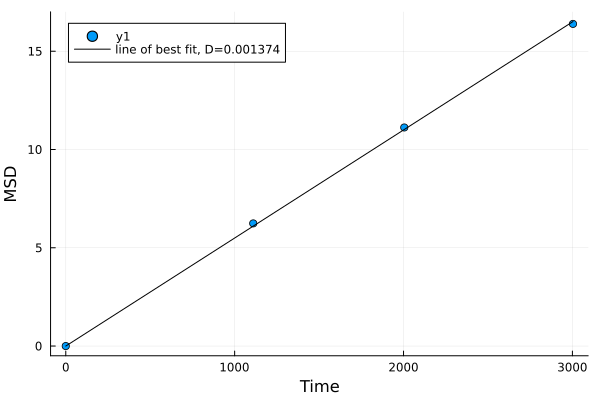

In [94]:
dsq = zeros(Float64, length(snapshots), n_atoms);

for (i, sdf) in enumerate(snapshots)
    d = sdf .- snapshots[1]
    dsq[i, :] .= d.x .^2 + d.y .^2
end

msd_allatoms = mean(dsq, dims=2)[:,1];
D_allatoms = inv(tvals_allatoms'*tvals_allatoms)*(tvals_allatoms'*msd_allatoms)[1,1]/4

plot(tvals_allatoms, msd_allatoms, seriestype=:scatter)
plot!(tvals_allatoms, tvals_allatoms .* 4D_allatoms, lc=:black, label="line of best fit, D="*string(round(D_allatoms, digits=6)))

xlabel!("Time")
ylabel!("MSD")

> <b>💡 Lab memo prompt:</b> How different is this value from the one you obtained above? What do you think the source of this difference might be?

We can visualize this average and best-fit line overlaid onto *all* of the data (i.e. squared displacement of each atom at each of the four timepoints) as well...

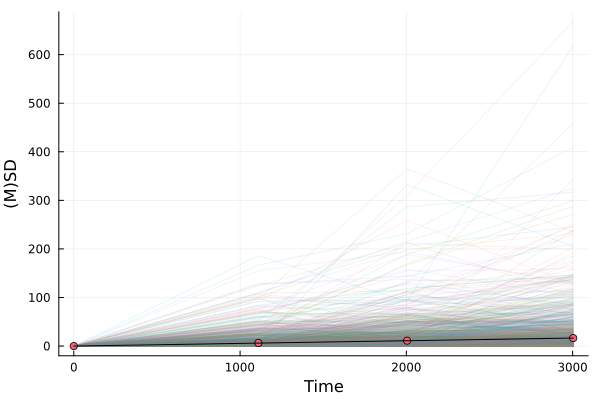

In [95]:
plot(tvals_allatoms, dsq[:,1], la=0.05, legend=false)
for i in 2:2125
    plot!(tvals_allatoms, dsq[:,i], la=0.1, legend=false)
end

plot!(tvals_allatoms, msd_allatoms, seriestype=:scatter)
plot!(tvals_allatoms, tvals_allatoms .* 4D_allatoms, lc=:black, label="line of best fit, D="*string(round(D_allatoms, digits=6)))

xlabel!("Time")
ylabel!("(M)SD")

That's a huge range of behaviors! I wonder if we can explain it somehow...you might have noticed that the particles near the wall seem to be able to "slide" along the wall much more easily...what if we sort the particles by how close they are to the wall in the first snapshot?

In [96]:
# function to compute initial distance from wall of each particle
wall_dist(i) = round(Int, minimum(25 .- abs.([snapshots[1][i, :x], snapshots[1][i, :y]] .- 25)))+1
dists = [wall_dist(i) for i in 1:n_atoms];

# bin things out based on distance (cutoffs should start with 0)
distance_bin(i; cutoffs=[0, 4, 9]) = sum(wall_dist(i) .> cutoffs)
labels = ["very close", "kinda close", "medium/far"] # one for each cutoff

# split indices by bin (there's almost certainly a smarter way to do this)
bins = distance_bin.(1:n_atoms);
n_bins = maximum(bins)
inds_bins = [[j for j in 1:n_atoms if bins[j]==i] for i in 1:n_bins]

# get averages within each bin...there's probably a smarter way to do this too
msd_binned = zeros(Float64, length(snapshots), n_bins);

for i in 1:length(snapshots)
    dsq_here = dsq[i,:]
    for j in 1:n_bins
        msd_binned[i,j] = mean(dsq_here[inds_bins[j]])
    end
end

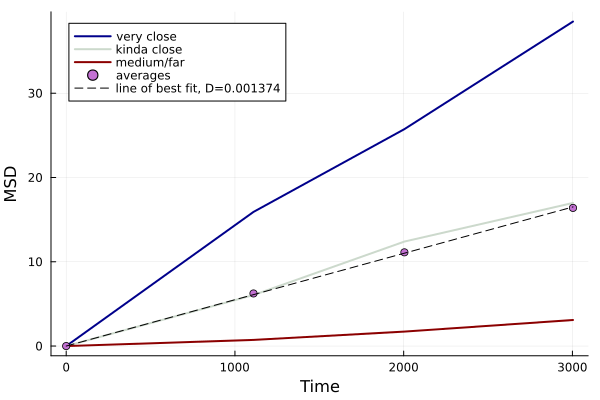

In [97]:
# plot averages per distance bin
colors = cgrad(:redsblues, n_bins, rev=true, categorical=true)#, scale=:log)

plot(tvals_allatoms, msd_binned[:, 1], label=labels[1], lc=colors[1], lw=2)
for i in 2:n_bins
    plot!(tvals_allatoms, msd_binned[:, i], label=labels[i], lc=colors[i], lw=2)
end

plot!(tvals_allatoms, msd_allatoms, seriestype=:scatter, label="averages")
plot!(tvals_allatoms, tvals_allatoms .* 4D_allatoms, lc=:black, ls=:dash, label="line of best fit, D="*string(round(D_allatoms, digits=6)))

xlabel!("Time")
ylabel!("MSD")

This plot shows both the overall averages and line of best fit from above as well as the averages within each distance bin, that is, how close the particles start to the wall.

> <b>💡 Lab memo prompt:</b> What do you notice when we visualize the data this way? How could the plot above help explain the one before?

## But is this the same diffusion constant?

The way we usually think about diffusivity (and the way we will mostly discuss it in lecture) is as a way to quantify how quickly material "spreads out" over time in a continuum setting. We can examine that in this atomistic context as well, by considering the population of atoms that starts in the "middle strip" of the box, and watching how they spread out during the simulation...

In [98]:
# collect the list of indices of the particles that start in the middle strip
df = snapshots[1]
nums = df[(23.5 .< df.x .< 26.5), :].num;

In [99]:
function concentration_profile(df, nums; slice_size=1.0, box_size=50.0)
    bins = 0.0:slice_size:box_size
    counts = zeros(Int, length(bins)-1)
    df_here = filter(row -> row.num in nums, df)
    for i in 1:length(bins)-1
        counts[i] = size(df_here[(bins[i] .< df_here.x .< bins[i+1]), :], 1)
    end
    return 0.5 * (bins[1:end-1] .+ bins[2:end]), counts ./ (box_size*slice_size)
end

concentration_profile (generic function with 1 method)

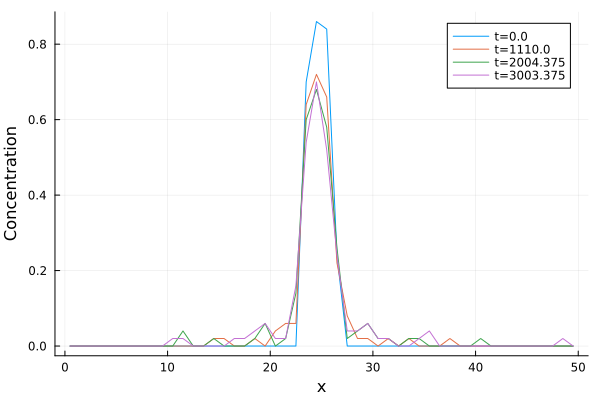

In [100]:
profs = concentration_profile.(snapshots, Ref(nums))
plot(profs[1], label="t="*string(tvals_allatoms[1]))
plot!(profs[2], label="t="*string(tvals_allatoms[2]))
plot!(profs[3], label="t="*string(tvals_allatoms[3]))
plot!(profs[4], label="t="*string(tvals_allatoms[4]))
xlabel!("x")
ylabel!("Concentration")

Okay, now hold that thought...
# Continuum-Scale Diffusion: Fick's Laws
For constant diffusivity $D$, the 1D diffusion equation reads
$$\frac{\partial c}{\partial t} = D\frac{\partial^2c}{\partial x^2}$$

which for a point release of total mass $M$ at the origin at $t=0$ has the solution

$$c(x,t) = \frac{M}{\sqrt{4\pi Dt}}\exp\left(-\frac{x^2}{4Dt}\right)$$

(If you've taken multivariable calculus, you can verify that this $c(x,t)$ indeed satisfies the partial differential equation (PDE) above; if you've taken differential equations, you might even be able to solve the PDE to get this solution! Whether or not you've taken either of these classes, you should think about how good the "point release" assumption is for our case here...)

In the cell below, modify the $D$ value at the top as needed to get the best fit you think you can between your model and your measured data across all four snapshots.

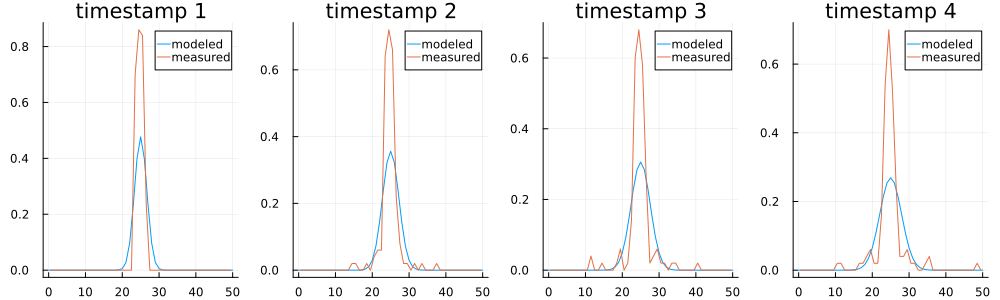

In [101]:
# SET D VALUE IN THE NEXT LINE, LEAVE REST OF CELL ALONE
D = 0.001

xvals = 0:50
t_offset = 700 # fudge factor to avoid making it try to plot the delta spike at t=0
conc(x,t,D) = 2*exp(-(x-25)^2/(4*D*(t+t_offset))) /sqrt(4*pi*D*(t+t_offset))

function make_plot(i; xvals=xvals, D=D)
    tval = tvals_allatoms[i] + t_offset
    c = conc.(xvals, Ref(tval), Ref(D))
    p = plot(xvals, c, label="modeled", title="timestamp "*string(i))
    plot!(p, profs[i]..., label="measured")
    return p
end

l = @layout [a b c d]
plot(make_plot.(1:4)..., layout = l, size=(1000,300))

> <b>💡 Lab memo prompt:</b> Which $D$ value seems to fit the data best this way? The one from the individual trajectories? The one from the snapshots? Or some other value? Include images of each timestep for what you visually assess to be the best-fitting value in your report.